# Computational Experiments: Sampling, Noise, Regularisation, Geometry Mismatch, and Data Redundancy

This notebook contains the computational experiments supporting the dissertation analyses of helical CT reconstruction. It combines the final workflows for acquisition sampling and noise, Tikhonov regularisation, TD-window reconstruction under geometric mismatch, and redundancy weighting. Expensive experiment blocks can be disabled when previously computed results are available.


## 1. Common setup

Import the required packages and define the scanner parameters, image geometry, numerical phantom, and helical source trajectory used throughout the experiments.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from cil.framework import (
    AcquisitionGeometry,
    ImageGeometry,
    ImageData,
)
from cil.plugins.astra import ProjectionOperator
from cil.optimisation.algorithms import CGLS

import pandas as pd
from cil.optimisation.algorithms import LSQR


In [ ]:
# ============================================================
# 1. Parameters
# ============================================================

nx, ny, nz = 64, 64, 128

half_width = 32.0
half_height = 64.0

voxel_size_x = 2.0 * half_width / nx
voxel_size_y = 2.0 * half_width / ny
voxel_size_z = 2.0 * half_height / nz

detector_num_horizontal = 96
detector_num_vertical = 160

detector_pixel_size_horizontal = 1.0
detector_pixel_size_vertical = 1.0


# Scanner geometry
source_origin_distance = 130.0
origin_detector_distance = 150.0


# Helical scan
BASELINE_PITCH = 48.0
BASELINE_PROJECTIONS_PER_TURN = 360

pitch = BASELINE_PITCH                     

scan_height = 2 * half_height    # cover the whole object

number_of_turns = int(
    np.ceil(scan_height / pitch)
)

total_z_travel = pitch * number_of_turns

projections_per_turn = BASELINE_PROJECTIONS_PER_TURN

number_of_projections = (
    projections_per_turn
    * number_of_turns
)


# iteration count
number_of_iterations = 100

print("Baseline pitch:", pitch)
print("Projections per turn:", projections_per_turn)
print("Number of turns:", number_of_turns)
print("Total z travel:", total_z_travel)
print("Number of projections:", number_of_projections)


Baseline pitch: 48.0
Projections per turn: 360
Number of turns: 3
Total z travel: 144.0
Number of projections: 1080


In [ ]:
# ============================================================
# 2. Image geometry
# ============================================================

image_geometry = ImageGeometry(
    voxel_num_x=nx,
    voxel_num_y=ny,
    voxel_num_z=nz,
    voxel_size_x=voxel_size_x,
    voxel_size_y=voxel_size_y,
    voxel_size_z=voxel_size_z,
    center_x=0.0,
    center_y=0.0,
    center_z=0.0,
)

# Physical y coordinates for CIL/ASTRA array axis 1 in (z, y, x) order.
y_coords = (
    np.arange(ny, dtype=np.float32)
    - (ny - 1) / 2.0
) * voxel_size_y
y0_idx = int(np.argmin(np.abs(y_coords)))
y0_coordinate = float(y_coords[y0_idx])

print(
    "Longitudinal y=0 slice uses array axis 1 at index",
    y0_idx,
    f"(nearest voxel centre y={y0_coordinate:.3f})",
)


Longitudinal y=0 slice uses array axis 1 at index 31 (nearest voxel centre y=-0.500)


In [ ]:
# ============================================================
# 3. Phantom
# ============================================================

def make_cylindrical_phantom(
    nx=64,
    ny=64,
    nz=128,
    half_width=32.0,
    half_height=64.0,
):
    """Create a cylindrical phantom in CIL/ASTRA array order (z, y, x)."""

    dx = 2.0 * half_width / nx
    dy = 2.0 * half_width / ny
    dz = 2.0 * half_height / nz

    x = (
        np.arange(nx, dtype=np.float32)
        - (nx - 1) / 2.0
    ) * dx

    y = (
        np.arange(ny, dtype=np.float32)
        - (ny - 1) / 2.0
    ) * dy

    z = (
        np.arange(nz, dtype=np.float32)
        - (nz - 1) / 2.0
    ) * dz

    zz, yy, xx = np.meshgrid(
        z,
        y,
        x,
        indexing="ij",
    )

    phantom = np.zeros(
        (nz, ny, nx),
        dtype=np.float32,
    )


    
    # -------------------
    # Main body
    # -------------------
    body_mask = (
        (xx**2 + yy**2 <= 11.0**2)
        & (np.abs(zz) <= 52.0)
    )
    phantom[body_mask] = 1.0

    
    # Low-density inclusion
    low_density_mask = (
        ((xx - 3.0)**2 + yy**2 <= 2.2**2)
        & (np.abs(zz) <= 35.0)
    )
    phantom[low_density_mask] = 0.15

    
    # High-density inclusion
    high_density_mask = (
        ((xx + 4.0)**2 + yy**2 <= 2.8**2)
        & (zz >= -25.0)
        & (zz <= 5.0)
    )
    phantom[high_density_mask] = 1.7

    
    # Second cylindrical inclusion
    second_insert_mask = (
        ((xx - 5.2)**2 + yy**2 <= 1.8**2)
        & (zz >= 10.0)
        & (zz <= 35.0)
    )
    phantom[second_insert_mask] = 0.45

    
    # Spherical inclusion
    sphere_mask = (
        (xx + 2.5)**2
        + yy**2
        + (zz + 12.0)**2
        <= 3.5**2
    )
    phantom[sphere_mask] = 2.0

    return phantom


phantom_array = make_cylindrical_phantom(
    nx=nx,
    ny=ny,
    nz=nz,
    half_width=half_width,
    half_height=half_height,
)

phantom = ImageData(
    array=phantom_array,
    geometry=image_geometry,
    deep_copy=True,
)


In [ ]:
# ============================================================
# 4. Helical trajectory
# ============================================================

angles = np.linspace(
    0.0,
    2.0 * np.pi * number_of_turns,
    number_of_projections,
    endpoint=False,
    dtype=np.float32,
)

source_z_positions = np.linspace(
    -total_z_travel / 2.0,
    total_z_travel / 2.0,
    number_of_projections,
    endpoint=False,
    dtype=np.float32,
)

source_positions = np.zeros(
    (number_of_projections, 3),
    dtype=np.float32,
)

detector_positions = np.zeros_like(source_positions)
detector_direction_x = np.zeros_like(source_positions)
detector_direction_y = np.zeros_like(source_positions)

for i, (angle, source_z) in enumerate(
    zip(angles, source_z_positions)
):
    cosine = np.cos(angle)
    sine = np.sin(angle)

    source_positions[i] = [
        source_origin_distance * cosine,
        source_origin_distance * sine,
        source_z,
    ]

    detector_positions[i] = [
        -origin_detector_distance * cosine,
        -origin_detector_distance * sine,
        source_z,
    ]

    detector_direction_x[i] = [
        -sine,
        cosine,
        0.0,
    ]

    detector_direction_y[i] = [
        0.0,
        0.0,
        1.0,
    ]

## 2. Acquisition geometry and simulated projection data

Construct the CIL cone-beam acquisition geometry, reorder it for the ASTRA backend, create the projection operator, and simulate noiseless projection data from the numerical phantom.


In [ ]:
# ============================================================
# 5. CIL acquisition geometry
# Describe the CT scanner geometry only; projection data and phantom values are stored separately.
# ============================================================

acquisition_geometry = (                                        
    AcquisitionGeometry.create_Cone3D_Flex(
        source_position_set=source_positions,                           
        detector_position_set=detector_positions,                       
        detector_direction_x_set=detector_direction_x,                 
        detector_direction_y_set=detector_direction_y,
    )
)

acquisition_geometry.set_panel(                                 
    num_pixels=[                                        
        detector_num_horizontal,
        detector_num_vertical,
    ],
    pixel_size=[                                       
        detector_pixel_size_horizontal,
        detector_pixel_size_vertical,
    ],
)

acquisition_geometry.set_labels(
    [
        "projection",
        "vertical",
        "horizontal",
    ]
)

In [ ]:
# ============================================================
# 6. Reorder data geometry for the projection backend
# ============================================================

acquisition_template = acquisition_geometry.allocate(0)
acquisition_template.reorder("astra")

acquisition_geometry_backend = acquisition_template.geometry         


# ============================================================
# 7. CIL projection operator
# ============================================================

operator = ProjectionOperator(                                     
    image_geometry=image_geometry,                                       
    acquisition_geometry=acquisition_geometry_backend,                   
    device="gpu",
)

Projection shape: (160, 1080, 96)
Projection labels: (<AcquisitionDimension.VERTICAL: 'vertical'>, <AcquisitionDimension.PROJECTION: 'projection'>, <AcquisitionDimension.HORIZONTAL: 'horizontal'>)
Projection labels: (<AcquisitionDimension.VERTICAL: 'vertical'>, <AcquisitionDimension.PROJECTION: 'projection'>, <AcquisitionDimension.HORIZONTAL: 'horizontal'>)
Projection array shape: (160, 1080, 96)


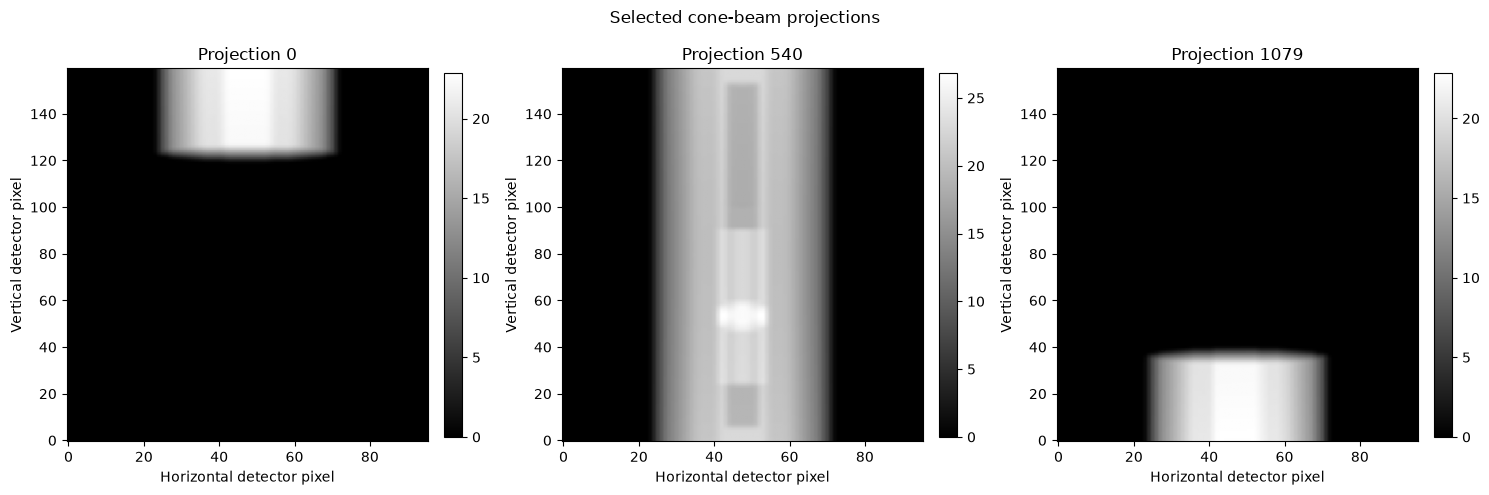

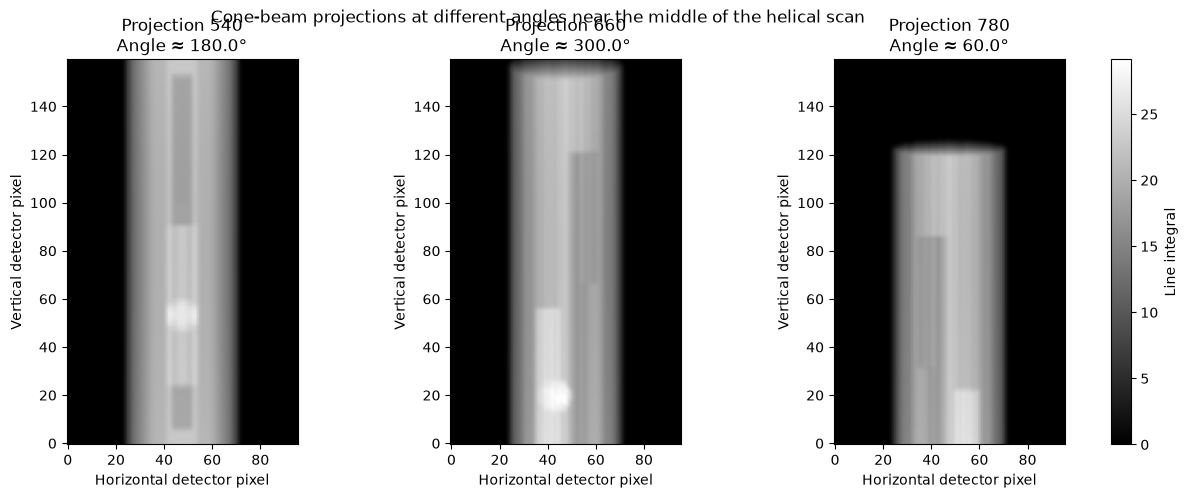

In [ ]:
# ============================================================
# 8. Simulate projection data
#
# b = A x_true
# ============================================================

projection_data = operator.direct(phantom)

print("Projection shape:", projection_data.shape)
print("Projection labels:", projection_data.dimension_labels)


# ------------------------------------------------------------
# 8.1 Visualise selected cone-beam projections
# ------------------------------------------------------------

projection_array = projection_data.as_array()

print("Projection labels:", projection_data.dimension_labels)
print("Projection array shape:", projection_array.shape)

projection_indices = [
    0,
    number_of_projections // 2,
    number_of_projections - 1,
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, projection_index in zip(
    axes,
    projection_indices,
):
    image = ax.imshow(
        projection_array[:, projection_index, :],
        cmap="gray",
        origin="lower",
        aspect="auto",
    )

    ax.set_title(
        f"Projection {projection_index}"
    )
    ax.set_xlabel(
        "Horizontal detector pixel"
    )
    ax.set_ylabel(
        "Vertical detector pixel"
    )

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

plt.suptitle("Selected cone-beam projections")
plt.tight_layout()
plt.show()






# ---------------------------------
# 8.3
# Visualise projections from different angles
# near the middle of the helical scan
# ---------------------------------

projection_array = projection_data.as_array()

# Number of projections acquired in one full revolution
# Reuse the centrally defined baseline projections per turn.
projections_per_turn = BASELINE_PROJECTIONS_PER_TURN

# Start near the middle of the full helical trajectory
centre_index = number_of_projections // 2

# Three views separated by approximately 120 degrees
projection_indices = [
    centre_index,
    centre_index + projections_per_turn // 3,
    centre_index + 2 * projections_per_turn // 3,
]

# Avoid exceeding the available projection range
projection_indices = [
    index % number_of_projections
    for index in projection_indices
]

selected_projections = [
    projection_array[:, index, :]
    for index in projection_indices
]

# Use the same intensity scale for all images
vmin = 0.0
vmax = max(
    image.max()
    for image in selected_projections
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, index, projection_image in zip(
    axes,
    projection_indices,
    selected_projections,
):
    angle_degrees = (
        index
        / projections_per_turn
        * 360.0
    ) % 360.0

    image = ax.imshow(
        projection_image,
        cmap="gray",
        origin="lower",
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(
        f"Projection {index}\n"
        f"Angle ≈ {angle_degrees:.1f}°"
    )

    ax.set_xlabel("Horizontal detector pixel")
    ax.set_ylabel("Vertical detector pixel")

fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.04,
    label="Line integral",
)

plt.suptitle(
    "Cone-beam projections at different angles "
    "near the middle of the helical scan"
    " "
)

plt.show()



## 3. Reconstruction and diagnostic utilities

Define reusable problem-building, adjoint-mismatch, LSQR diagnostic, result-summary, and plotting utilities. These functions are shared by the sampling, noise, and regularisation experiments below.


In [ ]:
# ============================================================
# Adjoint-mismatch diagnostics
# ============================================================
# A. Geometry/problem builder using the CURRENT phantom
# ============================================================

def build_helical_problem(
    pitch_value=BASELINE_PITCH,
    projections_per_turn_value=BASELINE_PROJECTIONS_PER_TURN,
    phantom_array_input=None,
    total_projections_value=None,
):
    """Build A, b and geometry while keeping the current phantom unchanged."""

    # Use the common image dimensions and physical extent defined above.
    nx_local, ny_local, nz_local = 64, 64, 128
    half_width_local, half_height_local = 32.0, 64.0

    voxel_size_x_local = 2.0 * half_width_local / nx_local
    voxel_size_y_local = 2.0 * half_width_local / ny_local
    voxel_size_z_local = 2.0 * half_height_local / nz_local

    detector_num_horizontal_local = 96
    detector_num_vertical_local = 160
    detector_pixel_size_horizontal_local = 1.0
    detector_pixel_size_vertical_local = 1.0

    source_origin_distance_local = source_origin_distance
    origin_detector_distance_local = origin_detector_distance

    scan_height_local = 2.0 * half_height_local
    number_of_turns_local = int(np.ceil(scan_height_local / pitch_value))
    total_z_travel_local = pitch_value * number_of_turns_local
    if total_projections_value is None:
        number_of_projections_local = (
            projections_per_turn_value * number_of_turns_local
        )
        effective_projections_per_turn_local = projections_per_turn_value
    else:
        number_of_projections_local = int(total_projections_value)
        if number_of_projections_local <= 0:
            raise ValueError("total_projections_value must be positive")
        effective_projections_per_turn_local = (
            number_of_projections_local / number_of_turns_local
        )

    image_geometry_local = ImageGeometry(
        voxel_num_x=nx_local,
        voxel_num_y=ny_local,
        voxel_num_z=nz_local,
        voxel_size_x=voxel_size_x_local,
        voxel_size_y=voxel_size_y_local,
        voxel_size_z=voxel_size_z_local,
        center_x=0.0,
        center_y=0.0,
        center_z=0.0,
    )

    if phantom_array_input is None:
        phantom_array_local = make_cylindrical_phantom(
            nx=nx_local,
            ny=ny_local,
            nz=nz_local,
            half_width=half_width_local,
            half_height=half_height_local,
        )
    else:
        phantom_array_local = np.asarray(
            phantom_array_input, dtype=np.float32
        ).copy()

    phantom_local = ImageData(
        array=phantom_array_local,
        geometry=image_geometry_local,
        deep_copy=True,
    )

    angles_local = np.linspace(
        0.0,
        2.0 * np.pi * number_of_turns_local,
        number_of_projections_local,
        endpoint=False,
        dtype=np.float32,
    )

    source_z_positions_local = np.linspace(
        -total_z_travel_local / 2.0,
        total_z_travel_local / 2.0,
        number_of_projections_local,
        endpoint=False,
        dtype=np.float32,
    )

    source_positions_local = np.zeros(
        (number_of_projections_local, 3), dtype=np.float32
    )
    detector_positions_local = np.zeros_like(source_positions_local)
    detector_direction_x_local = np.zeros_like(source_positions_local)
    detector_direction_y_local = np.zeros_like(source_positions_local)

    cosine = np.cos(angles_local)
    sine = np.sin(angles_local)

    source_positions_local[:, 0] = source_origin_distance_local * cosine
    source_positions_local[:, 1] = source_origin_distance_local * sine
    source_positions_local[:, 2] = source_z_positions_local

    detector_positions_local[:, 0] = -origin_detector_distance_local * cosine
    detector_positions_local[:, 1] = -origin_detector_distance_local * sine
    detector_positions_local[:, 2] = source_z_positions_local

    detector_direction_x_local[:, 0] = -sine
    detector_direction_x_local[:, 1] = cosine
    detector_direction_y_local[:, 2] = 1.0

    acquisition_geometry_local = AcquisitionGeometry.create_Cone3D_Flex(
        source_position_set=source_positions_local,
        detector_position_set=detector_positions_local,
        detector_direction_x_set=detector_direction_x_local,
        detector_direction_y_set=detector_direction_y_local,
    )

    acquisition_geometry_local.set_panel(
        num_pixels=[
            detector_num_horizontal_local,
            detector_num_vertical_local,
        ],
        pixel_size=[
            detector_pixel_size_horizontal_local,
            detector_pixel_size_vertical_local,
        ],
    )

    acquisition_geometry_local.set_labels(
        ["projection", "vertical", "horizontal"]
    )

    acquisition_template_local = acquisition_geometry_local.allocate(0)
    acquisition_template_local.reorder("astra")
    acquisition_geometry_backend_local = acquisition_template_local.geometry

    operator_local = ProjectionOperator(
        image_geometry=image_geometry_local,
        acquisition_geometry=acquisition_geometry_backend_local,
        device="gpu",
    )

    projection_data_local = operator_local.direct(phantom_local)

    return {
        "pitch": pitch_value,
        "projections_per_turn": effective_projections_per_turn_local,
        "number_of_turns": number_of_turns_local,
        "number_of_projections": number_of_projections_local,
        "image_geometry": image_geometry_local,
        "acquisition_geometry": acquisition_geometry_local,
        "operator": operator_local,
        "projection_data": projection_data_local,
        "phantom": phantom_local,
    }


# ============================================================
# B. Diagnostics
# ============================================================

def as_float64(container):
    return np.asarray(container.as_array(), dtype=np.float64)


def rmse_value(reconstruction, truth):
    error = as_float64(reconstruction) - as_float64(truth)
    return float(np.sqrt(np.mean(error**2)))


def relative_adjoint_mismatch(operator_local, seed=0):
    """One explicit random dot test for the implemented pair A and B."""
    rng = np.random.default_rng(seed)

    x = operator_local.domain_geometry().allocate(0.0)
    y = operator_local.range_geometry().allocate(0.0)

    x.fill(rng.standard_normal(x.shape).astype(np.float32))
    y.fill(rng.standard_normal(y.shape).astype(np.float32))

    Ax = operator_local.direct(x)
    By = operator_local.adjoint(y)

    lhs = float(np.vdot(Ax.as_array().ravel(), y.as_array().ravel()).real)
    rhs = float(np.vdot(x.as_array().ravel(), By.as_array().ravel()).real)

    return abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-30)


def run_lsqr_with_diagnostics(
    operator_local,
    data_local,
    truth_local,
    initial_local,
    number_of_iterations_local=100,
    alpha=0.0,
    checkpoint_interval=1,
):
    """Run one CONTINUOUS LSQR object and record diagnostic quantities."""

    algorithm = LSQR(
        initial=initial_local.copy(),
        operator=operator_local,
        data=data_local,
        alpha=alpha,
    )

    data_norm = max(float(data_local.norm()), 1e-30)
    backprojected_data = operator_local.adjoint(data_local)
    backprojected_data_norm = max(float(backprojected_data.norm()), 1e-30)

    previous_x = as_float64(initial_local).copy()
    records = []
    iterates = {}

    for iteration in range(1, number_of_iterations_local + 1):
        # Important: this preserves the internal LSQR Krylov recurrence.
        next(algorithm)

        should_record = (
            iteration == 1
            or iteration == number_of_iterations_local
            or iteration % checkpoint_interval == 0
        )
        if not should_record:
            continue

        x = algorithm.solution.copy()
        Ax = operator_local.direct(x)
        residual = Ax - data_local
        B_residual = operator_local.adjoint(residual)
        BAx = operator_local.adjoint(Ax)

        x_array = as_float64(x)
        BAx_array = as_float64(BAx)
        x_flat = x_array.ravel()
        BAx_flat = BAx_array.ravel()

        x_norm = np.linalg.norm(x_flat)
        BAx_norm = np.linalg.norm(BAx_flat)
        quadratic_form = float(np.dot(x_flat, BAx_flat))

        # ------------------------------------------------------------
        # Explicit residual norm
        # ------------------------------------------------------------

        residual_norm = float(residual.norm())

        # ------------------------------------------------------------
        # Tikhonov diagnostics
        #
        # CIL LSQR solves:
        #
        #   min_x ||Ax - b||_2^2 + alpha^2 ||x||_2^2
        #
        # ------------------------------------------------------------

        # Data-fidelity term:
        # ||Ax - b||_2^2
        data_fidelity = residual_norm**2

        # Squared solution norm:
        # ||x||_2^2
        solution_norm_squared = x_norm**2

        # Tikhonov regularisation term:
        # alpha^2 ||x||_2^2
        regularisation_penalty = (
            alpha**2 * solution_norm_squared
        )

        # Full Tikhonov objective:
        # ||Ax - b||_2^2 + alpha^2 ||x||_2^2
        tikhonov_objective = (
            data_fidelity
            + regularisation_penalty
        )






        records.append(
            {
                "iteration": iteration,

        # Regularisation parameter
                "alpha": float(alpha),

        # ----------------------------------------------------
        # Existing LSQR diagnostics
        # ----------------------------------------------------

                "relative_residual": (
                    residual_norm / data_norm
                ),
        
                "rmse": rmse_value(
                    x,
                    truth_local,
                ),

                "relative_backprojected_residual": (
                    float(B_residual.norm())
                    / backprojected_data_norm
                ),
        
                "xTBAx": quadratic_form,
        
                "normalised_xTBAx": (
                    quadratic_form
                    / max(
                                x_norm * BAx_norm,
                        1e-30,
                    )
                ),

                "relative_update": (
                    np.linalg.norm(
                        x_array.ravel()
                        - previous_x.ravel()
                    )
                    / max(
                        x_norm,
                        1e-30,
                    )
                ),

                "solution_norm": x_norm,

                "negative_voxel_fraction": float(
                    np.mean(
                        x_array < 0.0
                    )
                ),

                # ----------------------------------------------------
                # NEW: Tikhonov diagnostics
                # ----------------------------------------------------

                # ||x||_2^2
                "solution_norm_squared": (
                    solution_norm_squared
                ),

                # ||Ax - b||_2^2
                "data_fidelity": (
                    data_fidelity
                ),

                # alpha^2 ||x||_2^2
                "regularisation_penalty": (
                    regularisation_penalty
        ),
        
                # ||Ax-b||_2^2 + alpha^2 ||x||_2^2
                "tikhonov_objective": (
                    tikhonov_objective
                ),
            }
        )

        









        iterates[iteration] = x.copy()
        previous_x = x_array.copy()

    history = pd.DataFrame(records)
    best_index = history["rmse"].idxmin()
    best_iteration = int(history.loc[best_index, "iteration"])
    minimum_rmse = float(history.loc[best_index, "rmse"])

    near_optimal = history[history["rmse"] <= 1.01 * minimum_rmse]

    near_optimal_start = int(
        near_optimal["iteration"].min()
    )

    near_optimal_end = int(
        near_optimal["iteration"].max()
    )

    near_optimal_width = (
        near_optimal_end
        - near_optimal_start
        + 1
    )

    final_index = history.index[-1]

    final_iteration = int(
        history.loc[
            final_index,
            "iteration"
        ]
    )

    final_rmse = float(
        history.loc[
            final_index,
            "rmse"
        ]
    )


    

    




    
    return {
        "alpha":
            float(alpha),

        "history":
            history,

        "iterates":
            iterates,

        "best_iteration":
            best_iteration,

        "best_reconstruction":
            iterates[
                best_iteration
            ].copy(),

        "final_iteration":
            final_iteration,

        "final_reconstruction":
            algorithm.solution.copy(),

        "minimum_rmse":
            minimum_rmse,

        "final_rmse":
            final_rmse,

        "near_optimal_start":
            near_optimal_start,

        "near_optimal_end":
            near_optimal_end,

        "near_optimal_width":
            near_optimal_width,

        "relative_residual_at_best":
            float(
                history.loc[
                    best_index,
                  "relative_residual"
                ]
            ),

        "relative_residual_at_final":
            float(
                history.loc[
                    final_index,
                    "relative_residual"
                ]
            ),

        "solution_norm_at_best":
            float(
                history.loc[
                    best_index,
                    "solution_norm"
                ]
            ),

        "solution_norm_at_final":
            float(
                history.loc[
                    final_index,
                    "solution_norm"
                ]
            ),
    }







# ---------------------------------------------------
# Relative adjoint-mismatch definition used throughout the diagnostics.
# ---------------------------------------------------
def explicit_adjoint_mismatch(
    operator,
    seed=42,
):
    rng = np.random.default_rng(seed)

    x = operator.domain_geometry().allocate(0.0)
    y = operator.range_geometry().allocate(0.0)

    # Positive random values reduce cancellation in the inner products.
    x.fill(
        rng.random(x.shape).astype(np.float32)
    )

    y.fill(
        rng.random(y.shape).astype(np.float32)
    )

    Ax = operator.direct(x)
    By = operator.adjoint(y)

    lhs = float(
        np.vdot(
            Ax.as_array().ravel(),
            y.as_array().ravel(),
        ).real
    )

    rhs = float(
        np.vdot(
            x.as_array().ravel(),
            By.as_array().ravel(),
        ).real
    )

    absolute_difference = abs(lhs - rhs)

    relative_difference = (
        2.0 * absolute_difference
        / max(
            abs(lhs) + abs(rhs),
            1e-30,
        )
    )

    return {
        "lhs": lhs,
        "rhs": rhs,
        "absolute_difference":
            absolute_difference,
        "relative_mismatch":
            relative_difference,
    }


# -----------------------------------------
# Evaluate the diagnostic first on the baseline problem.
# -----------------------------------------
baseline_adjoint_diagnostics = [
    explicit_adjoint_mismatch(operator, seed=seed)
    for seed in range(5)
]
for diagnostic in baseline_adjoint_diagnostics:
    print(diagnostic)
baseline_adjoint_mismatch_samples = [
    diagnostic["relative_mismatch"]
    for diagnostic in baseline_adjoint_diagnostics
]











# ============================================================
# C. Initial-value experiment on the existing baseline problem
# ============================================================

def make_initialisations(image_geometry_local, phantom_local):
    zero = image_geometry_local.allocate(0.0)

    rng = np.random.default_rng(42)
    small_random = image_geometry_local.allocate(0.0)
    small_random.fill(
        rng.normal(0.0, 1e-3, size=small_random.shape).astype(np.float32)
    )

    # A deterministic nonzero start. It is deliberately not a good answer;
    # it tests sensitivity without requiring an additional SIRT reconstruction.
    scaled_truth = phantom_local.copy()
    scaled_truth *= 0.10

    return {
        "zero": zero,
        "small_random": small_random,
        "ten_percent_phantom": scaled_truth,
    }


def summarise_result(name, result, extra=None):
    history = result["history"]
    best = history.loc[history["rmse"].idxmin()]
    final = history.iloc[-1]

    row = {
        "experiment": name,
        "best_iteration": int(best["iteration"]),
        "minimum_rmse": float(best["rmse"]),
        "relative_residual_at_best": float(best["relative_residual"]),
        "backprojected_residual_at_best": float(
            best["relative_backprojected_residual"]
        ),
        "final_rmse": float(final["rmse"]),
        "near_optimal_start": result["near_optimal_start"],
        "near_optimal_end": result["near_optimal_end"],
    }
    if extra:
        row.update(extra)
    return row







{'lhs': 227699968.0, 'rhs': 223918320.0, 'absolute_difference': 3781648.0, 'relative_mismatch': 0.016747098602880317}
{'lhs': 227539680.0, 'rhs': 223778688.0, 'absolute_difference': 3760992.0, 'relative_mismatch': 0.016666691482851412}
{'lhs': 227883520.0, 'rhs': 224103776.0, 'absolute_difference': 3779744.0, 'relative_mismatch': 0.016725001049587022}
{'lhs': 228036864.0, 'rhs': 224255152.0, 'absolute_difference': 3781712.0, 'relative_mismatch': 0.01672243535689562}
{'lhs': 227898464.0, 'rhs': 224121696.0, 'absolute_difference': 3776768.0, 'relative_mismatch': 0.016710617508741202}


In [ ]:
# ============================================================
# Shared history plotting helper
# Defined before all later plotting calls.
# ============================================================

def plot_histories(results_dictionary, metric, ylabel, title):
    plt.figure(figsize=(7, 5))
    for label, value in results_dictionary.items():
        result = value["result"] if "result" in value else value
        history = result["history"]
        plt.semilogy(history["iteration"], history[metric], label=str(label))
    plt.xlabel("LSQR iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. Baseline reconstruction and noisy comparison

Establish the baseline helical reconstruction and compare noiseless data with a representative 1% Gaussian-noise realisation. Selected longitudinal reconstructions are retained to visualise the evolution of LSQR with iteration.


Baseline best iteration: 100
Baseline minimum RMSE: 0.016778629706726306
Baseline 1% near-optimal interval: 93 to 100
Actual relative noise: 0.010000000000000004


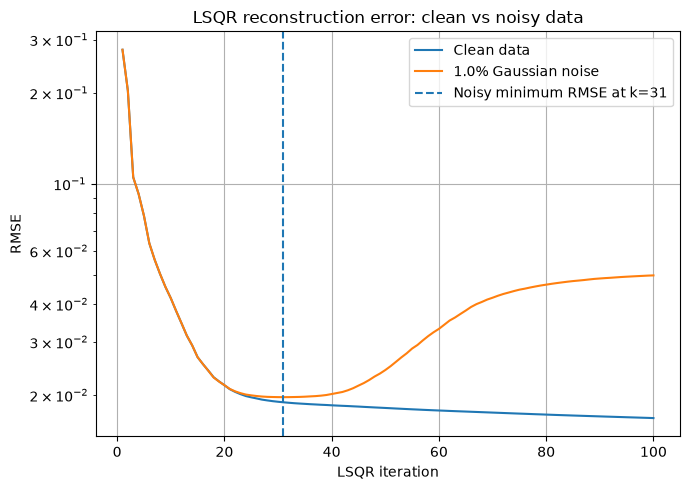

Clean: best iteration=100, minimum RMSE=0.01677863
Noisy: best iteration=31, minimum RMSE=0.01967796


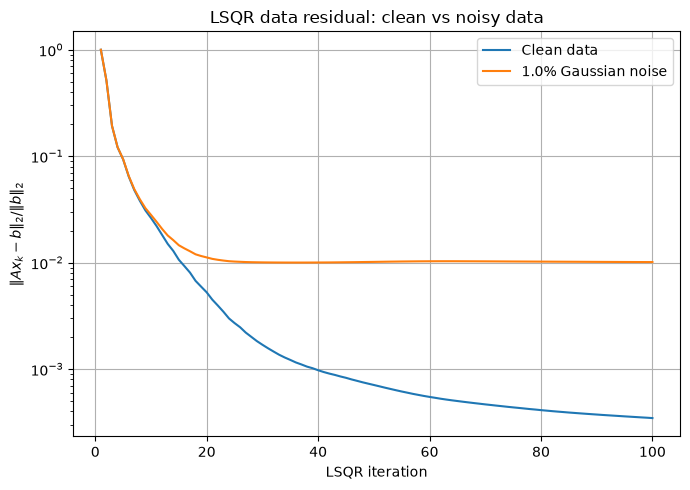

In [ ]:
# ============================================================
# D. RUN BLOCKS
# ============================================================

# -----------------------
# D1. Baseline
# -----------------------
# Reuse the common baseline objects defined above:
# operator, projection_data, phantom, image_geometry.



# ------------------------------------------------------------
# Use the same baseline construction as the later sweeps
# ------------------------------------------------------------

baseline_problem = build_helical_problem(
    pitch_value=BASELINE_PITCH,
    projections_per_turn_value=BASELINE_PROJECTIONS_PER_TURN,
    phantom_array_input=phantom_array,
)

# Replace the old global baseline objects from this point onward
operator = baseline_problem["operator"]
projection_data = baseline_problem["projection_data"]
phantom = baseline_problem["phantom"]
image_geometry = baseline_problem["image_geometry"]

number_of_turns = baseline_problem["number_of_turns"]
number_of_projections = baseline_problem["number_of_projections"]
projections_per_turn = BASELINE_PROJECTIONS_PER_TURN
pitch = BASELINE_PITCH





baseline_initial = image_geometry.allocate(0.0)

baseline_result = run_lsqr_with_diagnostics(
    operator_local=operator,
    data_local=projection_data,
    truth_local=phantom,
    initial_local=baseline_initial,
    number_of_iterations_local=number_of_iterations,
    alpha=0.0,
    checkpoint_interval=1,
)

print("Baseline best iteration:", baseline_result["best_iteration"])
print("Baseline minimum RMSE:", baseline_result["minimum_rmse"])
print(
    "Baseline 1% near-optimal interval:",
    baseline_result["near_optimal_start"],
    "to",
    baseline_result["near_optimal_end"],
)






# -----------------------
# D1b. controlled-noise experiment  Baseline
# -----------------------
rng = np.random.default_rng(42)

data_array = np.asarray(
    projection_data.as_array(),
    dtype=np.float64,
)

noise = rng.standard_normal(data_array.shape)

relative_noise_level = 0.01                 # 1% Gaussian noise

noise *= (
    relative_noise_level
    * np.linalg.norm(data_array.ravel())
    / max(
        np.linalg.norm(noise.ravel()),
        1e-30,
    )
)

noisy_projection_data = projection_data.copy()
noisy_projection_data.fill(
    (data_array + noise).astype(np.float32)
)

actual_relative_noise = (
    np.linalg.norm(noise.ravel())
    / np.linalg.norm(data_array.ravel())
)

print("Actual relative noise:", actual_relative_noise)





# -------------------------
#
# -------------------------
baseline_noisy_result = run_lsqr_with_diagnostics(
    operator_local=operator,
    data_local=noisy_projection_data,
    truth_local=phantom,
    initial_local=image_geometry.allocate(0.0),
    number_of_iterations_local=number_of_iterations,
    alpha=0.0,
    checkpoint_interval=1,
)




# Compare noiseless and noisy LSQR histories.
# ===================================================
# Compare clean and noisy LSQR
# ===================================================

clean_history = baseline_result["history"]
noisy_history = baseline_noisy_result["history"]

# ---------------------------------------------------
# Figure 1: Clean RMSE vs noisy RMSE
# ---------------------------------------------------

plt.figure(figsize=(7, 5))

plt.semilogy(
    clean_history["iteration"],
    clean_history["rmse"],
    label="Clean data",
)

plt.semilogy(
    noisy_history["iteration"],
    noisy_history["rmse"],
    #label="0.5% Gaussian noise",
    label=f"{100 * relative_noise_level:.1f}% Gaussian noise"
)

clean_best_iteration = int(
    clean_history.loc[
        clean_history["rmse"].idxmin(),
        "iteration",
    ]
)

noisy_best_iteration = int(
    noisy_history.loc[
        noisy_history["rmse"].idxmin(),
        "iteration",
    ]
)

clean_minimum_rmse = float(
    clean_history["rmse"].min()
)

noisy_minimum_rmse = float(
    noisy_history["rmse"].min()
)

plt.axvline(
    noisy_best_iteration,
    linestyle="--",
    label=(
        "Noisy minimum RMSE at "
        f"k={noisy_best_iteration}"
    ),
)

plt.xlabel("LSQR iteration")
plt.ylabel("RMSE")
plt.title("LSQR reconstruction error: clean vs noisy data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(
    f"Clean: best iteration={clean_best_iteration}, "
    f"minimum RMSE={clean_minimum_rmse:.8f}"
)

print(
    f"Noisy: best iteration={noisy_best_iteration}, "
    f"minimum RMSE={noisy_minimum_rmse:.8f}"
)





#-------------------------------
# ---------------------------------------------------
# Figure 2: Clean residual vs noisy residual
# ---------------------------------------------------

plt.figure(figsize=(7, 5))

plt.semilogy(
    clean_history["iteration"],
    clean_history["relative_residual"],
    label="Clean data",
)

plt.semilogy(
    noisy_history["iteration"],
    noisy_history["relative_residual"],
    #label="0.5% Gaussian noise",
    label=f"{100 * relative_noise_level:.1f}% Gaussian noise"
)

plt.xlabel("LSQR iteration")
plt.ylabel(
    r"$\|Ax_k-b\|_2/\|b\|_2$"
)
plt.title("LSQR data residual: clean vs noisy data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()







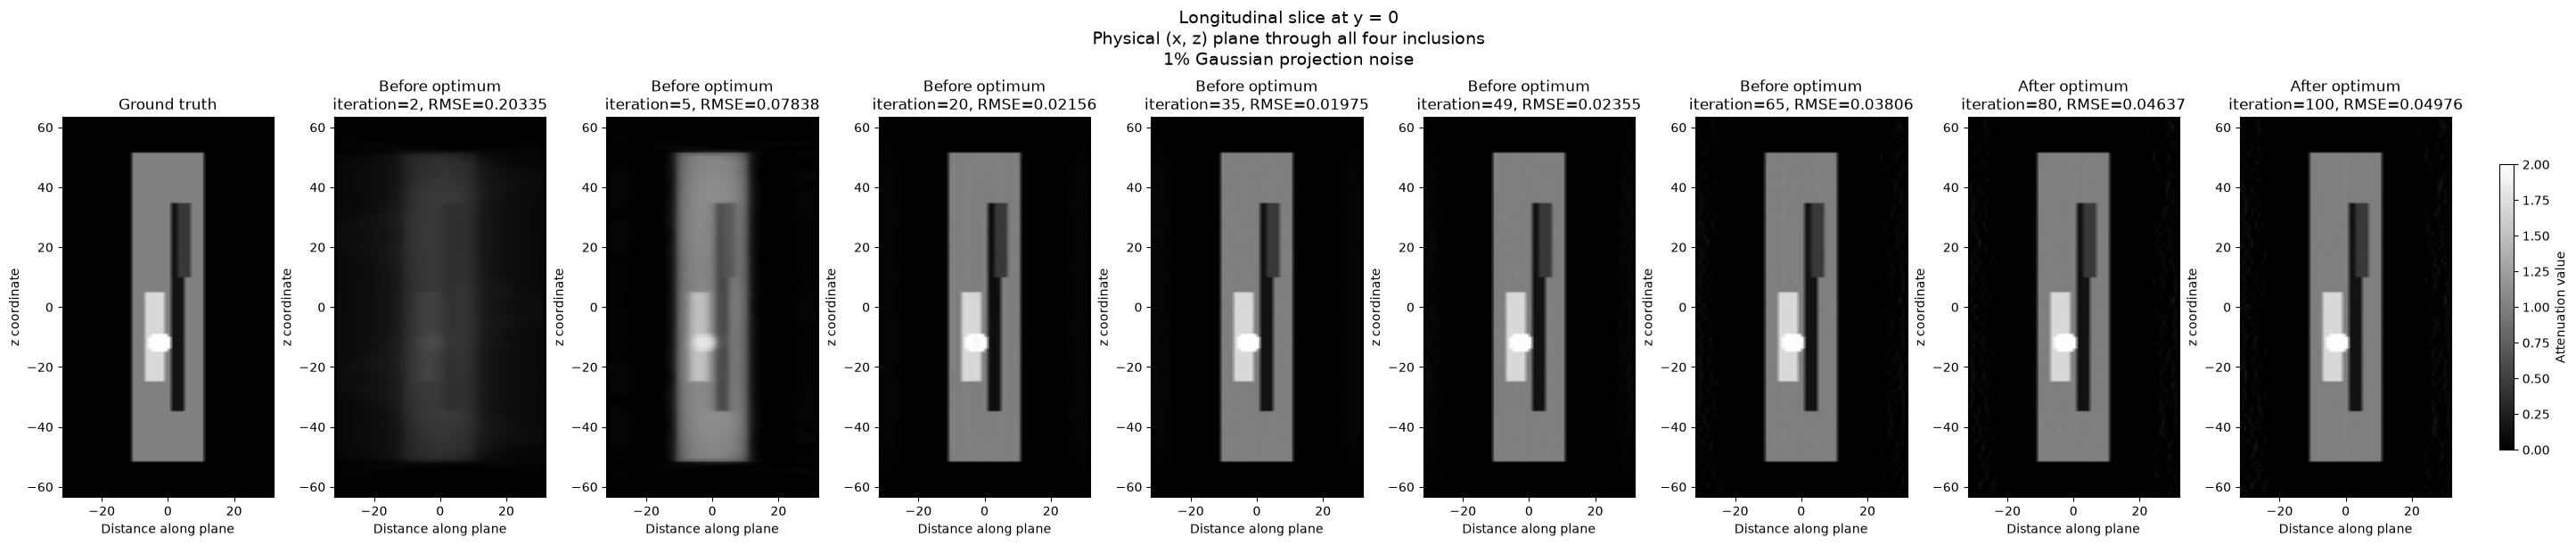

In [ ]:
# 1. Define the oblique longitudinal-slice extraction helper.

# ===================================================
# Longitudinal y=0 slices through all phantom inserts
# ===================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import map_coordinates


def extract_oblique_longitudinal_slice(
    volume,
    point_1,
    point_2,
    half_width,
    half_height,
    number_of_horizontal_samples=96,
):
    """
    Extract a vertical oblique plane from a 3-D volume.

    The input volume is assumed to have array order:
        (z, y, x)

    The vertical plane contains:
        1. the z direction;
        2. the line through point_1 and point_2 in the x-y plane.

    Parameters
    ----------
    volume : ndarray
        Three-dimensional array with shape (nz, ny, nx).

    point_1, point_2 : tuple
        Physical (x, y) coordinates defining the horizontal
        direction of the longitudinal plane.

    half_width : float
        Half-width of the reconstruction volume in x and y.

    half_height : float
        Half-height of the reconstruction volume in z.

    number_of_horizontal_samples : int
        Number of samples along the oblique horizontal direction.

    Returns
    -------
    slice_array : ndarray
        Oblique longitudinal slice with shape
        (nz, number_of_horizontal_samples).

    s_coordinates : ndarray
        Physical coordinates along the horizontal direction.

    z_coordinates : ndarray
        Physical z coordinates.
    """

    volume = np.asarray(
        volume,
        dtype=np.float64,
    )

    nz, ny, nx = volume.shape

    dx = 2.0 * half_width / nx
    dy = 2.0 * half_width / ny
    dz = 2.0 * half_height / nz

    point_1 = np.asarray(
        point_1,
        dtype=np.float64,
    )

    point_2 = np.asarray(
        point_2,
        dtype=np.float64,
    )

    # Midpoint of the two structures.
    plane_centre = 0.5 * (
        point_1 + point_2
    )

    # Unit direction within the x-y plane.
    direction = point_2 - point_1

    direction /= max(
        np.linalg.norm(direction),
        1e-30,
    )

    # Horizontal distance along the oblique plane.
    s_coordinates = np.linspace(
        -half_width,
        half_width,
        number_of_horizontal_samples,
    )

    x_coordinates = (
        plane_centre[0]
        + s_coordinates * direction[0]
    )

    y_coordinates = (
        plane_centre[1]
        + s_coordinates * direction[1]
    )

    z_coordinates = (
        np.arange(
            nz,
            dtype=np.float64,
        )
        - (nz - 1) / 2.0
    ) * dz

    # Convert physical coordinates to array indices.
    x_indices = (
        x_coordinates / dx
        + (nx - 1) / 2.0
    )

    y_indices = (
        y_coordinates / dy
        + (ny - 1) / 2.0
    )

    z_indices = np.arange(
        nz,
        dtype=np.float64,
    )

    # Build an (nz, ns) sampling grid.
    z_grid, s_grid = np.meshgrid(
        z_indices,
        np.arange(
            number_of_horizontal_samples,
            dtype=np.float64,
        ),
        indexing="ij",
    )

    x_grid = np.broadcast_to(
        x_indices[None, :],
        z_grid.shape,
    )

    y_grid = np.broadcast_to(
        y_indices[None, :],
        z_grid.shape,
    )

    slice_array = map_coordinates(
        volume,
        [
            z_grid,
            y_grid,
            x_grid,
        ],
        order=1,
        mode="constant",
        cval=0.0,
    )

    angle_degrees = np.degrees(
        np.arctan2(
            direction[1],
            direction[0],
        )
    )

    return {
        "slice": slice_array,
        "s_coordinates": s_coordinates,
        "z_coordinates": z_coordinates,
        "angle_degrees": float(
            angle_degrees
        ),
        "plane_centre": plane_centre,
        "direction": direction,
    }







# 2. Prepare the truth and selected iteration reconstructions.
selected_iterations =  [ 2, 5,20,35,49,65,80,100]
 

phantom_np = np.asarray(
    phantom.as_array(),
    dtype=np.float64,
)

selected_reconstructions = {
    iteration: np.asarray(
        baseline_noisy_result[
            "iterates"
        ][iteration].as_array(),
        dtype=np.float64,
    )
    for iteration in selected_iterations
}








# ----------------- 3. Define the longitudinal y=0 plane -----------------
# All four inclusion centres now lie on this physical (x, z) plane.
plane_a = {
    "name": "Longitudinal slice at y = 0",
    "point_1": (-1.0, 0.0),
    "point_2": (1.0, 0.0),
}

longitudinal_planes = [plane_a]


# 4. Plot the selected longitudinal reconstruction slices.
def plot_longitudinal_reconstruction_comparison(
    plane_definition,
    phantom_array,
    reconstruction_arrays,
    iterations,
    half_width,
    half_height,
):
    """
    Plot ground truth and selected LSQR iterates along
    the physical longitudinal y=0 plane.
    """

    truth_result = (
        extract_oblique_longitudinal_slice(
            volume=phantom_array,
            point_1=plane_definition[
                "point_1"
            ],
            point_2=plane_definition[
                "point_2"
            ],
            half_width=half_width,
            half_height=half_height,
        )
    )

    truth_slice = truth_result["slice"]

    reconstructed_slices = {}

    for iteration in iterations:
        reconstructed_slices[iteration] = (
            extract_oblique_longitudinal_slice(
                volume=(
                    reconstruction_arrays[
                        iteration
                    ]
                ),
                point_1=plane_definition[
                    "point_1"
                ],
                point_2=plane_definition[
                    "point_2"
                ],
                half_width=half_width,
                half_height=half_height,
            )["slice"]
        )

    number_of_panels = (
        1 + len(iterations)
    )

    fig, axes = plt.subplots(
        1,
        number_of_panels,
        figsize=(
            3.2 * number_of_panels,
            6.0,
        ),
        constrained_layout=True,
    )

    extent = [
        truth_result[
            "s_coordinates"
        ][0],
        truth_result[
            "s_coordinates"
        ][-1],
        truth_result[
            "z_coordinates"
        ][0],
        truth_result[
            "z_coordinates"
        ][-1],
    ]

    vmin = float(
        np.min(phantom_array)
    )

    vmax = float(
        np.max(phantom_array)
    )

    image = axes[0].imshow(
        truth_slice,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    axes[0].set_title(
        "Ground truth"
    )

    axes[0].set_xlabel(
        "Distance along plane"
    )

    axes[0].set_ylabel(
        "z coordinate"
    )

    history = baseline_noisy_result[
        "history"
    ]

    for axis, iteration in zip(
        axes[1:],
        iterations,
    ):
        rmse_value = float(
            history.loc[
                history["iteration"]
                == iteration,
                "rmse",
            ].iloc[0]
        )

        axis.imshow(
            reconstructed_slices[
                iteration
            ],
            origin="lower",
            extent=extent,
            aspect="auto",
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
        )

        if iteration == 69:
            status = "Minimum RMSE"
        elif iteration < 69:
            status = "Before optimum"
        else:
            status = "After optimum"

        axis.set_title(
            f"{status}\n"
            f"iteration={iteration}, "
            f"RMSE={rmse_value:.5f}"
        )

        axis.set_xlabel(
            "Distance along plane"
        )

        axis.set_ylabel(
            "z coordinate"
        )

    colorbar = fig.colorbar(
        image,
        ax=axes,
        shrink=0.75,
        pad=0.02,
    )

    colorbar.set_label(
        "Attenuation value"
    )

    fig.suptitle(
        plane_definition["name"]
        + "\n"
        + "Physical (x, z) plane through all four inclusions"
       # + "\n0.5% Gaussian projection noise",
        + f"\n{100 * relative_noise_level:g}% Gaussian projection noise",
        fontsize=14,
    )

    plt.show()


for plane_definition in longitudinal_planes:

    plot_longitudinal_reconstruction_comparison(
        plane_definition=plane_definition,
        phantom_array=phantom_np,
        reconstruction_arrays=(
            selected_reconstructions
        ),
        iterations=selected_iterations,
        half_width=half_width,
        half_height=half_height,
    )


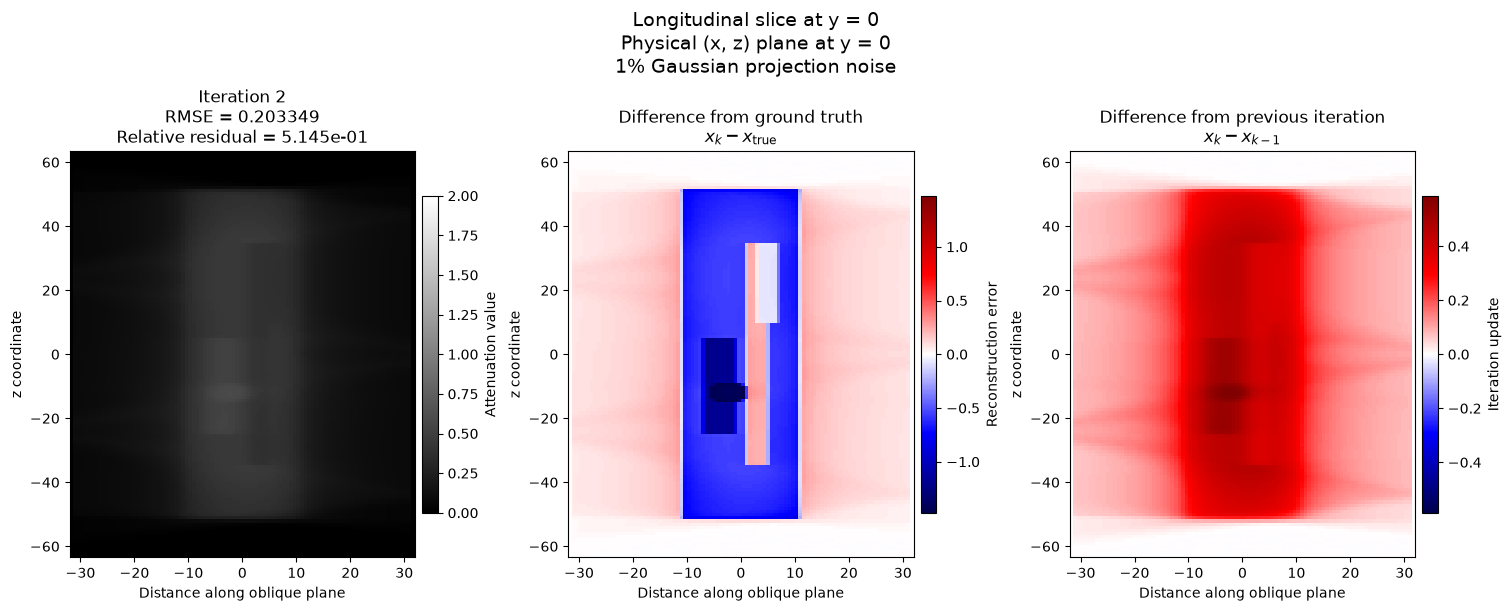

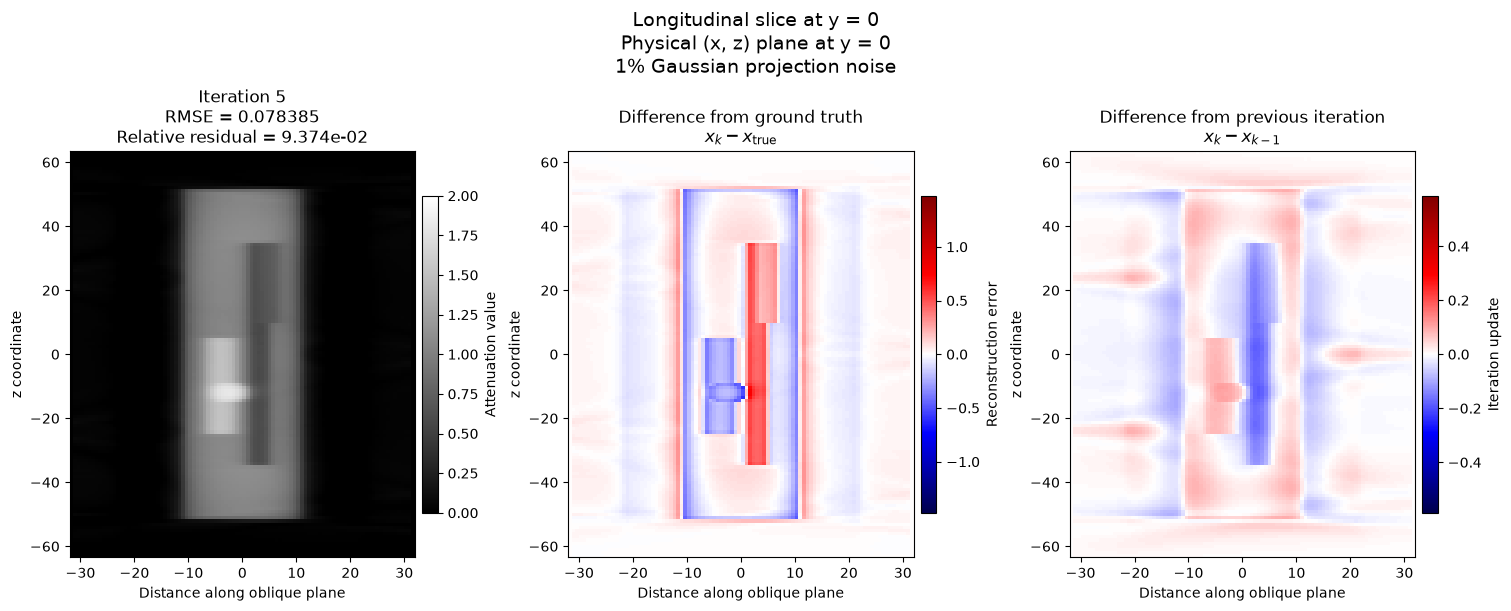

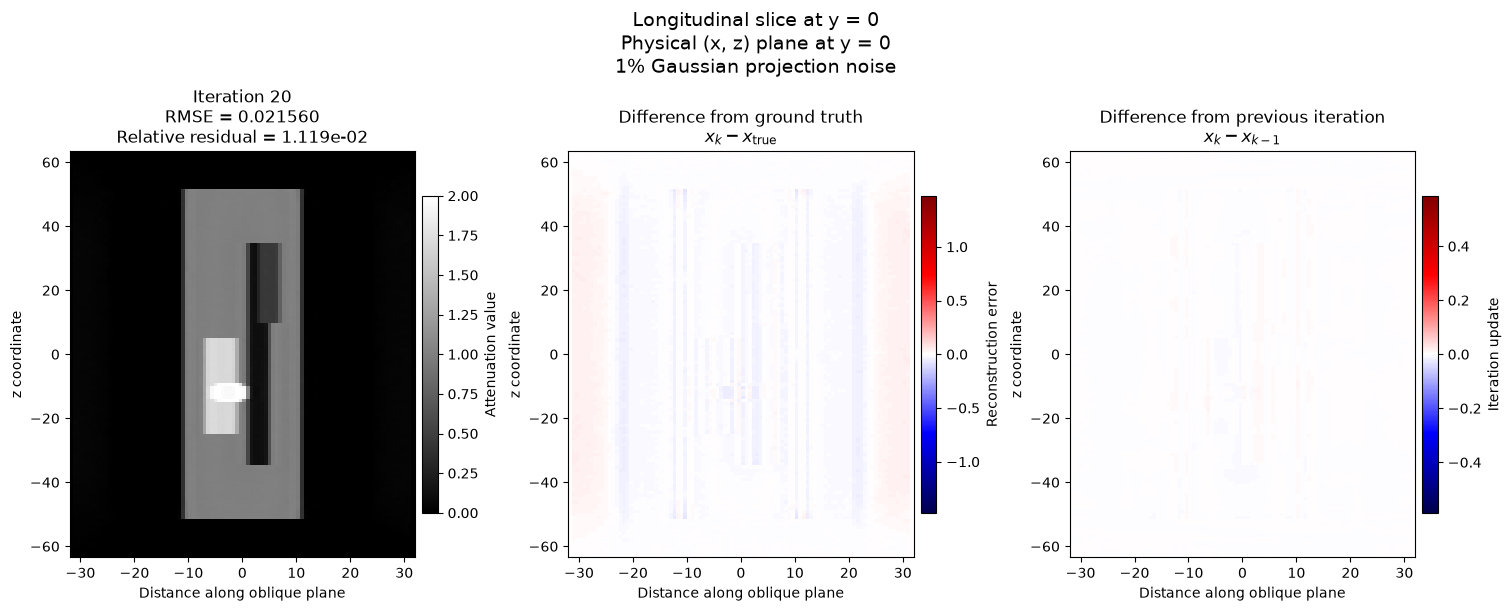

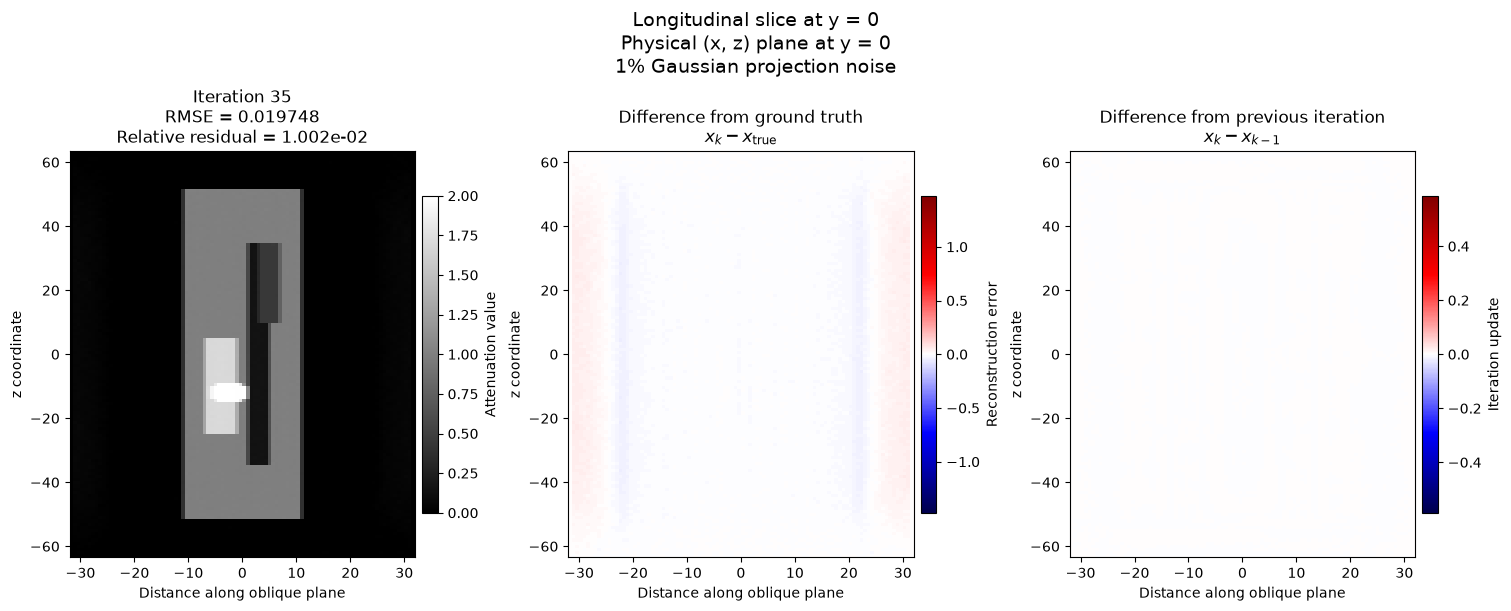

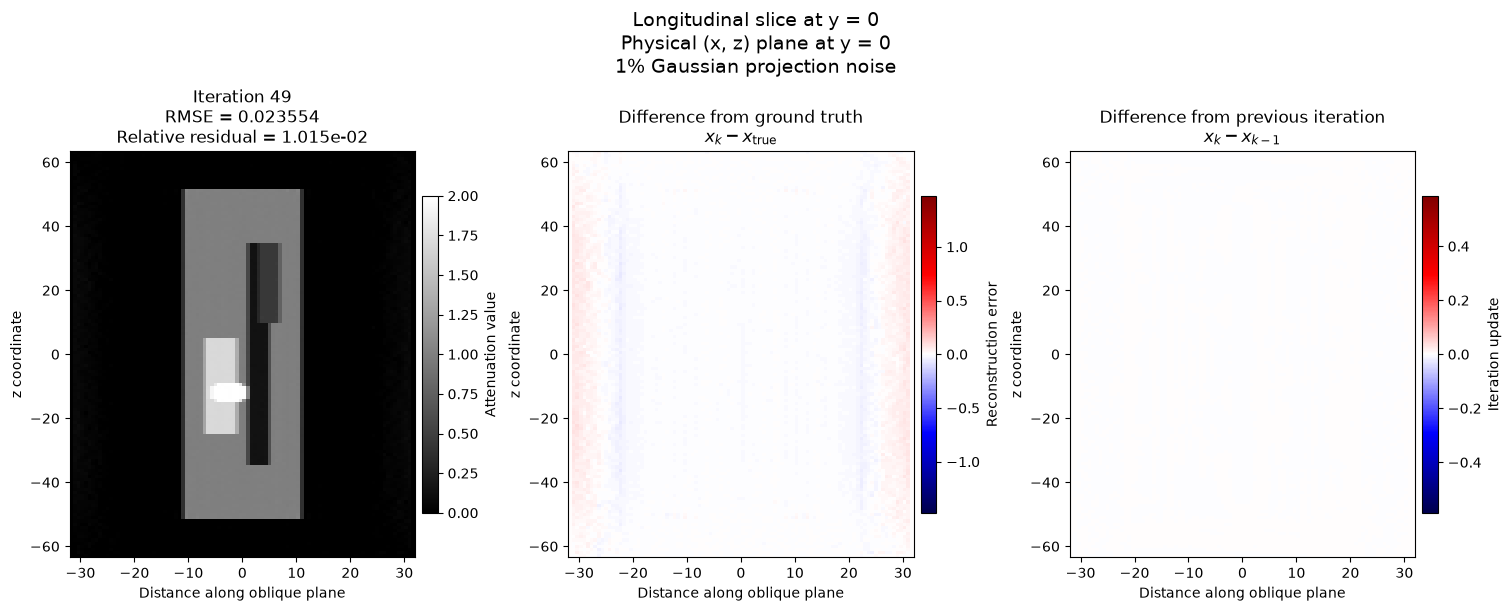

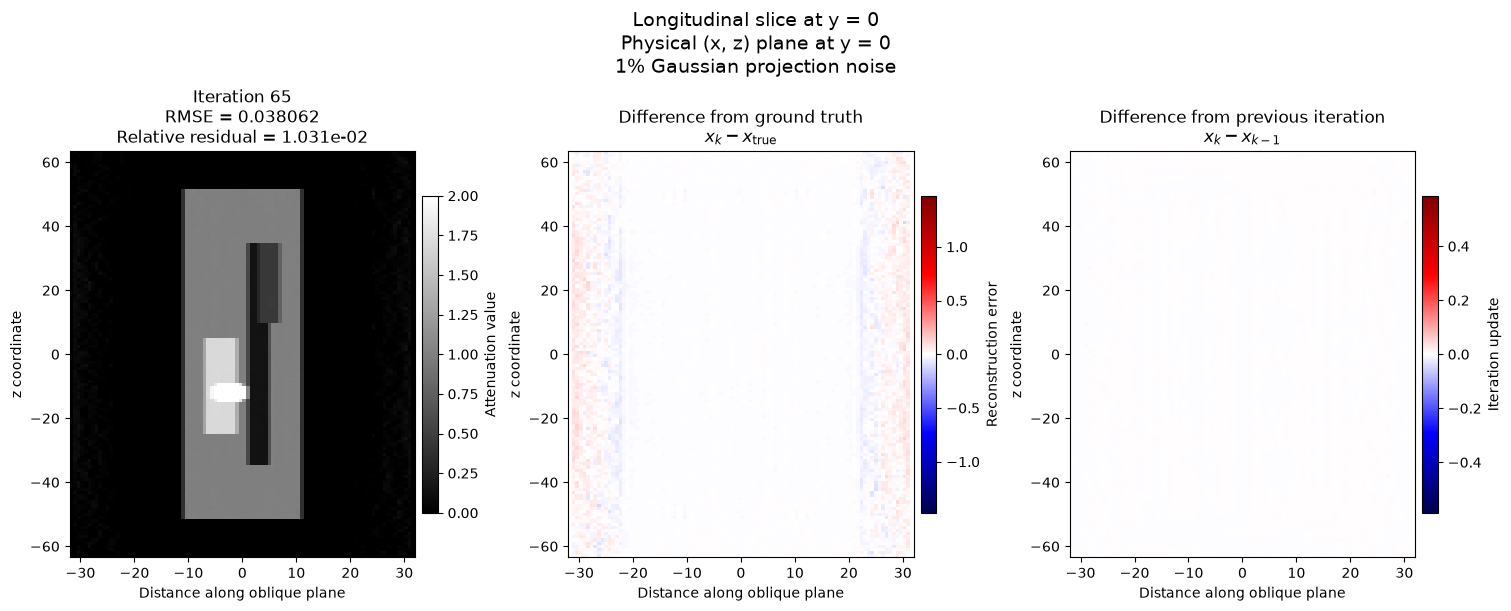

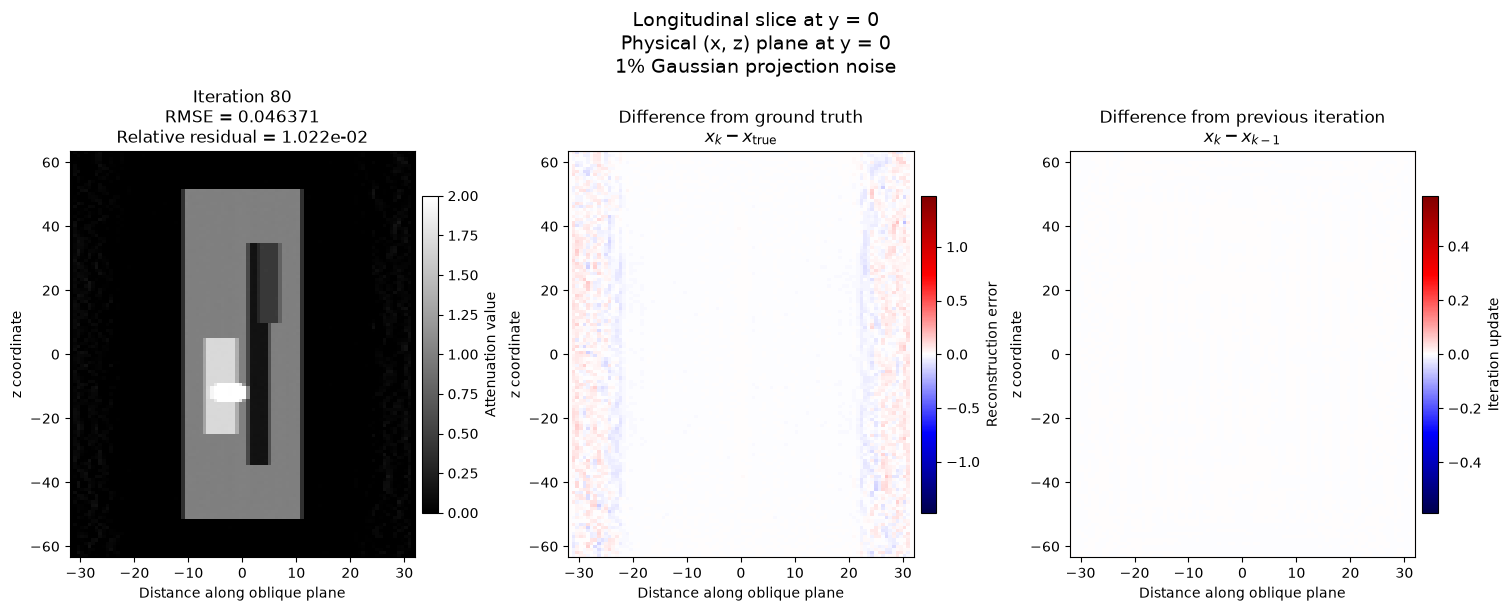

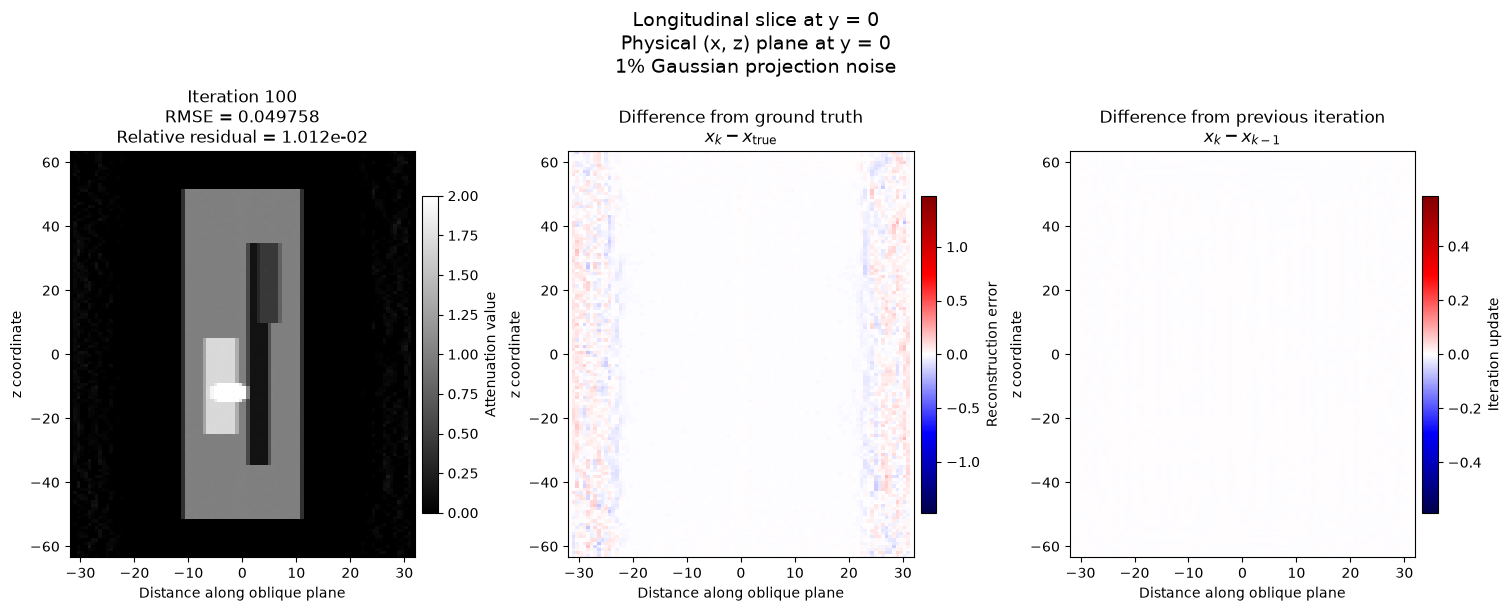

In [ ]:
# Plot three representative reconstruction slices in one row.

# 1. Define the plotting helper.
# ===================================================
# Iteration-process figure for an oblique
# longitudinal slice
# ===================================================

def plot_oblique_lsqr_iteration_process(
    result,
    phantom_array,
    plane_definition,
    selected_iterations,
    half_width,
    half_height,
    reconstruction_limits=(0.0, 2.0),
    error_limit=None,
    update_limit=None,
):
    """
    For each selected LSQR iteration, plot:

        1. reconstruction x_k;
        2. difference from truth x_k - x_true;
        3. difference from previous iteration x_k - x_{k-1}.

    All panels show the same physical longitudinal plane at y=0.

    Parameters
    ----------
    result : dict
        Output from run_lsqr_with_diagnostics().
        Must contain:
            result["iterates"]
            result["history"]

    phantom_array : ndarray
        Ground-truth volume in (z, y, x) order.

    plane_definition : dict
        Must contain:
            "name"
            "point_1"
            "point_2"

    selected_iterations : sequence of int
        Iterations to display.

    half_width, half_height : float
        Physical volume half-width and half-height.

    reconstruction_limits : tuple
        Common intensity limits for reconstruction images.

    error_limit : float or None
        Symmetric limit for x_k - x_true.
        If None, calculated from all selected iterations.

    update_limit : float or None
        Symmetric limit for x_k - x_{k-1}.
        If None, calculated from all selected iterations.
    """

    phantom_array = np.asarray(
        phantom_array,
        dtype=np.float64,
    )

    iterates = result["iterates"]
    history = result["history"]

    # ------------------------------------------------
    # Check availability
    # ------------------------------------------------

    required_iterations = set(
        selected_iterations
    )

    required_iterations.update(
        iteration - 1
        for iteration in selected_iterations
        if iteration > 0
    )

    missing_iterations = sorted(
        iteration
        for iteration in required_iterations
        if iteration not in iterates
    )

    if missing_iterations:
        raise ValueError(
            "The following iterations were not saved: "
            f"{missing_iterations}. "
            "Use checkpoint_interval=1 when running LSQR."
        )

    # ------------------------------------------------
    # Extract ground-truth longitudinal slice
    # ------------------------------------------------

    truth_result = (
        extract_oblique_longitudinal_slice(
            volume=phantom_array,
            point_1=plane_definition["point_1"],
            point_2=plane_definition["point_2"],
            half_width=half_width,
            half_height=half_height,
        )
    )

    truth_slice = truth_result["slice"]

    extent = [
        truth_result["s_coordinates"][0],
        truth_result["s_coordinates"][-1],
        truth_result["z_coordinates"][0],
        truth_result["z_coordinates"][-1],
    ]

    # ------------------------------------------------
    # Extract reconstruction, error and update slices
    # ------------------------------------------------

    reconstruction_slices = {}
    error_slices = {}
    update_slices = {}

    for iteration in selected_iterations:

        current_volume = np.asarray(
            iterates[iteration].as_array(),
            dtype=np.float64,
        )

        previous_volume = np.asarray(
            iterates[iteration - 1].as_array(),
            dtype=np.float64,
        )

        current_slice = (
            extract_oblique_longitudinal_slice(
                volume=current_volume,
                point_1=plane_definition["point_1"],
                point_2=plane_definition["point_2"],
                half_width=half_width,
                half_height=half_height,
            )["slice"]
        )

        previous_slice = (
            extract_oblique_longitudinal_slice(
                volume=previous_volume,
                point_1=plane_definition["point_1"],
                point_2=plane_definition["point_2"],
                half_width=half_width,
                half_height=half_height,
            )["slice"]
        )

        reconstruction_slices[iteration] = (
            current_slice
        )

        error_slices[iteration] = (
            current_slice - truth_slice
        )

        update_slices[iteration] = (
            current_slice - previous_slice
        )

    # ------------------------------------------------
    # Common limits across all selected iterations
    # ------------------------------------------------

    if error_limit is None:
        error_limit = max(
            float(
                np.max(
                    np.abs(error_slices[iteration])
                )
            )
            for iteration in selected_iterations
        )

    if update_limit is None:
        update_limit = max(
            float(
                np.max(
                    np.abs(update_slices[iteration])
                )
            )
            for iteration in selected_iterations
        )

    vmin, vmax = reconstruction_limits

    # ------------------------------------------------
    # One 3-panel row per selected iteration
    # ------------------------------------------------

    for iteration in selected_iterations:

        matching_history = history[
            history["iteration"] == iteration
        ]

        if matching_history.empty:
            raise KeyError(
                f"Iteration {iteration} was not found "
                "in result['history']."
            )

        row = matching_history.iloc[0]

        rmse_value = float(
            row["rmse"]
        )

        relative_residual = float(
            row["relative_residual"]
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 6),
            constrained_layout=True,
        )

        # --------------------------------------------
        # Panel 1: reconstruction
        # --------------------------------------------

        reconstruction_image = axes[0].imshow(
            reconstruction_slices[iteration],
            origin="lower",
            extent=extent,
            aspect="auto",
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
        )

        axes[0].set_title(
            f"Iteration {iteration}\n"
            f"RMSE = {rmse_value:.6f}\n"
            f"Relative residual = "
            f"{relative_residual:.3e}"
        )

        axes[0].set_xlabel(
            "Distance along oblique plane"
        )

        axes[0].set_ylabel(
            "z coordinate"
        )

        reconstruction_colorbar = (
            fig.colorbar(
                reconstruction_image,
                ax=axes[0],
                shrink=0.78,
                pad=0.02,
            )
        )

        reconstruction_colorbar.set_label(
            "Attenuation value"
        )

        # --------------------------------------------
        # Panel 2: difference from ground truth
        # --------------------------------------------

        error_image = axes[1].imshow(
            error_slices[iteration],
            origin="lower",
            extent=extent,
            aspect="auto",
            cmap="seismic",
            vmin=-error_limit,
            vmax=error_limit,
        )

        axes[1].set_title(
            "Difference from ground truth\n"
            r"$x_k-x_{\mathrm{true}}$"
        )

        axes[1].set_xlabel(
            "Distance along oblique plane"
        )

        axes[1].set_ylabel(
            "z coordinate"
        )

        error_colorbar = fig.colorbar(
            error_image,
            ax=axes[1],
            shrink=0.78,
            pad=0.02,
        )

        error_colorbar.set_label(
            "Reconstruction error"
        )

        # --------------------------------------------
        # Panel 3: difference from previous iteration
        # --------------------------------------------

        update_image = axes[2].imshow(
            update_slices[iteration],
            origin="lower",
            extent=extent,
            aspect="auto",
            cmap="seismic",
            vmin=-update_limit,
            vmax=update_limit,
        )

        axes[2].set_title(
            "Difference from previous iteration\n"
            r"$x_k-x_{k-1}$"
        )

        axes[2].set_xlabel(
            "Distance along oblique plane"
        )

        axes[2].set_ylabel(
            "z coordinate"
        )

        update_colorbar = fig.colorbar(
            update_image,
            ax=axes[2],
            shrink=0.78,
            pad=0.02,
        )

        update_colorbar.set_label(
            "Iteration update"
        )

        fig.suptitle(
            plane_definition["name"]
            + "\n"
            + (
                "Physical (x, z) plane at y = 0"
            )
            #+ "\n0.5% Gaussian projection noise",
            + f"\n{100 * relative_noise_level:g}% Gaussian projection noise",
            fontsize=14,
        )

        plt.show()







# Plot the longitudinal y=0 plane through all four inclusions.
selected_iterations = [2, 5, 20, 35, 49, 65, 80, 100]

plot_oblique_lsqr_iteration_process(
    result=baseline_noisy_result,
    phantom_array=phantom.as_array(),
    plane_definition=plane_a,
    selected_iterations=selected_iterations,
    half_width=half_width,
    half_height=half_height,
    reconstruction_limits=(0.0, 2.0),
)


## 5. Experiment controls and saved outputs

The following switches control computationally expensive validation sweeps. When a sweep is disabled, previously saved summaries are loaded where available; reconstruction objects that exist only in memory must be regenerated if later visualisations require them.


In [ ]:
# ---------------------------------------------------
# Control expensive validation experiments   False&True
# ---------------------------------------------------
RUN_INITIALISATION_SWEEP = True
RUN_PITCH_SWEEP = True
RUN_PROJECTION_SWEEP = True
RUN_NOISY_PITCH_SWEEP = True

RESULTS_DIRECTORY = "lsqr_validation_results_pitch48"

import os
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)






#-------------------------------
HISTORY_DIRECTORY = os.path.join(
    RESULTS_DIRECTORY,
    "histories",
)

os.makedirs(
    HISTORY_DIRECTORY,
    exist_ok=True,
)


def save_iteration_history(
    result,
    experiment_name,
    extra_metadata=None,
):
    history = result["history"].copy()

    history.insert(
        0,
        "experiment",
        experiment_name,
    )

    if extra_metadata is not None:
        for key, value in extra_metadata.items():
            history[key] = value

    history_path = os.path.join(
        HISTORY_DIRECTORY,
        f"{experiment_name}_history.csv",
    )

    history.to_csv(
        history_path,
        index=False,
    )

    print(f"Saved iteration history: {history_path}")

    return history_path

#-------------------------------

## 6. Clean acquisition-sampling experiments

Study the effect of acquisition sampling in noiseless data through pitch and projection-density sweeps. A fixed-total-projection experiment separates the effect of helical pitch from the reduction in measurement count that otherwise accompanies increasing pitch.


In [ ]:
# -----------------------
# D3. Pitch sweep
# -----------------------
pitch_summary_path = os.path.join(
    RESULTS_DIRECTORY,
    "pitch_summary.csv",
)

if RUN_PITCH_SWEEP:

    pitch_values = [6.0, 12.0, 24.0, 48.0, 72.0, 96.0, 110.0 ]

    pitch_results = {}
    pitch_rows = []

    for pitch_test in pitch_values:

        print(
            f"Building/running pitch={pitch_test}"
        )

        problem = build_helical_problem(
            pitch_value=pitch_test,
            projections_per_turn_value=BASELINE_PROJECTIONS_PER_TURN,
            phantom_array_input=phantom_array,
        )

        mismatch_diagnostics = [
            explicit_adjoint_mismatch(
                problem["operator"],
                seed=seed,
            )
            for seed in range(5)
        ]

        mismatch_samples = [
            diagnostic["relative_mismatch"]
            for diagnostic in mismatch_diagnostics
        ]

        initial = problem[
            "image_geometry"
        ].allocate(0.0)

        result = run_lsqr_with_diagnostics(
            operator_local=problem["operator"],
            data_local=problem["projection_data"],
            truth_local=problem["phantom"],
            initial_local=initial,
            number_of_iterations_local=(
                number_of_iterations
            ),
            alpha=0.0,
            checkpoint_interval=1,
        )

        pitch_results[pitch_test] = {
            "problem": problem,
            "result": result,
            "adjoint_mismatch_samples": mismatch_samples,
        }



        # --------------------------------
        experiment_name = f"pitch_fixed_ppt_p{pitch_test:g}"

        save_iteration_history(
            result=result,
            experiment_name=experiment_name,
            extra_metadata={
                "experiment_group": "pitch_fixed_ppt",
                "pitch_control": "fixed_projections_per_turn",
                "algorithm": "LSQR",
                "pitch": pitch_test,
                "projections_per_turn": BASELINE_PROJECTIONS_PER_TURN,
                "number_of_turns": problem["number_of_turns"],
                "number_of_projections": problem["number_of_projections"],
                "relative_noise_level": 0.0,
                "noise_seed": np.nan,
            },
        )
        # --------------------






        
        pitch_rows.append(
            summarise_result(
                f"pitch_{pitch_test:g}",
                result,
                extra={
                    "pitch": pitch_test,
                    "number_of_turns":
                        problem["number_of_turns"],
                    "number_of_projections":
                        problem["number_of_projections"],
                    "mean_adjoint_mismatch":
                        float(
                            np.mean(mismatch_samples)
                        ),
                    "max_adjoint_mismatch":
                        float(
                            np.max(mismatch_samples)
                        ),
                },
            )
        )

    pitch_summary = pd.DataFrame(
        pitch_rows
    )

    pitch_summary.to_csv(
        pitch_summary_path,
        index=False,
    )

    print(
        "Saved:",
        pitch_summary_path,
    )

else:

    if "pitch_results" not in globals():
        pitch_results = {}

    if os.path.exists(pitch_summary_path):

        pitch_summary = pd.read_csv(
            pitch_summary_path
        )

        print(
            "Loaded existing pitch results:",
            pitch_summary_path,
        )

    else:

        pitch_summary = pd.DataFrame()

        print(
            "Pitch sweep skipped and no saved "
            "summary was found."
        )

display(pitch_summary)

Building/running pitch=6.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p6_history.csv
Building/running pitch=12.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p12_history.csv
Building/running pitch=24.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p24_history.csv
Building/running pitch=48.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p48_history.csv
Building/running pitch=72.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p72_history.csv
Building/running pitch=96.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p96_history.csv
Building/running pitch=110.0
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_ppt_p110_history.csv
Saved: lsqr_validation_results_pitch48/pitch_summary.csv


,experiment,best_iteration,minimum_rmse,relative_residual_at_best,backprojected_residual_at_best,final_rmse,near_optimal_start,near_optimal_end,pitch,number_of_turns,number_of_projections,mean_adjoint_mismatch,max_adjoint_mismatch
0,pitch_6,100,0.016282,0.000423,0.000014,0.016282,95,100,6.0,22,7920,0.015830,0.015844
1,pitch_12,100,0.016285,0.000412,0.000014,0.016285,95,100,12.0,11,3960,0.016393,0.016405
2,pitch_24,100,0.016446,0.000386,0.000014,0.016446,95,100,24.0,6,2160,0.016686,0.016709
3,pitch_48,100,0.016779,0.000346,0.000012,0.016779,93,100,48.0,3,1080,0.016714,0.016747
4,pitch_72,100,0.017179,0.000376,0.000014,0.017179,93,100,72.0,2,720,0.016725,0.016763
5,pitch_96,100,0.017247,0.000392,0.000015,0.017247,92,100,96.0,2,720,0.017599,0.017647
6,pitch_110,100,0.017492,0.000405,0.000016,0.017492,92,100,110.0,2,720,0.017679,0.017734


In [ ]:

# -----------------------
# D4. Projection-number sweep
# -----------------------
import os



projection_summary_path = os.path.join(
    RESULTS_DIRECTORY,
    "projection_summary.csv",
)

if RUN_PROJECTION_SWEEP:

    projection_density_values = [
        180,
        360,
        720,
    ]

    projection_results = {}
    projection_rows = []

    for ppt_test in projection_density_values:

        print(
            "Building/running "
            f"projections_per_turn={ppt_test}"
        )

        
        


        if ppt_test == BASELINE_PROJECTIONS_PER_TURN:
            problem = baseline_problem
        else:
            problem = build_helical_problem(
                pitch_value=BASELINE_PITCH,
                projections_per_turn_value=ppt_test,
                phantom_array_input=phantom_array,
            )
        
        
        
        
    

        mismatch_diagnostics = [
            explicit_adjoint_mismatch(
                problem["operator"],
                seed=seed,
            )
            for seed in range(5)
        ]

        mismatch_samples = [
            diagnostic["relative_mismatch"]
            for diagnostic in mismatch_diagnostics
        ]

        initial = problem[
            "image_geometry"
        ].allocate(0.0)

        result = run_lsqr_with_diagnostics(
            operator_local=problem["operator"],
            data_local=problem["projection_data"],
            truth_local=problem["phantom"],
            initial_local=initial,
            number_of_iterations_local=(
                number_of_iterations
            ),
            alpha=0.0,
            checkpoint_interval=1,
        )

        projection_results[ppt_test] = {
            "problem": problem,
            "result": result,
            "adjoint_mismatch_samples": mismatch_samples,
        }

        save_iteration_history(
            result=result,
            experiment_name=f"projection_density_p{BASELINE_PITCH:g}_ppt{ppt_test}",
            extra_metadata={
                "experiment_group": "projection_density",
                "algorithm": "LSQR",
                "pitch": BASELINE_PITCH,
                "projections_per_turn": ppt_test,
                "number_of_projections": problem["number_of_projections"],
                "relative_noise_level": 0.0,
                "noise_seed": np.nan,
                "initialisation": "zero",
            },
        )

        projection_rows.append(
            summarise_result(
                f"ppt_{ppt_test}",
                result,
                extra={
                    "pitch": BASELINE_PITCH,
                    "projections_per_turn":
                        ppt_test,
                    "number_of_turns":
                        problem["number_of_turns"],
                    "number_of_projections":
                        problem["number_of_projections"],
                    "mean_adjoint_mismatch":
                        float(
                            np.mean(mismatch_samples)
                        ),
                    "max_adjoint_mismatch":
                        float(
                            np.max(mismatch_samples)
                        ),
                },
            )
        )

    projection_summary = pd.DataFrame(
        projection_rows
    )

    projection_summary.to_csv(
        projection_summary_path,
        index=False,
    )

    print(
        "Saved:",
        projection_summary_path,
    )

else:

    projection_results = {}

    if os.path.exists(projection_summary_path):

        projection_summary = pd.read_csv(
            projection_summary_path
        )

        print(
            "Loaded existing projection results:",
            projection_summary_path,
        )

    else:

        projection_summary = pd.DataFrame()

        print(
            "Projection sweep skipped and no saved "
            "summary was found."
        )

display(projection_summary)

Building/running projections_per_turn=180
Saved iteration history: lsqr_validation_results_pitch48/histories/projection_density_p48_ppt180_history.csv
Building/running projections_per_turn=360
Saved iteration history: lsqr_validation_results_pitch48/histories/projection_density_p48_ppt360_history.csv
Building/running projections_per_turn=720
Saved iteration history: lsqr_validation_results_pitch48/histories/projection_density_p48_ppt720_history.csv
Saved: lsqr_validation_results_pitch48/projection_summary.csv


,experiment,best_iteration,minimum_rmse,relative_residual_at_best,backprojected_residual_at_best,final_rmse,near_optimal_start,near_optimal_end,pitch,projections_per_turn,number_of_turns,number_of_projections,mean_adjoint_mismatch,max_adjoint_mismatch
0,ppt_180,100,0.017652,0.000397,0.000014,0.017652,92,100,48.0,180,3,540,0.016838,0.016906
1,ppt_360,100,0.016779,0.000346,0.000012,0.016779,93,100,48.0,360,3,1080,0.016714,0.016747
2,ppt_720,100,0.016697,0.000345,0.000013,0.016697,93,100,48.0,720,3,2160,0.016699,0.016716


Building/running pitch_fixed_total_p6_n1080
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p6_n1080_history.csv
Building/running pitch_fixed_total_p12_n1080
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p12_n1080_history.csv
Building/running pitch_fixed_total_p24_n1080
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p24_n1080_history.csv
Building/running pitch_fixed_total_p48_n1080
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p48_n1080_history.csv
Building/running pitch_fixed_total_p72_n1080
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p72_n1080_history.csv
Building/running pitch_fixed_total_p96_n1080
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p96_n1080_history.csv
Building/running pitch_fixed_total_p110_n1080
Saved iteration history: lsqr_validation_res

,experiment_id,experiment_type,pitch_control,pitch,number_of_turns,total_projections,effective_projections_per_turn,algorithm,noise_type,noise_level,...,best_iteration,best_rmse,final_rmse,best_relative_residual,final_relative_residual,best_relative_backprojected_residual,final_relative_backprojected_residual,adjoint_mismatch_mean,adjoint_mismatch_std,adjoint_mismatch_max
0,pitch_fixed_total_p6_n1080,pitch_fixed_total,fixed_total_projections,6.0,22,1080,49.090909,LSQR,none,0.0,...,100,0.016129,0.016129,0.000415,0.000415,0.000014,0.000014,0.016604,0.000017,0.016627
1,pitch_fixed_total_p12_n1080,pitch_fixed_total,fixed_total_projections,12.0,11,1080,98.181818,LSQR,none,0.0,...,100,0.016258,0.016258,0.000415,0.000415,0.000014,0.000014,0.016603,0.000040,0.016671
2,pitch_fixed_total_p24_n1080,pitch_fixed_total,fixed_total_projections,24.0,6,1080,180.000000,LSQR,none,0.0,...,100,0.017283,0.017283,0.000432,0.000432,0.000014,0.000014,0.016833,0.000024,0.016854
3,pitch_fixed_total_p48_n1080,pitch_fixed_total,fixed_total_projections,48.0,3,1080,360.000000,LSQR,none,0.0,...,100,0.016779,0.016779,0.000346,0.000346,0.000012,0.000012,0.016714,0.000027,0.016747
4,pitch_fixed_total_p72_n1080,pitch_fixed_total,fixed_total_projections,72.0,2,1080,540.000000,LSQR,none,0.0,...,100,0.017048,0.017048,0.000374,0.000374,0.000014,0.000014,0.016765,0.000019,0.016798
5,pitch_fixed_total_p96_n1080,pitch_fixed_total,fixed_total_projections,96.0,2,1080,540.000000,LSQR,none,0.0,...,100,0.017112,0.017112,0.000389,0.000389,0.000015,0.000015,0.017595,0.000024,0.017621
6,pitch_fixed_total_p110_n1080,pitch_fixed_total,fixed_total_projections,110.0,2,1080,540.000000,LSQR,none,0.0,...,100,0.017354,0.017354,0.000401,0.000401,0.000016,0.000016,0.017700,0.000037,0.017749


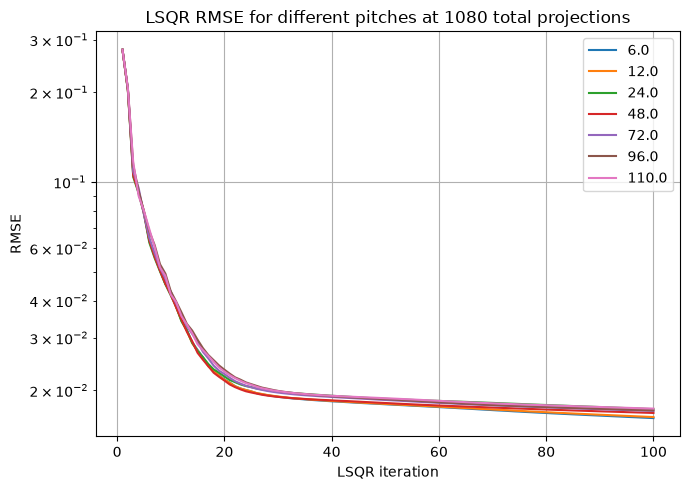

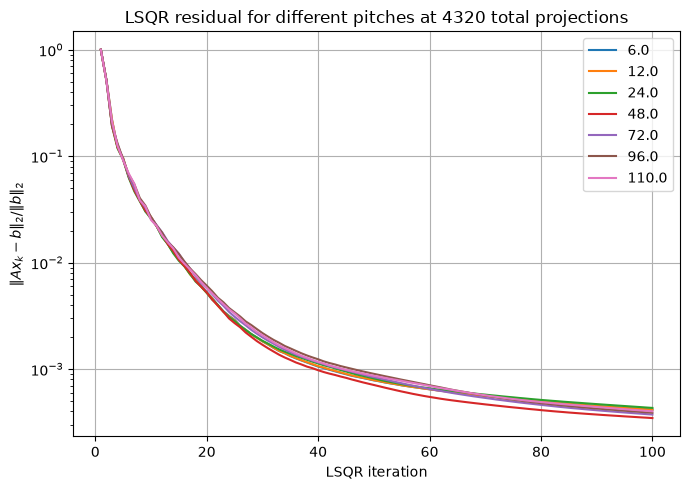

In [ ]:
# ============================================================
# D4b. Clean pitch sweep with fixed total projection count
# ============================================================

RUN_FIXED_TOTAL_PITCH_SWEEP = True
FIXED_TOTAL_PROJECTIONS = 1080
FIXED_TOTAL_PITCH_VALUES = [6.0, 12.0, 24.0, 48.0, 72.0, 96.0, 110.0]
fixed_total_summary_path = os.path.join(
    RESULTS_DIRECTORY, "pitch_fixed_total_summary.csv"
)
fixed_total_pitch_results = {}
fixed_total_rows = []

if RUN_FIXED_TOTAL_PITCH_SWEEP:
    for pitch_test in FIXED_TOTAL_PITCH_VALUES:
        #experiment_id = f"pitch_fixed_total_p{pitch_test:g}_n4320"
        experiment_id = f"pitch_fixed_total_p{pitch_test:g}_n{FIXED_TOTAL_PROJECTIONS}"
        print(f"Building/running {experiment_id}")
        problem = build_helical_problem(
            pitch_value=pitch_test,
            projections_per_turn_value=BASELINE_PROJECTIONS_PER_TURN,
            phantom_array_input=phantom_array,
            total_projections_value=FIXED_TOTAL_PROJECTIONS,
        )
        mismatch_diagnostics = [
            explicit_adjoint_mismatch(problem["operator"], seed=seed)
            for seed in range(5)
        ]
        mismatch_samples = [
            item["relative_mismatch"] for item in mismatch_diagnostics
        ]
        result = run_lsqr_with_diagnostics(
            operator_local=problem["operator"],
            data_local=problem["projection_data"],
            truth_local=problem["phantom"],
            initial_local=problem["image_geometry"].allocate(0.0),
            number_of_iterations_local=number_of_iterations,
            alpha=0.0,
            checkpoint_interval=1,
        )
        fixed_total_pitch_results[pitch_test] = {
            "experiment_id": experiment_id,
            "problem": problem,
            "result": result,
            "adjoint_mismatch_samples": mismatch_samples,
        }
        save_iteration_history(
            result=result,
            experiment_name=experiment_id,
            extra_metadata={
                "experiment_group": "pitch_fixed_total",
                "experiment_type": "pitch_fixed_total",
                "pitch_control": "fixed_total_projections",
                "algorithm": "LSQR",
                "pitch": pitch_test,
                "number_of_turns": problem["number_of_turns"],
                "projections_per_turn": problem["projections_per_turn"],
                "number_of_projections": problem["number_of_projections"],
                "relative_noise_level": 0.0,
                "noise_seed": np.nan,
                "initialisation": "zero",
            },
        )
        history = result["history"]
        best = history.loc[history["rmse"].idxmin()]
        final = history.iloc[-1]
        fixed_total_rows.append({
            "experiment_id": experiment_id,
            "experiment_type": "pitch_fixed_total",
            "pitch_control": "fixed_total_projections",
            "pitch": pitch_test,
            "number_of_turns": problem["number_of_turns"],
            "total_projections": problem["number_of_projections"],
            "effective_projections_per_turn": problem["projections_per_turn"],
            "algorithm": "LSQR",
            "noise_type": "none",
            "noise_level": 0.0,
            "initialisation": "zero",
            "alpha": 0.0,
            "max_iterations": number_of_iterations,
            "best_iteration": int(best["iteration"]),
            "best_rmse": float(best["rmse"]),
            "final_rmse": float(final["rmse"]),
            "best_relative_residual": float(best["relative_residual"]),
            "final_relative_residual": float(final["relative_residual"]),
            "best_relative_backprojected_residual": float(
                best["relative_backprojected_residual"]
            ),
            "final_relative_backprojected_residual": float(
                final["relative_backprojected_residual"]
            ),
            "adjoint_mismatch_mean": float(np.mean(mismatch_samples)),
            "adjoint_mismatch_std": float(np.std(mismatch_samples)),
            "adjoint_mismatch_max": float(np.max(mismatch_samples)),
        })
    fixed_total_pitch_summary = pd.DataFrame(fixed_total_rows)
    fixed_total_pitch_summary.to_csv(fixed_total_summary_path, index=False)
    print("Saved:", fixed_total_summary_path)
else:
    if not os.path.exists(fixed_total_summary_path):
        raise FileNotFoundError(
            "Fixed-total pitch sweep skipped but summary CSV was not found."
        )
    fixed_total_pitch_summary = pd.read_csv(fixed_total_summary_path)
    for _, row in fixed_total_pitch_summary.iterrows():
        pitch_test = float(row["pitch"])
        experiment_id = row["experiment_id"]
        history_path = os.path.join(
            HISTORY_DIRECTORY, f"{experiment_id}_history.csv"
        )
        history = pd.read_csv(history_path)
        fixed_total_pitch_results[pitch_test] = {
            "experiment_id": experiment_id,
            "problem": {
                "pitch": pitch_test,
                "number_of_turns": int(row["number_of_turns"]),
                "number_of_projections": int(row["total_projections"]),
                "projections_per_turn": float(
                    row["effective_projections_per_turn"]
                ),
            },
            "result": {"history": history},
            "adjoint_mismatch_mean": row["adjoint_mismatch_mean"],
            "adjoint_mismatch_std": row["adjoint_mismatch_std"],
        }
    print("Loaded:", fixed_total_summary_path)

display(fixed_total_pitch_summary)
plot_histories(
    fixed_total_pitch_results, "rmse", "RMSE",
    #"LSQR RMSE for different pitches at 4320 total projections",
    f"LSQR RMSE for different pitches at "
    f"{FIXED_TOTAL_PROJECTIONS} total projections"
)
plot_histories(
    fixed_total_pitch_results, "relative_residual",
    r"$\|Ax_k-b\|_2/\|b\|_2$",
    "LSQR residual for different pitches at 4320 total projections",
)


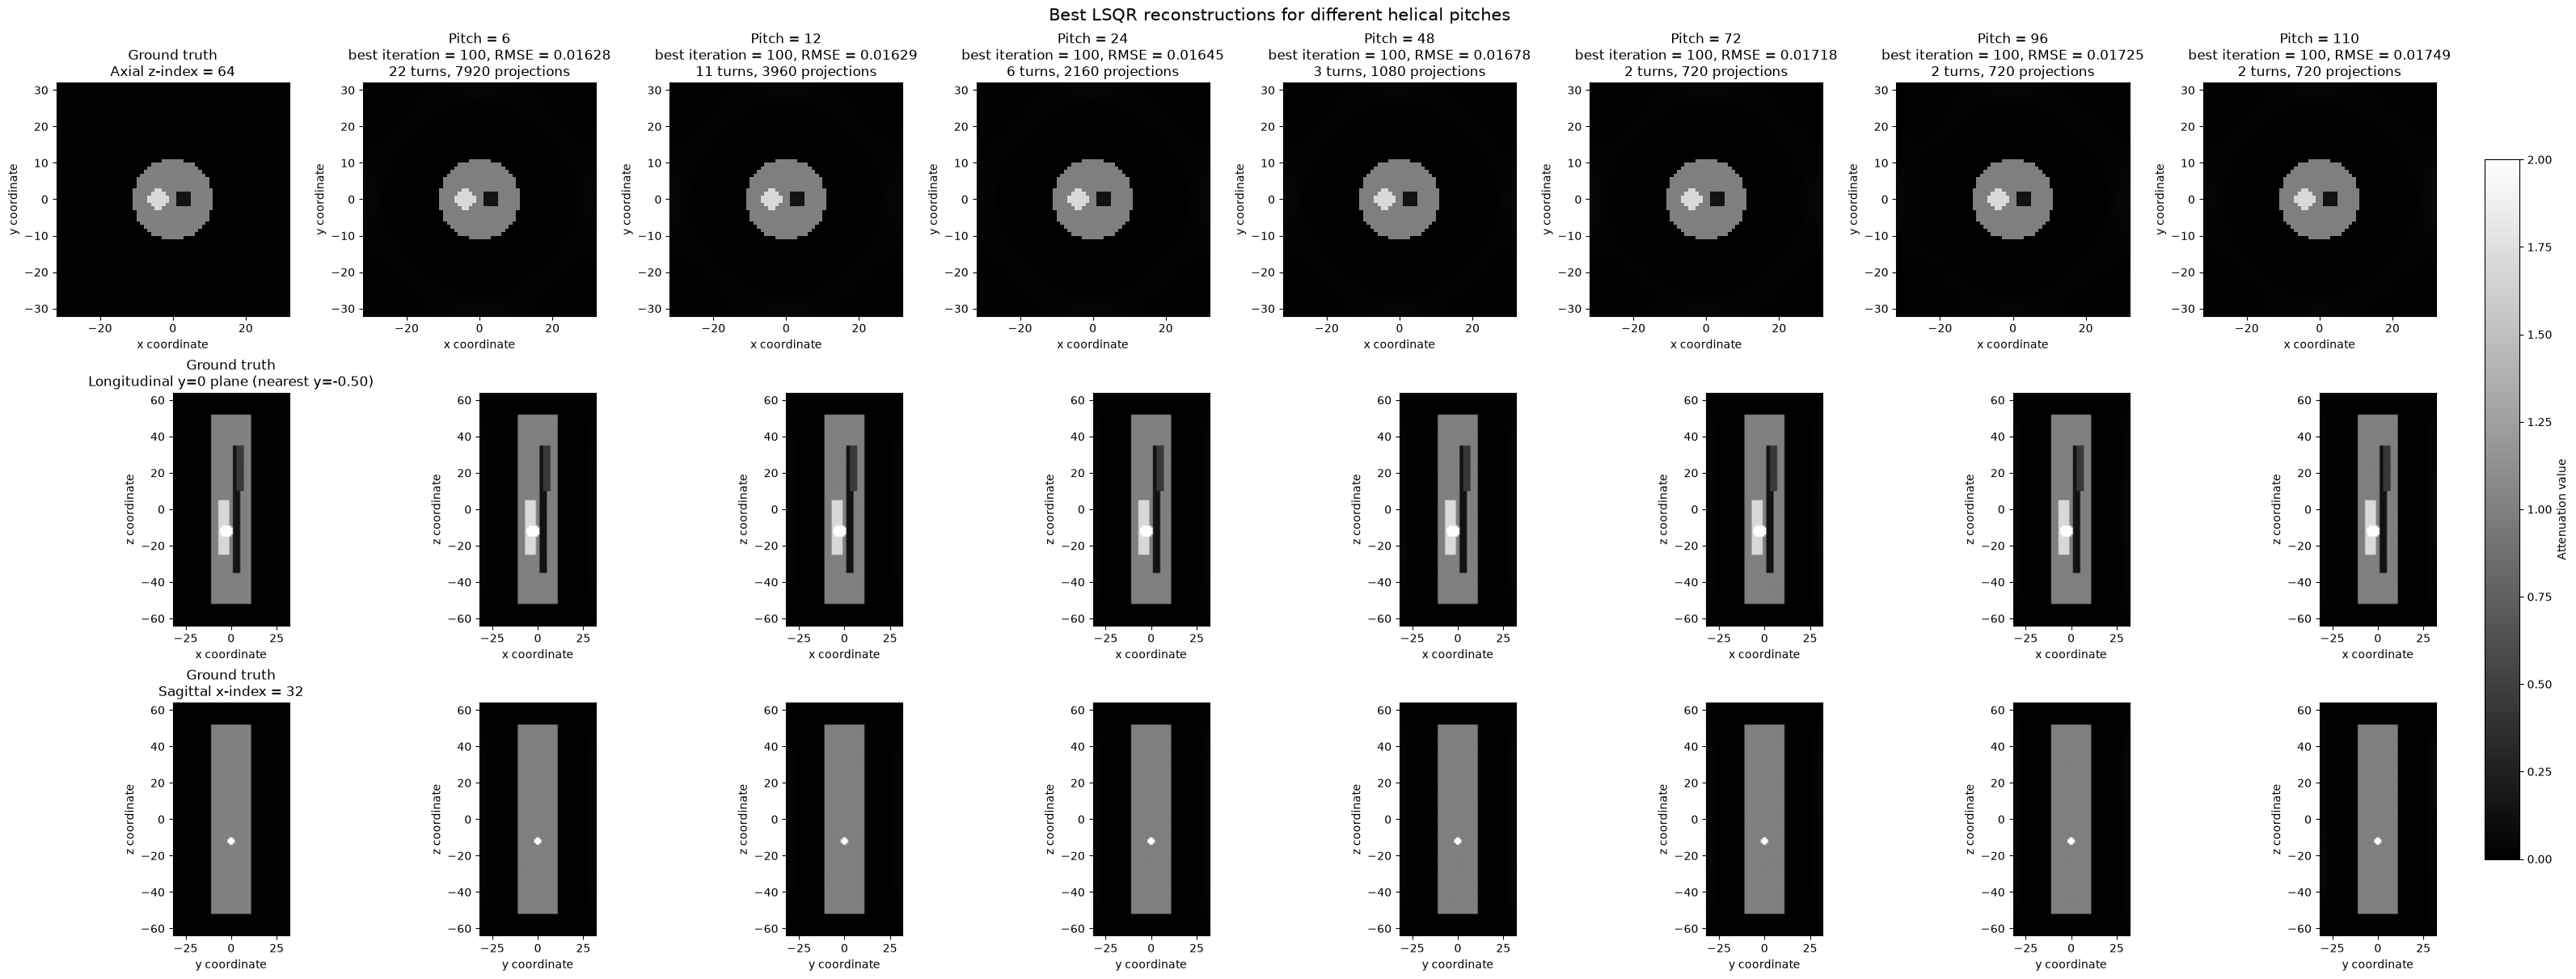

In [ ]:
# ============================================================
# Compare the best reconstructions for different helical pitches
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def plot_pitch_reconstruction_comparison(
    pitch_results,
    phantom_array,
    half_width,
    half_height,
):
    """
    Compare the ground truth and the best-RMSE LSQR reconstruction
    obtained for each helical pitch.

    The volume array order is assumed to be:
        (z, y, x)

    The displayed planes are:
        1. central axial slice    : fixed z;
        2. longitudinal y=0 slice: fixed y;
        3. central sagittal slice : fixed x.
    """

    # --------------------------------------------------------
    # 1. Check that the pitch reconstructions are available
    # --------------------------------------------------------
    if not pitch_results:
        raise ValueError(
            "pitch_results is empty. "
            "Run the D3 pitch sweep in the current kernel first."
        )

    # Sort pitch values numerically:
    # Sort numerically rather than relying on dictionary order.
    sorted_pitches = sorted(pitch_results.keys())

    # Convert the ground-truth phantom to a NumPy array.
    truth_array = np.asarray(
        phantom_array,
        dtype=np.float64,
    )

    # Array order is (z, y, x).
    nz, ny, nx = truth_array.shape

    # Select central axial/sagittal slices and the shared y=0 longitudinal slice.
    axial_index = nz // 2
    longitudinal_y0_index = y0_idx
    sagittal_index = nx // 2

    # --------------------------------------------------------
    # 2. Extract the best reconstruction for every pitch
    # --------------------------------------------------------
    reconstruction_arrays = {}

    for pitch in sorted_pitches:
        result = pitch_results[pitch]["result"]

        reconstruction_arrays[pitch] = np.asarray(
            result["best_reconstruction"].as_array(),
            dtype=np.float64,
        )

    # Use the same display range for the truth and every pitch.
    # This is essential for a fair visual comparison.
    vmin = float(np.min(truth_array))
    vmax = float(np.max(truth_array))

    # Physical coordinate extents used by imshow.
    axial_extent = [
        -half_width,
        half_width,
        -half_width,
        half_width,
    ]

    longitudinal_extent = [
        -half_width,
        half_width,
        -half_height,
        half_height,
    ]

    # One ground-truth column plus one column per pitch.
    number_of_columns = 1 + len(sorted_pitches)

    fig, axes = plt.subplots(
        3,
        number_of_columns,
        figsize=(4.0 * number_of_columns, 12.0),
        constrained_layout=True,
    )

    # Ensure axes is always a two-dimensional array.
    axes = np.asarray(axes).reshape(
        3,
        number_of_columns,
    )

    # --------------------------------------------------------
    # 3. Ground-truth column
    # --------------------------------------------------------

    # Axial: array indexing [z, y, x].
    reference_image = axes[0, 0].imshow(
        truth_array[axial_index, :, :],
        origin="lower",
        extent=axial_extent,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    axes[0, 0].set_title(
        f"Ground truth\nAxial z-index = {axial_index}"
    )

    # Longitudinal y=0 plane: fixed array axis 1, leaving (z, x).
    axes[1, 0].imshow(
        truth_array[:, longitudinal_y0_index, :],
        origin="lower",
        extent=longitudinal_extent,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    axes[1, 0].set_title(
        f"Ground truth\nLongitudinal y=0 plane "
        f"(nearest y={y0_coordinate:.2f})"
    )

    # Sagittal: fixed x, leaving dimensions (z, y).
    axes[2, 0].imshow(
        truth_array[:, :, sagittal_index],
        origin="lower",
        extent=longitudinal_extent,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    axes[2, 0].set_title(
        f"Ground truth\nSagittal x-index = {sagittal_index}"
    )

    # --------------------------------------------------------
    # 4. Reconstruction columns
    # --------------------------------------------------------
    for column_index, pitch in enumerate(
        sorted_pitches,
        start=1,
    ):
        reconstruction = reconstruction_arrays[pitch]
        result = pitch_results[pitch]["result"]
        problem = pitch_results[pitch]["problem"]

        best_iteration = result["best_iteration"]
        minimum_rmse = result["minimum_rmse"]
        number_of_turns = problem["number_of_turns"]
        number_of_projections = problem["number_of_projections"]

        column_title = (
            f"Pitch = {pitch:g}\n"
            f"best iteration = {best_iteration}, "
            f"RMSE = {minimum_rmse:.5f}\n"
            f"{number_of_turns} turns, "
            f"{number_of_projections} projections"
        )

        # Central axial reconstruction.
        axes[0, column_index].imshow(
            reconstruction[axial_index, :, :],
            origin="lower",
            extent=axial_extent,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )

        axes[0, column_index].set_title(column_title)

        # Longitudinal reconstruction nearest physical y=0.
        axes[1, column_index].imshow(
            reconstruction[:, longitudinal_y0_index, :],
            origin="lower",
            extent=longitudinal_extent,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )

        # Central sagittal reconstruction.
        axes[2, column_index].imshow(
            reconstruction[:, :, sagittal_index],
            origin="lower",
            extent=longitudinal_extent,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )

    # --------------------------------------------------------
    # 5. Axis labels
    # --------------------------------------------------------
    for column_index in range(number_of_columns):
        axes[0, column_index].set_xlabel("x coordinate")
        axes[0, column_index].set_ylabel("y coordinate")

        axes[1, column_index].set_xlabel("x coordinate")
        axes[1, column_index].set_ylabel("z coordinate")

        axes[2, column_index].set_xlabel("y coordinate")
        axes[2, column_index].set_ylabel("z coordinate")

    # One shared colour bar ensures that all panels use
    # exactly the same attenuation-value scale.
    colour_bar = fig.colorbar(
        reference_image,
        ax=axes,
        shrink=0.82,
        pad=0.02,
    )

    colour_bar.set_label("Attenuation value")

    fig.suptitle(
        "Best LSQR reconstructions for different helical pitches",
        fontsize=15,
    )

    plt.show()


# ------------------------------------------------------------
# Run the comparison
# ------------------------------------------------------------
plot_pitch_reconstruction_comparison(
    pitch_results=pitch_results,
    phantom_array=phantom_array,
    half_width=half_width,
    half_height=half_height,
)

## 7. Noisy pitch sweep

Repeat the pitch comparison after adding controlled Gaussian projection noise, allowing the preferred stopping iteration and minimum reconstruction error to be compared across acquisition geometries.


In [ ]:
print("Available pitches in pitch_results:")
print(sorted(pitch_results.keys()))

Available pitches in pitch_results:
[6.0, 12.0, 24.0, 48.0, 72.0, 96.0, 110.0]


In [ ]:
# ============================================================
# D3b. Noisy pitch sweep
# Run every pitch using the specified Gaussian noise level
# ============================================================

RUN_NOISY_PITCH_SWEEP = True

# Examples:
# 0.005 = 0.5%
# 0.01  = 1%
# 0.02  = 2%
#
# If relative_noise_level has already been defined above,
# it does not need to be redefined here.
# relative_noise_level = 0.005


if RUN_NOISY_PITCH_SWEEP:

    # pitch_results must already contain the clean pitch-sweep
    # problem and reconstruction result for each pitch.
    if (
        "pitch_results" not in globals()
        or not pitch_results
    ):
        raise RuntimeError(
            "pitch_results is not available. "
            "Run the clean D3 pitch sweep first."
        )

    noisy_pitch_results = {}
    noisy_pitch_rows = []

    # Process pitch values in ascending numerical order.
    for pitch_test in sorted(pitch_results.keys()):

        print(
            f"Running noisy pitch experiment: "
            f"pitch={pitch_test:g}, "
            f"noise={100 * relative_noise_level:g}%"
        )

        # ----------------------------------------------------
        # 1. Retrieve the previously constructed CT problem for this pitch.
        # ----------------------------------------------------
        problem = pitch_results[pitch_test]["problem"]

        clean_projection_data = problem["projection_data"]

        clean_data_array = np.asarray(
            clean_projection_data.as_array(),
            dtype=np.float64,
        )

        # ----------------------------------------------------
        # 2. Generate a reproducible Gaussian-noise realisation.
        # ----------------------------------------------------
        #
        # Use a different seed for each pitch,
        # while preserving reproducibility across reruns.
        noise_seed = 42 + int(round(100 * pitch_test))

        rng = np.random.default_rng(noise_seed)

        noise_array = rng.standard_normal(
            clean_data_array.shape
        )

        # ----------------------------------------------------
        # 3. Scale the noise to the prescribed relative level.
        #
        # ||noise||_2 / ||b||_2 = relative_noise_level
        # ----------------------------------------------------
        clean_data_norm = np.linalg.norm(
            clean_data_array.ravel()
        )

        unscaled_noise_norm = np.linalg.norm(
            noise_array.ravel()
        )

        noise_array *= (
            relative_noise_level
            * clean_data_norm
            / max(unscaled_noise_norm, 1e-30)
        )

        # Record the realised relative noise level as a check.
        actual_relative_noise = (
            np.linalg.norm(noise_array.ravel())
            / max(clean_data_norm, 1e-30)
        )

        # ----------------------------------------------------
        # 4. Construct the noisy CIL projection data.
        # ----------------------------------------------------
        noisy_projection_data = (
            clean_projection_data.copy()
        )

        noisy_projection_data.fill(
            (
                clean_data_array
                + noise_array
            ).astype(np.float32)
        )

        # ----------------------------------------------------
        # 5. Run LSQR from a zero initial image.
        # ----------------------------------------------------
        initial = problem[
            "image_geometry"
        ].allocate(0.0)

        noisy_result = run_lsqr_with_diagnostics(
            operator_local=problem["operator"],
            data_local=noisy_projection_data,
            truth_local=problem["phantom"],
            initial_local=initial,
            number_of_iterations_local=(
                number_of_iterations
            ),
            alpha=0.0,
            checkpoint_interval=1,
        )


        # ----------------------------------------------------
        # Save the complete iteration history.
        # ----------------------------------------------------

        noise_pct = 100 * relative_noise_level

        experiment_name = (
            f"pitch_{pitch_test:g}_"
            f"noise_{noise_pct:g}pct_"
            f"seed{noise_seed}"
        )

        save_iteration_history(
            result=noisy_result,
            experiment_name=experiment_name,
            extra_metadata={
                "experiment_group": "noisy_pitch",
                "pitch_control": "fixed_projections_per_turn",
                "algorithm": "LSQR",
                "pitch": pitch_test,
                "number_of_turns": problem["number_of_turns"],
                "number_of_projections": problem["number_of_projections"],
                "relative_noise_level": relative_noise_level,
                "actual_relative_noise": actual_relative_noise,
                "noise_seed": noise_seed,
            },
        )





        
        # ----------------------------------------------------
        # 6. Store the complete in-memory result.
        # ----------------------------------------------------
        noisy_pitch_results[pitch_test] = {
            "problem": problem,
            "result": noisy_result,
            "noisy_projection_data": (
                noisy_projection_data
            ),
            "noise_array": noise_array,
            "relative_noise_level": (
                relative_noise_level
            ),
            "actual_relative_noise": (
                actual_relative_noise
            ),
            "noise_seed": noise_seed,
        }

        # ----------------------------------------------------
        # 7. Append one row to the summary table.
        # ----------------------------------------------------
        noisy_pitch_rows.append(
            summarise_result(
                (
                    f"pitch_{pitch_test:g}_"
                    f"noise_"
                    f"{100 * relative_noise_level:g}pct"
                ),
                noisy_result,
                extra={
                    "pitch": pitch_test,
                    "relative_noise_level": (
                        relative_noise_level
                    ),
                    "actual_relative_noise": (
                        actual_relative_noise
                    ),
                    "number_of_turns": (
                        problem["number_of_turns"]
                    ),
                    "number_of_projections": (
                        problem["number_of_projections"]
                    ),
                    "noise_seed": noise_seed,
                },
            )
        )

        print(
            f"  actual relative noise = "
            f"{actual_relative_noise:.8f}"
        )

        print(
            f"  best iteration = "
            f"{noisy_result['best_iteration']}"
        )

        print(
            f"  minimum RMSE = "
            f"{noisy_result['minimum_rmse']:.8f}"
        )

    # Assemble the noisy pitch-sweep summary.
    noisy_pitch_summary = pd.DataFrame(
        noisy_pitch_rows
    )

    display(noisy_pitch_summary)

Running noisy pitch experiment: pitch=6, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_6_noise_1pct_seed642_history.csv
  actual relative noise = 0.01000000
  best iteration = 51
  minimum RMSE = 0.01799615
Running noisy pitch experiment: pitch=12, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_12_noise_1pct_seed1242_history.csv
  actual relative noise = 0.01000000
  best iteration = 44
  minimum RMSE = 0.01853724
Running noisy pitch experiment: pitch=24, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_24_noise_1pct_seed2442_history.csv
  actual relative noise = 0.01000000
  best iteration = 38
  minimum RMSE = 0.01905895
Running noisy pitch experiment: pitch=48, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_48_noise_1pct_seed4842_history.csv
  actual relative noise = 0.01000000
  best iteration = 31
  minimum RMSE = 0.01969245
Running noisy pitch

,experiment,best_iteration,minimum_rmse,relative_residual_at_best,backprojected_residual_at_best,final_rmse,near_optimal_start,near_optimal_end,pitch,relative_noise_level,actual_relative_noise,number_of_turns,number_of_projections,noise_seed
0,pitch_6_noise_1pct,51,0.017996,0.010046,0.000398,0.035687,44,54,6.0,0.01,0.01,22,7920,642
1,pitch_12_noise_1pct,44,0.018537,0.010035,0.000357,0.042825,37,49,12.0,0.01,0.01,11,3960,1242
2,pitch_24_noise_1pct,38,0.019059,0.010029,0.000347,0.049021,29,43,24.0,0.01,0.01,6,2160,2442
3,pitch_48_noise_1pct,31,0.019692,0.010041,0.000487,0.050198,26,37,48.0,0.01,0.01,3,1080,4842
4,pitch_72_noise_1pct,30,0.020698,0.010065,0.000520,0.048435,26,35,72.0,0.01,0.01,2,720,7242
5,pitch_96_noise_1pct,31,0.020887,0.010074,0.000578,0.044530,28,36,96.0,0.01,0.01,2,720,9642
6,pitch_110_noise_1pct,31,0.020882,0.010047,0.000574,0.043707,27,35,110.0,0.01,0.01,2,720,11042


## 8. Noise level, semi-convergence, and seed robustness

Vary the relative Gaussian-noise level on the baseline problem, examine LSQR semi-convergence, and repeat selected cases with additional random seeds to check that the reported behaviour is representative rather than specific to one noise realisation.


In [ ]:
# ============================================================
# D5. Controlled Gaussian noise-level sweep on the baseline problem
# ============================================================

GAUSSIAN_NOISE_LEVELS = [0.0, 0.0025, 0.005, 0.01, 0.02]
GAUSSIAN_NOISE_SEED = 42

# Use one deterministic Gaussian direction for every non-zero level.
noise_sweep_rng = np.random.default_rng(GAUSSIAN_NOISE_SEED)
baseline_clean_array = np.asarray(projection_data.as_array(), dtype=np.float64)
fixed_noise_direction = noise_sweep_rng.standard_normal(baseline_clean_array.shape)
fixed_noise_direction /= max(
    np.linalg.norm(fixed_noise_direction.ravel()), 1e-30
)
baseline_clean_norm = np.linalg.norm(baseline_clean_array.ravel())
noise_sweep_results = {}

for noise_level in GAUSSIAN_NOISE_LEVELS:
    if np.isclose(noise_level, 0.0):
        data_for_level = projection_data
        result_for_level = baseline_result
    elif np.isclose(noise_level, relative_noise_level):
        # The existing 1% baseline uses the same seed and scaling.
        data_for_level = noisy_projection_data
        result_for_level = baseline_noisy_result
    else:
        scaled_noise = noise_level * baseline_clean_norm * fixed_noise_direction
        data_for_level = projection_data.copy()
        data_for_level.fill(
            (baseline_clean_array + scaled_noise).astype(np.float32)
        )
        result_for_level = run_lsqr_with_diagnostics(
            operator_local=operator,
            data_local=data_for_level,
            truth_local=phantom,
            initial_local=image_geometry.allocate(0.0),
            number_of_iterations_local=number_of_iterations,
            alpha=0.0,
            checkpoint_interval=1,
        )

    experiment_id = (
        f"noise_sweep_p{BASELINE_PITCH:g}_"
        f"ppt{BASELINE_PROJECTIONS_PER_TURN}_noise_"
        + str(noise_level).replace(".", "p")
    )
    noise_sweep_results[noise_level] = {
        "experiment_id": experiment_id,
        "result": result_for_level,
        "noise_level": noise_level,
        "data": data_for_level,
    }
    save_iteration_history(
        result=result_for_level,
        experiment_name=experiment_id,
        extra_metadata={
            "experiment_group": "gaussian_noise_sweep",
            "algorithm": "LSQR",
            "pitch": pitch,
            "projections_per_turn": projections_per_turn,
            "number_of_projections": number_of_projections,
            "relative_noise_level": noise_level,
            "noise_seed": GAUSSIAN_NOISE_SEED,
            "initialisation": "zero",
        },
    )


Saved iteration history: lsqr_validation_results_pitch48/histories/noise_sweep_p48_ppt360_noise_0p0_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_sweep_p48_ppt360_noise_0p0025_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_sweep_p48_ppt360_noise_0p005_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_sweep_p48_ppt360_noise_0p01_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_sweep_p48_ppt360_noise_0p02_history.csv


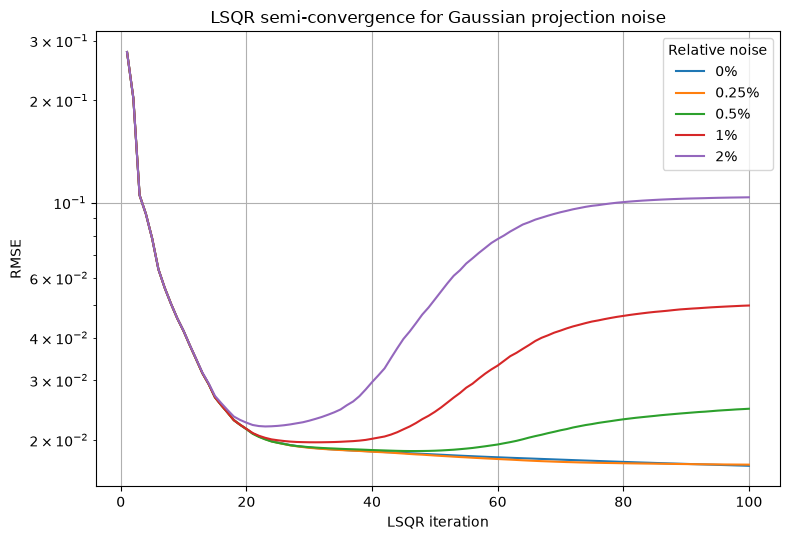

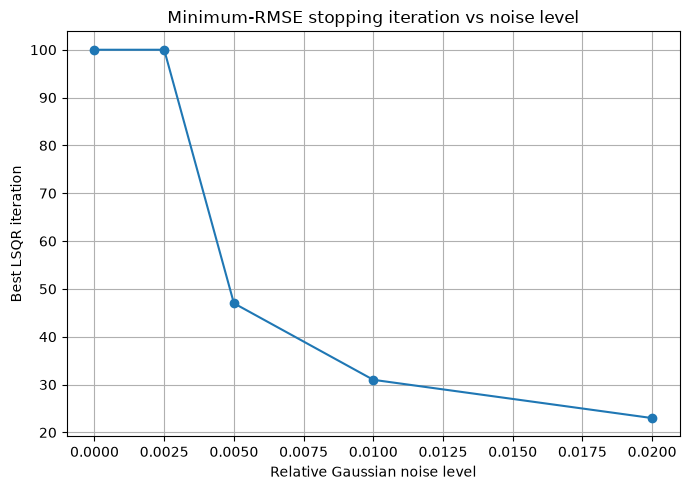

,noise_level,best_iteration,best_rmse
0,0.0000,100,0.016779
1,0.0025,100,0.016913
2,0.0050,47,0.018545
3,0.0100,31,0.019678
4,0.0200,23,0.021911


Observed semi-convergence trend: monotonic earlier-or-equal stopping with increasing noise
Saved: lsqr_validation_results_pitch48/figures/noise_sweep_rmse_vs_iteration.png
Saved: lsqr_validation_results_pitch48/figures/noise_sweep_best_iteration_vs_noise.png


In [ ]:
# ============================================================
# D5b. Semi-convergence figures for the Gaussian noise sweep
# ============================================================

FIGURES_DIRECTORY = os.path.join(RESULTS_DIRECTORY, "figures")
os.makedirs(FIGURES_DIRECTORY, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
for noise_level in GAUSSIAN_NOISE_LEVELS:
    history = noise_sweep_results[noise_level]["result"]["history"]
    ax.semilogy(
        history["iteration"], history["rmse"],
        label=f"{100 * noise_level:g}%",
    )
ax.set_xlabel("LSQR iteration")
ax.set_ylabel("RMSE")
ax.set_title("LSQR semi-convergence for Gaussian projection noise")
ax.grid(True)
ax.legend(title="Relative noise")
fig.tight_layout()
rmse_figure_path = os.path.join(
    FIGURES_DIRECTORY, "noise_sweep_rmse_vs_iteration.png"
)
fig.savefig(rmse_figure_path, dpi=300, bbox_inches="tight")
plt.show()

best_iterations = np.asarray([
    noise_sweep_results[level]["result"]["best_iteration"]
    for level in GAUSSIAN_NOISE_LEVELS
], dtype=int)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(GAUSSIAN_NOISE_LEVELS, best_iterations, marker="o")
ax.set_xlabel("Relative Gaussian noise level")
ax.set_ylabel("Best LSQR iteration")
ax.set_title("Minimum-RMSE stopping iteration vs noise level")
ax.grid(True)
fig.tight_layout()
best_iteration_figure_path = os.path.join(
    FIGURES_DIRECTORY, "noise_sweep_best_iteration_vs_noise.png"
)
fig.savefig(best_iteration_figure_path, dpi=300, bbox_inches="tight")
plt.show()

differences = np.diff(best_iterations)
if np.all(differences <= 0):
    noise_trend = "monotonic earlier-or-equal stopping with increasing noise"
elif np.sum(differences <= 0) >= len(differences) - 1:
    noise_trend = "approximately monotonic earlier stopping with increasing noise"
else:
    noise_trend = "no clear monotonic earlier-stopping trend"

noise_sweep_stopping_summary = pd.DataFrame({
    "noise_level": GAUSSIAN_NOISE_LEVELS,
    "best_iteration": best_iterations,
    "best_rmse": [
        noise_sweep_results[level]["result"]["minimum_rmse"]
        for level in GAUSSIAN_NOISE_LEVELS
    ],
})
display(noise_sweep_stopping_summary)
print("Observed semi-convergence trend:", noise_trend)
print("Saved:", rmse_figure_path)
print("Saved:", best_iteration_figure_path)


Running noise_0p005_seed123
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_0p005_seed123_history.csv
Running noise_0p005_seed456
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_0p005_seed456_history.csv
Running noise_0p01_seed123
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_0p01_seed123_history.csv
Running noise_0p01_seed456
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_0p01_seed456_history.csv
Running noise_0p02_seed123
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_0p02_seed123_history.csv
Running noise_0p02_seed456
Saved iteration history: lsqr_validation_results_pitch48/histories/noise_0p02_seed456_history.csv
Saved: lsqr_validation_results_pitch48/noise_seed_robustness_summary.csv


,noise_level,number_of_realisations,mean_best_iteration,std_best_iteration,mean_minimum_rmse,std_minimum_rmse
0,0.005,3,46.333333,0.57735,0.018560,0.000017
1,0.010,3,31.000000,0.00000,0.019691,0.000014
2,0.020,3,23.000000,0.00000,0.021936,0.000024


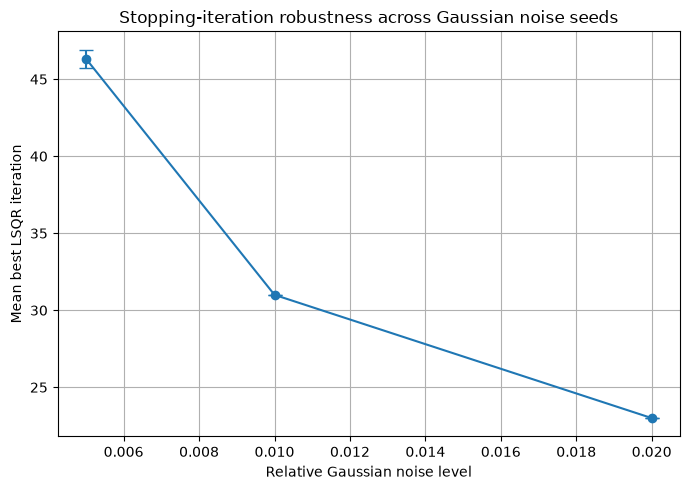

Saved: lsqr_validation_results_pitch48/figures/noise_seed_best_iteration_mean_std.png


In [ ]:
# ============================================================
# D5c. Gaussian-noise seed robustness
# ============================================================

RUN_NOISE_SEED_ROBUSTNESS = True
ROBUSTNESS_NOISE_LEVELS = [0.005, 0.01, 0.02]
PRIMARY_NOISE_SEED = GAUSSIAN_NOISE_SEED
ADDITIONAL_NOISE_SEEDS = [123, 456]
noise_seed_summary_path = os.path.join(
    RESULTS_DIRECTORY, "noise_seed_robustness_summary.csv"
)
noise_seed_robustness_results = {}
noise_seed_realisation_rows = []

if RUN_NOISE_SEED_ROBUSTNESS:
    clean_array = np.asarray(projection_data.as_array(), dtype=np.float64)
    clean_norm = np.linalg.norm(clean_array.ravel())

    # Include the existing primary realization without rerunning it.
    for noise_level in ROBUSTNESS_NOISE_LEVELS:
        primary_result = noise_sweep_results[noise_level]["result"]
        noise_seed_realisation_rows.append({
            "noise_level": noise_level,
            "noise_seed": PRIMARY_NOISE_SEED,
            "best_iteration": primary_result["best_iteration"],
            "minimum_rmse": primary_result["minimum_rmse"],
        })

    # Exactly six new LSQR runs: two additional seeds at three levels.
    for noise_level in ROBUSTNESS_NOISE_LEVELS:
        level_text = str(noise_level).replace(".", "p")
        for noise_seed in ADDITIONAL_NOISE_SEEDS:
            experiment_id = f"noise_{level_text}_seed{noise_seed}"
            print(f"Running {experiment_id}")
            rng = np.random.default_rng(noise_seed)
            noise_array = rng.standard_normal(clean_array.shape)
            noise_array *= (
                noise_level * clean_norm
                / max(np.linalg.norm(noise_array.ravel()), 1e-30)
            )
            actual_relative_noise = (
                np.linalg.norm(noise_array.ravel()) / max(clean_norm, 1e-30)
            )
            data_for_seed = projection_data.copy()
            data_for_seed.fill((clean_array + noise_array).astype(np.float32))
            result = run_lsqr_with_diagnostics(
                operator_local=operator,
                data_local=data_for_seed,
                truth_local=phantom,
                initial_local=image_geometry.allocate(0.0),
                number_of_iterations_local=number_of_iterations,
                alpha=0.0,
                checkpoint_interval=1,
            )
            noise_seed_robustness_results[(noise_level, noise_seed)] = {
                "experiment_id": experiment_id,
                "result": result,
                "noise_level": noise_level,
                "noise_seed": noise_seed,
                "actual_relative_noise": actual_relative_noise,
            }
            save_iteration_history(
                result=result,
                experiment_name=experiment_id,
                extra_metadata={
                    "experiment_group": "noise_seed_robustness",
                    "experiment_type": "noise_seed_robustness",
                    "algorithm": "LSQR",
                    "pitch": pitch,
                    "projections_per_turn": projections_per_turn,
                    "number_of_projections": number_of_projections,
                    "relative_noise_level": noise_level,
                    "actual_relative_noise": actual_relative_noise,
                    "noise_seed": noise_seed,
                    "initialisation": "zero",
                },
            )
            noise_seed_realisation_rows.append({
                "noise_level": noise_level,
                "noise_seed": noise_seed,
                "best_iteration": result["best_iteration"],
                "minimum_rmse": result["minimum_rmse"],
            })

    noise_seed_realisations = pd.DataFrame(noise_seed_realisation_rows)
    noise_seed_robustness_summary = (
        noise_seed_realisations.groupby("noise_level", as_index=False)
        .agg(
            number_of_realisations=("noise_seed", "count"),
            mean_best_iteration=("best_iteration", "mean"),
            std_best_iteration=("best_iteration", "std"),
            mean_minimum_rmse=("minimum_rmse", "mean"),
            std_minimum_rmse=("minimum_rmse", "std"),
        )
    )
    noise_seed_robustness_summary.to_csv(
        noise_seed_summary_path, index=False
    )
    print("Saved:", noise_seed_summary_path)
else:
    if not os.path.exists(noise_seed_summary_path):
        raise FileNotFoundError(
            "Noise-seed robustness skipped but summary CSV was not found."
        )
    noise_seed_robustness_summary = pd.read_csv(noise_seed_summary_path)
    for noise_level in ROBUSTNESS_NOISE_LEVELS:
        level_text = str(noise_level).replace(".", "p")
        for noise_seed in ADDITIONAL_NOISE_SEEDS:
            experiment_id = f"noise_{level_text}_seed{noise_seed}"
            history_path = os.path.join(
                HISTORY_DIRECTORY, f"{experiment_id}_history.csv"
            )
            history = pd.read_csv(history_path)
            noise_seed_robustness_results[(noise_level, noise_seed)] = {
                "experiment_id": experiment_id,
                "result": {"history": history},
                "noise_level": noise_level,
                "noise_seed": noise_seed,
                "actual_relative_noise": float(
                    history["actual_relative_noise"].iloc[0]
                ),
            }
    print("Loaded:", noise_seed_summary_path)

display(noise_seed_robustness_summary)
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    noise_seed_robustness_summary["noise_level"],
    noise_seed_robustness_summary["mean_best_iteration"],
    yerr=noise_seed_robustness_summary["std_best_iteration"],
    marker="o", capsize=5,
)
ax.set_xlabel("Relative Gaussian noise level")
ax.set_ylabel("Mean best LSQR iteration")
ax.set_title("Stopping-iteration robustness across Gaussian noise seeds")
ax.grid(True)
fig.tight_layout()
noise_seed_figure_path = os.path.join(
    FIGURES_DIRECTORY, "noise_seed_best_iteration_mean_std.png"
)
fig.savefig(noise_seed_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", noise_seed_figure_path)


## 9. Sampling and noise summaries

Assemble the clean and noisy sampling results into common summary tables and produce the comparison plots used to assess changes in minimum RMSE and oracle-best stopping iteration.


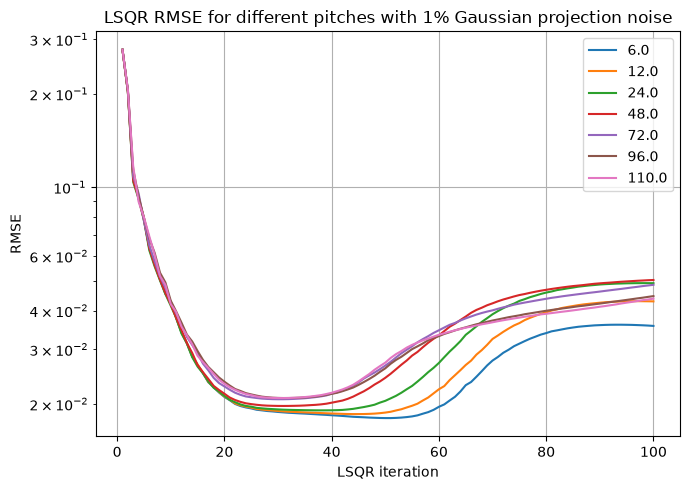

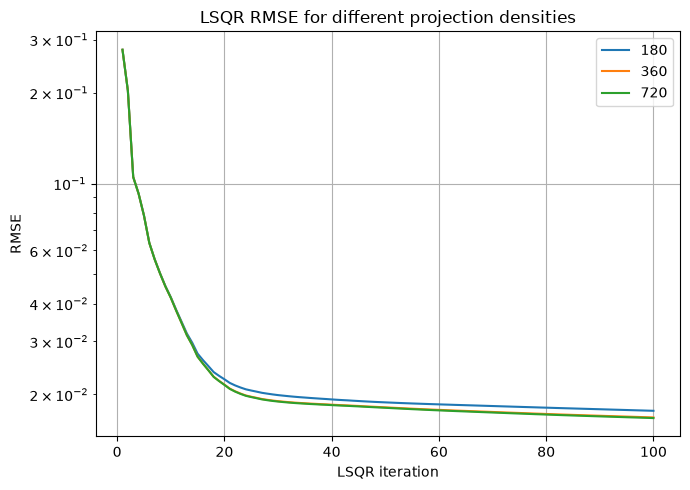

In [ ]:
# ============================================================
# Final sampling plots
# ============================================================

# Noisy pitch experiment
plot_histories(
    noisy_pitch_results,
    metric="rmse",
    ylabel="RMSE",
    title=(
        "LSQR RMSE for different pitches "
        f"with {100 * relative_noise_level:g}% "
        "Gaussian projection noise"
    ),
)


# Projection-density experiment
plot_histories(
    projection_results,
    metric="rmse",
    ylabel="RMSE",
    title="LSQR RMSE for different projection densities",
)

## 10. Additional noisy sampling experiments

Extend the noisy analysis to projection-density and fixed-total-projection settings. These controlled comparisons help distinguish the effects of measurement density, pitch, and noise on reconstruction accuracy and stopping behaviour.


In [ ]:
# ============================================================
# D4c. Noisy projection-density sweep
# Fixed:
#   pitch = baseline pitch = 48
#   Gaussian projection noise = 1%
#
# Compare:
#   180 / 360 / 720 projections per turn
#
# Each noisy case is generated from the corresponding clean
# problem in projection_results.
# ============================================================

RUN_NOISY_PROJECTION_DENSITY_SWEEP = True

NOISY_PPT_VALUES = [180, 360, 720]
NOISY_PPT_PITCH = BASELINE_PITCH
NOISY_PPT_NOISE_LEVEL = 0.01
NOISY_PPT_NOISE_SEED = 42

noisy_projection_density_results = {}
noisy_projection_density_rows = []


if RUN_NOISY_PROJECTION_DENSITY_SWEEP:

    if (
        "projection_results" not in globals()
        or not projection_results
    ):
        raise RuntimeError(
            "projection_results is not available. "
            "Run the clean projection-density sweep first."
        )

    for ppt_test in NOISY_PPT_VALUES:

        print(
            "\n"
            + "=" * 72
        )

        print(
            f"Running noisy projection-density experiment: "
            f"pitch={NOISY_PPT_PITCH:g}, "
            f"ppt={ppt_test}, "
            f"noise={100 * NOISY_PPT_NOISE_LEVEL:g}%"
        )

        # ----------------------------------------------------
        # 1. Reuse the corresponding clean CT problem
        # ----------------------------------------------------

        problem = projection_results[
            ppt_test
        ]["problem"]

        clean_projection_data = problem[
            "projection_data"
        ]

        clean_array = np.asarray(
            clean_projection_data.as_array(),
            dtype=np.float64,
        )

        clean_norm = np.linalg.norm(
            clean_array.ravel()
        )

        # ----------------------------------------------------
        # 2. Generate deterministic Gaussian noise
        #
        # ||noise||_2 / ||b||_2 = 0.01
        # ----------------------------------------------------

        rng = np.random.default_rng(
            NOISY_PPT_NOISE_SEED
        )

        noise_direction = rng.standard_normal(
            clean_array.shape
        )

        noise_direction /= max(
            np.linalg.norm(
                noise_direction.ravel()
            ),
            1e-30,
        )

        noise_array = (
            NOISY_PPT_NOISE_LEVEL
            * clean_norm
            * noise_direction
        )

        actual_relative_noise = (
            np.linalg.norm(
                noise_array.ravel()
            )
            / max(
                clean_norm,
                1e-30,
            )
        )

        noisy_projection_data = (
            clean_projection_data.copy()
        )

        noisy_projection_data.fill(
            (
                clean_array
                + noise_array
            ).astype(np.float32)
        )

        print(
            f"Actual relative noise = "
            f"{actual_relative_noise:.8f}"
        )

        # ----------------------------------------------------
        # 3. Run LSQR
        # ----------------------------------------------------

        initial = problem[
            "image_geometry"
        ].allocate(0.0)

        noisy_result = run_lsqr_with_diagnostics(
            operator_local=problem["operator"],
            data_local=noisy_projection_data,
            truth_local=problem["phantom"],
            initial_local=initial,
            number_of_iterations_local=(
                number_of_iterations
            ),
            alpha=0.0,
            checkpoint_interval=1,
        )

        # ----------------------------------------------------
        # 4. Save result
        # ----------------------------------------------------

        experiment_id = (
            f"projection_density_"
            f"p{NOISY_PPT_PITCH:g}_"
            f"ppt{ppt_test}_"
            f"noise_1pct_"
            f"seed{NOISY_PPT_NOISE_SEED}"
        )

        noisy_projection_density_results[
            ppt_test
        ] = {
            "experiment_id":
                experiment_id,

            "problem":
                problem,

            "result":
                noisy_result,

            "noisy_projection_data":
                noisy_projection_data,

            "noise_array":
                noise_array,

            "relative_noise_level":
                NOISY_PPT_NOISE_LEVEL,

            "actual_relative_noise":
                actual_relative_noise,

            "noise_seed":
                NOISY_PPT_NOISE_SEED,
        }

        save_iteration_history(
            result=noisy_result,
            experiment_name=experiment_id,
            extra_metadata={
                "experiment_group":
                    "projection_density_noisy",

                "experiment_type":
                    "projection_density_noisy",

                "algorithm":
                    "LSQR",

                "pitch":
                    NOISY_PPT_PITCH,

                "projections_per_turn":
                    ppt_test,

                "number_of_turns":
                    problem["number_of_turns"],

                "number_of_projections":
                    problem["number_of_projections"],

                "relative_noise_level":
                    NOISY_PPT_NOISE_LEVEL,

                "actual_relative_noise":
                    actual_relative_noise,

                "noise_seed":
                    NOISY_PPT_NOISE_SEED,

                "initialisation":
                    "zero",
            },
        )

        # ----------------------------------------------------
        # 5. Summary row
        # ----------------------------------------------------

        history = noisy_result["history"]

        best = history.loc[
            history["rmse"].idxmin()
        ]

        final = history.iloc[-1]

        noisy_projection_density_rows.append(
            {
                "pitch":
                    NOISY_PPT_PITCH,

                "projections_per_turn":
                    ppt_test,

                "number_of_turns":
                    problem["number_of_turns"],

                "number_of_projections":
                    problem["number_of_projections"],

                "noise_level":
                    NOISY_PPT_NOISE_LEVEL,

                "actual_relative_noise":
                    actual_relative_noise,

                "noise_seed":
                    NOISY_PPT_NOISE_SEED,

                "best_iteration":
                    int(best["iteration"]),

                "minimum_rmse":
                    float(best["rmse"]),

                "final_rmse":
                    float(final["rmse"]),

                "relative_residual_at_best":
                    float(
                        best[
                            "relative_residual"
                        ]
                    ),

                "backprojected_residual_at_best":
                    float(
                        best[
                            "relative_backprojected_residual"
                        ]
                    ),
            }
        )

        print(
            f"Best iteration = "
            f"{int(best['iteration'])}"
        )

        print(
            f"Minimum RMSE = "
            f"{float(best['rmse']):.8f}"
        )


    noisy_projection_density_summary = (
        pd.DataFrame(
            noisy_projection_density_rows
        )
        .sort_values(
            "projections_per_turn"
        )
        .reset_index(drop=True)
    )

    display(
        noisy_projection_density_summary
    )

    noisy_projection_density_summary_path = (
        os.path.join(
            RESULTS_DIRECTORY,
            "projection_density_noise_1pct_summary.csv",
        )
    )

    noisy_projection_density_summary.to_csv(
        noisy_projection_density_summary_path,
        index=False,
    )

    print(
        "Saved:",
        noisy_projection_density_summary_path,
    )


Running noisy projection-density experiment: pitch=48, ppt=180, noise=1%
Actual relative noise = 0.01000000
Saved iteration history: lsqr_validation_results_pitch48/histories/projection_density_p48_ppt180_noise_1pct_seed42_history.csv
Best iteration = 28
Minimum RMSE = 0.02143801

Running noisy projection-density experiment: pitch=48, ppt=360, noise=1%
Actual relative noise = 0.01000000
Saved iteration history: lsqr_validation_results_pitch48/histories/projection_density_p48_ppt360_noise_1pct_seed42_history.csv
Best iteration = 31
Minimum RMSE = 0.01967796

Running noisy projection-density experiment: pitch=48, ppt=720, noise=1%
Actual relative noise = 0.01000000
Saved iteration history: lsqr_validation_results_pitch48/histories/projection_density_p48_ppt720_noise_1pct_seed42_history.csv
Best iteration = 38
Minimum RMSE = 0.01904192


,pitch,projections_per_turn,number_of_turns,number_of_projections,noise_level,actual_relative_noise,noise_seed,best_iteration,minimum_rmse,final_rmse,relative_residual_at_best,backprojected_residual_at_best
0,48.0,180,3,540,0.01,0.01,42,28,0.021438,0.055434,0.010082,0.000693
1,48.0,360,3,1080,0.01,0.01,42,31,0.019678,0.049758,0.010042,0.000487
2,48.0,720,3,2160,0.01,0.01,42,38,0.019042,0.045615,0.010028,0.000360


Saved: lsqr_validation_results_pitch48/projection_density_noise_1pct_summary.csv


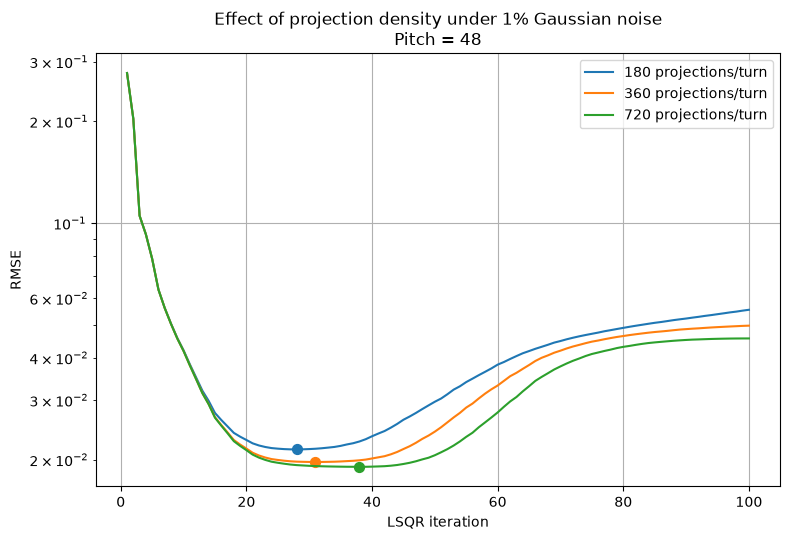

Saved: lsqr_validation_results_pitch48/figures/projection_density_noise_1pct_rmse.png


In [ ]:
# ============================================================
# D4c. Plot noisy projection-density RMSE histories
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

for ppt_test in NOISY_PPT_VALUES:

    history = (
        noisy_projection_density_results[
            ppt_test
        ]["result"]["history"]
    )

    best = history.loc[
        history["rmse"].idxmin()
    ]

    line, = ax.semilogy(
        history["iteration"],
        history["rmse"],
        label=(
            f"{ppt_test} projections/turn"
        ),
    )

    ax.scatter(
        best["iteration"],
        best["rmse"],
        s=50,
        marker="o",
        color=line.get_color(),
    )

ax.set_xlabel(
    "LSQR iteration"
)

ax.set_ylabel(
    "RMSE"
)

ax.set_title(
    "Effect of projection density under 1% Gaussian noise\n"
    f"Pitch = {NOISY_PPT_PITCH:g}"
)

ax.grid(True)

ax.legend()

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "projection_density_noise_1pct_rmse.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

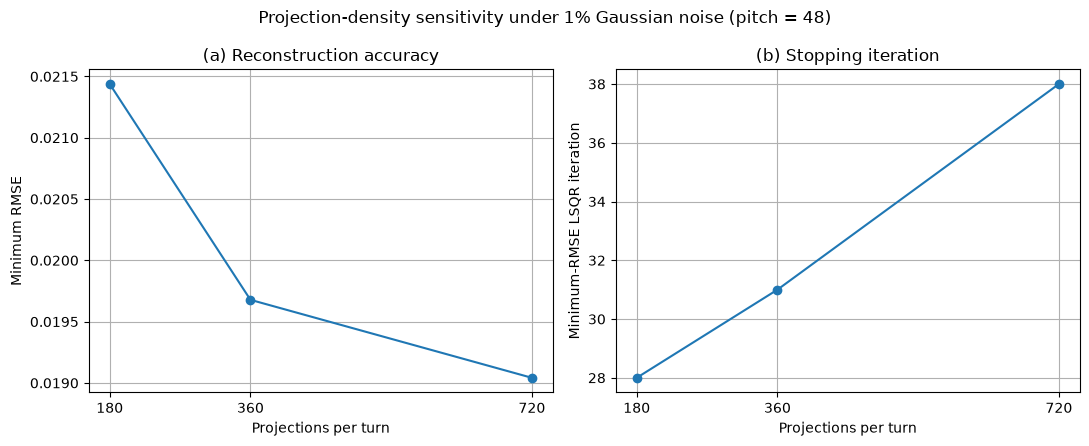

Saved: lsqr_validation_results_pitch48/figures/projection_density_noise_1pct_summary.png


In [ ]:
# ============================================================
# D4c. Projection-density summary
#
# (a) minimum RMSE
# (b) best stopping iteration
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

summary = (
    noisy_projection_density_summary
    .sort_values(
        "projections_per_turn"
    )
)

# ------------------------------------------------------------
# (a) Minimum RMSE
# ------------------------------------------------------------

axes[0].plot(
    summary["projections_per_turn"],
    summary["minimum_rmse"],
    marker="o",
)

axes[0].set_xlabel(
    "Projections per turn"
)

axes[0].set_ylabel(
    "Minimum RMSE"
)

axes[0].set_xticks(
    NOISY_PPT_VALUES
)

axes[0].set_title(
    "(a) Reconstruction accuracy"
)

axes[0].grid(True)


# ------------------------------------------------------------
# (b) Best iteration
# ------------------------------------------------------------

axes[1].plot(
    summary["projections_per_turn"],
    summary["best_iteration"],
    marker="o",
)

axes[1].set_xlabel(
    "Projections per turn"
)

axes[1].set_ylabel(
    "Minimum-RMSE LSQR iteration"
)

axes[1].set_xticks(
    NOISY_PPT_VALUES
)

axes[1].set_title(
    "(b) Stopping iteration"
)

axes[1].grid(True)


fig.suptitle(
    "Projection-density sensitivity under 1% Gaussian noise "
    f"(pitch = {NOISY_PPT_PITCH:g})"
)

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "projection_density_noise_1pct_summary.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

In [ ]:
# ============================================================
# D4d. Noisy pitch sweep with fixed total projection count
#
# Fixed:
#   total projections = 1080
#   Gaussian projection noise = 1%
#
# Vary:
#   helical pitch
#
# This is the noisy counterpart of D4b.
# ============================================================

RUN_NOISY_FIXED_TOTAL_PITCH_SWEEP = True

NOISY_FIXED_TOTAL_PROJECTIONS = (
    FIXED_TOTAL_PROJECTIONS
)

NOISY_FIXED_TOTAL_PITCH_VALUES = (
    FIXED_TOTAL_PITCH_VALUES
)

NOISY_FIXED_TOTAL_NOISE_LEVEL = 0.01

# Keep the same deterministic seed for all cases.
NOISY_FIXED_TOTAL_NOISE_SEED = 42


noisy_fixed_total_pitch_results = {}
noisy_fixed_total_rows = []


if RUN_NOISY_FIXED_TOTAL_PITCH_SWEEP:

    if (
        "fixed_total_pitch_results"
        not in globals()
        or not fixed_total_pitch_results
    ):
        raise RuntimeError(
            "fixed_total_pitch_results is not available. "
            "Run D4b clean fixed-total pitch sweep first."
        )

    for pitch_test in (
        NOISY_FIXED_TOTAL_PITCH_VALUES
    ):

        print(
            "\n"
            + "=" * 72
        )

        print(
            f"Noisy fixed-total pitch sweep: "
            f"pitch={pitch_test:g}, "
            f"total projections="
            f"{NOISY_FIXED_TOTAL_PROJECTIONS}, "
            f"noise="
            f"{100 * NOISY_FIXED_TOTAL_NOISE_LEVEL:g}%"
        )

        # ----------------------------------------------------
        # 1. Reuse corresponding clean fixed-total problem
        # ----------------------------------------------------

        problem = (
            fixed_total_pitch_results[
                pitch_test
            ]["problem"]
        )

        # This requires D4b to have been run in the
        # current session so that the full problem,
        # including operator and projection data,
        # is available.

        clean_projection_data = problem[
            "projection_data"
        ]

        clean_array = np.asarray(
            clean_projection_data.as_array(),
            dtype=np.float64,
        )

        clean_norm = np.linalg.norm(
            clean_array.ravel()
        )

        # ----------------------------------------------------
        # 2. Deterministic Gaussian noise
        #
        # ||noise||_2 / ||b||_2 = 0.01
        # ----------------------------------------------------

        rng = np.random.default_rng(
            NOISY_FIXED_TOTAL_NOISE_SEED
        )

        noise_direction = rng.standard_normal(
            clean_array.shape
        )

        noise_direction /= max(
            np.linalg.norm(
                noise_direction.ravel()
            ),
            1e-30,
        )

        noise_array = (
            NOISY_FIXED_TOTAL_NOISE_LEVEL
            * clean_norm
            * noise_direction
        )

        actual_relative_noise = (
            np.linalg.norm(
                noise_array.ravel()
            )
            / max(
                clean_norm,
                1e-30,
            )
        )

        noisy_projection_data = (
            clean_projection_data.copy()
        )

        noisy_projection_data.fill(
            (
                clean_array
                + noise_array
            ).astype(np.float32)
        )

        # ----------------------------------------------------
        # 3. Run LSQR
        # ----------------------------------------------------

        initial = problem[
            "image_geometry"
        ].allocate(0.0)

        noisy_result = run_lsqr_with_diagnostics(
            operator_local=problem["operator"],
            data_local=noisy_projection_data,
            truth_local=problem["phantom"],
            initial_local=initial,
            number_of_iterations_local=(
                number_of_iterations
            ),
            alpha=0.0,
            checkpoint_interval=1,
        )

        experiment_id = (
            f"pitch_fixed_total_"
            f"p{pitch_test:g}_"
            f"n{NOISY_FIXED_TOTAL_PROJECTIONS}_"
            f"noise_1pct_"
            f"seed{NOISY_FIXED_TOTAL_NOISE_SEED}"
        )

        # ----------------------------------------------------
        # 4. Store
        # ----------------------------------------------------

        noisy_fixed_total_pitch_results[
            pitch_test
        ] = {
            "experiment_id":
                experiment_id,

            "problem":
                problem,

            "result":
                noisy_result,

            "noisy_projection_data":
                noisy_projection_data,

            "noise_array":
                noise_array,

            "actual_relative_noise":
                actual_relative_noise,

            "noise_seed":
                NOISY_FIXED_TOTAL_NOISE_SEED,
        }

        save_iteration_history(
            result=noisy_result,
            experiment_name=experiment_id,
            extra_metadata={
                "experiment_group":
                    "pitch_fixed_total_noisy",

                "experiment_type":
                    "pitch_fixed_total_noisy",

                "pitch_control":
                    "fixed_total_projections",

                "algorithm":
                    "LSQR",

                "pitch":
                    pitch_test,

                "number_of_turns":
                    problem["number_of_turns"],

                "projections_per_turn":
                    problem["projections_per_turn"],

                "number_of_projections":
                    problem["number_of_projections"],

                "relative_noise_level":
                    NOISY_FIXED_TOTAL_NOISE_LEVEL,

                "actual_relative_noise":
                    actual_relative_noise,

                "noise_seed":
                    NOISY_FIXED_TOTAL_NOISE_SEED,

                "initialisation":
                    "zero",
            },
        )

        # ----------------------------------------------------
        # 5. Summary
        # ----------------------------------------------------

        history = noisy_result["history"]

        best = history.loc[
            history["rmse"].idxmin()
        ]

        final = history.iloc[-1]

        noisy_fixed_total_rows.append(
            {
                "experiment_id":
                    experiment_id,

                "experiment_type":
                    "pitch_fixed_total_noisy",

                "pitch_control":
                    "fixed_total_projections",

                "pitch":
                    pitch_test,

                "number_of_turns":
                    problem["number_of_turns"],

                "total_projections":
                    problem["number_of_projections"],

                "effective_projections_per_turn":
                    problem["projections_per_turn"],

                "noise_level":
                    NOISY_FIXED_TOTAL_NOISE_LEVEL,

                "actual_relative_noise":
                    actual_relative_noise,

                "noise_seed":
                    NOISY_FIXED_TOTAL_NOISE_SEED,

                "best_iteration":
                    int(best["iteration"]),

                "best_rmse":
                    float(best["rmse"]),

                "final_rmse":
                    float(final["rmse"]),

                "best_relative_residual":
                    float(
                        best["relative_residual"]
                    ),

                "best_relative_backprojected_residual":
                    float(
                        best[
                            "relative_backprojected_residual"
                        ]
                    ),
            }
        )

        print(
            f"Actual relative noise = "
            f"{actual_relative_noise:.8f}"
        )

        print(
            f"Best iteration = "
            f"{int(best['iteration'])}"
        )

        print(
            f"Minimum RMSE = "
            f"{float(best['rmse']):.8f}"
        )


    noisy_fixed_total_pitch_summary = (
        pd.DataFrame(
            noisy_fixed_total_rows
        )
        .sort_values("pitch")
        .reset_index(drop=True)
    )

    display(
        noisy_fixed_total_pitch_summary
    )


    noisy_fixed_total_summary_path = (
        os.path.join(
            RESULTS_DIRECTORY,
            "pitch_fixed_total_noise_1pct_summary.csv",
        )
    )

    noisy_fixed_total_pitch_summary.to_csv(
        noisy_fixed_total_summary_path,
        index=False,
    )

    print(
        "Saved:",
        noisy_fixed_total_summary_path,
    )


Noisy fixed-total pitch sweep: pitch=6, total projections=1080, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p6_n1080_noise_1pct_seed42_history.csv
Actual relative noise = 0.01000000
Best iteration = 32
Minimum RMSE = 0.01970893

Noisy fixed-total pitch sweep: pitch=12, total projections=1080, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p12_n1080_noise_1pct_seed42_history.csv
Actual relative noise = 0.01000000
Best iteration = 32
Minimum RMSE = 0.01975604

Noisy fixed-total pitch sweep: pitch=24, total projections=1080, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total_p24_n1080_noise_1pct_seed42_history.csv
Actual relative noise = 0.01000000
Best iteration = 32
Minimum RMSE = 0.02044461

Noisy fixed-total pitch sweep: pitch=48, total projections=1080, noise=1%
Saved iteration history: lsqr_validation_results_pitch48/histories/pitch_fixed_total

,experiment_id,experiment_type,pitch_control,pitch,number_of_turns,total_projections,effective_projections_per_turn,noise_level,actual_relative_noise,noise_seed,best_iteration,best_rmse,final_rmse,best_relative_residual,best_relative_backprojected_residual
0,pitch_fixed_total_p6_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,6.0,22,1080,49.090909,0.01,0.01,42,32,0.019709,0.049310,0.010051,0.000436
1,pitch_fixed_total_p12_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,12.0,11,1080,98.181818,0.01,0.01,42,32,0.019756,0.047854,0.010051,0.000441
2,pitch_fixed_total_p24_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,24.0,6,1080,180.000000,0.01,0.01,42,32,0.020445,0.047642,0.010062,0.000475
3,pitch_fixed_total_p48_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,48.0,3,1080,360.000000,0.01,0.01,42,31,0.019678,0.049758,0.010042,0.000487
4,pitch_fixed_total_p72_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,72.0,2,1080,540.000000,0.01,0.01,42,33,0.020149,0.043988,0.010050,0.000450
5,pitch_fixed_total_p96_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,96.0,2,1080,540.000000,0.01,0.01,42,34,0.020274,0.039180,0.010057,0.000443
6,pitch_fixed_total_p110_n1080_noise_1pct_seed42,pitch_fixed_total_noisy,fixed_total_projections,110.0,2,1080,540.000000,0.01,0.01,42,33,0.020293,0.037817,0.010048,0.000458


Saved: lsqr_validation_results_pitch48/pitch_fixed_total_noise_1pct_summary.csv


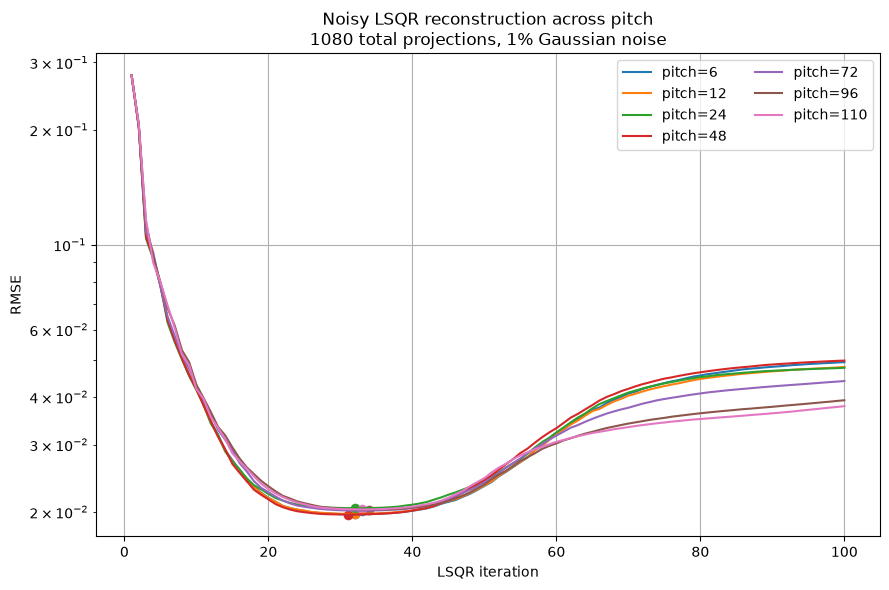

Saved: lsqr_validation_results_pitch48/figures/pitch_fixed_total_noise_1pct_rmse.png


In [ ]:
# ============================================================
# D4d. RMSE histories:
# noisy pitch sweep at fixed total projections
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for pitch_test in sorted(
    noisy_fixed_total_pitch_results.keys()
):

    history = (
        noisy_fixed_total_pitch_results[
            pitch_test
        ]["result"]["history"]
    )

    best = history.loc[
        history["rmse"].idxmin()
    ]

    line, = ax.semilogy(
        history["iteration"],
        history["rmse"],
        label=f"pitch={pitch_test:g}",
    )

    ax.scatter(
        best["iteration"],
        best["rmse"],
        s=35,
        marker="o",
        color=line.get_color(),
    )

ax.set_xlabel(
    "LSQR iteration"
)

ax.set_ylabel(
    "RMSE"
)

ax.set_title(
    "Noisy LSQR reconstruction across pitch\n"
    f"{NOISY_FIXED_TOTAL_PROJECTIONS} total projections, "
    "1% Gaussian noise"
)

ax.grid(True)

ax.legend(
    ncol=2
)

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "pitch_fixed_total_noise_1pct_rmse.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

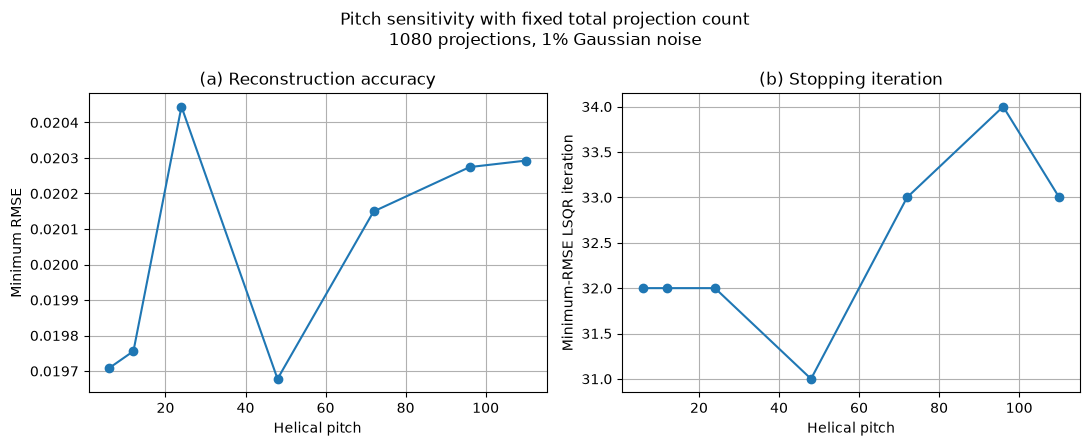

Saved: lsqr_validation_results_pitch48/figures/pitch_fixed_total_noise_1pct_summary.png


In [ ]:
# ============================================================
# D4d. Summary:
# noisy fixed-total pitch sweep
#
# (a) minimum RMSE vs pitch
# (b) best iteration vs pitch
# ============================================================

summary = (
    noisy_fixed_total_pitch_summary
    .sort_values("pitch")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)


# ------------------------------------------------------------
# (a) Minimum RMSE
# ------------------------------------------------------------

axes[0].plot(
    summary["pitch"],
    summary["best_rmse"],
    marker="o",
)

axes[0].set_xlabel(
    "Helical pitch"
)

axes[0].set_ylabel(
    "Minimum RMSE"
)

axes[0].set_title(
    "(a) Reconstruction accuracy"
)

axes[0].grid(True)


# ------------------------------------------------------------
# (b) Best stopping iteration
# ------------------------------------------------------------

axes[1].plot(
    summary["pitch"],
    summary["best_iteration"],
    marker="o",
)

axes[1].set_xlabel(
    "Helical pitch"
)

axes[1].set_ylabel(
    "Minimum-RMSE LSQR iteration"
)

axes[1].set_title(
    "(b) Stopping iteration"
)

axes[1].grid(True)


fig.suptitle(
    "Pitch sensitivity with fixed total projection count\n"
    f"{NOISY_FIXED_TOTAL_PROJECTIONS} projections, "
    "1% Gaussian noise"
)

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "pitch_fixed_total_noise_1pct_summary.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

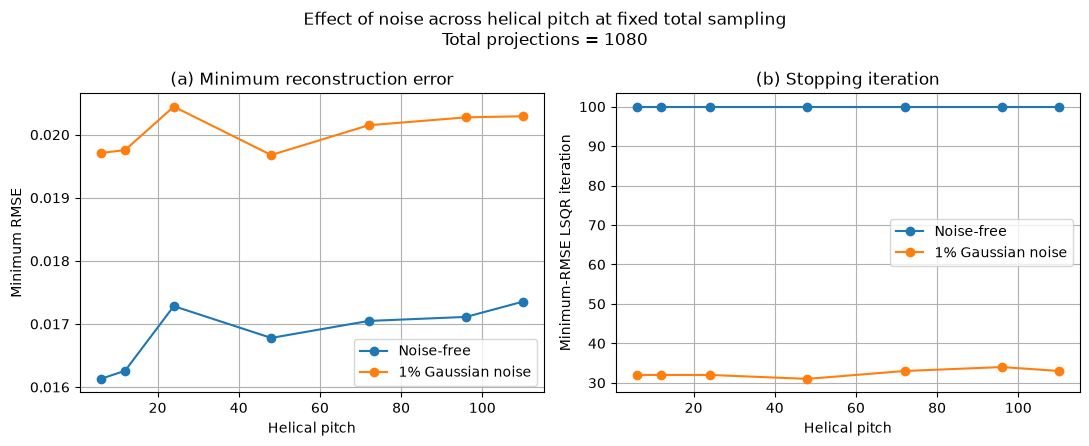

Saved: lsqr_validation_results_pitch48/figures/pitch_fixed_total_clean_vs_noisy.png


In [ ]:
# ============================================================
# D4d. Clean vs noisy comparison
# Fixed total projections = 1080
# ============================================================

clean_summary = (
    fixed_total_pitch_summary
    .sort_values("pitch")
)

noisy_summary = (
    noisy_fixed_total_pitch_summary
    .sort_values("pitch")
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)


# ------------------------------------------------------------
# (a) Minimum RMSE
# ------------------------------------------------------------

axes[0].plot(
    clean_summary["pitch"],
    clean_summary["best_rmse"],
    marker="o",
    label="Noise-free",
)

axes[0].plot(
    noisy_summary["pitch"],
    noisy_summary["best_rmse"],
    marker="o",
    label="1% Gaussian noise",
)

axes[0].set_xlabel(
    "Helical pitch"
)

axes[0].set_ylabel(
    "Minimum RMSE"
)

axes[0].set_title(
    "(a) Minimum reconstruction error"
)

axes[0].grid(True)

axes[0].legend()


# ------------------------------------------------------------
# (b) Best iteration
# ------------------------------------------------------------

axes[1].plot(
    clean_summary["pitch"],
    clean_summary["best_iteration"],
    marker="o",
    label="Noise-free",
)

axes[1].plot(
    noisy_summary["pitch"],
    noisy_summary["best_iteration"],
    marker="o",
    label="1% Gaussian noise",
)

axes[1].set_xlabel(
    "Helical pitch"
)

axes[1].set_ylabel(
    "Minimum-RMSE LSQR iteration"
)

axes[1].set_title(
    "(b) Stopping iteration"
)

axes[1].grid(True)

axes[1].legend()


fig.suptitle(
    "Effect of noise across helical pitch at fixed total sampling\n"
    f"Total projections = {FIXED_TOTAL_PROJECTIONS}"
)

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "pitch_fixed_total_clean_vs_noisy.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 11. Tikhonov regularisation: baseline parameter sweep

Apply Tikhonov regularisation to the noisy baseline problem and sweep the regularisation parameter $\alpha$. The resulting histories are used to compare minimum RMSE, stopping behaviour, and late-iteration stability.


In [ ]:
# ============================================================
# T1. Unified Tikhonov baseline setup
#
# Reuse exactly the same problem and noisy data as the
# pitch=48, 360 projections/turn, 1% noise experiment.
# ============================================================

TIKHONOV_BASELINE_PPT = 360
TIKHONOV_BASELINE_PITCH = 48.0
TIKHONOV_NOISE_LEVEL = 0.01
TIKHONOV_NOISE_SEED = 42

TIKHONOV_MAX_ITERATIONS = 100

TIKHONOV_ALPHA_VALUES = [
    0.0,
    2.0,
    5.0,
    7.5,
    8.0,
    8.5,
    9.0,
    9.5,
    10.0,
    11.0,
    12.0,
    12.5,
    13.0,
    15.0,
    18.0,
    20.0,
    25.0,
    30.0,
]


if (
    "projection_results" not in globals()
    or TIKHONOV_BASELINE_PPT not in projection_results
):
    raise RuntimeError(
        "projection_results[360] is unavailable. "
        "Run the clean projection-density sweep first."
    )

if (
    "noisy_projection_density_results" not in globals()
    or TIKHONOV_BASELINE_PPT not in noisy_projection_density_results
):
    raise RuntimeError(
        "noisy_projection_density_results[360] is unavailable. "
        "Run the unified noisy projection-density sweep first."
    )


tikhonov_problem = (
    projection_results[
        TIKHONOV_BASELINE_PPT
    ]["problem"]
)

tikhonov_operator = (
    tikhonov_problem["operator"]
)

tikhonov_clean_data = (
    tikhonov_problem[
        "projection_data"
    ].copy()
)

tikhonov_data = (
    noisy_projection_density_results[
        TIKHONOV_BASELINE_PPT
    ]["noisy_projection_data"].copy()
)

tikhonov_truth = (
    tikhonov_problem[
        "phantom"
    ].copy()
)

tikhonov_image_geometry = (
    tikhonov_problem[
        "image_geometry"
    ]
)

tikhonov_initial = (
    tikhonov_image_geometry.allocate(0.0)
)


print("Tikhonov baseline setup")
print("------------------------")
print("Pitch:", tikhonov_problem["pitch"])
print(
    "Projections per turn:",
    TIKHONOV_BASELINE_PPT,
)
print(
    "Number of turns:",
    tikhonov_problem["number_of_turns"],
)
print(
    "Total projections:",
    tikhonov_problem["number_of_projections"],
)

Tikhonov baseline setup
------------------------
Pitch: 48.0
Projections per turn: 360
Number of turns: 3
Total projections: 1080


In [ ]:
# ============================================================
# T4. Baseline Tikhonov alpha sweep
# ============================================================

tikhonov_results = {}


for alpha_value in TIKHONOV_ALPHA_VALUES:

    print(
        "\n"
        + "=" * 68
    )

    print(
        f"Running baseline Tikhonov: "
        f"alpha={alpha_value:g}"
    )

    initial = (
        tikhonov_image_geometry.allocate(
            0.0
        )
    )

    result = (
        run_lsqr_with_diagnostics(
            operator_local=tikhonov_operator,
            data_local=tikhonov_data,
            truth_local=tikhonov_truth,
            initial_local=initial,
            number_of_iterations_local=(
                TIKHONOV_MAX_ITERATIONS
            ),
            alpha=alpha_value,
            checkpoint_interval=1,
        )
    )

    tikhonov_results[
        alpha_value
    ] = result

    print(
        "Best iteration:",
        result["best_iteration"],
    )

    print(
        "Minimum RMSE:",
        f"{result['minimum_rmse']:.8f}",
    )

    print(
        "Final RMSE:",
        f"{result['final_rmse']:.8f}",
    )

    print(
        "Near-optimal interval:",
        result["near_optimal_start"],
        "to",
        result["near_optimal_end"],
    )


Running baseline Tikhonov: alpha=0
Best iteration: 31
Minimum RMSE: 0.01967796
Final RMSE: 0.04975766
Near-optimal interval: 26 to 37

Running baseline Tikhonov: alpha=2
Best iteration: 31
Minimum RMSE: 0.01967187
Final RMSE: 0.04180830
Near-optimal interval: 26 to 37

Running baseline Tikhonov: alpha=5
Best iteration: 32
Minimum RMSE: 0.01965983
Final RMSE: 0.02672834
Near-optimal interval: 27 to 38

Running baseline Tikhonov: alpha=7.5
Best iteration: 34
Minimum RMSE: 0.01970912
Final RMSE: 0.02210977
Near-optimal interval: 28 to 39

Running baseline Tikhonov: alpha=8
Best iteration: 34
Minimum RMSE: 0.01973285
Final RMSE: 0.02167435
Near-optimal interval: 28 to 40

Running baseline Tikhonov: alpha=8.5
Best iteration: 34
Minimum RMSE: 0.01976395
Final RMSE: 0.02133662
Near-optimal interval: 28 to 40

Running baseline Tikhonov: alpha=9
Best iteration: 34
Minimum RMSE: 0.01980324
Final RMSE: 0.02107896
Near-optimal interval: 28 to 40

Running baseline Tikhonov: alpha=9.5
Best iteratio

In [ ]:
# ============================================================
# T5. Baseline Tikhonov summary
# ============================================================

baseline_tikhonov_rows = []

reference_minimum_rmse = (
    tikhonov_results[
        0.0
    ]["minimum_rmse"]
)


for alpha_value in (
    TIKHONOV_ALPHA_VALUES
):

    result = (
        tikhonov_results[
            alpha_value
        ]
    )

    history = result["history"]

    best_index = (
        history["rmse"]
        .idxmin()
    )

    best = history.loc[
        best_index
    ]

    final = history.iloc[-1]

    near_optimal_width = (
        result["near_optimal_end"]
        - result["near_optimal_start"]
        + 1
    )

    near_optimal_fraction = (
        near_optimal_width
        / TIKHONOV_MAX_ITERATIONS
    )

    relative_minimum_rmse_penalty = (
        result["minimum_rmse"]
        / reference_minimum_rmse
        - 1.0
    )

    baseline_tikhonov_rows.append(
        {
            "alpha":
                alpha_value,

            "best_iteration":
                int(
                    result[
                        "best_iteration"
                    ]
                ),

            "minimum_rmse":
                float(
                    result[
                        "minimum_rmse"
                    ]
                ),

            "rmse_at_iteration_100":
                float(
                    final["rmse"]
                ),

            "near_optimal_start":
                int(
                    result[
                        "near_optimal_start"
                    ]
                ),

            "near_optimal_end":
                int(
                    result[
                        "near_optimal_end"
                    ]
                ),

            "near_optimal_width":
                int(
                    near_optimal_width
                ),

            "near_optimal_fraction":
                float(
                    near_optimal_fraction
                ),

            "relative_minimum_rmse_penalty":
                float(
                    relative_minimum_rmse_penalty
                ),
        }
    )


baseline_tikhonov_summary = (
    pd.DataFrame(
        baseline_tikhonov_rows
    )
    .sort_values("alpha")
    .reset_index(drop=True)
)


display(
    baseline_tikhonov_summary
)


baseline_tikhonov_summary_path = (
    os.path.join(
        RESULTS_DIRECTORY,
        "tikhonov_baseline_summary.csv",
    )
)

baseline_tikhonov_summary.to_csv(
    baseline_tikhonov_summary_path,
    index=False,
)

print(
    "Saved:",
    baseline_tikhonov_summary_path,
)

,alpha,best_iteration,minimum_rmse,rmse_at_iteration_100,near_optimal_start,near_optimal_end,near_optimal_width,near_optimal_fraction,relative_minimum_rmse_penalty
0,0.0,31,0.019678,0.049758,26,37,12,0.12,0.000000
1,2.0,31,0.019672,0.041808,26,37,12,0.12,-0.000309
2,5.0,32,0.019660,0.026728,27,38,12,0.12,-0.000921
3,7.5,34,0.019709,0.022110,28,39,12,0.12,0.001584
4,8.0,34,0.019733,0.021674,28,40,13,0.13,0.002790
5,8.5,34,0.019764,0.021337,28,40,13,0.13,0.004370
6,9.0,34,0.019803,0.021079,28,40,13,0.13,0.006367
7,9.5,35,0.019851,0.020888,28,41,14,0.14,0.008797
8,10.0,35,0.019907,0.020752,29,41,13,0.13,0.011649
9,11.0,35,0.020052,0.020616,29,42,14,0.14,0.019016


Saved: lsqr_validation_results_pitch48/tikhonov_baseline_summary.csv


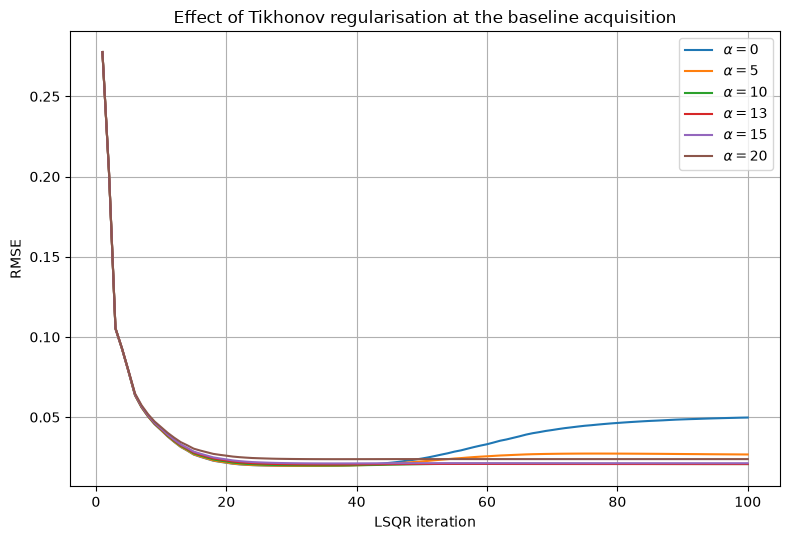

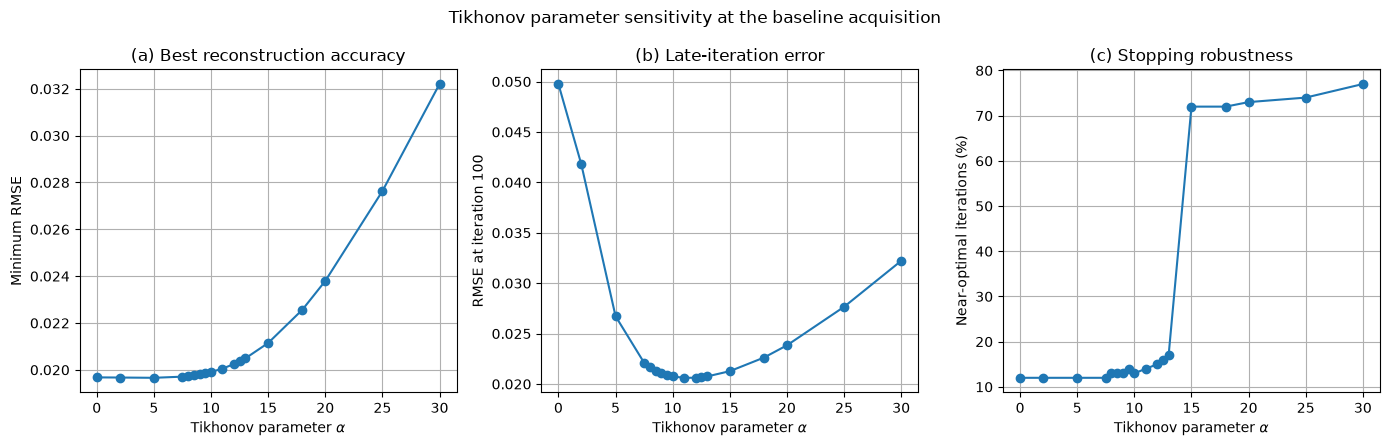

In [ ]:
# ============================================================
# T6. Baseline Tikhonov figures
# ============================================================

# ------------------------------------------------------------
# Figure A:
# Representative RMSE trajectories
# ------------------------------------------------------------

REPRESENTATIVE_BASELINE_ALPHAS = [
    0.0,
    5.0,
    10.0,
    13.0,
    15.0,
    20.0,
]

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

for alpha_value in (
    REPRESENTATIVE_BASELINE_ALPHAS
):

    history = (
        tikhonov_results[
            alpha_value
        ]["history"]
    )

    ax.plot(
        history["iteration"],
        history["rmse"],
        label=(
            f"$\\alpha={alpha_value:g}$"
        ),
    )

ax.set_xlabel(
    "LSQR iteration"
)

ax.set_ylabel(
    "RMSE"
)

ax.set_title(
    "Effect of Tikhonov regularisation "
    "at the baseline acquisition"
)

ax.grid(True)

ax.legend()

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_baseline_rmse_trajectories.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Figure B:
# Parameter-sweep summary
# ------------------------------------------------------------

summary = (
    baseline_tikhonov_summary
    .sort_values("alpha")
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
)


# (a) Best attainable RMSE
axes[0].plot(
    summary["alpha"],
    summary["minimum_rmse"],
    marker="o",
)

axes[0].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[0].set_ylabel(
    "Minimum RMSE"
)

axes[0].set_title(
    "(a) Best reconstruction accuracy"
)

axes[0].grid(True)


# (b) RMSE after 100 iterations
axes[1].plot(
    summary["alpha"],
    summary[
        "rmse_at_iteration_100"
    ],
    marker="o",
)

axes[1].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[1].set_ylabel(
    "RMSE at iteration 100"
)

axes[1].set_title(
    "(b) Late-iteration error"
)

axes[1].grid(True)


# (c) Near-optimal fraction
axes[2].plot(
    summary["alpha"],
    100.0
    * summary[
        "near_optimal_fraction"
    ],
    marker="o",
)

axes[2].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[2].set_ylabel(
    "Near-optimal iterations (%)"
)

axes[2].set_title(
    "(c) Stopping robustness"
)

axes[2].grid(True)


fig.suptitle(
    "Tikhonov parameter sensitivity "
    "at the baseline acquisition"
)

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_baseline_parameter_sweep.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# ============================================================
# T7. Reduced-sampling Tikhonov sweep
#
# Fixed:
#   pitch = 48
#   projections per turn = 180
#   Gaussian noise = 1%
# ============================================================

LOW_PPT = 180

LOW_PPT_MAX_ITERATIONS = 200

LOW_PPT_ALPHA_VALUES = [
    0.0,
    2.5,
    5.0,
    6.0,
    7.5,
    9.5,
    11.0,
    12.5,
    15.0,
    18.0,
    20.0,
]


if (
    LOW_PPT
    not in projection_results
):
    raise RuntimeError(
        "projection_results[180] is unavailable."
    )

if (
    LOW_PPT
    not in noisy_projection_density_results
):
    raise RuntimeError(
        "noisy_projection_density_results[180] "
        "is unavailable."
    )


low_ppt_problem = (
    projection_results[
        LOW_PPT
    ]["problem"]
)

low_ppt_operator = (
    low_ppt_problem[
        "operator"
    ]
)

low_ppt_data = (
    noisy_projection_density_results[
        LOW_PPT
    ]["noisy_projection_data"].copy()
)

low_ppt_truth = (
    low_ppt_problem[
        "phantom"
    ].copy()
)

low_ppt_image_geometry = (
    low_ppt_problem[
        "image_geometry"
    ]
)


low_ppt_tikhonov_results = {}


for alpha_value in (
    LOW_PPT_ALPHA_VALUES
):

    print(
        "\n"
        + "=" * 68
    )

    print(
        f"Running low-projection Tikhonov: "
        f"ppt={LOW_PPT}, "
        f"alpha={alpha_value:g}"
    )

    initial = (
        low_ppt_image_geometry.allocate(
            0.0
        )
    )

    result = (
        run_lsqr_with_diagnostics(
            operator_local=low_ppt_operator,
            data_local=low_ppt_data,
            truth_local=low_ppt_truth,
            initial_local=initial,
            number_of_iterations_local=(
                LOW_PPT_MAX_ITERATIONS
            ),
            alpha=alpha_value,
            checkpoint_interval=1,
        )
    )

    low_ppt_tikhonov_results[
        alpha_value
    ] = result

    print(
        "Best iteration:",
        result["best_iteration"],
    )

    print(
        "Minimum RMSE:",
        f"{result['minimum_rmse']:.8f}",
    )

    print(
        "Final RMSE:",
        f"{result['final_rmse']:.8f}",
    )


Running low-projection Tikhonov: ppt=180, alpha=0
Best iteration: 28
Minimum RMSE: 0.02143801
Final RMSE: 0.09383417

Running low-projection Tikhonov: ppt=180, alpha=2.5
Best iteration: 28
Minimum RMSE: 0.02141678
Final RMSE: 0.04665698

Running low-projection Tikhonov: ppt=180, alpha=5
Best iteration: 30
Minimum RMSE: 0.02141470
Final RMSE: 0.02799253

Running low-projection Tikhonov: ppt=180, alpha=6
Best iteration: 30
Minimum RMSE: 0.02145344
Final RMSE: 0.02550963

Running low-projection Tikhonov: ppt=180, alpha=7.5
Best iteration: 31
Minimum RMSE: 0.02160706
Final RMSE: 0.02363450

Running low-projection Tikhonov: ppt=180, alpha=9.5
Best iteration: 33
Minimum RMSE: 0.02207648
Final RMSE: 0.02291735

Running low-projection Tikhonov: ppt=180, alpha=11
Best iteration: 34
Minimum RMSE: 0.02269530
Final RMSE: 0.02314883

Running low-projection Tikhonov: ppt=180, alpha=12.5
Best iteration: 34
Minimum RMSE: 0.02357169
Final RMSE: 0.02383063

Running low-projection Tikhonov: ppt=180, alp

In [ ]:
# ============================================================
# T7. Reduced-sampling Tikhonov sweep
#
# Fixed:
#   pitch = 48
#   projections per turn = 180
#   Gaussian noise = 1%
# ============================================================

LOW_PPT = 180

LOW_PPT_MAX_ITERATIONS = 200

LOW_PPT_ALPHA_VALUES = [
    0.0,
    2.5,
    5.0,
    6.0,
    7.5,
    9.5,
    11.0,
    12.5,
    15.0,
    18.0,
    20.0,
]


if (
    LOW_PPT
    not in projection_results
):
    raise RuntimeError(
        "projection_results[180] is unavailable."
    )

if (
    LOW_PPT
    not in noisy_projection_density_results
):
    raise RuntimeError(
        "noisy_projection_density_results[180] "
        "is unavailable."
    )


low_ppt_problem = (
    projection_results[
        LOW_PPT
    ]["problem"]
)

low_ppt_operator = (
    low_ppt_problem[
        "operator"
    ]
)

low_ppt_data = (
    noisy_projection_density_results[
        LOW_PPT
    ]["noisy_projection_data"].copy()
)

low_ppt_truth = (
    low_ppt_problem[
        "phantom"
    ].copy()
)

low_ppt_image_geometry = (
    low_ppt_problem[
        "image_geometry"
    ]
)


low_ppt_tikhonov_results = {}


for alpha_value in (
    LOW_PPT_ALPHA_VALUES
):

    print(
        "\n"
        + "=" * 68
    )

    print(
        f"Running low-projection Tikhonov: "
        f"ppt={LOW_PPT}, "
        f"alpha={alpha_value:g}"
    )

    initial = (
        low_ppt_image_geometry.allocate(
            0.0
        )
    )

    result = (
        run_lsqr_with_diagnostics(
            operator_local=low_ppt_operator,
            data_local=low_ppt_data,
            truth_local=low_ppt_truth,
            initial_local=initial,
            number_of_iterations_local=(
                LOW_PPT_MAX_ITERATIONS
            ),
            alpha=alpha_value,
            checkpoint_interval=1,
        )
    )

    low_ppt_tikhonov_results[
        alpha_value
    ] = result

    print(
        "Best iteration:",
        result["best_iteration"],
    )

    print(
        "Minimum RMSE:",
        f"{result['minimum_rmse']:.8f}",
    )

    print(
        "Final RMSE:",
        f"{result['final_rmse']:.8f}",
    )


Running low-projection Tikhonov: ppt=180, alpha=0
Best iteration: 28
Minimum RMSE: 0.02143801
Final RMSE: 0.09383417

Running low-projection Tikhonov: ppt=180, alpha=2.5
Best iteration: 28
Minimum RMSE: 0.02141678
Final RMSE: 0.04665698

Running low-projection Tikhonov: ppt=180, alpha=5
Best iteration: 30
Minimum RMSE: 0.02141470
Final RMSE: 0.02799253

Running low-projection Tikhonov: ppt=180, alpha=6
Best iteration: 30
Minimum RMSE: 0.02145344
Final RMSE: 0.02550963

Running low-projection Tikhonov: ppt=180, alpha=7.5
Best iteration: 31
Minimum RMSE: 0.02160706
Final RMSE: 0.02363450

Running low-projection Tikhonov: ppt=180, alpha=9.5
Best iteration: 33
Minimum RMSE: 0.02207648
Final RMSE: 0.02291735

Running low-projection Tikhonov: ppt=180, alpha=11
Best iteration: 34
Minimum RMSE: 0.02269530
Final RMSE: 0.02314883

Running low-projection Tikhonov: ppt=180, alpha=12.5
Best iteration: 34
Minimum RMSE: 0.02357169
Final RMSE: 0.02383063

Running low-projection Tikhonov: ppt=180, alp

,alpha,best_iteration,minimum_rmse,rmse_at_iteration_200,near_optimal_start,near_optimal_end,near_optimal_width,near_optimal_fraction,relative_minimum_rmse_penalty
0,0.0,28,0.021438,0.093834,24,32,9,0.045,0.000000
1,2.5,28,0.021417,0.046657,25,33,9,0.045,-0.000990
2,5.0,30,0.021415,0.027993,26,34,9,0.045,-0.001087
3,6.0,30,0.021453,0.025510,26,35,10,0.050,0.000720
4,7.5,31,0.021607,0.023634,27,36,10,0.050,0.007886
5,9.5,33,0.022076,0.022917,28,39,12,0.060,0.029782
6,11.0,34,0.022695,0.023149,28,41,14,0.070,0.058648
7,12.5,34,0.023572,0.023831,28,47,20,0.100,0.099528
8,15.0,35,0.025586,0.025706,28,200,173,0.865,0.193504
9,18.0,35,0.028754,0.028811,26,200,175,0.875,0.341271


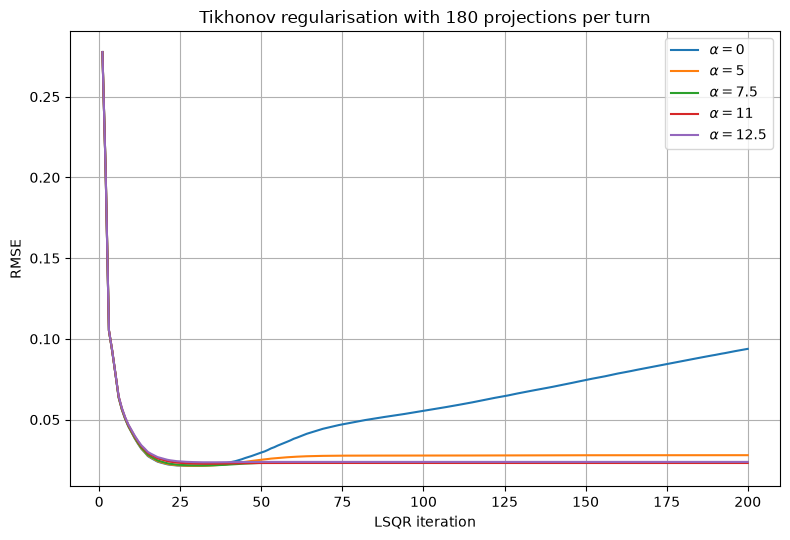

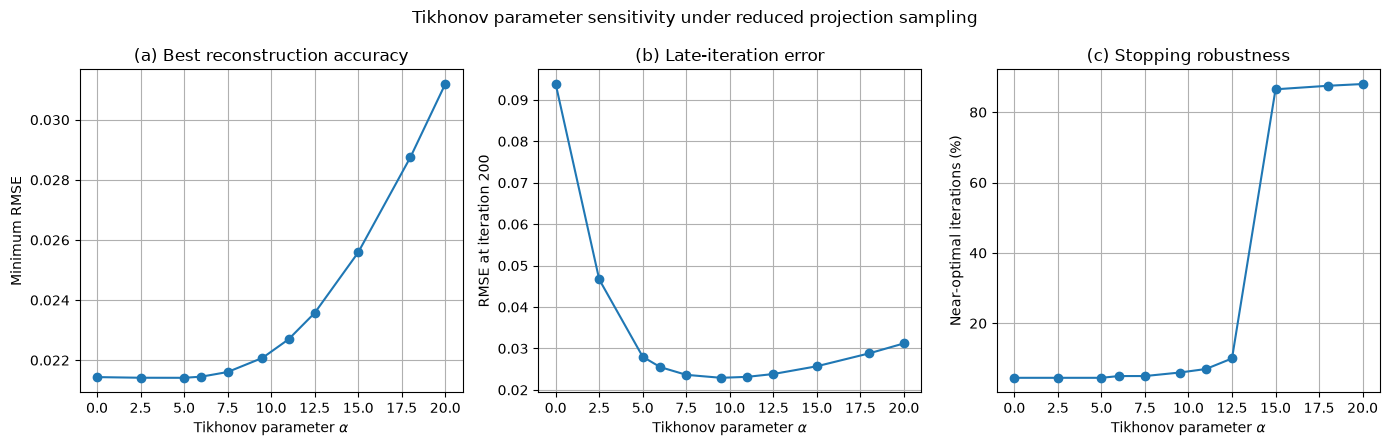

Saved: lsqr_validation_results_pitch48/tikhonov_low_projection_ppt180_summary.csv


In [ ]:
# ============================================================
# T8. Reduced-sampling summary and figures
# ============================================================

low_ppt_rows = []

low_ppt_reference_rmse = (
    low_ppt_tikhonov_results[
        0.0
    ]["minimum_rmse"]
)


for alpha_value in (
    LOW_PPT_ALPHA_VALUES
):

    result = (
        low_ppt_tikhonov_results[
            alpha_value
        ]
    )

    history = result["history"]

    final = history.iloc[-1]

    near_optimal_width = (
        result["near_optimal_end"]
        - result["near_optimal_start"]
        + 1
    )

    near_optimal_fraction = (
        near_optimal_width
        / LOW_PPT_MAX_ITERATIONS
    )

    low_ppt_rows.append(
        {
            "alpha":
                alpha_value,

            "best_iteration":
                int(
                    result[
                        "best_iteration"
                    ]
                ),

            "minimum_rmse":
                float(
                    result[
                        "minimum_rmse"
                    ]
                ),

            "rmse_at_iteration_200":
                float(
                    final["rmse"]
                ),

            "near_optimal_start":
                int(
                    result[
                        "near_optimal_start"
                    ]
                ),

            "near_optimal_end":
                int(
                    result[
                        "near_optimal_end"
                    ]
                ),

            "near_optimal_width":
                int(
                    near_optimal_width
                ),

            "near_optimal_fraction":
                float(
                    near_optimal_fraction
                ),

            "relative_minimum_rmse_penalty":
                float(
                    result[
                        "minimum_rmse"
                    ]
                    / low_ppt_reference_rmse
                    - 1.0
                ),
        }
    )


low_ppt_tikhonov_summary = (
    pd.DataFrame(
        low_ppt_rows
    )
    .sort_values("alpha")
    .reset_index(drop=True)
)

display(
    low_ppt_tikhonov_summary
)


summary_path = os.path.join(
    RESULTS_DIRECTORY,
    "tikhonov_low_projection_ppt180_summary.csv",
)

low_ppt_tikhonov_summary.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Figure A:
# Representative trajectories
# ------------------------------------------------------------

REPRESENTATIVE_LOW_PPT_ALPHAS = [
    0.0,
    5.0,
    7.5,
    11.0,
    12.5,
]

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

for alpha_value in (
    REPRESENTATIVE_LOW_PPT_ALPHAS
):

    history = (
        low_ppt_tikhonov_results[
            alpha_value
        ]["history"]
    )

    ax.plot(
        history["iteration"],
        history["rmse"],
        label=(
            f"$\\alpha={alpha_value:g}$"
        ),
    )

ax.set_xlabel(
    "LSQR iteration"
)

ax.set_ylabel(
    "RMSE"
)

ax.set_title(
    "Tikhonov regularisation "
    "with 180 projections per turn"
)

ax.grid(True)

ax.legend()

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_ppt180_rmse_trajectories.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Figure B:
# Parameter sweep summary
# ------------------------------------------------------------

summary = (
    low_ppt_tikhonov_summary
    .sort_values("alpha")
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
)


axes[0].plot(
    summary["alpha"],
    summary["minimum_rmse"],
    marker="o",
)

axes[0].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[0].set_ylabel(
    "Minimum RMSE"
)

axes[0].set_title(
    "(a) Best reconstruction accuracy"
)

axes[0].grid(True)


axes[1].plot(
    summary["alpha"],
    summary[
        "rmse_at_iteration_200"
    ],
    marker="o",
)

axes[1].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[1].set_ylabel(
    "RMSE at iteration 200"
)

axes[1].set_title(
    "(b) Late-iteration error"
)

axes[1].grid(True)


axes[2].plot(
    summary["alpha"],
    100.0
    * summary[
        "near_optimal_fraction"
    ],
    marker="o",
)

axes[2].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[2].set_ylabel(
    "Near-optimal iterations (%)"
)

axes[2].set_title(
    "(c) Stopping robustness"
)

axes[2].grid(True)


fig.suptitle(
    "Tikhonov parameter sensitivity "
    "under reduced projection sampling"
)

fig.tight_layout()

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_ppt180_parameter_sweep.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    summary_path,
)

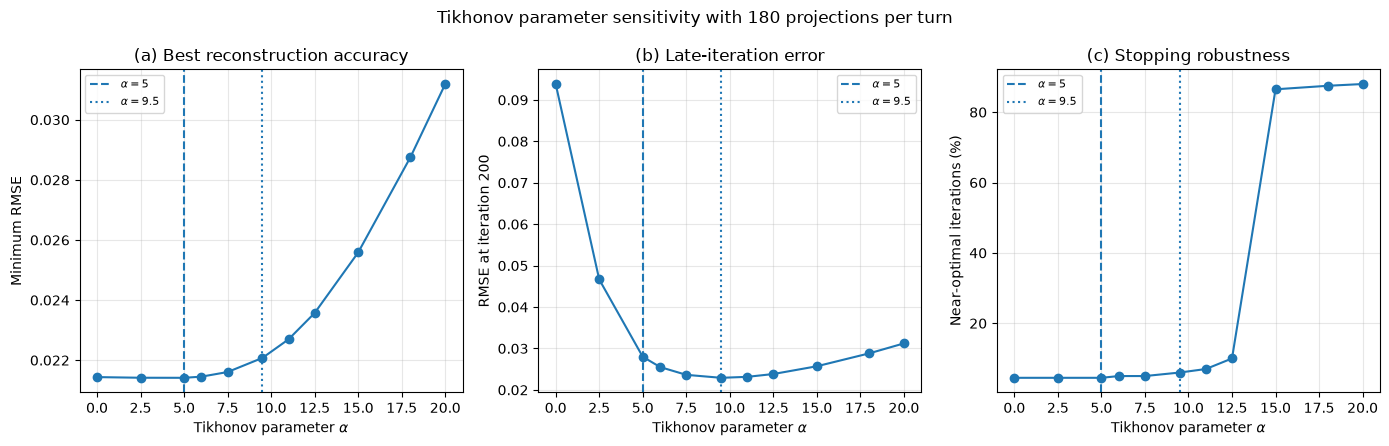

Saved: lsqr_validation_results_pitch48/figures/tikhonov_ppt180_parameter_sweep_with_reference_alphas.png


In [ ]:
# ============================================================
# Reduced-sampling parameter sweep only
# with reference alpha = 5 and alpha = 9.5
# ============================================================

summary = (
    low_ppt_tikhonov_summary
    .sort_values("alpha")
)

BASELINE_ALPHA = 5.0
DP_ALPHA = 9.5


fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
)


# ------------------------------------------------------------
# (a) Minimum RMSE
# ------------------------------------------------------------

axes[0].plot(
    summary["alpha"],
    summary["minimum_rmse"],
    marker="o",
)

axes[0].axvline(
    BASELINE_ALPHA,
    linestyle="--",
    linewidth=1.5,
    label=r"$\alpha=5$",
)

axes[0].axvline(
    DP_ALPHA,
    linestyle=":",
    linewidth=1.5,
    label=r"$\alpha=9.5$",
)

axes[0].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[0].set_ylabel(
    "Minimum RMSE"
)

axes[0].set_title(
    "(a) Best reconstruction accuracy"
)

axes[0].grid(
    True,
    alpha=0.3,
)

axes[0].legend(
    fontsize=8
)


# ------------------------------------------------------------
# (b) RMSE at iteration 200
# ------------------------------------------------------------

axes[1].plot(
    summary["alpha"],
    summary[
        "rmse_at_iteration_200"
    ],
    marker="o",
)

axes[1].axvline(
    BASELINE_ALPHA,
    linestyle="--",
    linewidth=1.5,
    label=r"$\alpha=5$",
)

axes[1].axvline(
    DP_ALPHA,
    linestyle=":",
    linewidth=1.5,
    label=r"$\alpha=9.5$",
)

axes[1].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[1].set_ylabel(
    "RMSE at iteration 200"
)

axes[1].set_title(
    "(b) Late-iteration error"
)

axes[1].grid(
    True,
    alpha=0.3,
)

axes[1].legend(
    fontsize=8
)


# ------------------------------------------------------------
# (c) Near-optimal fraction
# ------------------------------------------------------------

axes[2].plot(
    summary["alpha"],
    100.0
    * summary[
        "near_optimal_fraction"
    ],
    marker="o",
)

axes[2].axvline(
    BASELINE_ALPHA,
    linestyle="--",
    linewidth=1.5,
    label=r"$\alpha=5$",
)

axes[2].axvline(
    DP_ALPHA,
    linestyle=":",
    linewidth=1.5,
    label=r"$\alpha=9.5$",
)

axes[2].set_xlabel(
    r"Tikhonov parameter $\alpha$"
)

axes[2].set_ylabel(
    "Near-optimal iterations (%)"
)

axes[2].set_title(
    "(c) Stopping robustness"
)

axes[2].grid(
    True,
    alpha=0.3,
)

axes[2].legend(
    fontsize=8
)


# ------------------------------------------------------------
# Overall title and layout
# ------------------------------------------------------------

fig.suptitle(
    "Tikhonov parameter sensitivity "
    "with 180 projections per turn"
)

fig.tight_layout()


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_ppt180_parameter_sweep_with_reference_alphas.png",
)

fig.savefig(
    path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

In [ ]:
# ============================================================
# Tikhonov reconstruction + difference comparison
#
# Top row:
#     longitudinal reconstruction
#
# Bottom row:
#     reconstruction - ground truth
#
# One column for each alpha
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


def plot_tikhonov_longitudinal_comparison(
    results_dict,
    truth,
    alpha_values,
    iteration,
    output_filename,
    figure_title=None,
):
    """
    Compare Tikhonov reconstructions using longitudinal y=0 slices.

    Parameters
    ----------
    results_dict : dict
        Dictionary indexed by alpha.
        Each result must contain:
            result["iterates"][iteration]

    truth : CIL ImageData
        Ground-truth phantom.

    alpha_values : list
        Alpha values to compare.

    iteration : int
        Common LSQR iteration displayed for all alpha values.

    output_filename : str
        Filename saved inside RESULTS_DIRECTORY/figures/.

    figure_title : str or None
        Optional title for notebook display.
        Can be removed for dissertation figures.
    """

    # --------------------------------------------------------
    # 1. Ground truth
    # --------------------------------------------------------

    truth_array = np.asarray(
        truth.as_array(),
        dtype=np.float64,
    )

    # Array ordering is (z, y, x).
    nz, ny, nx = truth_array.shape

    if "y0_idx" in globals():
        y_index = int(y0_idx)
    else:
        y_index = ny // 2

    truth_slice = truth_array[
        :,
        y_index,
        :
    ]


    # --------------------------------------------------------
    # 2. Extract all reconstruction slices
    # --------------------------------------------------------

    reconstruction_slices = {}
    difference_slices = {}
    rmse_values = {}

    for alpha_value in alpha_values:

        if alpha_value not in results_dict:
            raise KeyError(
                f"alpha={alpha_value:g} "
                "is not available in results_dict."
            )

        result = results_dict[
            alpha_value
        ]

        if iteration not in result["iterates"]:
            raise KeyError(
                f"Iteration {iteration} "
                f"is not stored for alpha={alpha_value:g}."
            )

        reconstruction_array = np.asarray(
            result["iterates"][
                iteration
            ].as_array(),
            dtype=np.float64,
        )

        reconstruction_slice = (
            reconstruction_array[
                :,
                y_index,
                :
            ]
        )

        reconstruction_slices[
            alpha_value
        ] = reconstruction_slice

        difference_slices[
            alpha_value
        ] = (
            reconstruction_slice
            - truth_slice
        )


        # ----------------------------------------------------
        # RMSE at the selected iteration
        # ----------------------------------------------------

        history = result["history"]

        rmse_row = history.loc[
            history["iteration"]
            == iteration,
            "rmse",
        ]

        if len(rmse_row) == 1:
            rmse_values[
                alpha_value
            ] = float(
                rmse_row.iloc[0]
            )

        else:
            rmse_values[
                alpha_value
            ] = np.nan


    # --------------------------------------------------------
    # 3. Shared display ranges
    # --------------------------------------------------------

    # Same grey scale for all reconstructions.
    reconstruction_vmin = float(
        np.min(truth_array)
    )

    reconstruction_vmax = float(
        np.max(truth_array)
    )


    # One symmetric colour scale for ALL difference images.
    difference_limit = max(
        float(
            np.max(
                np.abs(
                    difference_slices[
                        alpha_value
                    ]
                )
            )
        )
        for alpha_value in alpha_values
    )


    # --------------------------------------------------------
    # 4. Physical coordinate extent
    # --------------------------------------------------------

    longitudinal_extent = [
        -half_width,
         half_width,
        -half_height,
         half_height,
    ]


    # --------------------------------------------------------
    # 5. Create figure
    # --------------------------------------------------------

    n_columns = len(alpha_values)

    fig, axes = plt.subplots(
        2,
        n_columns,
        figsize=(
            2.7 * n_columns,
            8.0,
        ),
        constrained_layout=True,
    )

    axes = np.asarray(
        axes
    ).reshape(
        2,
        n_columns,
    )


    # --------------------------------------------------------
    # 6. Plot each alpha
    # --------------------------------------------------------

    reconstruction_image = None
    difference_image = None

    for col, alpha_value in enumerate(
        alpha_values
    ):

        reconstruction_slice = (
            reconstruction_slices[
                alpha_value
            ]
        )

        difference_slice = (
            difference_slices[
                alpha_value
            ]
        )


        # ====================================================
        # Top row: reconstruction
        # ====================================================

        reconstruction_image = (
            axes[0, col].imshow(
                reconstruction_slice,
                origin="lower",
                extent=longitudinal_extent,
                cmap="gray",
                vmin=reconstruction_vmin,
                vmax=reconstruction_vmax,
                aspect="equal",
            )
        )

        rmse_value = rmse_values[
            alpha_value
        ]

        axes[0, col].set_title(
            rf"$\alpha={alpha_value:g}$"
            "\n"
            rf"RMSE={rmse_value:.4f}"
        )


        # ====================================================
        # Bottom row: difference
        # ====================================================

        difference_image = (
            axes[1, col].imshow(
                difference_slice,
                origin="lower",
                extent=longitudinal_extent,
                cmap="bwr",
                vmin=-difference_limit,
                vmax=difference_limit,
                aspect="equal",
            )
        )


        # ----------------------------------------------------
        # Axis labels
        # ----------------------------------------------------

        axes[1, col].set_xlabel(
            "$x$"
        )

        if col == 0:

            axes[0, col].set_ylabel(
                "$z$"
            )

            axes[1, col].set_ylabel(
                "$z$"
            )

        else:

            axes[0, col].set_yticklabels([])
            axes[1, col].set_yticklabels([])


        # Top row does not need x tick labels.
        axes[0, col].set_xticklabels([])


    # --------------------------------------------------------
    # 7. Row labels on the left
    # --------------------------------------------------------

    axes[0, 0].text(
        -0.28,
        0.5,
        "Reconstruction",
        transform=axes[0, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
    )

    axes[1, 0].text(
        -0.28,
        0.5,
        "Difference",
        transform=axes[1, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=11,
    )


    # --------------------------------------------------------
    # 8. Difference colour bar
    # --------------------------------------------------------

    colourbar = fig.colorbar(
        difference_image,
        ax=axes[1, :],
        orientation="horizontal",
        fraction=0.06,
        pad=0.08,
        aspect=35,
    )

    colourbar.set_label(
        r"$x_k-x_{\mathrm{true}}$"
    )


    # --------------------------------------------------------
    # 9. Optional notebook title
    # --------------------------------------------------------

    if figure_title is not None:

        fig.suptitle(
            figure_title,
            fontsize=13,
        )


    # --------------------------------------------------------
    # 10. Save
    # --------------------------------------------------------

    figure_path = os.path.join(
        RESULTS_DIRECTORY,
        "figures",
        output_filename,
    )

    os.makedirs(
        os.path.dirname(
            figure_path
        ),
        exist_ok=True,
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        figure_path,
    )

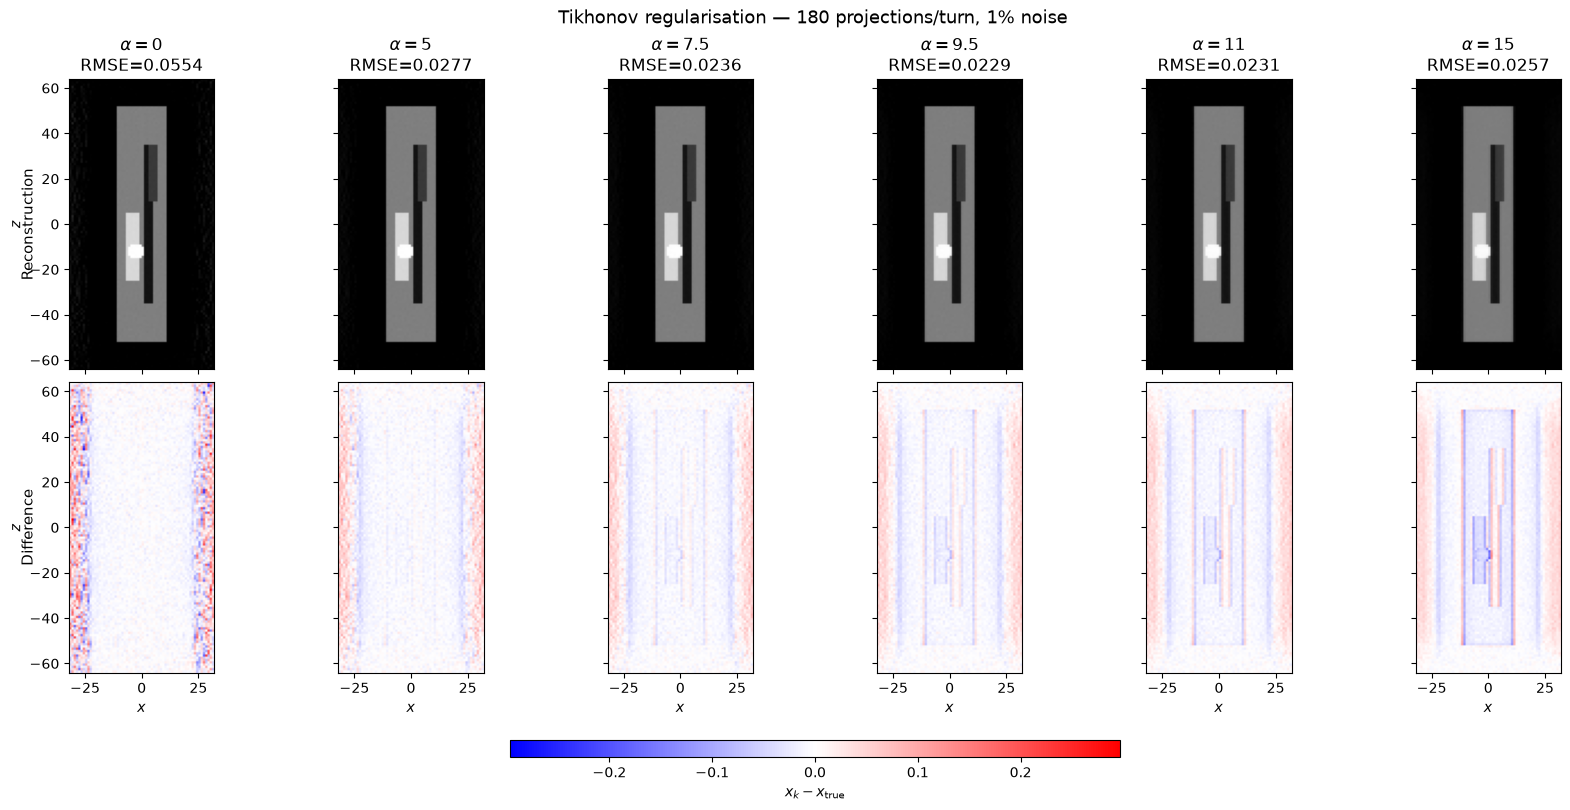

Saved: lsqr_validation_results_pitch48/figures/tikhonov_ppt180_longitudinal_comparison.png


In [ ]:
plot_tikhonov_longitudinal_comparison(
    results_dict=low_ppt_tikhonov_results,
    truth=low_ppt_truth,
    alpha_values=[0.0, 5.0, 7.5, 9.5, 11.0, 15.0],
    iteration=100,
    output_filename=(
        "tikhonov_ppt180_"
        "longitudinal_comparison.png"
    ),
    figure_title=(
        "Tikhonov regularisation — "
        "180 projections/turn, 1% noise"
    ),
)

## 12. Reconstruction-level regularisation comparisons

Visualise representative reconstructions from the Tikhonov sweep to complement the scalar RMSE summaries and show how increasing regularisation changes reconstruction appearance across iteration.


## 13. Discrepancy-principle parameter selection

Evaluate Morozov-type discrepancy criteria for selecting the regularisation parameter from the known synthetic noise level, and compare the selected values with the oracle RMSE-based choices.


In [ ]:
# ============================================================
# T6. Discrepancy Principle (DP) parameter selection
#
# Reuse the existing unified Tikhonov baseline:
#   pitch = 48
#   projections per turn = 360
#   total projections = 1080
#   Gaussian noise = 1%
#   max iterations = 100
#
# Morozov discrepancy principle:
#
#   ||A x_alpha - b_noisy||_2 ~= tau * delta
#
# where
#
#   delta = ||b_noisy - b_clean||_2
#
# ============================================================


DP_TAU = 1.05


# ------------------------------------------------------------
# 1. Compute the ACTUAL noise norm
# ------------------------------------------------------------

dp_noise_array = (
    as_float64(tikhonov_data)
    - as_float64(tikhonov_clean_data)
)

dp_noise_norm = float(
    np.linalg.norm(
        dp_noise_array.ravel()
    )
)

dp_clean_data_norm = float(
    np.linalg.norm(
        as_float64(
            tikhonov_clean_data
        ).ravel()
    )
)

dp_noisy_data_norm = float(
    np.linalg.norm(
        as_float64(
            tikhonov_data
        ).ravel()
    )
)


# Noise level relative to clean data.
# This should be approximately 0.01 because the noisy
# projection-density experiment was constructed such that
#
#   ||noise|| / ||b_clean|| = 0.01
#
dp_relative_noise_clean = (
    dp_noise_norm
    /
    max(
        dp_clean_data_norm,
        1e-30,
    )
)


# Since run_lsqr_with_diagnostics stores
#
#   relative_residual
#       = ||Ax-b_noisy|| / ||b_noisy||
#
# the corresponding DP target in the same normalisation is
#
#   tau * delta / ||b_noisy||
#
dp_relative_noise_noisy = (
    dp_noise_norm
    /
    max(
        dp_noisy_data_norm,
        1e-30,
    )
)

dp_target_absolute = (
    DP_TAU
    *
    dp_noise_norm
)

dp_target_relative = (
    DP_TAU
    *
    dp_relative_noise_noisy
)


print("Discrepancy Principle setup")
print("---------------------------")

print(
    "||b_clean||_2:",
    f"{dp_clean_data_norm:.8e}",
)

print(
    "||b_noisy||_2:",
    f"{dp_noisy_data_norm:.8e}",
)

print(
    "delta = ||noise||_2:",
    f"{dp_noise_norm:.8e}",
)

print(
    "actual relative noise "
    "(relative to clean data):",
    f"{dp_relative_noise_clean:.8f}",
)

print(
    "actual relative noise "
    "(relative to noisy data):",
    f"{dp_relative_noise_noisy:.8f}",
)

print(
    "tau:",
    DP_TAU,
)

print(
    "DP relative residual target:",
    f"{dp_target_relative:.8f}",
)

Discrepancy Principle setup
---------------------------
||b_clean||_2: 4.31794916e+04
||b_noisy||_2: 4.31815720e+04
delta = ||noise||_2: 4.31794916e+02
actual relative noise (relative to clean data): 0.01000000
actual relative noise (relative to noisy data): 0.00999952
tau: 1.05
DP relative residual target: 0.01049949


In [ ]:
# ============================================================
# T6b. Apply the Discrepancy Principle to the existing
#      Tikhonov alpha sweep
#
# IMPORTANT:
# Use iteration 100 for every alpha.
#
# Do NOT use best_iteration here, because best_iteration was
# selected using ground-truth RMSE and would therefore mix
# oracle stopping with the discrepancy principle.
# ============================================================


dp_rows = []


for alpha_value in TIKHONOV_ALPHA_VALUES:

    result = tikhonov_results[
        alpha_value
    ]

    history = result[
        "history"
    ]

    # All baseline Tikhonov runs contain iteration 100.
    # Use the same fixed iteration for every alpha.
    dp_row_100 = (
        history[
            history["iteration"]
            == TIKHONOV_MAX_ITERATIONS
        ]
        .iloc[0]
    )


    # Existing diagnostic:
    #
    # ||A x_alpha - b_noisy|| / ||b_noisy||
    #
    relative_residual = float(
        dp_row_100[
            "relative_residual"
        ]
    )


    # Recover the absolute data residual:
    #
    # ||A x_alpha - b_noisy||
    #
    absolute_residual = (
        relative_residual
        *
        dp_noisy_data_norm
    )


    # Morozov discrepancy ratio:
    #
    # ||A x_alpha - b_noisy|| / delta
    #
    discrepancy_ratio = (
        absolute_residual
        /
        max(
            dp_noise_norm,
            1e-30,
        )
    )


    # DP target:
    #
    # discrepancy_ratio ~= tau
    #
    dp_distance = abs(
        discrepancy_ratio
        -
        DP_TAU
    )


    dp_rows.append(
        {
            "alpha":
                float(alpha_value),

            "iteration":
                int(
                    dp_row_100[
                        "iteration"
                    ]
                ),

            "relative_residual":
                relative_residual,

            "absolute_residual":
                absolute_residual,

            "noise_norm_delta":
                dp_noise_norm,

            "discrepancy_ratio":
                discrepancy_ratio,

            "tau":
                DP_TAU,

            "relative_dp_target":
                dp_target_relative,

            "distance_to_dp_target":
                dp_distance,
        }
    )


dp_summary = (
    pd.DataFrame(
        dp_rows
    )
    .sort_values(
        "alpha"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Select tested alpha closest to the DP target
# ------------------------------------------------------------

dp_best_index = (
    dp_summary[
        "distance_to_dp_target"
    ]
    .idxmin()
)


dp_best_row = (
    dp_summary
    .loc[
        dp_best_index
    ]
)


alpha_dp_grid = float(
    dp_best_row[
        "alpha"
    ]
)


display(
    dp_summary[
        [
            "alpha",
            "iteration",
            "relative_residual",
            "discrepancy_ratio",
            "tau",
            "distance_to_dp_target",
        ]
    ]
)

,alpha,iteration,relative_residual,discrepancy_ratio,tau,distance_to_dp_target
0,0.0,100,0.010121,1.012138,1.05,0.037862
1,2.0,100,0.010060,1.006036,1.05,0.043964
2,5.0,100,0.010018,1.001806,1.05,0.048194
3,7.5,100,0.010169,1.016901,1.05,0.033099
4,8.0,100,0.010227,1.022764,1.05,0.027236
5,8.5,100,0.010298,1.029802,1.05,0.020198
6,9.0,100,0.010381,1.038131,1.05,0.011869
7,9.5,100,0.010478,1.047846,1.05,0.002154
8,10.0,100,0.010590,1.059055,1.05,0.009055
9,11.0,100,0.010863,1.086329,1.05,0.036329


In [ ]:
# ============================================================
# T6e. Fine sweep for Discrepancy Principle alpha
#
# Coarse sweep showed the DP crossing is between
# alpha = 7.5 and alpha = 10.0
#
# Fixed:
#   pitch = 48
#   projections per turn = 360
#   Gaussian noise = 1%
#   iterations = 100
#   tau = 1.05
# ============================================================

DP_FINE_ALPHA_VALUES = [
    7.5,
    8.0,
    8.5,
    9.0,
    9.25,
    9.5,
    9.75,
    10.0,
    10.5,
    11.0,
    11.5,
]

dp_fine_results = {}
dp_fine_rows = []


for alpha_value in DP_FINE_ALPHA_VALUES:

    print()
    print("=" * 68)

    print(
        f"Running fine DP Tikhonov: "
        f"alpha={alpha_value:g}"
    )

    initial = (
        tikhonov_image_geometry.allocate(
            0.0
        )
    )

    # Same solver call as the existing baseline Tikhonov sweep
    result = run_lsqr_with_diagnostics(
        operator_local=tikhonov_operator,
        data_local=tikhonov_data,
        truth_local=tikhonov_truth,
        initial_local=initial,
        number_of_iterations_local=(
            TIKHONOV_MAX_ITERATIONS
        ),
        alpha=alpha_value,
        checkpoint_interval=1,
    )

    dp_fine_results[
        alpha_value
    ] = result


    # --------------------------------------------------------
    # Use the reconstruction at the fixed final iteration
    # --------------------------------------------------------

    history = result[
        "history"
    ]

    row_100 = (
        history[
            history["iteration"]
            == TIKHONOV_MAX_ITERATIONS
        ]
        .iloc[0]
    )


    # Existing diagnostic:
    #
    # ||A x_alpha - b_noisy|| / ||b_noisy||
    #
    relative_residual = (
        row_100[
            "relative_residual"
        ]
    )


    # DP discrepancy ratio:
    #
    # ||A x_alpha - b_noisy|| / delta
    #
    # Since:
    #
    # relative_residual
    #   = ||Ax-b|| / ||b||
    #
    # dp_relative_noise_noisy
    #   = delta / ||b||
    #
    # divide the two.
    #
    discrepancy_ratio = (
        relative_residual
        /
        dp_relative_noise_noisy
    )


    signed_gap = (
        discrepancy_ratio
        -
        DP_TAU
    )


    dp_fine_rows.append(
        {
            "alpha":
                alpha_value,

            "iteration":
                TIKHONOV_MAX_ITERATIONS,

            "relative_residual":
                relative_residual,

            "discrepancy_ratio":
                discrepancy_ratio,

            "tau":
                DP_TAU,

            "signed_gap":
                signed_gap,

            "distance_to_target":
                abs(
                    signed_gap
                ),
        }
    )


# ============================================================
# Fine-sweep summary
# ============================================================

dp_fine_summary = (
    pd.DataFrame(
        dp_fine_rows
    )
    .sort_values(
        "alpha"
    )
    .reset_index(
        drop=True
    )
)


display(
    dp_fine_summary
)


Running fine DP Tikhonov: alpha=7.5

Running fine DP Tikhonov: alpha=8

Running fine DP Tikhonov: alpha=8.5

Running fine DP Tikhonov: alpha=9

Running fine DP Tikhonov: alpha=9.25

Running fine DP Tikhonov: alpha=9.5

Running fine DP Tikhonov: alpha=9.75

Running fine DP Tikhonov: alpha=10

Running fine DP Tikhonov: alpha=10.5

Running fine DP Tikhonov: alpha=11

Running fine DP Tikhonov: alpha=11.5


,alpha,iteration,relative_residual,discrepancy_ratio,tau,signed_gap,distance_to_target
0,7.50,100,0.010169,1.016901,1.05,-0.033099,0.033099
1,8.00,100,0.010227,1.022764,1.05,-0.027236,0.027236
2,8.50,100,0.010298,1.029802,1.05,-0.020198,0.020198
3,9.00,100,0.010381,1.038131,1.05,-0.011869,0.011869
4,9.25,100,0.010428,1.042809,1.05,-0.007191,0.007191
5,9.50,100,0.010478,1.047846,1.05,-0.002154,0.002154
6,9.75,100,0.010532,1.053258,1.05,0.003258,0.003258
7,10.00,100,0.010590,1.059055,1.05,0.009055,0.009055
8,10.50,100,0.010718,1.071853,1.05,0.021853,0.021853
9,11.00,100,0.010863,1.086329,1.05,0.036329,0.036329


## 14. Regularisation stability and discrepancy sensitivity

Extend selected Tikhonov runs to 200 iterations to assess late-iteration stability and examine the sensitivity of discrepancy-based selection to the tolerance parameter $\tau$.


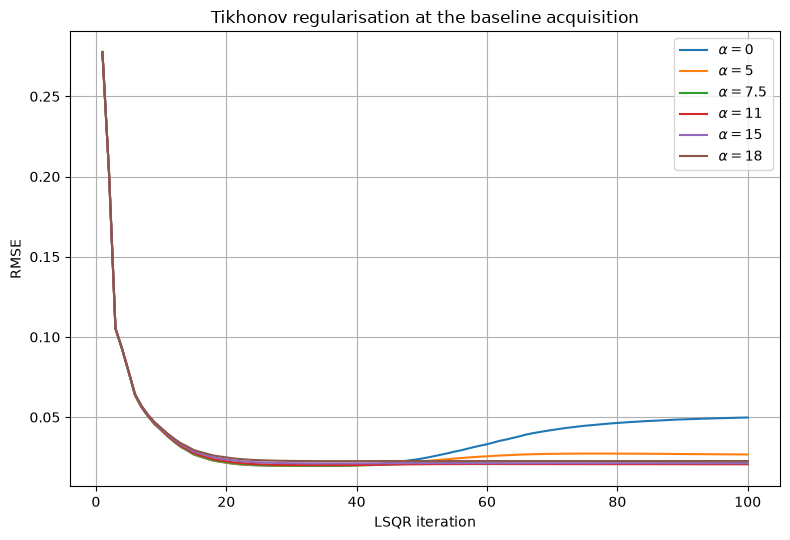

Saved: lsqr_validation_results_pitch48/figures/tikhonov_baseline_rmse_trajectories.png


In [ ]:
# ============================================================
# Figure 4.x
# Representative Tikhonov RMSE histories
# Baseline acquisition:
# pitch = 48, 360 projections/turn, 1% noise
# ============================================================

REPRESENTATIVE_BASELINE_ALPHAS = [
    0.0,
    5.0,
    7.5,
    11.0,
    15.0,
    18.0,
]


fig, ax = plt.subplots(
    figsize=(8, 5.5)
)


for alpha_value in REPRESENTATIVE_BASELINE_ALPHAS:

    if alpha_value not in tikhonov_results:
        raise KeyError(
            f"alpha={alpha_value} is not available "
            "in tikhonov_results."
        )

    history = (
        tikhonov_results[
            alpha_value
        ]["history"]
    )

    ax.plot(
        history["iteration"],
        history["rmse"],
        label=rf"$\alpha={alpha_value:g}$",
    )


ax.set_xlabel(
    "LSQR iteration"
)

ax.set_ylabel(
    "RMSE"
)

ax.set_title(
    "Tikhonov regularisation at the baseline acquisition"
)

ax.grid(True)

ax.legend()

fig.tight_layout()


figure_path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_baseline_rmse_trajectories.png",
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    figure_path,
)

In [ ]:
# ============================================================
# Extended baseline Tikhonov runs to 200 iterations
#
# Purpose:
# Examine long-iteration behaviour for representative alpha
# values without rerunning the full parameter sweep.
# ============================================================

TIKHONOV_EXTENDED_ITERATIONS = 200

TIKHONOV_EXTENDED_ALPHAS = [
    0.0,
    5.0,
    7.5,
    9.5,
    11.0,
    15.0,
    18.0,
]

tikhonov_extended_results = {}


for alpha_value in TIKHONOV_EXTENDED_ALPHAS:

    print(
        f"Running extended baseline Tikhonov: "
        f"alpha={alpha_value:g}"
    )

    initial = (
        tikhonov_image_geometry.allocate(0.0)
    )

    result = run_lsqr_with_diagnostics(
        operator_local=tikhonov_operator,
        data_local=tikhonov_data,
        truth_local=tikhonov_truth,
        initial_local=initial,
        number_of_iterations_local=TIKHONOV_EXTENDED_ITERATIONS,
        alpha=alpha_value,
        checkpoint_interval=1,
    )

    tikhonov_extended_results[
        alpha_value
    ] = result

    print(
        f"  best iteration = "
        f"{result['best_iteration']}"
    )

    print(
        f"  minimum RMSE = "
        f"{result['minimum_rmse']:.8f}"
    )

    print(
        f"  RMSE at 200 = "
        f"{result['final_rmse']:.8f}"
    )









# ------------------------------------------------------------
# Reference alpha values
# ------------------------------------------------------------

ALPHA_MIN_RMSE = 5.0
ALPHA_DP = 9.5


for ax in axes:

    ax.axvline(
        ALPHA_MIN_RMSE,
        linestyle="--",
        linewidth=1.2,
        label=(
            r"$\alpha_{\mathrm{RMSE}}"
            r"\approx4$"
        ),
    )

    ax.axvline(
        ALPHA_DP,
        linestyle=":",
        linewidth=1.2,
        label=(
            r"$\alpha_{\mathrm{DP}}"
            r"\approx9.5$"
        ),
    )


# Only one legend is enough
axes[0].legend()

Running extended baseline Tikhonov: alpha=0
  best iteration = 31
  minimum RMSE = 0.01967796
  RMSE at 200 = 0.06530956
Running extended baseline Tikhonov: alpha=5
  best iteration = 32
  minimum RMSE = 0.01965983
  RMSE at 200 = 0.02646385
Running extended baseline Tikhonov: alpha=7.5
  best iteration = 34
  minimum RMSE = 0.01970912
  RMSE at 200 = 0.02200149
Running extended baseline Tikhonov: alpha=9.5
  best iteration = 35
  minimum RMSE = 0.01985106
  RMSE at 200 = 0.02085796
Running extended baseline Tikhonov: alpha=11
  best iteration = 35
  minimum RMSE = 0.02005215
  RMSE at 200 = 0.02060531
Running extended baseline Tikhonov: alpha=15
  best iteration = 37
  minimum RMSE = 0.02114544
  RMSE at 200 = 0.02127301
Running extended baseline Tikhonov: alpha=18
  best iteration = 37
  minimum RMSE = 0.02256924
  RMSE at 200 = 0.02262765


/tmp/slurm.19931162/ipykernel_2308276/1269274594.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


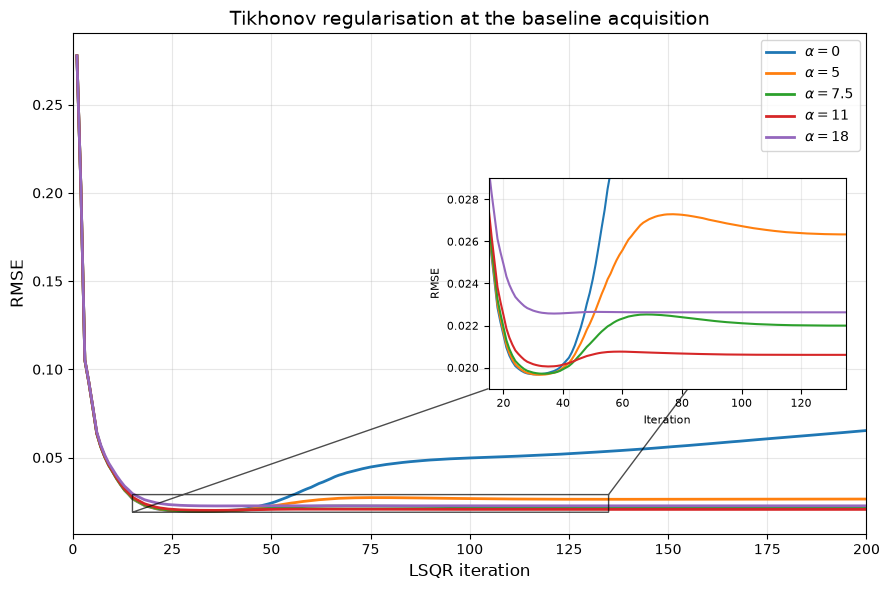

Saved: lsqr_validation_results_pitch48/figures/tikhonov_baseline_rmse_with_inset.png


In [ ]:
# ============================================================
# Tikhonov RMSE trajectories with inset zoom
# Baseline acquisition, 200 LSQR iterations
# ============================================================

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

PLOT_ALPHAS = [
    0.0,
    5.0,
    7.5,
    #9.5,
    11.0,
    #15.0,
    18.0,
]

fig, ax = plt.subplots(
    figsize=(9, 6)
)

# ------------------------------------------------------------
# Main figure
# ------------------------------------------------------------

for alpha_value in PLOT_ALPHAS:

    history = (
        tikhonov_extended_results[
            alpha_value
        ]["history"]
    )

    ax.plot(
        history["iteration"],
        history["rmse"],
        linewidth=2,
        label=rf"$\alpha={alpha_value:g}$",
    )

ax.set_xlim(0, 200)

ax.set_xlabel(
    "LSQR iteration",
    fontsize=12,
)

ax.set_ylabel(
    "RMSE",
    fontsize=12,
)

ax.set_title(
    "Tikhonov regularisation at the baseline acquisition",
    fontsize=14,
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    loc="upper right",
    fontsize=10,
)


# ------------------------------------------------------------
# Inset: minimum-RMSE region
# ------------------------------------------------------------

axins = inset_axes(
    ax,
    width="45%",
    height="42%",
    loc="center right",
    borderpad=1.5,
)

for alpha_value in PLOT_ALPHAS:

    history = (
        tikhonov_extended_results[
            alpha_value
        ]["history"]
    )

    axins.plot(
        history["iteration"],
        history["rmse"],
        linewidth=1.5,
    )

# Zoomed region
axins.set_xlim(
    15,
    135,
)

axins.set_ylim(
    0.019,
    0.029
)

axins.set_xlabel(
    "Iteration",
    fontsize=8,
)

axins.set_ylabel(
    "RMSE",
    fontsize=8,
)

axins.tick_params(
    axis="both",
    labelsize=8,
)

axins.grid(
    True,
    alpha=0.25,
)


# ------------------------------------------------------------
# Indicate zoomed region on main plot
# ------------------------------------------------------------

ax.indicate_inset_zoom(
    axins,
    edgecolor="black",
    alpha=0.7,
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig.tight_layout()

figure_path = os.path.join(
    RESULTS_DIRECTORY,
    "figures",
    "tikhonov_baseline_rmse_with_inset.png",
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    figure_path,
)

Available alpha values:
[0.0, 2.0, 5.0, 7.5, 8.0, 8.5, 9.0, 9.25, 9.5, 9.75, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 15.0, 18.0, 20.0, 25.0, 30.0]


,alpha,iteration,relative_residual,discrepancy_ratio
0,0.00,100,0.010121,1.012138
1,2.00,100,0.010060,1.006036
2,5.00,100,0.010018,1.001806
3,7.50,100,0.010169,1.016901
4,8.00,100,0.010227,1.022764
5,8.50,100,0.010298,1.029802
6,9.00,100,0.010381,1.038131
7,9.25,100,0.010428,1.042809
8,9.50,100,0.010478,1.047846
9,9.75,100,0.010532,1.053258



Morozov tau-sensitivity summary
--------------------------------


,tau,selected_alpha,relative_residual,discrepancy_ratio,distance_to_target
0,1.010,0.0,0.010121,1.012138,0.002138
1,1.015,7.5,0.010169,1.016901,0.001901
2,1.025,8.0,0.010227,1.022764,0.002236
3,1.050,9.5,0.010478,1.047846,0.002154
4,1.075,10.5,0.010718,1.071853,0.003147
5,1.100,11.5,0.011025,1.102570,0.002570



Original DP consistency check:
tau = 1.05
selected alpha = 9.5
discrepancy ratio = 1.0478456828590308


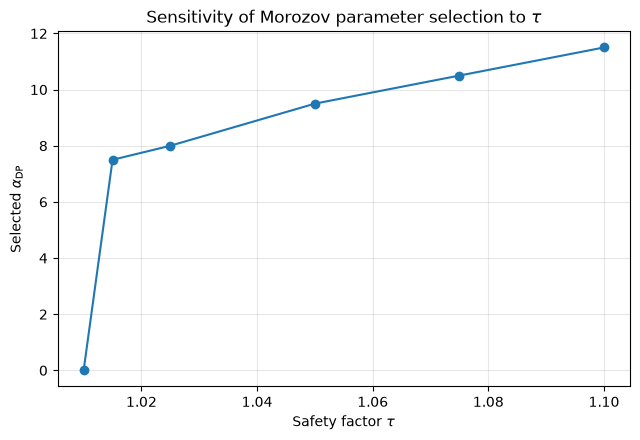

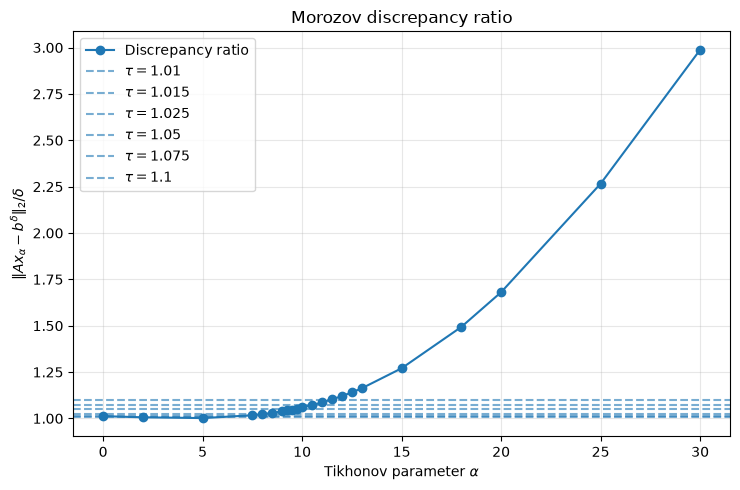

In [ ]:
# ============================================================
# T6f. Morozov discrepancy principle:
#      sensitivity to the safety factor tau
#
# Reuses the EXISTING baseline + fine DP Tikhonov results.
# No LSQR reconstruction is rerun.
#
# Fixed:
#   pitch = 48
#   projections per turn = 360
#   Gaussian noise = 1%
#   evaluation iteration = 100
#
# Existing definition:
#
#   discrepancy ratio
#       = ||A x_alpha - b_noisy||_2 / delta
#
# where
#
#   delta = ||b_noisy - b_clean||_2
#
# Morozov target:
#
#   discrepancy ratio ~= tau
# ============================================================


# ------------------------------------------------------------
# 1. Safety factors to test
# ------------------------------------------------------------

DP_TAU_VALUES = [
    1.01,
    1.015,
    1.025,
    1.05,
    1.075,
    1.10,
]


# ------------------------------------------------------------
# 2. Combine all EXISTING baseline and fine-DP results
#
# tikhonov_results:
#     baseline alpha sweep
#
# dp_fine_results:
#     additional fine alpha sweep around the DP crossing
# ------------------------------------------------------------

dp_tau_results = {}

for alpha_value, result in (
    tikhonov_results.items()
):

    dp_tau_results[
        float(alpha_value)
    ] = result


for alpha_value, result in (
    dp_fine_results.items()
):

    dp_tau_results[
        float(alpha_value)
    ] = result


print(
    "Available alpha values:"
)

print(
    sorted(
        dp_tau_results.keys()
    )
)


# ------------------------------------------------------------
# 3. Extract iteration-100 discrepancy ratio
#
# run_lsqr_with_diagnostics stores:
#
#   relative_residual
#       = ||A x_alpha - b_noisy|| / ||b_noisy||
#
# Earlier DP setup already defined:
#
#   dp_relative_noise_noisy
#       = delta / ||b_noisy||
#
# Therefore:
#
#   discrepancy_ratio
#       = relative_residual
#         / dp_relative_noise_noisy
#       = ||A x_alpha - b_noisy|| / delta
# ------------------------------------------------------------

dp_tau_alpha_rows = []


for alpha_value in sorted(
    dp_tau_results.keys()
):

    result = (
        dp_tau_results[
            alpha_value
        ]
    )

    history = result[
        "history"
    ]

    row_100 = (
        history[
            history["iteration"]
            ==
            TIKHONOV_MAX_ITERATIONS
        ]
        .iloc[0]
    )

    relative_residual = float(
        row_100[
            "relative_residual"
        ]
    )

    discrepancy_ratio = (
        relative_residual
        /
        dp_relative_noise_noisy
    )

    dp_tau_alpha_rows.append(
        {
            "alpha":
                float(
                    alpha_value
                ),

            "iteration":
                int(
                    TIKHONOV_MAX_ITERATIONS
                ),

            "relative_residual":
                relative_residual,

            "discrepancy_ratio":
                float(
                    discrepancy_ratio
                ),
        }
    )


dp_tau_alpha_summary = (
    pd.DataFrame(
        dp_tau_alpha_rows
    )
    .sort_values(
        "alpha"
    )
    .reset_index(
        drop=True
    )
)


display(
    dp_tau_alpha_summary
)


# ------------------------------------------------------------
# 4. Select alpha_DP for each tau
#
# IMPORTANT:
# This follows EXACTLY the selection rule used in your
# existing DP code:
#
# choose the tested alpha whose discrepancy ratio is
# closest to tau.
# ------------------------------------------------------------

dp_tau_sensitivity_rows = []


for tau_value in DP_TAU_VALUES:

    temp = (
        dp_tau_alpha_summary
        .copy()
    )

    temp[
        "distance_to_target"
    ] = np.abs(
        temp[
            "discrepancy_ratio"
        ]
        -
        tau_value
    )

    best_index = (
        temp[
            "distance_to_target"
        ]
        .idxmin()
    )

    best_row = (
        temp.loc[
            best_index
        ]
    )

    dp_tau_sensitivity_rows.append(
        {
            "tau":
                float(
                    tau_value
                ),

            "selected_alpha":
                float(
                    best_row[
                        "alpha"
                    ]
                ),

            "relative_residual":
                float(
                    best_row[
                        "relative_residual"
                    ]
                ),

            "discrepancy_ratio":
                float(
                    best_row[
                        "discrepancy_ratio"
                    ]
                ),

            "distance_to_target":
                float(
                    best_row[
                        "distance_to_target"
                    ]
                ),
        }
    )


dp_tau_sensitivity_summary = (
    pd.DataFrame(
        dp_tau_sensitivity_rows
    )
)


print(
    "\nMorozov tau-sensitivity summary"
)

print(
    "--------------------------------"
)

display(
    dp_tau_sensitivity_summary
)


# ------------------------------------------------------------
# 5. Check that tau = 1.05 reproduces the original DP result
# ------------------------------------------------------------

original_tau_row = (
    dp_tau_sensitivity_summary[
        np.isclose(
            dp_tau_sensitivity_summary[
                "tau"
            ],
            DP_TAU,
        )
    ]
)


if not original_tau_row.empty:

    print(
        "\nOriginal DP consistency check:"
    )

    print(
        "tau =",
        DP_TAU,
    )

    print(
        "selected alpha =",
        float(
            original_tau_row.iloc[
                0
            ][
                "selected_alpha"
            ]
        ),
    )

    print(
        "discrepancy ratio =",
        float(
            original_tau_row.iloc[
                0
            ][
                "discrepancy_ratio"
            ]
        ),
    )


# ------------------------------------------------------------
# 6. Plot alpha_DP against tau
# ------------------------------------------------------------

plt.figure(
    figsize=(
        6.5,
        4.5,
    )
)

plt.plot(
    dp_tau_sensitivity_summary[
        "tau"
    ],
    dp_tau_sensitivity_summary[
        "selected_alpha"
    ],
    marker="o",
)

plt.xlabel(
    r"Safety factor $\tau$"
)

plt.ylabel(
    r"Selected $\alpha_{\mathrm{DP}}$"
)

plt.title(
    "Sensitivity of Morozov parameter selection "
    r"to $\tau$"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 7. Plot discrepancy ratio against alpha
#    with all tau targets
# ------------------------------------------------------------

plt.figure(
    figsize=(
        7.5,
        5.0,
    )
)

plt.plot(
    dp_tau_alpha_summary[
        "alpha"
    ],
    dp_tau_alpha_summary[
        "discrepancy_ratio"
    ],
    marker="o",
    label="Discrepancy ratio",
)


for tau_value in DP_TAU_VALUES:

    plt.axhline(
        tau_value,
        linestyle="--",
        alpha=0.6,
        label=(
            rf"$\tau={tau_value:g}$"
        ),
    )


plt.xlabel(
    r"Tikhonov parameter $\alpha$"
)

plt.ylabel(
    r"$\|Ax_\alpha-b^\delta\|_2/\delta$"
)

plt.title(
    "Morozov discrepancy ratio"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

plt.show()

## 15. Regularisation at low projection density

Repeat the regularisation comparison for sparsely sampled acquisition settings to examine whether the preferred strength of Tikhonov regularisation changes as projection density is reduced.


In [ ]:
# 180-ppt problem setup

LOW_PPT = 180
LOW_PPT_PITCH = BASELINE_PITCH
LOW_PPT_NOISE_LEVEL = 0.01
LOW_PPT_NOISE_SEED = 42
LOW_PPT_MAX_ITERATIONS = 200

#LOW_PPT_ALPHAS = [0.0, 5.0,10.0, 12.5, 15.0, 20.0, 30.0,]
LOW_PPT_ALPHAS = [0.0, 5.0,7.5, 11.0, 18.0]

# Retrieve the exact clean 180-ppt problem already built
low_ppt_problem = projection_results[LOW_PPT]["problem"]

low_ppt_operator = low_ppt_problem["operator"]

low_ppt_clean_data = (
    low_ppt_problem["projection_data"].copy()
)

low_ppt_truth = (
    low_ppt_problem["phantom"].copy()
)

low_ppt_image_geometry = (
    low_ppt_problem["image_geometry"]
)

low_ppt_initial = (
    low_ppt_image_geometry.allocate(0.0)
)

In [ ]:
# Reconstruction --  deterministic 1% Gaussian noise

low_ppt_clean_array = np.asarray(
    low_ppt_clean_data.as_array(),
    dtype=np.float64,
)

low_ppt_clean_norm = np.linalg.norm(
    low_ppt_clean_array.ravel()
)

rng = np.random.default_rng(
    LOW_PPT_NOISE_SEED
)

noise_direction = rng.standard_normal(
    low_ppt_clean_array.shape
)

noise_direction /= max(
    np.linalg.norm(
        noise_direction.ravel()
    ),
    1e-30,
)

low_ppt_noise_array = (
    LOW_PPT_NOISE_LEVEL
    * low_ppt_clean_norm
    * noise_direction
)

low_ppt_data = (
    low_ppt_clean_data.copy()
)

low_ppt_data.fill(
    (
        low_ppt_clean_array
        + low_ppt_noise_array
    ).astype(np.float32)
)

low_ppt_actual_relative_noise = (
    np.linalg.norm(
        low_ppt_noise_array.ravel()
    )
    / max(
        low_ppt_clean_norm,
        1e-30,
    )
)

In [ ]:
# 200-iteration Tikhonov sweep

low_ppt_tikhonov_results = {}

for alpha_value in LOW_PPT_ALPHAS:

    print("\n" + "=" * 72)

    print(
        f"Running low-projection Tikhonov LSQR: "
        f"ppt={LOW_PPT}, alpha={alpha_value:g}"
    )

    result = run_lsqr_with_diagnostics(
        operator_local=low_ppt_operator,
        data_local=low_ppt_data,
        truth_local=low_ppt_truth,
        initial_local=low_ppt_initial,
        number_of_iterations_local=LOW_PPT_MAX_ITERATIONS,
        alpha=alpha_value,
        checkpoint_interval=1,
    )

    low_ppt_tikhonov_results[
        alpha_value
    ] = result

    h = result["history"]

    best_idx = h["rmse"].idxmin()
    best = h.loc[best_idx]

    penalty_ratio_best = (
        float(
            best["regularisation_penalty"]
        )
        / max(
            float(
                best["data_fidelity"]
            ),
            1e-30,
        )
    )

    def get_rmse(k):
        rows = h.loc[
            h["iteration"] == k,
            "rmse"
        ]

        if len(rows) == 0:
            return np.nan

        return float(rows.iloc[0])

    print(
        f"best iteration        = "
        f"{result['best_iteration']}"
    )

    print(
        f"minimum RMSE          = "
        f"{result['minimum_rmse']:.8f}"
    )

    print(
        f"RMSE at iteration 100 = "
        f"{get_rmse(100):.8f}"
    )

    print(
        f"RMSE at iteration 150 = "
        f"{get_rmse(150):.8f}"
    )

    print(
        f"RMSE at iteration 200 = "
        f"{get_rmse(200):.8f}"
    )

    print(
        f"near-optimal range    = "
        f"{result['near_optimal_start']}–"
        f"{result['near_optimal_end']}"
    )

    print(
        f"near-optimal width    = "
        f"{result['near_optimal_end'] - result['near_optimal_start'] + 1}"
    )

    print(
        f"penalty/data at best  = "
        f"{penalty_ratio_best:.6f}"
    )


Running low-projection Tikhonov LSQR: ppt=180, alpha=0
best iteration        = 28
minimum RMSE          = 0.02143801
RMSE at iteration 100 = 0.05543405
RMSE at iteration 150 = 0.07448578
RMSE at iteration 200 = 0.09383417
near-optimal range    = 24–32
near-optimal width    = 9
penalty/data at best  = 0.000000

Running low-projection Tikhonov LSQR: ppt=180, alpha=5
best iteration        = 30
minimum RMSE          = 0.02141470
RMSE at iteration 100 = 0.02774239
RMSE at iteration 150 = 0.02795120
RMSE at iteration 200 = 0.02799253
near-optimal range    = 26–34
near-optimal width    = 9
penalty/data at best  = 10.370416

Running low-projection Tikhonov LSQR: ppt=180, alpha=7.5
best iteration        = 31
minimum RMSE          = 0.02160706
RMSE at iteration 100 = 0.02362580
RMSE at iteration 150 = 0.02363358
RMSE at iteration 200 = 0.02363450
near-optimal range    = 27–36
near-optimal width    = 10
penalty/data at best  = 20.649392

Running low-projection Tikhonov LSQR: ppt=180, alpha=11
be

In [ ]:
# summary table + CSV

low_ppt_rows = []

low_ppt_reference_rmse = (
    low_ppt_tikhonov_results[
        0.0
    ]["minimum_rmse"]
)


for alpha_value in (
    #LOW_PPT_ALPHA_VALUES
    LOW_PPT_ALPHAS
):

    result = (
        low_ppt_tikhonov_results[
            alpha_value
        ]
    )

    history = result["history"]

    final = history.iloc[-1]

    near_optimal_width = (
        result["near_optimal_end"]
        - result["near_optimal_start"]
        + 1
    )

    near_optimal_fraction = (
        near_optimal_width
        / LOW_PPT_MAX_ITERATIONS
    )

    low_ppt_rows.append(
        {
            "alpha":
                alpha_value,

            "best_iteration":
                int(
                    result[
                        "best_iteration"
                    ]
                ),

            "minimum_rmse":
                float(
                    result[
                        "minimum_rmse"
                    ]
                ),

            "rmse_at_iteration_200":
                float(
                    final["rmse"]
                ),

            "near_optimal_start":
                int(
                    result[
                        "near_optimal_start"
                    ]
                ),

            "near_optimal_end":
                int(
                    result[
                        "near_optimal_end"
                    ]
                ),

            "near_optimal_width":
                int(
                    near_optimal_width
                ),

            "near_optimal_fraction":
                float(
                    near_optimal_fraction
                ),

            "relative_minimum_rmse_penalty":
                float(
                    result[
                        "minimum_rmse"
                    ]
                    / low_ppt_reference_rmse
                    - 1.0
                ),
        }
    )


low_ppt_tikhonov_summary = (
    pd.DataFrame(
        low_ppt_rows
    )
    .sort_values("alpha")
    .reset_index(drop=True)
)

display(
    low_ppt_tikhonov_summary
)


summary_path = os.path.join(
    RESULTS_DIRECTORY,
    "tikhonov_low_projection_ppt180_summary.csv",
)

low_ppt_tikhonov_summary.to_csv(
    summary_path,
    index=False,
)

,alpha,best_iteration,minimum_rmse,rmse_at_iteration_200,near_optimal_start,near_optimal_end,near_optimal_width,near_optimal_fraction,relative_minimum_rmse_penalty
0,0.0,28,0.021438,0.093834,24,32,9,0.045,0.000000
1,5.0,30,0.021415,0.027993,26,34,9,0.045,-0.001087
2,7.5,31,0.021607,0.023634,27,36,10,0.050,0.007886
3,11.0,34,0.022695,0.023149,28,41,14,0.070,0.058648
4,18.0,35,0.028754,0.028811,26,200,175,0.875,0.341271


## 16. Supplementary regularisation diagnostics

The following diagnostics were retained for computational completeness although they are not used directly in the final dissertation figures.


# Geometry mismatch and TD-window experiments

This part investigates reconstruction when the geometry used by the reconstruction operator differs from the geometry that generated the data. Full-detector and Tam--Danielsson (TD) window reconstructions are compared under controlled source-to-detector distance (SDD), axis-displacement, and centre-of-rotation (COR) errors.


## 17. TD-window construction and validation

Construct the TD support from the true acquisition geometry and verify the corresponding data selection before introducing geometric mismatch. The same true-data support is retained in the controlled mismatch comparisons.


In [ ]:
# ============================================================
# D3-TD utilities
# Tam-Danielsson window for the current planar detector
# ============================================================

from cil.optimisation.operators import (
    MaskOperator,
    CompositionOperator,
)


def build_td_window_mask(
    problem,
    detector_pixel_size_horizontal=1.0,
    detector_pixel_size_vertical=1.0,
    source_origin_distance=130.0,
    origin_detector_distance=130.0,
):
    """
    Construct the Tam-Danielsson window mask for one constant-pitch
    helical problem.

    The mask is rebuilt separately for every pitch.

    For the current notebook:
        R = source-origin distance
        D = source-detector distance
        p = helical pitch per full rotation

    The returned mask has exactly the same geometry and shape as
    problem["projection_data"].
    """

    pitch_local = float(problem["pitch"])

    R = float(source_origin_distance)

    D = float(
        source_origin_distance
        + origin_detector_distance
    )

    projection_data = problem["projection_data"]

    data_shape = projection_data.shape

    # Current ASTRA ordering in this notebook:
    #
    #   (vertical, projection, horizontal)
    #
    # e.g. baseline = (160, 1080, 96)
    #
    number_vertical = data_shape[0]
    number_projections = data_shape[1]
    number_horizontal = data_shape[2]

    # --------------------------------------------------------
    # Detector coordinates
    # --------------------------------------------------------

    u = (
        np.arange(
            number_horizontal,
            dtype=np.float64,
        )
        - (number_horizontal - 1) / 2.0
    ) * detector_pixel_size_horizontal

    v = (
        np.arange(
            number_vertical,
            dtype=np.float64,
        )
        - (number_vertical - 1) / 2.0
    ) * detector_pixel_size_vertical

    # Fan coordinate associated with detector coordinate u
    gamma = np.arctan(
        u / D
    )

    # --------------------------------------------------------
    # Tam-Danielsson boundaries
    #
    # v_upper(u)
    # v_lower(u)
    # --------------------------------------------------------

    geometric_factor = (
        D
        * pitch_local
        / (2.0 * np.pi * R)
        * (
            1.0
            + (u / D) ** 2
        )
    )

    v_upper = (
        geometric_factor
        * (
            np.pi / 2.0
            - gamma
        )
    )

    v_lower = (
        -geometric_factor
        * (
            np.pi / 2.0
            + gamma
        )
    )

    # --------------------------------------------------------
    # 2-D detector mask:
    # shape = (vertical, horizontal)
    # --------------------------------------------------------

    detector_mask_2d = (
        (v[:, None] >= v_lower[None, :])
        &
        (v[:, None] <= v_upper[None, :])
    )

    # --------------------------------------------------------
    # Same TD shape applies at every view for a
    # constant-pitch helix in the rotating detector frame.
    #
    # Expand to:
    #   (vertical, projection, horizontal)
    # --------------------------------------------------------

    mask_array = np.broadcast_to(
        detector_mask_2d[:, None, :],
        (
            number_vertical,
            number_projections,
            number_horizontal,
        ),
    ).astype(np.float32).copy()

    mask_data = projection_data.copy()
    mask_data.fill(mask_array)

    # --------------------------------------------------------
    # Check whether the mathematical TD window fits entirely
    # inside the physical detector.
    # --------------------------------------------------------

    detector_v_min = float(v.min())
    detector_v_max = float(v.max())

    td_required_min_v = float(
        np.min(v_lower)
    )

    td_required_max_v = float(
        np.max(v_upper)
    )

    td_window_fully_contained = bool(
        td_required_min_v >= detector_v_min
        and
        td_required_max_v <= detector_v_max
    )

    diagnostics = {
        "pitch": pitch_local,
        "source_origin_distance": R,
        "source_detector_distance": D,
        "detector_v_min": detector_v_min,
        "detector_v_max": detector_v_max,
        "td_required_min_v": td_required_min_v,
        "td_required_max_v": td_required_max_v,
        "td_window_fully_contained":
            td_window_fully_contained,
        "td_mask_fraction":
            float(mask_array.mean()),
        "v_lower": v_lower,
        "v_upper": v_upper,
        "u": u,
        "v": v,
    }

    return mask_data, diagnostics


def build_td_problem(problem):
    """
    Convert an already-built full-detector problem into the
    corresponding TD-window problem.

    A_TD = M_TD A
    b_TD = M_TD b_clean

    This preserves the image geometry and acquisition geometry.
    """

    td_mask, td_diagnostics = (
        build_td_window_mask(problem)
    )

    mask_operator = MaskOperator(
        td_mask,
        domain_geometry=(
            problem["operator"]
            .range_geometry()
        ),
    )

    td_operator = CompositionOperator(
        mask_operator,
        problem["operator"],
    )

    td_data = mask_operator.direct(
        problem["projection_data"]
    )

    td_problem = dict(problem)

    td_problem.update(
        {
            "operator": td_operator,
            "projection_data": td_data,
            "td_mask": td_mask,
            "td_diagnostics": td_diagnostics,
            "full_detector_operator":
                problem["operator"],
            "full_detector_projection_data":
                problem["projection_data"],
        }
    )

    return td_problem

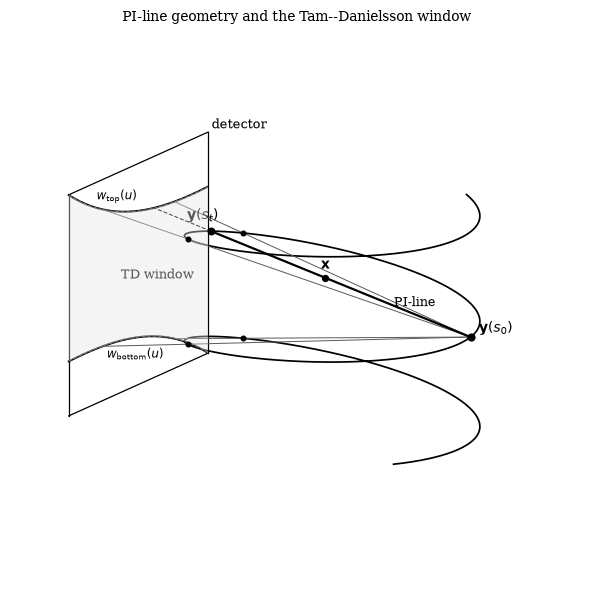

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Publication-style integrated geometry:
#
#   helix
#     +
#   PI-line
#     +
#   rays intersecting helix twice
#     +
#   Tam--Danielsson window on detector
#
# The TD boundaries are obtained in TWO equivalent ways:
#
#   1. geometrically:
#      source -> second helix point -> detector
#
#   2. analytically:
#      w_top(u), w_bottom(u)
#
# They should coincide.
# ============================================================


# ============================================================
# 0. Plot settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
})

fig = plt.figure(
    figsize=(10.5, 6.2)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)


# ============================================================
# 1. Helical geometry
# ============================================================
#
# Helix:
#
# y(s) =
# (
#   R cos(s),
#   R sin(s),
#   h s
# )
#
# where
#
#     h = P / (2*pi)
#
# and P is the axial rise per complete turn.
# ============================================================

R = 1.0

P = 1.0

h = (
    P
    /
    (2.0 * np.pi)
)


def helix(s):
    """
    Helical source trajectory.
    """
    s = np.asarray(s)

    return np.stack(
        [
            R * np.cos(s),
            R * np.sin(s),
            h * s,
        ],
        axis=-1,
    )


# ------------------------------------------------------------
# Draw slightly more than two turns
# ------------------------------------------------------------

s_curve = np.linspace(
    -2.25 * np.pi,
    2.25 * np.pi,
    1200,
)

Y = helix(
    s_curve
)

ax.plot(
    Y[:, 0],
    Y[:, 1],
    Y[:, 2],
    color="black",
    linewidth=1.25,
)


# ============================================================
# 2. Current source position
# ============================================================
#
# Choose s0 = 0 for clarity.
#
# Then:
#
#     y(s0) = (R, 0, 0)
#
# ============================================================

s0 = 0.0

source = helix(
    s0
)

ax.scatter(
    [source[0]],
    [source[1]],
    [source[2]],
    s=24,
    color="black",
    depthshade=False,
    zorder=10,
)

ax.text(
    source[0] + 0.06,
    source[1],
    source[2] + 0.06,
    r"$\mathbf{y}(s_0)$",
)


# ============================================================
# 3. Flat detector geometry
# ============================================================
#
# At s0 = 0:
#
# source is on +x axis.
#
# Detector is placed opposite the source and perpendicular
# to the source-axis direction.
#
# D = source-to-detector distance.
#
# Detector plane:
#
#     x = R - D
#
# ============================================================

D = 2.40

detector_x = (
    R
    -
    D
)


# detector horizontal and vertical extents
u_det = 1.35
w_det = 1.05


# Local detector coordinates:
#
# u -> global y
# w -> global z

detector_corners = np.array([
    [detector_x, -u_det, -w_det],
    [detector_x,  u_det, -w_det],
    [detector_x,  u_det,  w_det],
    [detector_x, -u_det,  w_det],
])


# ------------------------------------------------------------
# Detector outline
# ------------------------------------------------------------

for i in range(4):

    p1 = detector_corners[i]

    p2 = detector_corners[
        (i + 1) % 4
    ]

    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        [p1[2], p2[2]],
        color="black",
        linewidth=0.9,
    )


ax.text(
    detector_x,
    u_det + 0.07,
    w_det + 0.02,
    "detector",
    fontsize=9,
)


# ============================================================
# 4. Ray from source through another helix point
# ============================================================
#
# Let t = s' - s0.
#
# A ray starting at y(s0) and passing through y(s0+t)
# intersects the detector.
#
# These detector intersections generate the TD boundaries.
# ============================================================


def detector_intersection_from_helix(t):
    """
    Intersection of the line through

        y(s0)
        and
        y(s0+t)

    with the detector plane.

    Since s0 = 0, the detector is x = R-D.
    """

    second_source = helix(
        s0 + t
    )

    direction = (
        second_source
        -
        source
    )

    lam = (
        detector_x
        -
        source[0]
    ) / direction[0]

    detector_point = (
        source
        +
        lam * direction
    )

    return (
        second_source,
        detector_point,
    )


# ============================================================
# 5. Generate geometric TD boundaries
# ============================================================
#
# Upper boundary:
#     0 < t < 2*pi
#
# Lower boundary:
#    -2*pi < t < 0
#
# Near t=0 and +/-2*pi, detector coordinates diverge,
# so exclude small neighbourhoods of those limits.
# ============================================================

eps = 0.16

t_upper = np.linspace(
    eps,
    2.0 * np.pi - eps,
    1000,
)

t_lower = np.linspace(
    -2.0 * np.pi + eps,
    -eps,
    1000,
)


upper_points = []
lower_points = []


for t in t_upper:

    _, p = (
        detector_intersection_from_helix(t)
    )

    # Keep only detector points inside plotted detector
    if (
        abs(p[1]) <= u_det
        and
        abs(p[2]) <= w_det
    ):
        upper_points.append(
            p
        )


for t in t_lower:

    _, p = (
        detector_intersection_from_helix(t)
    )

    if (
        abs(p[1]) <= u_det
        and
        abs(p[2]) <= w_det
    ):
        lower_points.append(
            p
        )


upper_points = np.asarray(
    upper_points
)

lower_points = np.asarray(
    lower_points
)


# ------------------------------------------------------------
# Geometrically generated TD boundary
# ------------------------------------------------------------

ax.plot(
    upper_points[:, 0],
    upper_points[:, 1],
    upper_points[:, 2],
    color="black",
    linewidth=1.45,
)

ax.plot(
    lower_points[:, 0],
    lower_points[:, 1],
    lower_points[:, 2],
    color="black",
    linewidth=1.45,
)


# ============================================================
# 6. Analytical Tam--Danielsson boundaries
# ============================================================
#
# For s0 = 0 and the detector convention used here:
#
# w_top(u)
# =
# P/(2*pi*R*D)
# (u^2 + D^2)
# [
#     pi/2 - atan(u/D)
# ]
#
#
# w_bottom(u)
# =
# -P/(2*pi*R*D)
# (u^2 + D^2)
# [
#     pi/2 + atan(u/D)
# ]
#
# ============================================================

u = np.linspace(
    -u_det,
    u_det,
    800,
)


factor = (
    P
    /
    (
        2.0
        *
        np.pi
        *
        R
        *
        D
    )
)


w_top = (
    factor
    *
    (
        u**2
        +
        D**2
    )
    *
    (
        np.pi / 2.0
        -
        np.arctan(
            u / D
        )
    )
)


w_bottom = (
    -factor
    *
    (
        u**2
        +
        D**2
    )
    *
    (
        np.pi / 2.0
        +
        np.arctan(
            u / D
        )
    )
)


# ------------------------------------------------------------
# Restrict formula curves to detector extent
# ------------------------------------------------------------

mask_top = (
    np.abs(w_top)
    <=
    w_det
)

mask_bottom = (
    np.abs(w_bottom)
    <=
    w_det
)


# ------------------------------------------------------------
# Overlay analytical solution as dashed thin line
#
# Because the geometric and analytical curves coincide,
# the dashed line should lie essentially on top of the
# solid boundary.
# ------------------------------------------------------------

ax.plot(
    np.full(
        np.sum(mask_top),
        detector_x,
    ),
    u[mask_top],
    w_top[mask_top],
    linestyle="--",
    color="0.35",
    linewidth=0.75,
)

ax.plot(
    np.full(
        np.sum(mask_bottom),
        detector_x,
    ),
    u[mask_bottom],
    w_bottom[mask_bottom],
    linestyle="--",
    color="0.35",
    linewidth=0.75,
)


# ============================================================
# 7. Light TD-window shading
# ============================================================
#
# Very light grey only.
# Avoid large coloured surfaces.
# ============================================================

u_fill = np.linspace(
    -u_det,
    u_det,
    180,
)


w_top_fill = (
    factor
    *
    (
        u_fill**2
        +
        D**2
    )
    *
    (
        np.pi / 2.0
        -
        np.arctan(
            u_fill / D
        )
    )
)


w_bottom_fill = (
    -factor
    *
    (
        u_fill**2
        +
        D**2
    )
    *
    (
        np.pi / 2.0
        +
        np.arctan(
            u_fill / D
        )
    )
)


# Only shade portions inside detector
valid = (
    (w_top_fill <= w_det)
    &
    (w_bottom_fill >= -w_det)
)


u_valid = (
    u_fill[valid]
)

top_valid = (
    w_top_fill[valid]
)

bottom_valid = (
    w_bottom_fill[valid]
)


# Make narrow quadrilateral strips
for i in range(
    len(u_valid) - 1
):

    Y_strip = np.array([
        [
            u_valid[i],
            u_valid[i + 1],
        ],
        [
            u_valid[i],
            u_valid[i + 1],
        ],
    ])

    Z_strip = np.array([
        [
            bottom_valid[i],
            bottom_valid[i + 1],
        ],
        [
            top_valid[i],
            top_valid[i + 1],
        ],
    ])

    X_strip = np.full_like(
        Y_strip,
        detector_x,
    )

    ax.plot_surface(
        X_strip,
        Y_strip,
        Z_strip,
        color="0.90",
        edgecolor="none",
        alpha=0.42,
        shade=False,
    )


# ============================================================
# 8. Representative boundary rays
# ============================================================
#
# These are the key geometrical rays:
#
# current source
#     ->
# another point on the helix
#     ->
# TD boundary on detector
#
# ============================================================

sample_t = [
    0.82 * np.pi,
    1.18 * np.pi,
    -0.82 * np.pi,
    -1.18 * np.pi,
]


for t in sample_t:

    second_source, detector_point = (
        detector_intersection_from_helix(
            t
        )
    )

    if (
        abs(detector_point[1])
        <=
        u_det
        and
        abs(detector_point[2])
        <=
        w_det
    ):

        # Entire ray:
        # current source -> second helix point -> detector

        ax.plot(
            [
                source[0],
                detector_point[0],
            ],
            [
                source[1],
                detector_point[1],
            ],
            [
                source[2],
                detector_point[2],
            ],
            color="0.35",
            linewidth=0.7,
        )

        # Mark second helix intersection

        ax.scatter(
            [second_source[0]],
            [second_source[1]],
            [second_source[2]],
            color="black",
            s=11,
            depthshade=False,
        )


# ============================================================
# 9. PI-line
# ============================================================
#
# Choose one of the rays connecting the current source to
# another source position less than one complete turn away.
#
# A point x on this chord gives a PI-line through x.
# ============================================================

t_pi = (
    0.92
    *
    np.pi
)


pi_second_source, pi_detector = (
    detector_intersection_from_helix(
        t_pi
    )
)


# Choose an interior reconstruction point on the PI-line
alpha = 0.56

x_point = (
    (1.0 - alpha)
    *
    source
    +
    alpha
    *
    pi_second_source
)


# ------------------------------------------------------------
# PI-line segment between the two source positions
# ------------------------------------------------------------

ax.plot(
    [
        source[0],
        pi_second_source[0],
    ],
    [
        source[1],
        pi_second_source[1],
    ],
    [
        source[2],
        pi_second_source[2],
    ],
    color="black",
    linewidth=1.6,
)


# Continue same line to detector using thin dashed line
ax.plot(
    [
        pi_second_source[0],
        pi_detector[0],
    ],
    [
        pi_second_source[1],
        pi_detector[1],
    ],
    [
        pi_second_source[2],
        pi_detector[2],
    ],
    color="black",
    linewidth=0.8,
    linestyle="--",
)


# Mark second endpoint
ax.scatter(
    [pi_second_source[0]],
    [pi_second_source[1]],
    [pi_second_source[2]],
    color="black",
    s=22,
    depthshade=False,
)


# Mark reconstruction point x
# ax.scatter(
#     [x_point[0]],
#     [x_point[1]],
#     [x_point[2]],
#     color="black",
#     marker="x",
#     s=35,
#     linewidths=1.3,
#     depthshade=False,
# )

ax.scatter(
    [x_point[0]],
    [x_point[1]],
    [x_point[2]],
    color="black",
    marker="o",
    s=18,
    depthshade=False,
    zorder=10,
)

# ------------------------------------------------------------
# Labels for PI-line
# ------------------------------------------------------------

ax.text(
    pi_second_source[0] - 0.18,
    pi_second_source[1] + 0.02,
    pi_second_source[2] + 0.06,
    r"$\mathbf{y}(s_t)$",
)

ax.text(
    x_point[0] - 0.05,
    x_point[1] + 0.05,
    x_point[2] + 0.06,
    r"$\mathbf{x}$",
)


# ax.text(
#     x_point[0] - 0.02,
#     x_point[1] + 0.14,
#     x_point[2] + 0.10,
#     r"$\mathbf{x}$",
#     fontsize=9,
# )




pi_label_point = (
    0.72 * source
    +
    0.28 * pi_second_source
)

ax.text(
    pi_label_point[0],
    pi_label_point[1] - 0.08,
    pi_label_point[2] + 0.03,
    r"PI-line",
    fontsize=9,
)


# ============================================================
# 10. TD-window labels
# ============================================================

ax.text(
    detector_x - 0.015,
    -0.30,
    0.02,
    "TD window",
    fontsize=9,
)


# ------------------------------------------------------------
# Boundary labels
# Place them in visually clear parts of the detector
# ------------------------------------------------------------

# Upper boundary label
u_top_label = -0.72

w_top_label = (
    factor
    *
    (
        u_top_label**2
        +
        D**2
    )
    *
    (
        np.pi / 2.0
        -
        np.arctan(
            u_top_label / D
        )
    )
)

ax.text(
    detector_x - 0.015,
    u_top_label - 0.05,
    w_top_label + 0.10,
    r"$w_{\mathrm{top}}(u)$",
    fontsize=8.5,
)


# Lower boundary label
u_bottom_label = -0.52

w_bottom_label = (
    -factor
    *
    (
        u_bottom_label**2
        +
        D**2
    )
    *
    (
        np.pi / 2.0
        +
        np.arctan(
            u_bottom_label / D
        )
    )
)

ax.text(
    detector_x - 0.015,
    u_bottom_label - 0.05,
    w_bottom_label - 0.13,
    r"$w_{\mathrm{bottom}}(u)$",
    fontsize=8.5,
)


# ============================================================
# 11. Final publication-style presentation
# ============================================================

ax.set_proj_type(
    "ortho"
)

ax.view_init(
    elev=17,
    azim=-57,
)

ax.set_box_aspect(
    (
        2.2,
        1.45,
        1.25,
    )
)

ax.set_axis_off()


# ------------------------------------------------------------
# Limits chosen manually for clean composition
# ------------------------------------------------------------

ax.set_xlim(
    -1.55,
    1.15,
)

ax.set_ylim(
    -1.55,
    1.55,
)

ax.set_zlim(
    -1.15,
    1.15,
)


ax.set_title(
    "PI-line geometry and the Tam--Danielsson window",
    pad=4,
)


plt.tight_layout()


# ============================================================
# 12. Export
# ============================================================

plt.savefig(
    "pi_line_td_window_integrated.png",
    dpi=400,
    bbox_inches="tight",
)

plt.savefig(
    "pi_line_td_window_integrated.pdf",
    bbox_inches="tight",
)

plt.show()

## 18. Geometry-mismatch experiments

Use fixed simulated measurements while perturbing only the reconstruction geometry. This isolates the effect of model mismatch from changes in the measured data.


### 18.1 Source-to-detector distance mismatch

Perturb the reconstruction SDD while keeping the true projection data fixed, and compare full-detector and TD-window LSQR reconstructions.


In [ ]:
SDD_ERROR_PERCENTAGES = [0.0, 0.5, 1.0, 2.0, 5.0]
GEOMETRY_ERROR_MAX_ITERATIONS = 100
RUN_SDD_GEOMETRY_ERROR_SWEEP = True

sod_true = float(source_origin_distance)
odd_true = float(origin_detector_distance)
sdd_true = sod_true + odd_true

assert np.isclose(sdd_true, sod_true + odd_true)
assert np.isclose(
    sdd_true * (1.0 + SDD_ERROR_PERCENTAGES[0] / 100.0) - sod_true,
    odd_true,
)


def build_helical_reconstruction_operator_with_sdd_error(
    reference_problem,
    origin_detector_distance_value,
):
    """Build A_recon with fixed trajectory sampling and a changed detector radius.

    This function deliberately returns no projection data and contains no
    operator.direct(phantom) call.
    """
    number_of_projections_local = int(reference_problem["number_of_projections"])
    number_of_turns_local = int(reference_problem["number_of_turns"])
    total_z_travel_local = float(reference_problem["pitch"]) * number_of_turns_local

    angles_local = np.linspace(
        0.0, 2.0 * np.pi * number_of_turns_local,
        number_of_projections_local, endpoint=False, dtype=np.float32,
    )
    source_z_positions_local = np.linspace(
        -total_z_travel_local / 2.0, total_z_travel_local / 2.0,
        number_of_projections_local, endpoint=False, dtype=np.float32,
    )
    cosine, sine = np.cos(angles_local), np.sin(angles_local)
    source_positions_local = np.zeros((number_of_projections_local, 3), dtype=np.float32)
    detector_positions_local = np.zeros_like(source_positions_local)
    detector_direction_x_local = np.zeros_like(source_positions_local)
    detector_direction_y_local = np.zeros_like(source_positions_local)

    source_positions_local[:, 0] = sod_true * cosine
    source_positions_local[:, 1] = sod_true * sine
    source_positions_local[:, 2] = source_z_positions_local
    detector_positions_local[:, 0] = -float(origin_detector_distance_value) * cosine
    detector_positions_local[:, 1] = -float(origin_detector_distance_value) * sine
    detector_positions_local[:, 2] = source_z_positions_local
    detector_direction_x_local[:, 0] = -sine
    detector_direction_x_local[:, 1] = cosine
    detector_direction_y_local[:, 2] = 1.0

    acquisition_geometry_local = AcquisitionGeometry.create_Cone3D_Flex(
        source_position_set=source_positions_local,
        detector_position_set=detector_positions_local,
        detector_direction_x_set=detector_direction_x_local,
        detector_direction_y_set=detector_direction_y_local,
    )
    acquisition_geometry_local.set_panel(
        num_pixels=[detector_num_horizontal, detector_num_vertical],
        pixel_size=[detector_pixel_size_horizontal, detector_pixel_size_vertical],
    )
    acquisition_geometry_local.set_labels(["projection", "vertical", "horizontal"])
    acquisition_template_local = acquisition_geometry_local.allocate(0)
    acquisition_template_local.reorder("astra")

    operator_local = ProjectionOperator(
        image_geometry=reference_problem["image_geometry"],
        acquisition_geometry=acquisition_template_local.geometry,
        device="gpu",
    )
    return operator_local, acquisition_geometry_local


def copy_true_measurements_to_operator_range(true_data, operator_local):
    """Copy fixed measured numbers into the reconstruction geometry metadata."""
    data_for_operator = operator_local.range_geometry().allocate(0.0)
    true_values = np.asarray(true_data.as_array())
    if data_for_operator.shape != true_values.shape:
        raise ValueError(
            f"Data/operator shape mismatch: {true_values.shape} vs {data_for_operator.shape}"
        )
    # Important: numerical TRUE measurements are unchanged. Only the CIL
    # container metadata tells the solver to interpret them with A_recon.
    data_for_operator.fill(true_values)
    assert np.array_equal(data_for_operator.as_array(), true_values)
    return data_for_operator


def mean_squared_gradient_energy(image_or_array):
    """Mean over voxels of ||gradient x||_2^2, using unit voxel spacing."""
    values = (
        np.asarray(image_or_array.as_array(), dtype=np.float64)
        if hasattr(image_or_array, "as_array")
        else np.asarray(image_or_array, dtype=np.float64)
    )
    gradients = np.gradient(values)
    return float(np.mean(sum(component**2 for component in gradients)))



def _descending_crossing_position(position, normalised_value, level):
    """Linearly interpolate the first descending crossing of one level."""
    position = np.asarray(position, dtype=np.float64)
    normalised_value = np.asarray(normalised_value, dtype=np.float64)
    candidates = np.where(
        (normalised_value[:-1] >= level)
        & (normalised_value[1:] <= level)
    )[0]
    if candidates.size == 0:
        return np.nan
    index = int(candidates[-1])
    y0, y1 = normalised_value[index:index + 2]
    if np.isclose(y0, y1):
        return float(position[index])
    fraction = (level - y0) / (y1 - y0)
    return float(position[index] + fraction * (position[index + 1] - position[index]))


def measure_outer_edge_width(
    image_or_array,
    half_width_value=half_width,
    object_radius=11.0,
    profile_y_coordinates=(-8.0, -6.0, 6.0, 8.0),
):
    """Measure 10--90% widths at eight clean outer-cylinder edges.

    The central transverse slice is sampled along horizontal lines at y =
    -8, -6, 6, and 8 physical units. Both left and right outer boundaries
    are used. Local interior/background medians normalise each transition.
    """
    volume = (
        np.asarray(image_or_array.as_array(), dtype=np.float64)
        if hasattr(image_or_array, "as_array")
        else np.asarray(image_or_array, dtype=np.float64)
    )
    transverse = volume[volume.shape[0] // 2]
    number_y, number_x = transverse.shape
    voxel_x = 2.0 * half_width_value / number_x
    voxel_y = 2.0 * half_width_value / number_y
    x = (np.arange(number_x) - (number_x - 1) / 2.0) * voxel_x
    y = (np.arange(number_y) - (number_y - 1) / 2.0) * voxel_y
    widths = []

    for requested_y in profile_y_coordinates:
        row = int(np.argmin(np.abs(y - requested_y)))
        y_actual = float(y[row])
        boundary_x = np.sqrt(max(object_radius**2 - y_actual**2, 0.0))
        profile = transverse[row]
        for side in (-1.0, 1.0):
            outward_position = side * x
            order = np.argsort(outward_position)
            distance = outward_position[order]
            values = profile[order]
            local = (distance >= boundary_x - 5.0) & (distance <= boundary_x + 5.0)
            interior = (distance >= boundary_x - 4.0) & (distance <= boundary_x - 2.0)
            background = (distance >= boundary_x + 2.0) & (distance <= boundary_x + 4.0)
            interior_level = float(np.median(values[interior]))
            background_level = float(np.median(values[background]))
            contrast = interior_level - background_level
            if abs(contrast) < 1e-12:
                continue
            normalised = (values[local] - background_level) / contrast
            local_distance = distance[local]
            p90 = _descending_crossing_position(local_distance, normalised, 0.9)
            p10 = _descending_crossing_position(local_distance, normalised, 0.1)
            if np.isfinite(p90) and np.isfinite(p10):
                widths.append(abs(p10 - p90))

    if not widths:
        return {"mean_edge_width_10_90": np.nan, "std_edge_width_10_90": np.nan, "number_of_edges": 0}
    return {
        "mean_edge_width_10_90": float(np.mean(widths)),
        "std_edge_width_10_90": float(np.std(widths, ddof=1)) if len(widths) > 1 else 0.0,
        "number_of_edges": len(widths),
    }


In [ ]:
# Build true data and run the SDD sweep

true_full_problem = build_helical_problem(
    pitch_value=BASELINE_PITCH,
    projections_per_turn_value=BASELINE_PROJECTIONS_PER_TURN,
    phantom_array_input=phantom_array,
)
true_full_projection_data = true_full_problem["projection_data"].copy()

# TD-window uses the full horizontal detector width.
true_td_problem = build_td_problem( true_full_problem )

true_td_projection_data = true_td_problem["projection_data"].copy()
true_td_mask_values = np.asarray(true_td_problem["td_mask"].as_array()).copy()

full_true_values_guard = np.asarray(true_full_projection_data.as_array()).copy()
td_true_values_guard = np.asarray(true_td_projection_data.as_array()).copy()
truth_sharpness = mean_squared_gradient_energy(true_full_problem["phantom"])
truth_edge_diagnostic = measure_outer_edge_width(true_full_problem["phantom"])
truth_edge_width = truth_edge_diagnostic["mean_edge_width_10_90"]

sdd_geometry_error_results = {"full_detector": {}, "td_window": {}}
sdd_geometry_error_rows = []

if RUN_SDD_GEOMETRY_ERROR_SWEEP:
    for sdd_error_percent in SDD_ERROR_PERCENTAGES:
        sdd_reconstruction = sdd_true * (1.0 + sdd_error_percent / 100.0)
        odd_reconstruction = sdd_reconstruction - sod_true
        if np.isclose(sdd_error_percent, 0.0):
            assert np.isclose(sdd_reconstruction, sdd_true)
            assert np.isclose(odd_reconstruction, odd_true)

        print("\n" + "=" * 72)
        print(
            f"SDD mismatch: {sdd_error_percent:g}% | "
            f"SDD_recon={sdd_reconstruction:.3f}, ODD_recon={odd_reconstruction:.3f}"
        )

        wrong_full_operator, wrong_acquisition_geometry = (
            build_helical_reconstruction_operator_with_sdd_error(
                true_full_problem,
                origin_detector_distance_value=odd_reconstruction,
            )
        )
        full_data_for_wrong_operator = copy_true_measurements_to_operator_range(
            true_full_projection_data, wrong_full_operator
        )

        # Reuse the TRUE-acquisition TD support. Its numerical mask is copied
        # to the wrong operator's range geometry; it is not recomputed at SDD_recon.
        wrong_td_mask = wrong_full_operator.range_geometry().allocate(0.0)
        assert wrong_td_mask.shape == true_td_mask_values.shape
        wrong_td_mask.fill(true_td_mask_values)
        wrong_td_mask_operator = MaskOperator(
            wrong_td_mask,
            domain_geometry=wrong_full_operator.range_geometry(),
        )
        wrong_td_operator = CompositionOperator(
            wrong_td_mask_operator,
            wrong_full_operator,
        )
        td_data_for_wrong_operator = copy_true_measurements_to_operator_range(
            true_td_projection_data, wrong_td_operator
        )

        for detector_type, wrong_operator, fixed_data in [
            ("full_detector", wrong_full_operator, full_data_for_wrong_operator),
            ("td_window", wrong_td_operator, td_data_for_wrong_operator),
        ]:
            assert wrong_operator.range_geometry().shape == fixed_data.shape
            mismatch_diagnostics = [
                explicit_adjoint_mismatch(wrong_operator, seed=seed)
                for seed in range(5)
            ]
            mismatch_samples = [d["relative_mismatch"] for d in mismatch_diagnostics]
            initial = true_full_problem["image_geometry"].allocate(0.0)
            result = run_lsqr_with_diagnostics(
                operator_local=wrong_operator,
                data_local=fixed_data,
                truth_local=true_full_problem["phantom"],
                initial_local=initial,
                number_of_iterations_local=GEOMETRY_ERROR_MAX_ITERATIONS,
                alpha=0.0,
                checkpoint_interval=1,
            )
            assert len(result["history"]) == GEOMETRY_ERROR_MAX_ITERATIONS
            assert int(result["history"]["iteration"].iloc[-1]) == GEOMETRY_ERROR_MAX_ITERATIONS
            best_solution = result["best_reconstruction"]
            final_solution = result["final_reconstruction"]
            best_sharpness = mean_squared_gradient_energy(best_solution)
            final_sharpness = mean_squared_gradient_energy(final_solution)
            edge_best = measure_outer_edge_width(best_solution)
            edge_final = measure_outer_edge_width(final_solution)
            entry = {
                "result": result,
                "best_solution": best_solution,
                "final_solution": final_solution,
                "operator": wrong_operator,
                "data_for_reconstruction": fixed_data,
                "SDD_reconstruction": sdd_reconstruction,
                "ODD_reconstruction": odd_reconstruction,
                "adjoint_mismatch_diagnostics": mismatch_diagnostics,
                "mean_adjoint_mismatch": float(np.mean(mismatch_samples)),
                "max_adjoint_mismatch": float(np.max(mismatch_samples)),
                "sharpness": best_sharpness,
                "relative_sharpness": best_sharpness / max(truth_sharpness, 1e-30),
                "gradient_energy_at_iteration_100": final_sharpness,
                "relative_sharpness_at_iteration_100": final_sharpness / max(truth_sharpness, 1e-30),
                "edge_width_best": edge_best["mean_edge_width_10_90"],
                "edge_width_best_std": edge_best["std_edge_width_10_90"],
                "edge_width_at_iteration_100": edge_final["mean_edge_width_10_90"],
                "edge_width_at_iteration_100_std": edge_final["std_edge_width_10_90"],
            }
            sdd_geometry_error_results[detector_type][sdd_error_percent] = entry
            sdd_geometry_error_rows.append({
                "detector_type": detector_type,
                "SDD_error_percent": sdd_error_percent,
                "SOD_reconstruction": sod_true,
                "ODD_reconstruction": odd_reconstruction,
                "SDD_reconstruction": sdd_reconstruction,
                "best_iteration": result["best_iteration"],
                "minimum_rmse": result["minimum_rmse"],
                "final_rmse": result["final_rmse"],
                "relative_residual_at_best": result["relative_residual_at_best"],
                "relative_residual_at_final": result["relative_residual_at_final"],
                "solution_norm_at_best": result["solution_norm_at_best"],
                "solution_norm_at_final": result["solution_norm_at_final"],
                "mean_adjoint_mismatch": entry["mean_adjoint_mismatch"],
                "max_adjoint_mismatch": entry["max_adjoint_mismatch"],
                "gradient_energy": best_sharpness,
                "relative_sharpness": entry["relative_sharpness"],
                "rmse_at_iteration_100": result["final_rmse"],
                "relative_residual_at_iteration_100": result["relative_residual_at_final"],
                "solution_norm_at_iteration_100": result["solution_norm_at_final"],
                "rmse_deterioration_factor": result["final_rmse"] / max(result["minimum_rmse"], 1e-30),
                "rmse_deterioration_absolute": result["final_rmse"] - result["minimum_rmse"],
                "gradient_energy_at_iteration_100": entry["gradient_energy_at_iteration_100"],
                "relative_sharpness_at_iteration_100": entry["relative_sharpness_at_iteration_100"],
                "truth_edge_width": truth_edge_width,
                "edge_width_best": entry["edge_width_best"],
                "edge_width_best_std": entry["edge_width_best_std"],
                "edge_width_at_iteration_100": entry["edge_width_at_iteration_100"],
                "edge_width_at_iteration_100_std": entry["edge_width_at_iteration_100_std"],
                "relative_edge_width_best": entry["edge_width_best"] / max(truth_edge_width, 1e-30),
                "relative_edge_width_at_iteration_100": entry["edge_width_at_iteration_100"] / max(truth_edge_width, 1e-30),
            })

    # Fixed-data and no-mutation checks after every reconstruction has finished.
    assert np.array_equal(true_full_projection_data.as_array(), full_true_values_guard)
    assert np.array_equal(true_td_projection_data.as_array(), td_true_values_guard)
    assert np.isclose(source_origin_distance, sod_true)
    assert np.isclose(origin_detector_distance, odd_true)



SDD mismatch: 0% | SDD_recon=280.000, ODD_recon=150.000

SDD mismatch: 0.5% | SDD_recon=281.400, ODD_recon=151.400

SDD mismatch: 1% | SDD_recon=282.800, ODD_recon=152.800

SDD mismatch: 2% | SDD_recon=285.600, ODD_recon=155.600

SDD mismatch: 5% | SDD_recon=294.000, ODD_recon=164.000


In [ ]:
sdd_geometry_error_summary = pd.DataFrame(sdd_geometry_error_rows)
detector_order = pd.CategoricalDtype(
    ["full_detector", "td_window"], ordered=True
)
if not sdd_geometry_error_summary.empty:
    sdd_geometry_error_summary["detector_type"] = (
        sdd_geometry_error_summary["detector_type"].astype(detector_order)
    )
    sdd_geometry_error_summary = sdd_geometry_error_summary.sort_values(
        ["SDD_error_percent", "detector_type"]
    ).reset_index(drop=True)
    assert len(sdd_geometry_error_summary) == 2 * len(SDD_ERROR_PERCENTAGES)

sdd_geometry_error_summary_path = os.path.join(
    RESULTS_DIRECTORY, "sdd_geometry_error_summary.csv"
)
sdd_geometry_error_summary.to_csv(sdd_geometry_error_summary_path, index=False)
print("Saved:", sdd_geometry_error_summary_path)
display(sdd_geometry_error_summary)


geometry_deterioration_rows = []
for error_percent in SDD_ERROR_PERCENTAGES:
    full = sdd_geometry_error_summary[
        (sdd_geometry_error_summary["detector_type"] == "full_detector")
        & (sdd_geometry_error_summary["SDD_error_percent"] == error_percent)
    ].iloc[0]
    td = sdd_geometry_error_summary[
        (sdd_geometry_error_summary["detector_type"] == "td_window")
        & (sdd_geometry_error_summary["SDD_error_percent"] == error_percent)
    ].iloc[0]
    geometry_deterioration_rows.append({
        "SDD_error_percent": error_percent,
        "full_best_iteration": full["best_iteration"],
        "td_best_iteration": td["best_iteration"],
        "full_minimum_rmse": full["minimum_rmse"],
        "td_minimum_rmse": td["minimum_rmse"],
        "full_rmse_at_100": full["rmse_at_iteration_100"],
        "td_rmse_at_100": td["rmse_at_iteration_100"],
        "full_rmse_deterioration_factor": full["rmse_deterioration_factor"],
        "td_rmse_deterioration_factor": td["rmse_deterioration_factor"],
        "full_relative_residual_at_100": full["relative_residual_at_iteration_100"],
        "td_relative_residual_at_100": td["relative_residual_at_iteration_100"],
        "full_edge_width_best": full["edge_width_best"],
        "td_edge_width_best": td["edge_width_best"],
        "full_edge_width_at_100": full["edge_width_at_iteration_100"],
        "td_edge_width_at_100": td["edge_width_at_iteration_100"],
    })
geometry_deterioration_summary = pd.DataFrame(geometry_deterioration_rows)
geometry_deterioration_summary_path = os.path.join(
    RESULTS_DIRECTORY, "sdd_geometry_error_deterioration_summary.csv"
)
geometry_deterioration_summary.to_csv(geometry_deterioration_summary_path, index=False)
print("Saved:", geometry_deterioration_summary_path)
display(geometry_deterioration_summary)


Saved: lsqr_validation_results_pitch48/sdd_geometry_error_summary.csv


,detector_type,SDD_error_percent,SOD_reconstruction,ODD_reconstruction,SDD_reconstruction,best_iteration,minimum_rmse,final_rmse,relative_residual_at_best,relative_residual_at_final,...,rmse_deterioration_absolute,gradient_energy_at_iteration_100,relative_sharpness_at_iteration_100,truth_edge_width,edge_width_best,edge_width_best_std,edge_width_at_iteration_100,edge_width_at_iteration_100_std,relative_edge_width_best,relative_edge_width_at_iteration_100
0,full_detector,0.0,130.0,150.0,280.0,100,0.016779,0.016779,0.000346,0.000346,...,0.000000,0.010762,1.004685,0.8,0.800822,0.000138,0.800822,0.000138,1.001027,1.001027
1,td_window,0.0,130.0,150.0,280.0,100,0.020155,0.020155,0.001373,0.001373,...,0.000000,0.010686,0.997599,0.8,0.797230,0.036201,0.797230,0.036201,0.996537,0.996537
2,full_detector,0.5,130.0,151.4,281.4,43,0.019951,0.026100,0.005130,0.004932,...,0.006150,0.011109,1.037135,0.8,0.811725,0.007743,0.811898,0.007432,1.014656,1.014872
3,td_window,0.5,130.0,151.4,281.4,100,0.020600,0.020600,0.002785,0.002785,...,0.000000,0.010798,1.008106,0.8,0.812194,0.027005,0.812194,0.027005,1.015243,1.015243
4,full_detector,1.0,130.0,152.8,282.8,30,0.023683,0.049265,0.010175,0.009686,...,0.025582,0.012338,1.151818,0.8,0.849209,0.044103,0.867873,0.047304,1.061511,1.084841
5,td_window,1.0,130.0,152.8,282.8,74,0.024342,0.025441,0.005237,0.005200,...,0.001099,0.011035,1.030163,0.8,0.900938,0.114957,0.874730,0.061326,1.126173,1.093412
6,full_detector,2.0,130.0,155.6,285.6,26,0.034323,0.096844,0.019560,0.018614,...,0.062521,0.016857,1.573752,0.8,1.276874,0.063467,1.321553,0.051083,1.596092,1.651942
7,td_window,2.0,130.0,155.6,285.6,46,0.035298,0.044548,0.009621,0.009420,...,0.009250,0.011601,1.083015,0.8,1.345745,0.153987,1.331236,0.076428,1.682181,1.664045
8,full_detector,5.0,130.0,164.0,294.0,12,0.069638,0.216457,0.047396,0.040408,...,0.146819,0.039708,3.707072,0.8,1.997737,0.047089,1.494446,0.040911,2.497171,1.868058
9,td_window,5.0,130.0,164.0,294.0,31,0.074531,0.095798,0.016535,0.015988,...,0.021267,0.014582,1.361354,0.8,1.489775,0.348752,1.789174,0.714680,1.862219,2.236468


Saved: lsqr_validation_results_pitch48/sdd_geometry_error_deterioration_summary.csv


,SDD_error_percent,full_best_iteration,td_best_iteration,full_minimum_rmse,td_minimum_rmse,full_rmse_at_100,td_rmse_at_100,full_rmse_deterioration_factor,td_rmse_deterioration_factor,full_relative_residual_at_100,td_relative_residual_at_100,full_edge_width_best,td_edge_width_best,full_edge_width_at_100,td_edge_width_at_100
0,0.0,100,100,0.016779,0.020155,0.016779,0.020155,1.000000,1.000000,0.000346,0.001373,0.800822,0.797230,0.800822,0.797230
1,0.5,43,100,0.019951,0.020600,0.026100,0.020600,1.308246,1.000000,0.004932,0.002785,0.811725,0.812194,0.811898,0.812194
2,1.0,30,74,0.023683,0.024342,0.049265,0.025441,2.080180,1.045144,0.009686,0.005200,0.849209,0.900938,0.867873,0.874730
3,2.0,26,46,0.034323,0.035298,0.096844,0.044548,2.821558,1.262046,0.018614,0.009420,1.276874,1.345745,1.321553,1.331236
4,5.0,12,31,0.069638,0.074531,0.216457,0.095798,3.108312,1.285340,0.040408,0.015988,1.997737,1.489775,1.494446,1.789174


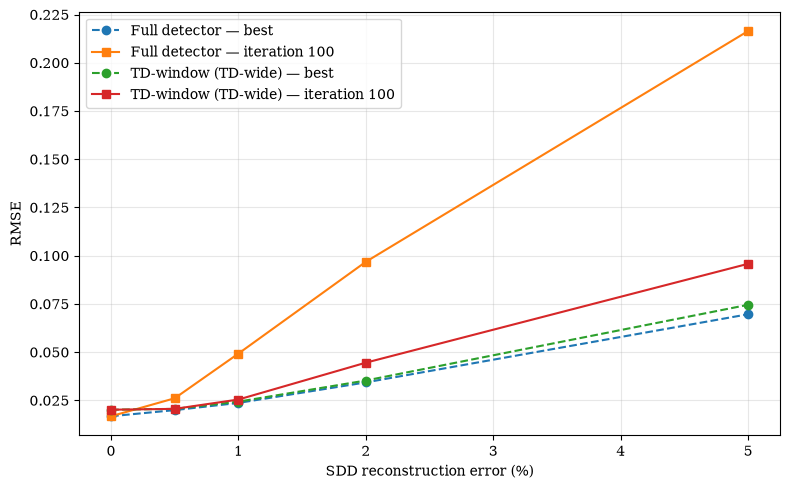

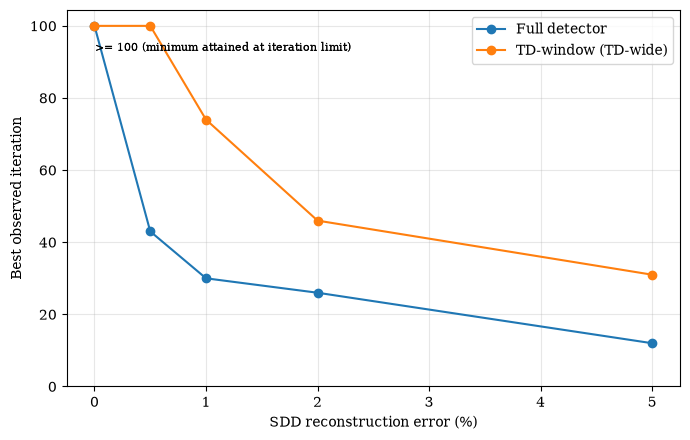

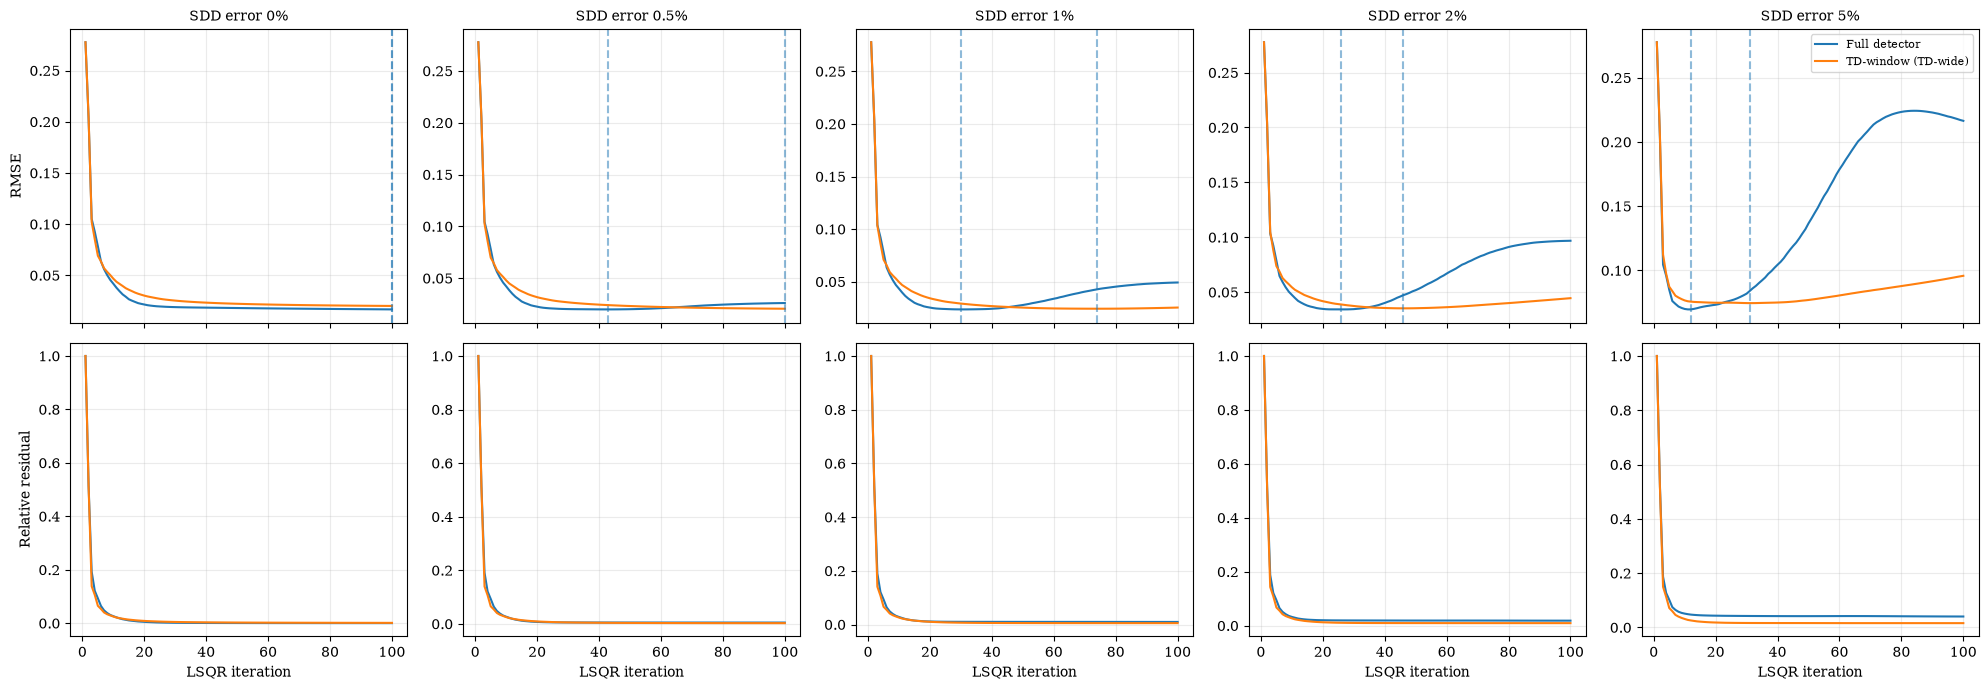

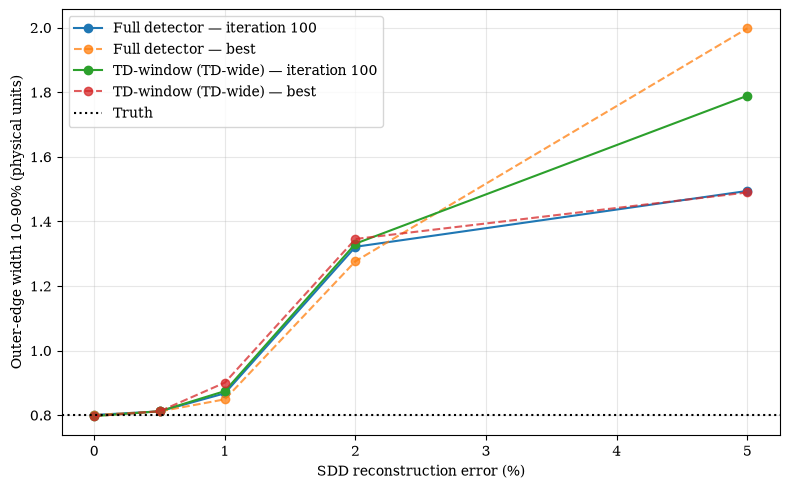

In [ ]:
plot_labels = {
    "full_detector": "Full detector",
    "td_window": "TD-window (TD-wide)",
}

# Primary controlled comparison: oracle best versus the common iteration budget.
plt.figure(figsize=(8, 5))
for detector_type, label in plot_labels.items():
    subset = sdd_geometry_error_summary[
        sdd_geometry_error_summary["detector_type"] == detector_type
    ].sort_values("SDD_error_percent")
    plt.plot(subset["SDD_error_percent"], subset["minimum_rmse"], "o--", label=f"{label} — best")
    plt.plot(subset["SDD_error_percent"], subset["rmse_at_iteration_100"], "s-", label=f"{label} — iteration 100")
plt.xlabel("SDD reconstruction error (%)")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Best iteration, with the iteration-limit interpretation made explicit.
plt.figure(figsize=(7, 4.5))
for detector_type, label in plot_labels.items():
    subset = sdd_geometry_error_summary[
        sdd_geometry_error_summary["detector_type"] == detector_type
    ].sort_values("SDD_error_percent")
    plt.plot(subset["SDD_error_percent"], subset["best_iteration"], "o-", label=label)
    zero_row = subset[np.isclose(subset["SDD_error_percent"], 0.0)].iloc[0]
    if int(zero_row["best_iteration"]) == GEOMETRY_ERROR_MAX_ITERATIONS:
        plt.annotate(
            ">= 100 (minimum attained at iteration limit)",
            (0.0, GEOMETRY_ERROR_MAX_ITERATIONS), xytext=(0.35, -18),
            textcoords="offset points", fontsize=8,
        )
plt.xlabel("SDD reconstruction error (%)")
plt.ylabel("Best observed iteration")
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# RMSE and residual histories reuse the completed LSQR runs.
fig, axes = plt.subplots(2, len(SDD_ERROR_PERCENTAGES), figsize=(20, 7), sharex=True)
for column, error_percent in enumerate(SDD_ERROR_PERCENTAGES):
    for detector_type, label in plot_labels.items():
        result = sdd_geometry_error_results[detector_type][error_percent]["result"]
        history = result["history"]
        axes[0, column].plot(history["iteration"], history["rmse"], label=label)
        axes[0, column].axvline(result["best_iteration"], linestyle="--", alpha=0.5)
        axes[1, column].plot(history["iteration"], history["relative_residual"], label=label)
    axes[0, column].set_title(f"SDD error {error_percent:g}%")
    axes[0, column].grid(True, alpha=0.25)
    axes[1, column].grid(True, alpha=0.25)
    axes[1, column].set_xlabel("LSQR iteration")
axes[0, 0].set_ylabel("RMSE")
axes[1, 0].set_ylabel("Relative residual")
axes[0, -1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Edge-width diagnostic: solid = fixed iteration 100, dashed = oracle best.
plt.figure(figsize=(8, 5))
for detector_type, label in plot_labels.items():
    subset = sdd_geometry_error_summary[
        sdd_geometry_error_summary["detector_type"] == detector_type
    ].sort_values("SDD_error_percent")
    plt.plot(subset["SDD_error_percent"], subset["edge_width_at_iteration_100"], "o-", label=f"{label} — iteration 100")
    plt.plot(subset["SDD_error_percent"], subset["edge_width_best"], "o--", alpha=0.75, label=f"{label} — best")
plt.axhline(truth_edge_width, color="black", linestyle=":", label="Truth")
plt.xlabel("SDD reconstruction error (%)")
plt.ylabel("Outer-edge width 10–90% (physical units)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Sanity checks
assert np.array_equal(true_full_projection_data.as_array(), full_true_values_guard)
assert np.array_equal(true_td_projection_data.as_array(), td_true_values_guard)
assert np.isclose(sdd_true, sod_true + odd_true)
for detector_type in ("full_detector", "td_window"):
    for error_percent in SDD_ERROR_PERCENTAGES:
        history = sdd_geometry_error_results[detector_type][error_percent]["result"]["history"]
        assert len(history) == GEOMETRY_ERROR_MAX_ITERATIONS
        assert int(history["iteration"].iloc[-1]) == GEOMETRY_ERROR_MAX_ITERATIONS

zero_entry = sdd_geometry_error_results["full_detector"][0.0]
assert np.isclose(zero_entry["SDD_reconstruction"], sdd_true)
assert np.isclose(zero_entry["ODD_reconstruction"], odd_true)
print("Geometry 0% Full minimum RMSE:", zero_entry["result"]["minimum_rmse"])

# Compare with an earlier clean baseline only when a compatible result exists.
for candidate_name in ("baseline_result", "clean_baseline_result", "full_detector_result"):
    if candidate_name in globals():
        candidate = globals()[candidate_name]
        if isinstance(candidate, dict) and "minimum_rmse" in candidate:
            print(f"Baseline clean minimum RMSE ({candidate_name}):", candidate["minimum_rmse"])
            print("Absolute difference:", abs(zero_entry["result"]["minimum_rmse"] - candidate["minimum_rmse"]))
            break
else:
    print("No compatible earlier clean-baseline result variable is available; comparison skipped.")


Geometry 0% Full minimum RMSE: 0.016778629706726306
Baseline clean minimum RMSE (baseline_result): 0.016778629706726306
Absolute difference: 0.0


### 18.2 Axis displacement and Tikhonov regularisation

Translate the source--detector pair in the laboratory $x$ direction to create an axis-displacement mismatch. A representative displacement is then combined with a Tikhonov parameter sweep to examine the interaction between model error and regularisation.


In [ ]:
# ============================================================
# Axis-displacement geometry-error sweep
#
# The complete source-detector pair is translated in the
# fixed laboratory x direction.
#
# This is NOT detector-centre/COR offset.
# ============================================================

AXIS_DISPLACEMENT_OFFSETS = [
    0.0,
    0.25,
    0.5,
    1.0,
    2.0,
]

AXIS_GEOMETRY_MAX_ITERATIONS = 100


def build_axis_displacement_operator(
    reference_problem,
    axis_displacement,
):
    """
    Build a reconstruction operator with an assumed rotation-axis
    displacement in the fixed laboratory x direction.

    The entire source-detector pair is translated by
    axis_displacement physical units.

    SOD, ODD, SDD, projection angles, z trajectory, detector panel,
    and source-detector relative geometry remain unchanged.

    No projection data are generated here.
    """

    n_projection = int(
        reference_problem[
            "number_of_projections"
        ]
    )

    n_turns = int(
        reference_problem[
            "number_of_turns"
        ]
    )

    z_travel = (
        float(
            reference_problem[
                "pitch"
            ]
        )
        * n_turns
    )

    angles = np.linspace(
        0.0,
        2.0 * np.pi * n_turns,
        n_projection,
        endpoint=False,
        dtype=np.float32,
    )

    source_z = np.linspace(
        -z_travel / 2.0,
        z_travel / 2.0,
        n_projection,
        endpoint=False,
        dtype=np.float32,
    )

    cosine = np.cos(
        angles
    )

    sine = np.sin(
        angles
    )


    source_position = np.zeros(
        (
            n_projection,
            3,
        ),
        dtype=np.float32,
    )

    detector_position = np.zeros_like(
        source_position
    )

    detector_direction_x_axis = np.zeros_like(
        source_position
    )

    detector_direction_y_axis = np.zeros_like(
        source_position
    )


    physical_offset = float(
        axis_displacement
    )


    # --------------------------------------------------------
    # Shift both source and detector by the SAME fixed x offset
    # --------------------------------------------------------

    source_position[
        :,
        0
    ] = (
        sod_true
        * cosine
        +
        physical_offset
    )

    source_position[
        :,
        1
    ] = (
        sod_true
        * sine
    )

    source_position[
        :,
        2
    ] = (
        source_z
    )


    detector_position[
        :,
        0
    ] = (
        -odd_true
        * cosine
        +
        physical_offset
    )

    detector_position[
        :,
        1
    ] = (
        -odd_true
        * sine
    )

    detector_position[
        :,
        2
    ] = (
        source_z
    )


    detector_direction_x_axis[
        :,
        0
    ] = (
        -sine
    )

    detector_direction_x_axis[
        :,
        1
    ] = (
        cosine
    )

    detector_direction_y_axis[
        :,
        2
    ] = 1.0


    geometry = (
        AcquisitionGeometry
        .create_Cone3D_Flex(
            source_position_set=
                source_position,

            detector_position_set=
                detector_position,

            detector_direction_x_set=
                detector_direction_x_axis,

            detector_direction_y_set=
                detector_direction_y_axis,
        )
    )


    geometry.set_panel(
        num_pixels=[
            detector_num_horizontal,
            detector_num_vertical,
        ],

        pixel_size=[
            detector_pixel_size_horizontal,
            detector_pixel_size_vertical,
        ],
    )


    geometry.set_labels(
        [
            "projection",
            "vertical",
            "horizontal",
        ]
    )


    backend_template = (
        geometry.allocate(
            0
        )
    )

    backend_template.reorder(
        "astra"
    )


    operator_axis = (
        ProjectionOperator(
            image_geometry=
                reference_problem[
                    "image_geometry"
                ],

            acquisition_geometry=
                backend_template.geometry,

            device="gpu",
        )
    )


    return (
        operator_axis,
        geometry,
    )


# ============================================================
# Run axis sweep
# ============================================================

axis_geometry_error_results = {
    "full_detector": {},
    "td_window": {},
}

axis_geometry_error_rows = []


axis_full_data_guard = (
    np.asarray(
        true_full_projection_data.as_array()
    ).copy()
)

axis_td_data_guard = (
    np.asarray(
        true_td_projection_data.as_array()
    ).copy()
)


for axis_displacement in (
    AXIS_DISPLACEMENT_OFFSETS
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        "Axis displacement = "
        f"{axis_displacement:g} "
        "object-space units"
    )


    # --------------------------------------------------------
    # Build wrong Full reconstruction operator
    # --------------------------------------------------------

    (
        wrong_full_operator,
        axis_reconstruction_geometry,
    ) = (
        build_axis_displacement_operator(
            true_full_problem,
            axis_displacement=
                axis_displacement,
        )
    )


    full_data_for_axis_operator = (
        copy_true_measurements_to_operator_range(
            true_full_projection_data,
            wrong_full_operator,
        )
    )


    # --------------------------------------------------------
    # Apply unchanged TRUE TD-wide support
    # --------------------------------------------------------

    wrong_td_mask = (
        wrong_full_operator
        .range_geometry()
        .allocate(
            0.0
        )
    )

    wrong_td_mask.fill(
        true_td_mask_values
    )


    wrong_td_mask_operator = (
        MaskOperator(
            wrong_td_mask,
            domain_geometry=
                wrong_full_operator
                .range_geometry(),
        )
    )


    wrong_td_operator = (
        CompositionOperator(
            wrong_td_mask_operator,
            wrong_full_operator,
        )
    )


    td_data_for_axis_operator = (
        copy_true_measurements_to_operator_range(
            true_td_projection_data,
            wrong_td_operator,
        )
    )


    # --------------------------------------------------------
    # Full + TD
    # --------------------------------------------------------

    for (
        detector_type,
        operator_axis,
        fixed_true_data,
    ) in [
        (
            "full_detector",
            wrong_full_operator,
            full_data_for_axis_operator,
        ),
        (
            "td_window",
            wrong_td_operator,
            td_data_for_axis_operator,
        ),
    ]:

        result = (
            run_lsqr_with_diagnostics(
                operator_local=
                    operator_axis,

                data_local=
                    fixed_true_data,

                truth_local=
                    true_full_problem[
                        "phantom"
                    ],

                initial_local=
                    true_full_problem[
                        "image_geometry"
                    ].allocate(
                        0.0
                    ),

                number_of_iterations_local=
                    AXIS_GEOMETRY_MAX_ITERATIONS,

                alpha=0.0,

                checkpoint_interval=1,
            )
        )


        assert (
            len(
                result[
                    "history"
                ]
            )
            ==
            AXIS_GEOMETRY_MAX_ITERATIONS
        )


        minimum_rmse = float(
            result[
                "minimum_rmse"
            ]
        )


        entry = {
            "result":
                result,

            "best_solution":
                result[
                    "best_reconstruction"
                ],

            "final_solution":
                result[
                    "final_reconstruction"
                ],

            "operator":
                operator_axis,

            "data_for_reconstruction":
                fixed_true_data,

            "axis_displacement":
                float(
                    axis_displacement
                ),
        }


        axis_geometry_error_results[
            detector_type
        ][
            axis_displacement
        ] = (
            entry
        )


        axis_geometry_error_rows.append(
            {
                "detector_type":
                    detector_type,

                "axis_displacement":
                    float(
                        axis_displacement
                    ),

                "best_iteration":
                    int(
                        result[
                            "best_iteration"
                        ]
                    ),

                "minimum_rmse":
                    minimum_rmse,

                "rmse_at_iteration_100":
                    float(
                        result[
                            "final_rmse"
                        ]
                    ),

                "rmse_deterioration_absolute":
                    float(
                        result[
                            "final_rmse"
                        ]
                        -
                        minimum_rmse
                    ),

                "rmse_deterioration_factor":
                    float(
                        result[
                            "final_rmse"
                        ]
                        /
                        max(
                            minimum_rmse,
                            1e-30,
                        )
                    ),

                "relative_residual_at_best":
                    float(
                        result[
                            "relative_residual_at_best"
                        ]
                    ),

                "relative_residual_at_iteration_100":
                    float(
                        result[
                            "relative_residual_at_final"
                        ]
                    ),

                "solution_norm_at_best":
                    float(
                        result[
                            "solution_norm_at_best"
                        ]
                    ),

                "solution_norm_at_iteration_100":
                    float(
                        result[
                            "solution_norm_at_final"
                        ]
                    ),
            }
        )


# ------------------------------------------------------------
# Measurement arrays must remain unchanged
# ------------------------------------------------------------

assert np.array_equal(
    true_full_projection_data.as_array(),
    axis_full_data_guard,
)

assert np.array_equal(
    true_td_projection_data.as_array(),
    axis_td_data_guard,
)


axis_geometry_error_summary = (
    pd.DataFrame(
        axis_geometry_error_rows
    )
    .sort_values(
        [
            "axis_displacement",
            "detector_type",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    axis_geometry_error_summary
)


axis_summary_path = os.path.join(
    RESULTS_DIRECTORY,
    "axis_displacement_geometry_error_summary.csv",
)


axis_geometry_error_summary.to_csv(
    axis_summary_path,
    index=False,
)


print(
    "Saved:",
    axis_summary_path,
)


Axis displacement = 0 object-space units

Axis displacement = 0.25 object-space units

Axis displacement = 0.5 object-space units

Axis displacement = 1 object-space units

Axis displacement = 2 object-space units


,detector_type,axis_displacement,best_iteration,minimum_rmse,rmse_at_iteration_100,rmse_deterioration_absolute,rmse_deterioration_factor,relative_residual_at_best,relative_residual_at_iteration_100,solution_norm_at_best,solution_norm_at_iteration_100
0,full_detector,0.00,100,0.016779,0.016779,0.000000,1.000000,0.000346,0.000346,200.620476,200.620476
1,td_window,0.00,100,0.020155,0.020155,0.000000,1.000000,0.001373,0.001373,200.381713,200.381713
2,full_detector,0.25,42,0.029479,0.053201,0.023722,1.804733,0.008664,0.008747,199.937187,203.007129
3,td_window,0.25,48,0.031054,0.036785,0.005732,1.184569,0.008537,0.008499,199.988632,200.614399
4,full_detector,0.50,40,0.054417,0.090469,0.036052,1.662518,0.011764,0.011914,199.379901,206.203756
5,td_window,0.50,40,0.055773,0.063768,0.007995,1.143346,0.011572,0.011561,199.419369,200.688830
6,full_detector,1.00,8,0.084914,0.100720,0.015806,1.186137,0.038112,0.000347,194.450672,200.619284
7,td_window,1.00,8,0.087110,0.100985,0.013875,1.159280,0.033597,0.001377,193.988094,200.379909
8,full_detector,2.00,5,0.119038,0.141582,0.022543,1.189378,0.092979,0.000358,185.985544,200.620742
9,td_window,2.00,5,0.120106,0.141498,0.021391,1.178103,0.066040,0.001326,189.503558,200.388228


Saved: lsqr_validation_results_pitch48/axis_displacement_geometry_error_summary.csv


In [ ]:
# ============================================================
# 2.  Axis-displacement × Tikhonov sweep
#
# Representative case:
#   axis displacement = 0.5 object-space units
#
# alpha:
#   0, 2.5, 5, 7.5, 9.5, 12.5, 15.0, 18.0, 20.0, 30.0, 50.0
#
# Full + TD
# iteration 1--100 recorded
# ============================================================

AXIS_TIKHONOV_DISPLACEMENT = 0.5

AXIS_TIKHONOV_ALPHAS = [
    0.0,
    2.5,
    5.0,
    7.5,
    9.5,
    12.5,
    15.0,
    18.0,
    20.0,
    30.0, 
    50.0,
]

AXIS_TIKHONOV_MAX_ITERATIONS = 100


axis_tikhonov_results = {
    "full_detector": {},
    "td_window": {},
}


for detector_type in [
    "full_detector",
    "td_window",
]:

    existing_entry = (
        axis_geometry_error_results[
            detector_type
        ][
            AXIS_TIKHONOV_DISPLACEMENT
        ]
    )


    operator_local = (
        existing_entry[
            "operator"
        ]
    )

    data_local = (
        existing_entry[
            "data_for_reconstruction"
        ]
    )


    data_guard = np.asarray(
        data_local.as_array()
    ).copy()


    for alpha_value in (
        AXIS_TIKHONOV_ALPHAS
    ):

        print(
            "\n"
            + "=" * 72
        )

        print(
            "Axis displacement "
            f"{AXIS_TIKHONOV_DISPLACEMENT:g} | "
            f"{detector_type} | "
            f"alpha={alpha_value:g}"
        )


        result = (
            run_lsqr_with_diagnostics(
                operator_local=
                    operator_local,

                data_local=
                    data_local,

                truth_local=
                    true_full_problem[
                        "phantom"
                    ],

                initial_local=
                    true_full_problem[
                        "image_geometry"
                    ].allocate(
                        0.0
                    ),

                number_of_iterations_local=
                    AXIS_TIKHONOV_MAX_ITERATIONS,

                alpha=
                    alpha_value,

                checkpoint_interval=1,
            )
        )


        assert (
            len(
                result[
                    "history"
                ]
            )
            ==
            AXIS_TIKHONOV_MAX_ITERATIONS
        )


        axis_tikhonov_results[
            detector_type
        ][
            alpha_value
        ] = {
            "result":
                result,

            "operator":
                operator_local,

            "data":
                data_local,

            "axis_displacement":
                AXIS_TIKHONOV_DISPLACEMENT,

            "alpha":
                alpha_value,
        }


        print(
            "  best iteration:",
            result[
                "best_iteration"
            ]
        )

        print(
            "  minimum RMSE:",
            f"{result['minimum_rmse']:.8f}"
        )

        print(
            "  RMSE at iteration 100:",
            f"{result['final_rmse']:.8f}"
        )

        print(
            "  deterioration factor:",
            (
                result[
                    "final_rmse"
                ]
                /
                max(
                    result[
                        "minimum_rmse"
                    ],
                    1e-30,
                )
            )
        )


    assert np.array_equal(
        data_local.as_array(),
        data_guard,
    )


Axis displacement 0.5 | full_detector | alpha=0
  best iteration: 40
  minimum RMSE: 0.05441660
  RMSE at iteration 100: 0.09046860
  deterioration factor: 1.6625183309049816

Axis displacement 0.5 | full_detector | alpha=2.5
  best iteration: 40
  minimum RMSE: 0.05437860
  RMSE at iteration 100: 0.07013207
  deterioration factor: 1.2896997287408762

Axis displacement 0.5 | full_detector | alpha=5
  best iteration: 40
  minimum RMSE: 0.05427372
  RMSE at iteration 100: 0.05790405
  deterioration factor: 1.0668893844020204

Axis displacement 0.5 | full_detector | alpha=7.5
  best iteration: 41
  minimum RMSE: 0.05412657
  RMSE at iteration 100: 0.05506638
  deterioration factor: 1.0173631803342928

Axis displacement 0.5 | full_detector | alpha=9.5
  best iteration: 41
  minimum RMSE: 0.05400030
  RMSE at iteration 100: 0.05435604
  deterioration factor: 1.0065877205815403

Axis displacement 0.5 | full_detector | alpha=12.5
  best iteration: 41
  minimum RMSE: 0.05384215
  RMSE at iter

In [ ]:
# ============================================================
# Axis × Tikhonov summary and complete histories
# ============================================================

axis_tikhonov_rows = []

axis_tikhonov_history_blocks = []


for detector_type in [
    "full_detector",
    "td_window",
]:

    for alpha_value in (
        AXIS_TIKHONOV_ALPHAS
    ):

        entry = (
            axis_tikhonov_results[
                detector_type
            ][
                alpha_value
            ]
        )

        result = (
            entry[
                "result"
            ]
        )

        history = (
            result[
                "history"
            ]
            .copy()
        )


        best_iteration = int(
            result[
                "best_iteration"
            ]
        )


        best_row = (
            history[
                history[
                    "iteration"
                ]
                ==
                best_iteration
            ]
            .iloc[0]
        )


        final_row = (
            history.iloc[-1]
        )


        minimum_rmse = float(
            result[
                "minimum_rmse"
            ]
        )

        rmse_at_100 = float(
            final_row[
                "rmse"
            ]
        )

        residual_at_best = float(
            best_row[
                "relative_residual"
            ]
        )

        residual_at_100 = float(
            final_row[
                "relative_residual"
            ]
        )


        axis_tikhonov_rows.append(
            {
                "geometry_error":
                    "AXIS",

                "axis_displacement":
                    AXIS_TIKHONOV_DISPLACEMENT,

                "detector_type":
                    detector_type,

                "alpha":
                    alpha_value,

                "best_iteration":
                    best_iteration,

                "minimum_rmse":
                    minimum_rmse,

                "rmse_at_iteration_100":
                    rmse_at_100,

                "rmse_deterioration_absolute":
                    (
                        rmse_at_100
                        -
                        minimum_rmse
                    ),

                "rmse_deterioration_factor":
                    (
                        rmse_at_100
                        /
                        max(
                            minimum_rmse,
                            1e-30,
                        )
                    ),

                "relative_residual_at_best":
                    residual_at_best,

                "relative_residual_at_iteration_100":
                    residual_at_100,

                "post_best_residual_ratio":
                    (
                        residual_at_100
                        /
                        max(
                            residual_at_best,
                            1e-30,
                        )
                    ),

                "post_best_residual_reduction_percent":
                    (
                        100.0
                        *
                        (
                            1.0
                            -
                            residual_at_100
                            /
                            max(
                                residual_at_best,
                                1e-30,
                            )
                        )
                    ),

                "solution_norm_at_best":
                    float(
                        best_row[
                            "solution_norm"
                        ]
                    ),

                "solution_norm_at_iteration_100":
                    float(
                        final_row[
                            "solution_norm"
                        ]
                    ),
            }
        )


        # ----------------------------------------------------
        # Complete history
        # ----------------------------------------------------

        history.insert(
            0,
            "geometry_error",
            "AXIS",
        )

        history.insert(
            1,
            "axis_displacement",
            AXIS_TIKHONOV_DISPLACEMENT,
        )

        history.insert(
            2,
            "detector_type",
            detector_type,
        )

        # run_lsqr_with_diagnostics already stores alpha
        if "alpha" not in history.columns:

            history.insert(
                3,
                "alpha",
                alpha_value,
            )


        axis_tikhonov_history_blocks.append(
            history
        )


axis_tikhonov_summary = (
    pd.DataFrame(
        axis_tikhonov_rows
    )
    .sort_values(
        [
            "detector_type",
            "alpha",
        ]
    )
    .reset_index(
        drop=True
    )
)


axis_tikhonov_history = (
    pd.concat(
        axis_tikhonov_history_blocks,
        ignore_index=True,
    )
)


assert (
    len(
        axis_tikhonov_history
    )
    ==
    2
    * len(
        AXIS_TIKHONOV_ALPHAS
    )
    * AXIS_TIKHONOV_MAX_ITERATIONS
)


display(
    axis_tikhonov_summary
)


axis_tikhonov_summary_path = (
    os.path.join(
        RESULTS_DIRECTORY,
        "axis_displacement_tikhonov_summary.csv",
    )
)

axis_tikhonov_history_path = (
    os.path.join(
        RESULTS_DIRECTORY,
        "axis_displacement_tikhonov_histories.csv",
    )
)


axis_tikhonov_summary.to_csv(
    axis_tikhonov_summary_path,
    index=False,
)

axis_tikhonov_history.to_csv(
    axis_tikhonov_history_path,
    index=False,
)


print(
    "Saved:",
    axis_tikhonov_summary_path,
)

print(
    "Saved:",
    axis_tikhonov_history_path,
)

,geometry_error,axis_displacement,detector_type,alpha,best_iteration,minimum_rmse,rmse_at_iteration_100,rmse_deterioration_absolute,rmse_deterioration_factor,relative_residual_at_best,relative_residual_at_iteration_100,post_best_residual_ratio,post_best_residual_reduction_percent,solution_norm_at_best,solution_norm_at_iteration_100
0,AXIS,0.5,full_detector,0.0,40,0.054417,0.090469,3.605200e-02,1.662518,0.011764,0.011914,1.012770,-1.276996,199.379901,206.203756
1,AXIS,0.5,full_detector,2.5,40,0.054379,0.070132,1.575347e-02,1.289700,0.011783,0.011792,1.000808,-0.080795,199.297163,201.905956
2,AXIS,0.5,full_detector,5.0,40,0.054274,0.057904,3.630335e-03,1.066889,0.011864,0.011826,0.996813,0.318651,199.051933,199.607936
3,AXIS,0.5,full_detector,7.5,41,0.054127,0.055066,9.398094e-04,1.017363,0.012089,0.012045,0.996371,0.362870,198.633015,198.795716
4,AXIS,0.5,full_detector,9.5,41,0.054000,0.054356,3.557389e-04,1.006588,0.012421,0.012386,0.997125,0.287464,198.212484,198.282853
5,AXIS,0.5,full_detector,12.5,41,0.053842,0.053932,9.013914e-05,1.001674,0.013313,0.013288,0.998175,0.182530,197.426080,197.450520
6,AXIS,0.5,full_detector,15.0,50,0.053771,0.053805,3.359334e-05,1.000625,0.014494,0.014489,0.999681,0.031912,196.649717,196.654226
7,AXIS,0.5,full_detector,18.0,51,0.053811,0.053823,1.227427e-05,1.000228,0.016534,0.016531,0.999790,0.021049,195.570618,195.573297
8,AXIS,0.5,full_detector,20.0,51,0.053928,0.053935,6.574038e-06,1.000122,0.018259,0.018256,0.999883,0.011745,194.780996,194.782584
9,AXIS,0.5,full_detector,30.0,52,0.055800,0.055800,3.206883e-07,1.000006,0.030648,0.030648,1.000018,-0.001753,190.153560,190.153429


Saved: lsqr_validation_results_pitch48/axis_displacement_tikhonov_summary.csv
Saved: lsqr_validation_results_pitch48/axis_displacement_tikhonov_histories.csv


In [ ]:
# ============================================================
# Axis displacement × Tikhonov:
# edge-width analysis and visualisation
#
# Uses:
#   axis_tikhonov_results
#   axis_tikhonov_summary
#   measure_outer_edge_width()
#
# Computes:
#   edge width at oracle-best iteration
#   edge width at iteration 100
#   relative edge-width change versus alpha = 0
#
# Axis displacement = 0.5
# ============================================================


# ------------------------------------------------------------
# 1. Compute edge-width measurements
# ------------------------------------------------------------

axis_edge_width_rows = []


for detector_type in [
    "full_detector",
    "td_window",
]:

    for alpha_value in sorted(
        axis_tikhonov_results[
            detector_type
        ].keys()
    ):

        result = (
            axis_tikhonov_results[
                detector_type
            ][
                alpha_value
            ][
                "result"
            ]
        )


        # ----------------------------------------------------
        # Oracle-best reconstruction
        # ----------------------------------------------------

        best_reconstruction = (
            result[
                "best_reconstruction"
            ]
        )


        best_edge_width_result = (
            measure_outer_edge_width(
                best_reconstruction
            )
        )


        # ----------------------------------------------------
        # Iteration-100 reconstruction
        # ----------------------------------------------------

        iteration_100_reconstruction = (
            result[
                "final_reconstruction"
            ]
        )


        iteration_100_edge_width_result = (
            measure_outer_edge_width(
                iteration_100_reconstruction
            )
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        axis_edge_width_rows.append(
            {
                "detector_type":
                    detector_type,

                "alpha":
                    float(
                        alpha_value
                    ),

                "edge_width_best":
                    float(
                        best_edge_width_result[
                            "mean_edge_width_10_90"
                        ]
                    ),

                "edge_width_best_std":
                    float(
                        best_edge_width_result[
                            "std_edge_width_10_90"
                        ]
                    ),

                "edge_width_at_iteration_100":
                    float(
                        iteration_100_edge_width_result[
                            "mean_edge_width_10_90"
                        ]
                    ),

                "edge_width_at_iteration_100_std":
                    float(
                        iteration_100_edge_width_result[
                            "std_edge_width_10_90"
                        ]
                    ),
            }
        )


axis_edge_width_summary = (
    pd.DataFrame(
        axis_edge_width_rows
    )
    .sort_values(
        [
            "detector_type",
            "alpha",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    axis_edge_width_summary
)



# ============================================================
# 2. Merge edge-width measurements into existing summary
# ============================================================

axis_tikhonov_summary_with_edges = (
    axis_tikhonov_summary
    .merge(
        axis_edge_width_summary,
        on=[
            "detector_type",
            "alpha",
        ],
        how="left",
        validate="one_to_one",
    )
)


display(
    axis_tikhonov_summary_with_edges
)

,detector_type,alpha,edge_width_best,edge_width_best_std,edge_width_at_iteration_100,edge_width_at_iteration_100_std
0,full_detector,0.0,1.415241,0.034421,1.413305,0.031084
1,full_detector,2.5,1.417610,0.034352,1.415193,0.030946
2,full_detector,5.0,1.424666,0.034197,1.422029,0.031038
3,full_detector,7.5,1.437142,0.034504,1.433818,0.031417
4,full_detector,9.5,1.449383,0.034477,1.446481,0.031912
5,full_detector,12.5,1.472542,0.034817,1.470320,0.032995
6,full_detector,15.0,1.495143,0.034407,1.494126,0.034212
7,full_detector,18.0,1.527189,0.036073,1.526724,0.036017
8,full_detector,20.0,1.550836,0.037438,1.550527,0.037394
9,full_detector,30.0,1.686227,0.045277,1.686203,0.045276


,geometry_error,axis_displacement,detector_type,alpha,best_iteration,minimum_rmse,rmse_at_iteration_100,rmse_deterioration_absolute,rmse_deterioration_factor,relative_residual_at_best,relative_residual_at_iteration_100,post_best_residual_ratio,post_best_residual_reduction_percent,solution_norm_at_best,solution_norm_at_iteration_100,edge_width_best,edge_width_best_std,edge_width_at_iteration_100,edge_width_at_iteration_100_std
0,AXIS,0.5,full_detector,0.0,40,0.054417,0.090469,3.605200e-02,1.662518,0.011764,0.011914,1.012770,-1.276996,199.379901,206.203756,1.415241,0.034421,1.413305,0.031084
1,AXIS,0.5,full_detector,2.5,40,0.054379,0.070132,1.575347e-02,1.289700,0.011783,0.011792,1.000808,-0.080795,199.297163,201.905956,1.417610,0.034352,1.415193,0.030946
2,AXIS,0.5,full_detector,5.0,40,0.054274,0.057904,3.630335e-03,1.066889,0.011864,0.011826,0.996813,0.318651,199.051933,199.607936,1.424666,0.034197,1.422029,0.031038
3,AXIS,0.5,full_detector,7.5,41,0.054127,0.055066,9.398094e-04,1.017363,0.012089,0.012045,0.996371,0.362870,198.633015,198.795716,1.437142,0.034504,1.433818,0.031417
4,AXIS,0.5,full_detector,9.5,41,0.054000,0.054356,3.557389e-04,1.006588,0.012421,0.012386,0.997125,0.287464,198.212484,198.282853,1.449383,0.034477,1.446481,0.031912
5,AXIS,0.5,full_detector,12.5,41,0.053842,0.053932,9.013914e-05,1.001674,0.013313,0.013288,0.998175,0.182530,197.426080,197.450520,1.472542,0.034817,1.470320,0.032995
6,AXIS,0.5,full_detector,15.0,50,0.053771,0.053805,3.359334e-05,1.000625,0.014494,0.014489,0.999681,0.031912,196.649717,196.654226,1.495143,0.034407,1.494126,0.034212
7,AXIS,0.5,full_detector,18.0,51,0.053811,0.053823,1.227427e-05,1.000228,0.016534,0.016531,0.999790,0.021049,195.570618,195.573297,1.527189,0.036073,1.526724,0.036017
8,AXIS,0.5,full_detector,20.0,51,0.053928,0.053935,6.574038e-06,1.000122,0.018259,0.018256,0.999883,0.011745,194.780996,194.782584,1.550836,0.037438,1.550527,0.037394
9,AXIS,0.5,full_detector,30.0,52,0.055800,0.055800,3.206883e-07,1.000006,0.030648,0.030648,1.000018,-0.001753,190.153560,190.153429,1.686227,0.045277,1.686203,0.045276


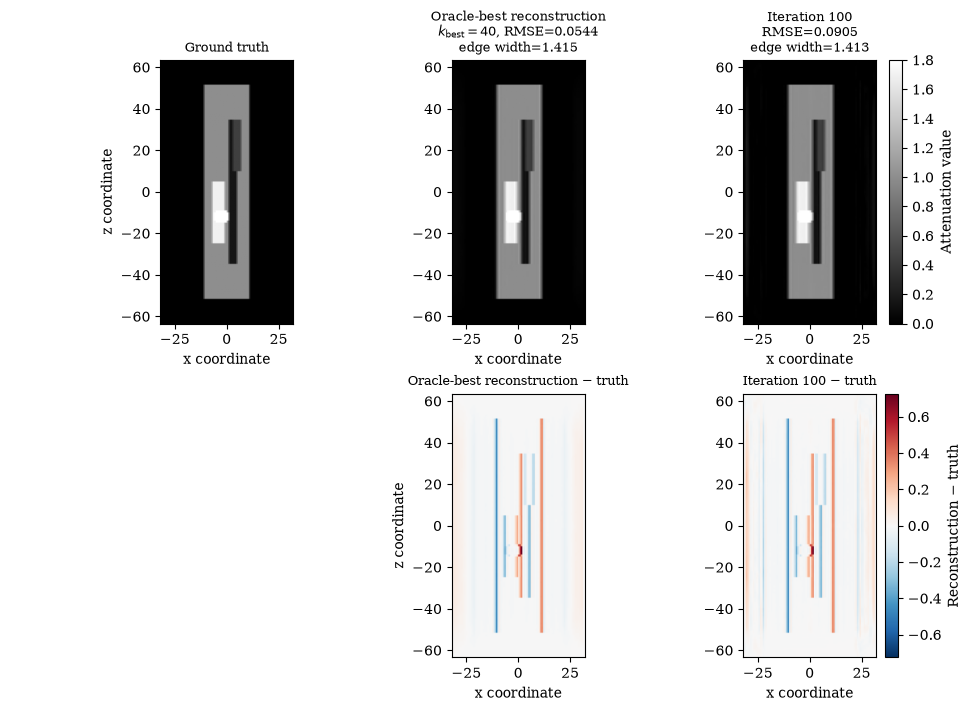

In [ ]:
# ============================================================
# Geometry mismatch reconstruction example
#
# Axis displacement = 0.5 object-space units
# Full detector
# alpha = 0
#
# Row 1:
#   Truth | oracle-best | iteration 100
#
# Row 2:
#         | best - truth | iteration 100 - truth
# ============================================================

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import matplotlib.pyplot as plt


AXIS_VISUAL_DISPLACEMENT = 0.5
AXIS_VISUAL_DETECTOR = "full_detector"

entry = (
    axis_geometry_error_results[
        AXIS_VISUAL_DETECTOR
    ][
        AXIS_VISUAL_DISPLACEMENT
    ]
)

result = entry["result"]



truth_volume = np.asarray(
    true_full_problem["phantom"].as_array(),
    dtype=np.float64,
)

truth_longitudinal_result = (
    extract_oblique_longitudinal_slice(
        volume=truth_volume,
        point_1=plane_definition["point_1"],
        point_2=plane_definition["point_2"],
        half_width=half_width,
        half_height=half_height,
    )
)

truth_longitudinal_slice = (
    truth_longitudinal_result["slice"]
)


truth_result = (
        extract_oblique_longitudinal_slice(
            volume=phantom_array,
            point_1=plane_definition[
                "point_1"
            ],
            point_2=plane_definition[
                "point_2"
            ],
            half_width=half_width,
            half_height=half_height,
        )
    )

extent = [

        truth_result["s_coordinates"][0],

        truth_result["s_coordinates"][-1],

        truth_result["z_coordinates"][0],

        truth_result["z_coordinates"][-1],

    ]
# ------------------------------------------------------------
# Extract volumes
# ------------------------------------------------------------

best_volume = np.asarray(
    result[
        "best_reconstruction"
    ].as_array(),
    dtype=np.float64,
)

late_volume = np.asarray(
    result[
        "final_reconstruction"
    ].as_array(),
    dtype=np.float64,
)


# ------------------------------------------------------------
# Extract the SAME longitudinal plane already used in Ch. 5
# ------------------------------------------------------------

best_slice = extract_oblique_longitudinal_slice(
    volume=best_volume,
    point_1=plane_definition["point_1"],
    point_2=plane_definition["point_2"],
    half_width=half_width,
    half_height=half_height,
)["slice"]

late_slice = extract_oblique_longitudinal_slice(
    volume=late_volume,
    point_1=plane_definition["point_1"],
    point_2=plane_definition["point_2"],
    half_width=half_width,
    half_height=half_height,
)["slice"]


best_error = (
    best_slice
    -
    truth_longitudinal_slice
)

late_error = (
    late_slice
    -
    truth_longitudinal_slice
)


# ------------------------------------------------------------
# Edge widths
# ------------------------------------------------------------

best_edge = measure_outer_edge_width(
    result["best_reconstruction"]
)

late_edge = measure_outer_edge_width(
    result["final_reconstruction"]
)

best_edge_width = float(
    best_edge[
        "mean_edge_width_10_90"
    ]
)

late_edge_width = float(
    late_edge[
        "mean_edge_width_10_90"
    ]
)


# ------------------------------------------------------------
# Shared scales
# ------------------------------------------------------------

reconstruction_norm = Normalize(
    vmin=0.0,
    vmax=1.8,
)

# Use ONE symmetric scale for both error images
error_limit = max(
    np.max(np.abs(best_error)),
    np.max(np.abs(late_error)),
)

error_norm = Normalize(
    vmin=-error_limit,
    vmax=error_limit,
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

with plt.rc_context():

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(9.6, 7.0),
        constrained_layout=True,
    )

    # ========================================================
    # Row 1: reconstructions
    # ========================================================

    reconstruction_data = [
        truth_longitudinal_slice,
        best_slice,
        late_slice,
    ]

    reconstruction_titles = [
        "Ground truth",
        (
            "Oracle-best reconstruction\n"
            f"$k_{{\\mathrm{{best}}}}="
            f"{result['best_iteration']}$, "
            f"RMSE={result['minimum_rmse']:.4f}\n"
            f"edge width={best_edge_width:.3f}"
        ),
        (
            "Iteration 100\n"
            f"RMSE={result['final_rmse']:.4f}\n"
            f"edge width={late_edge_width:.3f}"
        ),
    ]

    for ax, image, title in zip(
        axes[0],
        reconstruction_data,
        reconstruction_titles,
    ):

        ax.imshow(
            image,
            cmap="gray",
            origin="lower",
            extent=extent,
            norm=reconstruction_norm,
            aspect="equal",
        )

        ax.set_title(
            title,
            fontsize=9,
        )

        ax.set_xlabel(
            "x coordinate"
        )

    axes[0, 0].set_ylabel(
        "z coordinate"
    )


    # ========================================================
    # Row 2: signed errors
    # ========================================================

    axes[1, 0].axis(
        "off"
    )

    error_data = [
        best_error,
        late_error,
    ]

    error_titles = [
        (
            "Oracle-best reconstruction "
            "$-$ truth"
        ),
        (
            "Iteration 100 "
            "$-$ truth"
        ),
    ]

    for ax, image, title in zip(
        axes[1, 1:],
        error_data,
        error_titles,
    ):

        ax.imshow(
            image,
            cmap="RdBu_r",
            origin="lower",
            extent=extent,
            norm=error_norm,
            aspect="equal",
        )

        ax.set_title(
            title,
            fontsize=9,
        )

        ax.set_xlabel(
            "x coordinate"
        )

    axes[1, 1].set_ylabel(
        "z coordinate"
    )


    # --------------------------------------------------------
    # Reconstruction colourbar
    # --------------------------------------------------------

    recon_mappable = ScalarMappable(
        norm=reconstruction_norm,
        cmap="gray",
    )

    recon_mappable.set_array([])

    cbar_recon = fig.colorbar(
        recon_mappable,
        ax=list(axes[0, :]),
        fraction=0.025,
        pad=0.015,
    )

    cbar_recon.set_label(
        "Attenuation value"
    )


    # --------------------------------------------------------
    # Error colourbar
    # --------------------------------------------------------

    error_mappable = ScalarMappable(
        norm=error_norm,
        cmap="RdBu_r",
    )

    error_mappable.set_array([])

    cbar_error = fig.colorbar(
        error_mappable,
        ax=list(axes[1, 1:]),
        fraction=0.025,
        pad=0.015,
    )

    cbar_error.set_label(
        "Reconstruction $-$ truth"
    )




    plt.show()

### 18.3 Centre-of-rotation mismatch

Introduce controlled COR offsets in the reconstruction geometry while preserving the true measurements and TD support, then compare reconstruction accuracy and iteration behaviour for full and TD-window data.


In [ ]:
# ============================================================
# 2.2 COR reconstruction-geometry helper
# ============================================================

COR_ERROR_OFFSETS_PIXELS = [
    0.0,
    0.10,
    0.25,
    0.50,
    1.00,
]

RUN_COR_GEOMETRY_ERROR_SWEEP = True


def build_helical_reconstruction_operator_with_cor_error(
    reference_problem,
    cor_error_offset_pixels,
):
    """
    Build A_recon with a horizontal detector-centre / COR offset.

    The numerical measurements are NOT generated here.

    The true source trajectory is retained exactly.

    Only the assumed detector centre is displaced along the
    detector horizontal direction

        e_u(theta) = (-sin(theta), cos(theta), 0).

    Parameters
    ----------
    reference_problem : dict
        Existing true helical problem.

    cor_error_offset_pixels : float
        Detector-centre displacement in horizontal detector pixels.

    Returns
    -------
    operator_local
        Reconstruction projection operator.

    acquisition_geometry_local
        Corresponding perturbed acquisition geometry.

    geometry_diagnostics
        Arrays/values used for explicit sanity checking.
    """

    number_of_projections_local = int(
        reference_problem[
            "number_of_projections"
        ]
    )

    number_of_turns_local = int(
        reference_problem[
            "number_of_turns"
        ]
    )

    total_z_travel_local = (
        float(
            reference_problem[
                "pitch"
            ]
        )
        * number_of_turns_local
    )

    # --------------------------------------------------------
    # Same angular and axial sampling as the TRUE geometry.
    # --------------------------------------------------------

    angles_local = np.linspace(
        0.0,
        2.0
        * np.pi
        * number_of_turns_local,
        number_of_projections_local,
        endpoint=False,
        dtype=np.float32,
    )

    source_z_positions_local = np.linspace(
        -total_z_travel_local / 2.0,
        total_z_travel_local / 2.0,
        number_of_projections_local,
        endpoint=False,
        dtype=np.float32,
    )

    cosine = np.cos(
        angles_local
    )

    sine = np.sin(
        angles_local
    )

    # --------------------------------------------------------
    # Allocate geometry arrays.
    # --------------------------------------------------------

    source_positions_local = np.zeros(
        (
            number_of_projections_local,
            3,
        ),
        dtype=np.float32,
    )

    detector_positions_true_local = np.zeros_like(
        source_positions_local
    )

    detector_positions_local = np.zeros_like(
        source_positions_local
    )

    detector_direction_x_local = np.zeros_like(
        source_positions_local
    )

    detector_direction_y_local = np.zeros_like(
        source_positions_local
    )

    # --------------------------------------------------------
    # TRUE source trajectory.
    #
    # IMPORTANT:
    # The source trajectory must NOT change in the COR test.
    # --------------------------------------------------------

    source_positions_local[:, 0] = (
        sod_true
        * cosine
    )

    source_positions_local[:, 1] = (
        sod_true
        * sine
    )

    source_positions_local[:, 2] = (
        source_z_positions_local
    )

    # --------------------------------------------------------
    # TRUE detector-centre trajectory.
    # --------------------------------------------------------

    detector_positions_true_local[:, 0] = (
        -odd_true
        * cosine
    )

    detector_positions_true_local[:, 1] = (
        -odd_true
        * sine
    )

    detector_positions_true_local[:, 2] = (
        source_z_positions_local
    )

    # Start reconstruction detector at true position.
    detector_positions_local[:] = (
        detector_positions_true_local
    )

    # --------------------------------------------------------
    # Detector orientation.
    #
    # Horizontal detector direction:
    #
    # e_u(theta) = (-sin(theta), cos(theta), 0)
    #
    # This matches the detector basis already used by the
    # baseline helical geometry in this notebook.
    # --------------------------------------------------------

    detector_direction_x_local[:, 0] = (
        -sine
    )

    detector_direction_x_local[:, 1] = (
        cosine
    )

    detector_direction_y_local[:, 2] = (
        1.0
    )

    # --------------------------------------------------------
    # Convert COR error from detector pixels into physical
    # detector-coordinate units.
    # --------------------------------------------------------

    cor_physical_offset = (
        float(
            cor_error_offset_pixels
        )
        * float(
            detector_pixel_size_horizontal
        )
    )

    # --------------------------------------------------------
    # COR CALIBRATION ERROR
    #
    # Shift ONLY the detector centre along its horizontal axis.
    #
    # DO NOT shift the source.
    # --------------------------------------------------------

    detector_positions_local += (
        cor_physical_offset
        * detector_direction_x_local
    )

    # --------------------------------------------------------
    # Build the perturbed acquisition geometry.
    # --------------------------------------------------------

    acquisition_geometry_local = (
        AcquisitionGeometry.create_Cone3D_Flex(
            source_position_set=
                source_positions_local,

            detector_position_set=
                detector_positions_local,

            detector_direction_x_set=
                detector_direction_x_local,

            detector_direction_y_set=
                detector_direction_y_local,
        )
    )

    acquisition_geometry_local.set_panel(
        num_pixels=[
            detector_num_horizontal,
            detector_num_vertical,
        ],
        pixel_size=[
            detector_pixel_size_horizontal,
            detector_pixel_size_vertical,
        ],
    )

    acquisition_geometry_local.set_labels(
        [
            "projection",
            "vertical",
            "horizontal",
        ]
    )

    # Same ASTRA reordering convention as the baseline/SDD code.
    acquisition_template_local = (
        acquisition_geometry_local.allocate(
            0
        )
    )

    acquisition_template_local.reorder(
        "astra"
    )

    operator_local = ProjectionOperator(
        image_geometry=
            reference_problem[
                "image_geometry"
            ],

        acquisition_geometry=
            acquisition_template_local.geometry,

        device="gpu",
    )

    geometry_diagnostics = {
        "angles":
            angles_local,

        "source_positions":
            source_positions_local.copy(),

        "detector_positions_true":
            detector_positions_true_local.copy(),

        "detector_positions_reconstruction":
            detector_positions_local.copy(),

        "detector_direction_x":
            detector_direction_x_local.copy(),

        "detector_direction_y":
            detector_direction_y_local.copy(),

        "cor_error_offset_pixels":
            float(
                cor_error_offset_pixels
            ),

        "cor_physical_offset":
            float(
                cor_physical_offset
            ),
    }

    return (
        operator_local,
        acquisition_geometry_local,
        geometry_diagnostics,
    )

In [ ]:
# ============================================================
# 2.5 Run COR geometry-error sweep
#
# Full detector vs fixed TRUE TD-wide window
# ============================================================

cor_geometry_error_results = {
    "full_detector": {},
    "td_window": {},
}

cor_geometry_error_rows = []


# Fixed data guards.
cor_full_true_values_guard = (
    np.asarray(
        true_full_projection_data.as_array()
    ).copy()
)

cor_td_true_values_guard = (
    np.asarray(
        true_td_projection_data.as_array()
    ).copy()
)


if RUN_COR_GEOMETRY_ERROR_SWEEP:

    for cor_error_offset_pixels in (
        COR_ERROR_OFFSETS_PIXELS
    ):

        print(
            "\n"
            + "=" * 72
        )

        print(
            "COR detector-centre mismatch: "
            f"{cor_error_offset_pixels:g} pixels "
            f"("
            f"{cor_error_offset_pixels * detector_pixel_size_horizontal:g} "
            "physical units)"
        )

        # ----------------------------------------------------
        # Build WRONG reconstruction geometry.
        # ----------------------------------------------------

        (
            wrong_full_operator,
            wrong_cor_acquisition_geometry,
            cor_geometry_diagnostics,
        ) = (
            build_helical_reconstruction_operator_with_cor_error(
                true_full_problem,
                cor_error_offset_pixels=
                    cor_error_offset_pixels,
            )
        )

        # ----------------------------------------------------
        # Copy fixed TRUE full-detector measurements into
        # the wrong operator's range metadata.
        # Numerical measurements do not change.
        # ----------------------------------------------------

        full_data_for_cor_operator = (
            copy_true_measurements_to_operator_range(
                true_full_projection_data,
                wrong_full_operator,
            )
        )

        # ----------------------------------------------------
        # TD WINDOW
        #
        # Reuse the TRUE-acquisition TD-wide support.
        #
        # Do NOT recompute the TD mask at the wrong geometry.
        # ----------------------------------------------------

        wrong_td_mask = (
            wrong_full_operator
            .range_geometry()
            .allocate(
                0.0
            )
        )

        assert (
            wrong_td_mask.shape
            ==
            true_td_mask_values.shape
        )

        wrong_td_mask.fill(
            true_td_mask_values
        )

        wrong_td_mask_operator = (
            MaskOperator(
                wrong_td_mask,
                domain_geometry=
                    wrong_full_operator
                    .range_geometry(),
            )
        )

        wrong_td_operator = (
            CompositionOperator(
                wrong_td_mask_operator,
                wrong_full_operator,
            )
        )

        td_data_for_cor_operator = (
            copy_true_measurements_to_operator_range(
                true_td_projection_data,
                wrong_td_operator,
            )
        )

        # ----------------------------------------------------
        # Run Full and TD with exactly the same solver setup.
        # ----------------------------------------------------

        for (
            detector_type,
            operator_cor,
            fixed_true_data,
        ) in [
            (
                "full_detector",
                wrong_full_operator,
                full_data_for_cor_operator,
            ),
            (
                "td_window",
                wrong_td_operator,
                td_data_for_cor_operator,
            ),
        ]:

            assert (
                operator_cor
                .range_geometry()
                .shape
                ==
                fixed_true_data.shape
            )

            # -----------------------------------------------
            # Adjoint mismatch diagnostics.
            # -----------------------------------------------

            mismatch_diagnostics = [
                explicit_adjoint_mismatch(
                    operator_cor,
                    seed=seed,
                )
                for seed
                in range(
                    5
                )
            ]

            mismatch_samples = [
                diagnostic[
                    "relative_mismatch"
                ]
                for diagnostic
                in mismatch_diagnostics
            ]

            # -----------------------------------------------
            # Zero initialisation, consistent with SDD.
            # -----------------------------------------------

            initial = (
                true_full_problem[
                    "image_geometry"
                ].allocate(
                    0.0
                )
            )

            # -----------------------------------------------
            # LSQR.
            # -----------------------------------------------

            result = (
                run_lsqr_with_diagnostics(
                    operator_local=
                        operator_cor,

                    data_local=
                        fixed_true_data,

                    truth_local=
                        true_full_problem[
                            "phantom"
                        ],

                    initial_local=
                        initial,

                    number_of_iterations_local=
                        GEOMETRY_ERROR_MAX_ITERATIONS,

                    alpha=0.0,

                    checkpoint_interval=1,
                )
            )

            assert (
                len(
                    result[
                        "history"
                    ]
                )
                ==
                GEOMETRY_ERROR_MAX_ITERATIONS
            )

            assert (
                int(
                    result[
                        "history"
                    ][
                        "iteration"
                    ].iloc[-1]
                )
                ==
                GEOMETRY_ERROR_MAX_ITERATIONS
            )

            # -----------------------------------------------
            # Reconstructions.
            # -----------------------------------------------

            best_solution = (
                result[
                    "best_reconstruction"
                ]
            )

            final_solution = (
                result[
                    "final_reconstruction"
                ]
            )

            # -----------------------------------------------
            # Sharpness metrics.
            # -----------------------------------------------

            best_sharpness = (
                mean_squared_gradient_energy(
                    best_solution
                )
            )

            final_sharpness = (
                mean_squared_gradient_energy(
                    final_solution
                )
            )

            # -----------------------------------------------
            # Edge-width metrics.
            # -----------------------------------------------

            edge_best = (
                measure_outer_edge_width(
                    best_solution
                )
            )

            edge_final = (
                measure_outer_edge_width(
                    final_solution
                )
            )

            # -----------------------------------------------
            # Store complete run.
            # -----------------------------------------------

            entry = {
                "result":
                    result,

                "best_solution":
                    best_solution,

                "final_solution":
                    final_solution,

                "operator":
                    operator_cor,

                "data_for_reconstruction":
                    fixed_true_data,

                "acquisition_geometry":
                    wrong_cor_acquisition_geometry,

                "geometry_diagnostics":
                    cor_geometry_diagnostics,

                "COR_error_offset_pixels":
                    float(
                        cor_error_offset_pixels
                    ),

                "COR_physical_offset":
                    float(
                        cor_geometry_diagnostics[
                            "cor_physical_offset"
                        ]
                    ),

                "SOD_reconstruction":
                    sod_true,

                "ODD_nominal":
                    odd_true,

                "SDD_nominal":
                    sdd_true,

                "adjoint_mismatch_diagnostics":
                    mismatch_diagnostics,

                "mean_adjoint_mismatch":
                    float(
                        np.mean(
                            mismatch_samples
                        )
                    ),

                "max_adjoint_mismatch":
                    float(
                        np.max(
                            mismatch_samples
                        )
                    ),

                "sharpness":
                    best_sharpness,

                "relative_sharpness":
                    (
                        best_sharpness
                        /
                        max(
                            truth_sharpness,
                            1e-30,
                        )
                    ),

                "gradient_energy_at_iteration_100":
                    final_sharpness,

                "relative_sharpness_at_iteration_100":
                    (
                        final_sharpness
                        /
                        max(
                            truth_sharpness,
                            1e-30,
                        )
                    ),

                "edge_width_best":
                    edge_best[
                        "mean_edge_width_10_90"
                    ],

                "edge_width_best_std":
                    edge_best[
                        "std_edge_width_10_90"
                    ],

                "edge_width_at_iteration_100":
                    edge_final[
                        "mean_edge_width_10_90"
                    ],

                "edge_width_at_iteration_100_std":
                    edge_final[
                        "std_edge_width_10_90"
                    ],
            }

            cor_geometry_error_results[
                detector_type
            ][
                cor_error_offset_pixels
            ] = entry

            # -----------------------------------------------
            # Compact table row.
            # -----------------------------------------------

            cor_geometry_error_rows.append(
                {
                    "detector_type":
                        detector_type,

                    "COR_error_offset_pixels":
                        float(
                            cor_error_offset_pixels
                        ),

                    "COR_physical_offset":
                        entry[
                            "COR_physical_offset"
                        ],

                    "SOD_reconstruction":
                        sod_true,

                    "ODD_nominal":
                        odd_true,

                    "SDD_nominal":
                        sdd_true,

                    "best_iteration":
                        result[
                            "best_iteration"
                        ],

                    "minimum_rmse":
                        result[
                            "minimum_rmse"
                        ],

                    "final_rmse":
                        result[
                            "final_rmse"
                        ],

                    "relative_residual_at_best":
                        result[
                            "relative_residual_at_best"
                        ],

                    "relative_residual_at_final":
                        result[
                            "relative_residual_at_final"
                        ],

                    "solution_norm_at_best":
                        result[
                            "solution_norm_at_best"
                        ],

                    "solution_norm_at_final":
                        result[
                            "solution_norm_at_final"
                        ],

                    "mean_adjoint_mismatch":
                        entry[
                            "mean_adjoint_mismatch"
                        ],

                    "max_adjoint_mismatch":
                        entry[
                            "max_adjoint_mismatch"
                        ],

                    "gradient_energy":
                        best_sharpness,

                    "relative_sharpness":
                        entry[
                            "relative_sharpness"
                        ],

                    # Because geometry experiment ends at 100.
                    "rmse_at_iteration_100":
                        result[
                            "final_rmse"
                        ],

                    "relative_residual_at_iteration_100":
                        result[
                            "relative_residual_at_final"
                        ],

                    "solution_norm_at_iteration_100":
                        result[
                            "solution_norm_at_final"
                        ],

                    "rmse_deterioration_factor":
                        (
                            result[
                                "final_rmse"
                            ]
                            /
                            max(
                                result[
                                    "minimum_rmse"
                                ],
                                1e-30,
                            )
                        ),

                    "rmse_deterioration_absolute":
                        (
                            result[
                                "final_rmse"
                            ]
                            -
                            result[
                                "minimum_rmse"
                            ]
                        ),

                    "gradient_energy_at_iteration_100":
                        entry[
                            "gradient_energy_at_iteration_100"
                        ],

                    "relative_sharpness_at_iteration_100":
                        entry[
                            "relative_sharpness_at_iteration_100"
                        ],

                    "truth_edge_width":
                        truth_edge_width,

                    "edge_width_best":
                        entry[
                            "edge_width_best"
                        ],

                    "edge_width_best_std":
                        entry[
                            "edge_width_best_std"
                        ],

                    "edge_width_at_iteration_100":
                        entry[
                            "edge_width_at_iteration_100"
                        ],

                    "edge_width_at_iteration_100_std":
                        entry[
                            "edge_width_at_iteration_100_std"
                        ],

                    "relative_edge_width_best":
                        (
                            entry[
                                "edge_width_best"
                            ]
                            /
                            max(
                                truth_edge_width,
                                1e-30,
                            )
                        ),

                    "relative_edge_width_at_iteration_100":
                        (
                            entry[
                                "edge_width_at_iteration_100"
                            ]
                            /
                            max(
                                truth_edge_width,
                                1e-30,
                            )
                        ),
                }
            )

            # -----------------------------------------------
            # Save iteration history.
            # -----------------------------------------------

            safe_offset_name = (
                f"{cor_error_offset_pixels:g}"
                .replace(
                    ".",
                    "p",
                )
            )

            history_path = os.path.join(
                RESULTS_DIRECTORY,
                "histories",
                (
                    f"cor_{detector_type}_"
                    f"offset_{safe_offset_name}_"
                    "history.csv"
                ),
            )

            os.makedirs(
                os.path.dirname(
                    history_path
                ),
                exist_ok=True,
            )

            result[
                "history"
            ].to_csv(
                history_path,
                index=False,
            )

            print(
                "Saved iteration history:",
                history_path,
            )

        # ----------------------------------------------------
        # Fixed-data/no-mutation checks after each COR level.
        # ----------------------------------------------------

        assert np.array_equal(
            true_full_projection_data
            .as_array(),
            cor_full_true_values_guard,
        )

        assert np.array_equal(
            true_td_projection_data
            .as_array(),
            cor_td_true_values_guard,
        )

        assert np.isclose(
            source_origin_distance,
            sod_true,
        )

        assert np.isclose(
            origin_detector_distance,
            odd_true,
        )


COR detector-centre mismatch: 0 pixels (0 physical units)
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_full_detector_offset_0_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_td_window_offset_0_history.csv

COR detector-centre mismatch: 0.1 pixels (0.1 physical units)
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_full_detector_offset_0p1_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_td_window_offset_0p1_history.csv

COR detector-centre mismatch: 0.25 pixels (0.25 physical units)
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_full_detector_offset_0p25_history.csv
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_td_window_offset_0p25_history.csv

COR detector-centre mismatch: 0.5 pixels (0.5 physical units)
Saved iteration history: lsqr_validation_results_pitch48/histories/cor_full_detector_offset_0p5_history.csv
Saved it

In [ ]:
# ============================================================
# 2.6 COR geometry-error summary
# ============================================================

cor_geometry_error_summary = (
    pd.DataFrame(
        cor_geometry_error_rows
    )
)


detector_order_cor = (
    pd.CategoricalDtype(
        [
            "full_detector",
            "td_window",
        ],
        ordered=True,
    )
)


if not cor_geometry_error_summary.empty:

    cor_geometry_error_summary[
        "detector_type"
    ] = (
        cor_geometry_error_summary[
            "detector_type"
        ].astype(
            detector_order_cor
        )
    )

    cor_geometry_error_summary = (
        cor_geometry_error_summary
        .sort_values(
            [
                "COR_error_offset_pixels",
                "detector_type",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    assert (
        len(
            cor_geometry_error_summary
        )
        ==
        2
        * len(
            COR_ERROR_OFFSETS_PIXELS
        )
    )


cor_geometry_error_summary_path = (
    os.path.join(
        RESULTS_DIRECTORY,
        "cor_detector_centre_error_summary.csv",
    )
)


cor_geometry_error_summary.to_csv(
    cor_geometry_error_summary_path,
    index=False,
)


print(
    "Saved:",
    cor_geometry_error_summary_path,
)


display(
    cor_geometry_error_summary
)

Saved: lsqr_validation_results_pitch48/cor_detector_centre_error_summary.csv


,detector_type,COR_error_offset_pixels,COR_physical_offset,SOD_reconstruction,ODD_nominal,SDD_nominal,best_iteration,minimum_rmse,final_rmse,relative_residual_at_best,...,rmse_deterioration_absolute,gradient_energy_at_iteration_100,relative_sharpness_at_iteration_100,truth_edge_width,edge_width_best,edge_width_best_std,edge_width_at_iteration_100,edge_width_at_iteration_100_std,relative_edge_width_best,relative_edge_width_at_iteration_100
0,full_detector,0.00,0.00,130.0,150.0,280.0,100,0.016779,0.016779,0.000346,...,0.000000,0.010762,1.004685,0.8,0.800822,0.000138,0.800822,0.000138,1.001027,1.001027
1,td_window,0.00,0.00,130.0,150.0,280.0,100,0.020155,0.020155,0.001373,...,0.000000,0.010686,0.997599,0.8,0.797230,0.036201,0.797230,0.036201,0.996537,0.996537
2,full_detector,0.10,0.10,130.0,150.0,280.0,54,0.017791,0.030023,0.007542,...,0.012232,0.011393,1.063644,0.8,0.808857,0.009577,0.801824,0.007580,1.011071,1.002280
3,td_window,0.10,0.10,130.0,150.0,280.0,100,0.019968,0.019968,0.002775,...,0.000000,0.010730,1.001725,0.8,0.821296,0.029401,0.821296,0.029401,1.026620,1.026620
4,full_detector,0.25,0.25,130.0,150.0,280.0,39,0.019456,0.105930,0.018587,...,0.086475,0.020505,1.914283,0.8,0.840524,0.025811,0.832842,0.023443,1.050655,1.041053
5,td_window,0.25,0.25,130.0,150.0,280.0,56,0.025141,0.029403,0.006368,...,0.004261,0.010907,1.018295,0.8,1.092066,0.148880,1.078725,0.207697,1.365082,1.348406
6,full_detector,0.50,0.50,130.0,150.0,280.0,31,0.024663,0.326250,0.036533,...,0.301587,0.113341,10.581291,0.8,1.204062,0.226835,1.225690,0.239893,1.505078,1.532113
7,td_window,0.50,0.50,130.0,150.0,280.0,40,0.038148,0.049623,0.010888,...,0.011475,0.011354,1.059946,0.8,1.476898,0.296221,1.467519,0.285995,1.846123,1.834399
8,full_detector,1.00,1.00,130.0,150.0,280.0,24,0.049383,1.299089,0.069800,...,1.249706,1.595393,148.943331,0.8,2.013962,0.304801,2.113672,0.343886,2.517452,2.642089
9,td_window,1.00,1.00,130.0,150.0,280.0,13,0.069787,0.084848,0.021558,...,0.015061,0.012310,1.149258,0.8,2.017577,0.808903,1.514430,0.546928,2.521971,1.893038


In [ ]:
# ============================================================
# 2.14 Final COR sanity checks
# ============================================================

# ------------------------------------------------------------
# True numerical measurements must remain unchanged.
# ------------------------------------------------------------

assert np.array_equal(
    true_full_projection_data
    .as_array(),
    cor_full_true_values_guard,
)

assert np.array_equal(
    true_td_projection_data
    .as_array(),
    cor_td_true_values_guard,
)


### 18.4 Geometry mismatch with Tikhonov regularisation

For representative COR and SDD errors, sweep $\alpha$ for both detector supports. The stored histories and oracle-best reconstructions are used to assess whether regularisation mitigates late-iteration deterioration under mismatch.


In [ ]:
# ============================================================
# Geometry-error × Tikhonov parameter sweep
#
# Representative geometry errors:
#   COR = 0.5 detector pixel
#   SDD = 1%
#
# Detector support:
#   Full detector
#   TD window
#
# Tikhonov parameters:
#   alpha = 0, 2.5, 5, 7.5, 9.5, 12.5
#
# Full iteration histories 1--100 are retained.
# ============================================================

GEOMETRY_TIKHONOV_ALPHAS = [
    0.0,
    2.5,
    5.0,
    7.5,
    9.5,
    12.5,
]

GEOMETRY_TIKHONOV_MAX_ITERATIONS = 100

GEOMETRY_TIKHONOV_COR_OFFSET = 0.5
GEOMETRY_TIKHONOV_SDD_ERROR_PERCENT = 1.0


geometry_tikhonov_results = {
    "COR": {
        "full_detector": {},
        "td_window": {},
    },
    "SDD": {
        "full_detector": {},
        "td_window": {},
    },
}


# ------------------------------------------------------------
# Representative cases already generated in the geometry sweep
# ------------------------------------------------------------

geometry_tikhonov_cases = {
    "COR": {
        "error_value":
            GEOMETRY_TIKHONOV_COR_OFFSET,

        "error_label":
            "COR offset = 0.5 pixel",

        "source":
            cor_geometry_error_results,
    },

    "SDD": {
        "error_value":
            GEOMETRY_TIKHONOV_SDD_ERROR_PERCENT,

        "error_label":
            "SDD error = 1%",

        "source":
            sdd_geometry_error_results,
    },
}


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert (
    GEOMETRY_TIKHONOV_COR_OFFSET
    in cor_geometry_error_results[
        "full_detector"
    ]
)

assert (
    GEOMETRY_TIKHONOV_COR_OFFSET
    in cor_geometry_error_results[
        "td_window"
    ]
)

assert (
    GEOMETRY_TIKHONOV_SDD_ERROR_PERCENT
    in sdd_geometry_error_results[
        "full_detector"
    ]
)

assert (
    GEOMETRY_TIKHONOV_SDD_ERROR_PERCENT
    in sdd_geometry_error_results[
        "td_window"
    ]
)


# ============================================================
# Run sweep
# ============================================================

for geometry_name, geometry_case in (
    geometry_tikhonov_cases.items()
):

    error_value = (
        geometry_case[
            "error_value"
        ]
    )

    source_results = (
        geometry_case[
            "source"
        ]
    )

    print("\n" + "=" * 78)
    print(
        "Geometry-error × Tikhonov sweep:"
    )
    print(
        geometry_case[
            "error_label"
        ]
    )


    for detector_type in [
        "full_detector",
        "td_window",
    ]:

        existing_entry = (
            source_results[
                detector_type
            ][
                error_value
            ]
        )

        # ----------------------------------------------------
        # Reuse the SAME wrong reconstruction operator
        # and SAME fixed measured data from the original
        # geometry-error experiment.
        # ----------------------------------------------------

        operator_local = (
            existing_entry[
                "operator"
            ]
        )

        data_local = (
            existing_entry[
                "data_for_reconstruction"
            ]
        )

        data_guard = np.asarray(
            data_local.as_array()
        ).copy()


        for alpha_value in (
            GEOMETRY_TIKHONOV_ALPHAS
        ):

            print(
                "\n"
                f"{geometry_name} | "
                f"{detector_type} | "
                f"alpha={alpha_value:g}"
            )

            initial = (
                true_full_problem[
                    "image_geometry"
                ].allocate(
                    0.0
                )
            )

            result = (
                run_lsqr_with_diagnostics(
                    operator_local=
                        operator_local,

                    data_local=
                        data_local,

                    truth_local=
                        true_full_problem[
                            "phantom"
                        ],

                    initial_local=
                        initial,

                    number_of_iterations_local=
                        GEOMETRY_TIKHONOV_MAX_ITERATIONS,

                    alpha=
                        alpha_value,

                    checkpoint_interval=1,
                )
            )


            # ------------------------------------------------
            # Complete-history checks
            # ------------------------------------------------

            assert (
                len(
                    result[
                        "history"
                    ]
                )
                ==
                GEOMETRY_TIKHONOV_MAX_ITERATIONS
            )

            assert (
                int(
                    result[
                        "history"
                    ][
                        "iteration"
                    ].iloc[-1]
                )
                ==
                GEOMETRY_TIKHONOV_MAX_ITERATIONS
            )


            geometry_tikhonov_results[
                geometry_name
            ][
                detector_type
            ][
                alpha_value
            ] = {
                "result":
                    result,

                "operator":
                    operator_local,

                "data":
                    data_local,

                "error_value":
                    error_value,

                "error_label":
                    geometry_case[
                        "error_label"
                    ],

                "alpha":
                    alpha_value,
            }


            print(
                "  best iteration:",
                result[
                    "best_iteration"
                ],
            )

            print(
                "  minimum RMSE:",
                f"{result['minimum_rmse']:.8f}",
            )

            print(
                "  RMSE at iteration 100:",
                f"{result['final_rmse']:.8f}",
            )

            print(
                "  deterioration factor:",
                (
                    result[
                        "final_rmse"
                    ]
                    /
                    max(
                        result[
                            "minimum_rmse"
                        ],
                        1e-30,
                    )
                ),
            )


        # ----------------------------------------------------
        # Measurement values must remain unchanged
        # ----------------------------------------------------

        assert np.array_equal(
            data_local.as_array(),
            data_guard,
        )


Geometry-error × Tikhonov sweep:
COR offset = 0.5 pixel

COR | full_detector | alpha=0
  best iteration: 31
  minimum RMSE: 0.02466335
  RMSE at iteration 100: 0.32625047
  deterioration factor: 13.22815115326558

COR | full_detector | alpha=2.5
  best iteration: 31
  minimum RMSE: 0.02474882
  RMSE at iteration 100: 0.08957318
  deterioration factor: 3.619290782525777

COR | full_detector | alpha=5
  best iteration: 31
  minimum RMSE: 0.02501241
  RMSE at iteration 100: 0.03707248
  deterioration factor: 1.482163279107121

COR | full_detector | alpha=7.5
  best iteration: 31
  minimum RMSE: 0.02547205
  RMSE at iteration 100: 0.02870290
  deterioration factor: 1.1268393524603084

COR | full_detector | alpha=9.5
  best iteration: 31
  minimum RMSE: 0.02599461
  RMSE at iteration 100: 0.02742599
  deterioration factor: 1.0550643614644057

COR | full_detector | alpha=12.5
  best iteration: 31
  minimum RMSE: 0.02705291
  RMSE at iteration 100: 0.02763257
  deterioration factor: 1.021426

In [ ]:
# ============================================================
# Geometry-error × Tikhonov summary
# ============================================================

geometry_tikhonov_rows = []

geometry_tikhonov_history_blocks = []


for geometry_name in [
    "COR",
    "SDD",
]:

    for detector_type in [
        "full_detector",
        "td_window",
    ]:

        for alpha_value in (
            GEOMETRY_TIKHONOV_ALPHAS
        ):

            entry = (
                geometry_tikhonov_results[
                    geometry_name
                ][
                    detector_type
                ][
                    alpha_value
                ]
            )

            result = (
                entry[
                    "result"
                ]
            )

            history = (
                result[
                    "history"
                ]
                .copy()
            )

            best_iteration = int(
                result[
                    "best_iteration"
                ]
            )

            best_row = (
                history[
                    history[
                        "iteration"
                    ]
                    ==
                    best_iteration
                ]
                .iloc[0]
            )

            final_row = (
                history.iloc[-1]
            )


            minimum_rmse = float(
                result[
                    "minimum_rmse"
                ]
            )

            rmse_at_100 = float(
                final_row[
                    "rmse"
                ]
            )

            residual_at_best = float(
                best_row[
                    "relative_residual"
                ]
            )

            residual_at_100 = float(
                final_row[
                    "relative_residual"
                ]
            )


            # =================================================
            # Compact run summary
            # =================================================

            geometry_tikhonov_rows.append(
                {
                    "geometry_error":
                        geometry_name,

                    "error_value":
                        entry[
                            "error_value"
                        ],

                    "detector_type":
                        detector_type,

                    "alpha":
                        alpha_value,

                    "best_iteration":
                        best_iteration,

                    "minimum_rmse":
                        minimum_rmse,

                    "rmse_at_iteration_100":
                        rmse_at_100,

                    "rmse_deterioration_absolute":
                        (
                            rmse_at_100
                            -
                            minimum_rmse
                        ),

                    "rmse_deterioration_factor":
                        (
                            rmse_at_100
                            /
                            max(
                                minimum_rmse,
                                1e-30,
                            )
                        ),

                    "relative_residual_at_best":
                        residual_at_best,

                    "relative_residual_at_iteration_100":
                        residual_at_100,

                    "post_best_residual_ratio":
                        (
                            residual_at_100
                            /
                            max(
                                residual_at_best,
                                1e-30,
                            )
                        ),

                    "post_best_residual_reduction_percent":
                        (
                            100.0
                            * (
                                1.0
                                -
                                residual_at_100
                                /
                                max(
                                    residual_at_best,
                                    1e-30,
                                )
                            )
                        ),

                    "solution_norm_at_best":
                        float(
                            best_row[
                                "solution_norm"
                            ]
                        ),

                    "solution_norm_at_iteration_100":
                        float(
                            final_row[
                                "solution_norm"
                            ]
                        ),

                    "data_fidelity_at_best":
                        float(
                            best_row[
                                "data_fidelity"
                            ]
                        ),

                    "data_fidelity_at_iteration_100":
                        float(
                            final_row[
                                "data_fidelity"
                            ]
                        ),

                    "regularisation_penalty_at_best":
                        float(
                            best_row[
                                "regularisation_penalty"
                            ]
                        ),

                    "regularisation_penalty_at_iteration_100":
                        float(
                            final_row[
                                "regularisation_penalty"
                            ]
                        ),

                    "tikhonov_objective_at_best":
                        float(
                            best_row[
                                "tikhonov_objective"
                            ]
                        ),

                    "tikhonov_objective_at_iteration_100":
                        float(
                            final_row[
                                "tikhonov_objective"
                            ]
                        ),
                }
            )


           







            # =================================================
            # Full iteration history
            # =================================================

            history.insert(
                0,
                "geometry_error",
                geometry_name,
            )

            history.insert(
                1,
                "geometry_error_value",
                entry[
                    "error_value"
                ],
            )

            history.insert(
                2,
                "detector_type",
                detector_type,
            )


            # alpha may already be stored by
            # run_lsqr_with_diagnostics()
            if "alpha" not in history.columns:

                history.insert(
                    3,
                    "alpha",
                    alpha_value,
                )


            geometry_tikhonov_history_blocks.append(
                history
            )




# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

geometry_tikhonov_summary = (
    pd.DataFrame(
        geometry_tikhonov_rows
    )
    .sort_values(
        [
            "geometry_error",
            "detector_type",
            "alpha",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    geometry_tikhonov_summary
)


# ------------------------------------------------------------
# Complete histories
# ------------------------------------------------------------

geometry_tikhonov_history = (
    pd.concat(
        geometry_tikhonov_history_blocks,
        ignore_index=True,
    )
)


expected_number_of_rows = (
    2
    * 2
    * len(
        GEOMETRY_TIKHONOV_ALPHAS
    )
    * GEOMETRY_TIKHONOV_MAX_ITERATIONS
)

assert (
    len(
        geometry_tikhonov_history
    )
    ==
    expected_number_of_rows
)


print(
    "Number of complete history rows:",
    len(
        geometry_tikhonov_history
    ),
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

summary_path = os.path.join(
    RESULTS_DIRECTORY,
    "geometry_error_tikhonov_alpha_sweep_summary.csv",
)

history_path = os.path.join(
    RESULTS_DIRECTORY,
    "geometry_error_tikhonov_alpha_sweep_histories.csv",
)


geometry_tikhonov_summary.to_csv(
    summary_path,
    index=False,
)

geometry_tikhonov_history.to_csv(
    history_path,
    index=False,
)

,geometry_error,error_value,detector_type,alpha,best_iteration,minimum_rmse,rmse_at_iteration_100,rmse_deterioration_absolute,rmse_deterioration_factor,relative_residual_at_best,...,post_best_residual_ratio,post_best_residual_reduction_percent,solution_norm_at_best,solution_norm_at_iteration_100,data_fidelity_at_best,data_fidelity_at_iteration_100,regularisation_penalty_at_best,regularisation_penalty_at_iteration_100,tikhonov_objective_at_best,tikhonov_objective_at_iteration_100
0,COR,0.5,full_detector,0.0,31,0.024663,0.326250,0.301587,13.228151,0.036533,...,1.065057,-6.505735,198.732409,308.883629,2.488173e+06,2.822452e+06,0.000000e+00,0.000000e+00,2.488173e+06,2.822452e+06
1,COR,0.5,full_detector,2.5,31,0.024749,0.089573,0.064824,3.619291,0.036536,...,1.001209,-0.120922,198.651821,208.442523,2.488645e+06,2.494667e+06,2.466409e+05,2.715518e+05,2.735286e+06,2.766219e+06
2,COR,0.5,full_detector,5.0,31,0.025012,0.037072,0.012060,1.482163,0.036554,...,0.998597,0.140336,198.412689,199.447320,2.491126e+06,2.484139e+06,9.841899e+05,9.944808e+05,3.475316e+06,3.478620e+06
3,COR,0.5,full_detector,7.5,31,0.025472,0.028703,0.003231,1.126839,0.036610,...,0.998905,0.109541,198.022506,198.252232,2.498749e+06,2.493278e+06,2.205726e+06,2.210847e+06,4.704475e+06,4.704125e+06
4,COR,0.5,full_detector,9.5,31,0.025995,0.027426,0.001431,1.055064,0.036705,...,0.999168,0.083200,197.608849,197.693348,2.511754e+06,2.507577e+06,3.524195e+06,3.527210e+06,6.035950e+06,6.034787e+06
5,COR,0.5,full_detector,12.5,31,0.027053,0.027633,0.000580,1.021427,0.036985,...,0.999486,0.051422,196.834587,196.852149,2.550188e+06,2.547566e+06,6.053727e+06,6.054808e+06,8.603916e+06,8.602374e+06
6,COR,0.5,td_window,0.0,40,0.038148,0.049623,0.011475,1.300793,0.010888,...,0.992780,0.721958,199.604618,200.937297,6.764277e+04,6.666959e+04,0.000000e+00,0.000000e+00,6.764277e+04,6.666959e+04
7,COR,0.5,td_window,2.5,41,0.038156,0.043831,0.005674,1.148714,0.010959,...,0.992157,0.784322,199.284087,199.903163,6.852228e+04,6.745163e+04,2.482134e+05,2.497580e+05,3.167357e+05,3.172096e+05
8,COR,0.5,td_window,5.0,43,0.038336,0.039618,0.001283,1.033461,0.011467,...,0.995893,0.410734,198.394240,198.513858,7.501703e+04,7.440205e+04,9.840069e+05,9.851938e+05,1.059024e+06,1.059596e+06
9,COR,0.5,td_window,7.5,45,0.039040,0.039327,0.000286,1.007331,0.013001,...,1.001113,-0.111275,197.064201,197.061876,9.643352e+04,9.664826e+04,2.184429e+06,2.184378e+06,2.280863e+06,2.281026e+06


Number of complete history rows: 2400


In [ ]:
# ============================================================
# Geometry-error × Tikhonov reconstruction comparison
#
# Columns:
# alpha = 0, 5, 9.5, 12.5
#
# Row 1:
# Oracle-best reconstruction
#
# Row 2:
# Oracle-best reconstruction - truth
#
# Row 3:
# Fixed late iteration = 100 reconstruction
#
# Row 4:
# Iteration-100 reconstruction - truth
#
# Longitudinal y = 0 slice
# ============================================================


REPRESENTATIVE_GEOMETRY_TIKHONOV_ALPHAS = [
    0.0,
    5.0,
    9.5,
    12.5,
]


# ============================================================
# Common display scales for ALL geometry-error figures
# ============================================================

RECONSTRUCTION_DISPLAY_MIN = 0.0
RECONSTRUCTION_DISPLAY_MAX = 1.8

GEOMETRY_ERROR_DISPLAY_LIMIT = 0.20


def plot_geometry_tikhonov_best_vs_late(
    geometry_name,
    detector_type="full_detector",
):

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    best_slices = []
    best_difference_slices = []

    late_slices = []
    late_difference_slices = []

    best_iterations = []


    # --------------------------------------------------------
    # Extract reconstructions
    # --------------------------------------------------------

    for alpha_value in (
        REPRESENTATIVE_GEOMETRY_TIKHONOV_ALPHAS
    ):

        entry = (
            geometry_tikhonov_results[
                geometry_name
            ][
                detector_type
            ][
                alpha_value
            ]
        )

        result = entry[
            "result"
        ]


        # ====================================================
        # Oracle-best reconstruction
        # ====================================================

        best_volume = np.asarray(
            result[
                "best_reconstruction"
            ].as_array(),
            dtype=np.float64,
        )

        best_long = (
            extract_oblique_longitudinal_slice(
                volume=best_volume,
                point_1=plane_definition[
                    "point_1"
                ],
                point_2=plane_definition[
                    "point_2"
                ],
                half_width=half_width,
                half_height=half_height,
            )[
                "slice"
            ]
        )

        best_difference = (
            best_long
            -
            truth_longitudinal_slice
        )


        # ====================================================
        # Fixed late iteration = 100
        # ====================================================

        late_volume = np.asarray(
            result[
                "final_reconstruction"
            ].as_array(),
            dtype=np.float64,
        )

        late_long = (
            extract_oblique_longitudinal_slice(
                volume=late_volume,
                point_1=plane_definition[
                    "point_1"
                ],
                point_2=plane_definition[
                    "point_2"
                ],
                half_width=half_width,
                half_height=half_height,
            )[
                "slice"
            ]
        )

        late_difference = (
            late_long
            -
            truth_longitudinal_slice
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        best_slices.append(
            best_long
        )

        best_difference_slices.append(
            best_difference
        )

        late_slices.append(
            late_long
        )

        late_difference_slices.append(
            late_difference
        )

        best_iterations.append(
            int(
                result[
                    "best_iteration"
                ]
            )
        )


    # ========================================================
    # Fixed display ranges
    # ========================================================

    reconstruction_vmin = (
        RECONSTRUCTION_DISPLAY_MIN
    )

    reconstruction_vmax = (
        RECONSTRUCTION_DISPLAY_MAX
    )

    difference_vmin = (
        -GEOMETRY_ERROR_DISPLAY_LIMIT
    )

    difference_vmax = (
        GEOMETRY_ERROR_DISPLAY_LIMIT
    )


    # ========================================================
    # Figure
    # ========================================================

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(
            15,
            15,
        ),
        constrained_layout=True,
    )


    # ========================================================
    # Row 1: Oracle-best reconstructions
    # ========================================================

    for column, alpha_value in enumerate(
        REPRESENTATIVE_GEOMETRY_TIKHONOV_ALPHAS
    ):

        shown = axes[
            0,
            column
        ].imshow(
            best_slices[
                column
            ],
            cmap="gray",
            origin="lower",
            extent=extent,
            vmin=reconstruction_vmin,
            vmax=reconstruction_vmax,
            aspect="auto",
        )

        axes[
            0,
            column
        ].set_title(
            (
                rf"$\alpha={alpha_value:g}$"
                "\n"
                f"best $k={best_iterations[column]}$"
            )
        )

        axes[
            0,
            column
        ].set_xlabel(
            "x coordinate"
        )

        axes[
            0,
            column
        ].set_ylabel(
            "z coordinate"
        )


    # ========================================================
    # Row 2: Oracle-best errors
    # ========================================================

    for column, alpha_value in enumerate(
        REPRESENTATIVE_GEOMETRY_TIKHONOV_ALPHAS
    ):

        diff_shown = axes[
            1,
            column
        ].imshow(
            best_difference_slices[
                column
            ],
            cmap="RdBu_r",
            origin="lower",
            extent=extent,
            vmin=difference_vmin,
            vmax=difference_vmax,
            aspect="auto",
        )

        axes[
            1,
            column
        ].set_title(
            (
                rf"$\alpha={alpha_value:g}$"
                " best − truth"
            )
        )

        axes[
            1,
            column
        ].set_xlabel(
            "x coordinate"
        )

        axes[
            1,
            column
        ].set_ylabel(
            "z coordinate"
        )


    # ========================================================
    # Row 3: Fixed late-iteration reconstructions
    # ========================================================

    for column, alpha_value in enumerate(
        REPRESENTATIVE_GEOMETRY_TIKHONOV_ALPHAS
    ):

        late_shown = axes[
            2,
            column
        ].imshow(
            late_slices[
                column
            ],
            cmap="gray",
            origin="lower",
            extent=extent,
            vmin=reconstruction_vmin,
            vmax=reconstruction_vmax,
            aspect="auto",
        )

        axes[
            2,
            column
        ].set_title(
            (
                rf"$\alpha={alpha_value:g}$"
                "\n"
                "iteration 100"
            )
        )

        axes[
            2,
            column
        ].set_xlabel(
            "x coordinate"
        )

        axes[
            2,
            column
        ].set_ylabel(
            "z coordinate"
        )


    # ========================================================
    # Row 4: Fixed late-iteration errors
    # ========================================================

    for column, alpha_value in enumerate(
        REPRESENTATIVE_GEOMETRY_TIKHONOV_ALPHAS
    ):

        late_diff_shown = axes[
            3,
            column
        ].imshow(
            late_difference_slices[
                column
            ],
            cmap="RdBu_r",
            origin="lower",
            extent=extent,
            vmin=difference_vmin,
            vmax=difference_vmax,
            aspect="auto",
        )

        axes[
            3,
            column
        ].set_title(
            (
                rf"$\alpha={alpha_value:g}$"
                " iter 100 − truth"
            )
        )

        axes[
            3,
            column
        ].set_xlabel(
            "x coordinate"
        )

        axes[
            3,
            column
        ].set_ylabel(
            "z coordinate"
        )


    # ========================================================
    # Shared reconstruction colourbar
    #
    # Identical for all geometry-error figures
    # ========================================================

    reconstruction_cbar = fig.colorbar(
        shown,
        ax=[
            *axes[0, :],
            *axes[2, :],
        ],
        fraction=0.015,
        pad=0.015,
        ticks=[
            0.0,
            0.3,
            0.6,
            0.9,
            1.2,
            1.5,
            1.8,
        ],
    )

    reconstruction_cbar.set_label(
        "Attenuation value"
    )


    # ========================================================
    # Shared difference colourbar
    #
    # Identical for:
    #   COR / SDD
    #   Full / TD
    #   best / iteration 100
    #   all displayed alpha values
    #
    # Values outside [-0.20, 0.20] are clipped visually.
    # ========================================================

    difference_cbar = fig.colorbar(
        diff_shown,
        ax=[
            *axes[1, :],
            *axes[3, :],
        ],
        fraction=0.015,
        pad=0.015,
        ticks=[
            -0.20,
            -0.10,
            0.00,
            0.10,
            0.20,
        ],
    )

    difference_cbar.set_label(
        "Reconstruction − truth"
    )


    # ========================================================
    # Row labels
    # ========================================================

    axes[
        0,
        0
    ].text(
        -0.35,
        0.5,
        "Oracle best",
        transform=axes[
            0,
            0
        ].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

    axes[
        2,
        0
    ].text(
        -0.35,
        0.5,
        "Fixed late iteration",
        transform=axes[
            2,
            0
        ].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )


    # ========================================================
    # Geometry title
    # ========================================================

    if geometry_name == "COR":

        geometry_title = (
            "COR detector-centre offset = 0.5 pixel"
        )

    elif geometry_name == "SDD":

        geometry_title = (
            "SDD reconstruction error = 1%"
        )

    else:

        geometry_title = (
            geometry_name
        )


    detector_title = {
        "full_detector":
            "Full detector",

        "td_window":
            "TD window",
    }[
        detector_type
    ]


    fig.suptitle(
        (
            f"{geometry_title} — "
            f"{detector_title}\n"
            "Tikhonov regularisation: "
            "oracle-best versus fixed late iteration"
        ),
        fontsize=14,
    )


    # ========================================================
    # Save
    # ========================================================

    filename = (
        "geometry_tikhonov_"
        f"{geometry_name.lower()}_"
        f"{detector_type}_"
        "best_vs_iteration100_common_scale.png"
    )

    figure_path = os.path.join(
        RESULTS_DIRECTORY,
        "figures",
        filename,
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        figure_path,
    )

Saved: lsqr_validation_results_pitch48/fig6_7_td_sdd_regularisation_reconstruction_comparison.png


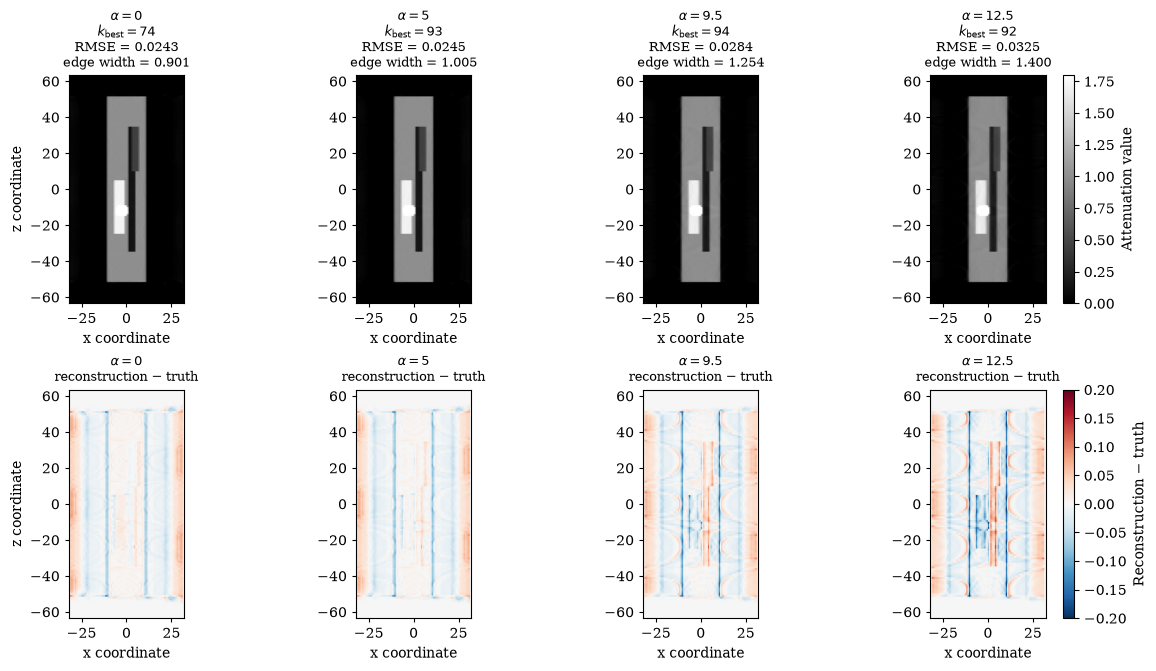

,alpha,best_iteration,minimum_rmse,edge_width_best,edge_width_best_std
0,0.0,74,0.024342,0.900938,0.114957
1,5.0,93,0.024546,1.005134,0.157625
2,9.5,94,0.028398,1.253854,0.203560
3,12.5,92,0.032506,1.399753,0.222553


In [ ]:
# ============================================================
# Reconstruction-level regularisation comparison
# Representative reconstruction-level regularisation
# comparison
#
# Geometry:
#   SDD error = 1%
#
# Detector support:
#   TD window
#
# alpha:
#   0, 5, 9.5, 12.5
#
# IMPORTANT:
# Every reconstruction is shown at its OWN oracle-best
# minimum-RMSE iteration.
#
# Row 1:
#   oracle-best reconstruction
#
# Row 2:
#   reconstruction - truth
# ============================================================

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm


TD_SDD_RECONSTRUCTION_ALPHAS = [
    0.0,
    5.0,
    9.5,
    12.5,
]


# ------------------------------------------------------------
# Plotting configuration
# ------------------------------------------------------------

RECONSTRUCTION_NORM = Normalize(
    vmin=0.0,
    vmax=1.8,
)

ERROR_NORM = TwoSlopeNorm(
    vmin=-0.20,
    vcenter=0.0,
    vmax=0.20,
)


# ------------------------------------------------------------
# Extract the already-stored oracle-best reconstructions.
# ------------------------------------------------------------

td_sdd_best_plot_data = {}


for alpha_value in TD_SDD_RECONSTRUCTION_ALPHAS:

    result = (
        geometry_tikhonov_results[
            "SDD"
        ][
            "td_window"
        ][
            alpha_value
        ][
            "result"
        ]
    )


    best_reconstruction = (
        result[
            "best_reconstruction"
        ]
    )


    best_volume = np.asarray(
        best_reconstruction.as_array(),
        dtype=np.float64,
    )


    # --------------------------------------------------------
    # Use the same existing oblique longitudinal extraction
    # as the geometry-error visualisations.
    # --------------------------------------------------------

    reconstruction_result = (
        extract_oblique_longitudinal_slice(
            volume=best_volume,
            point_1=
                plane_definition[
                    "point_1"
                ],
            point_2=
                plane_definition[
                    "point_2"
                ],
            half_width=
                half_width,
            half_height=
                half_height,
        )
    )


    reconstruction_slice = (
        reconstruction_result[
            "slice"
        ]
    )


    error_slice = (
        reconstruction_slice
        -
        truth_longitudinal_slice
    )


    # Existing edge-width helper.
    edge_result = (
        measure_outer_edge_width(
            best_reconstruction
        )
    )


    td_sdd_best_plot_data[
        alpha_value
    ] = {
        "reconstruction_slice":
            reconstruction_slice,

        "error_slice":
            error_slice,

        "best_iteration":
            int(
                result[
                    "best_iteration"
                ]
            ),

        "minimum_rmse":
            float(
                result[
                    "minimum_rmse"
                ]
            ),

        "edge_width":
            float(
                edge_result[
                    "mean_edge_width_10_90"
                ]
            ),

        "edge_width_std":
            float(
                edge_result[
                    "std_edge_width_10_90"
                ]
            ),
    }


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    len(
        TD_SDD_RECONSTRUCTION_ALPHAS
    ),
    figsize=(12.5, 6.6),
    constrained_layout=True,
)


for column, alpha_value in enumerate(
    TD_SDD_RECONSTRUCTION_ALPHAS
):

    data = (
        td_sdd_best_plot_data[
            alpha_value
        ]
    )


    # --------------------------------------------------------
    # Oracle-best reconstruction
    # --------------------------------------------------------

    axes[
        0,
        column
    ].imshow(
        data[
            "reconstruction_slice"
        ],
        cmap="gray",
        origin="lower",
        extent=extent,
        norm=RECONSTRUCTION_NORM,
        aspect="equal",
    )


    axes[
        0,
        column
    ].set_title(
        (
            rf"$\alpha={alpha_value:g}$"
            "\n"
            rf"$k_{{\mathrm{{best}}}}="
            f"{data['best_iteration']}$"
            "\n"
            f"RMSE = "
            f"{data['minimum_rmse']:.4f}"
            "\n"
            f"edge width = "
            f"{data['edge_width']:.3f}"
        ),
        fontsize=9,
        pad=6,
    )


    # --------------------------------------------------------
    # Error map
    # --------------------------------------------------------

    axes[
        1,
        column
    ].imshow(
        data[
            "error_slice"
        ],
        cmap="RdBu_r",
        origin="lower",
        extent=extent,
        norm=ERROR_NORM,
        aspect="equal",
    )


    axes[
        1,
        column
    ].set_title(
        (
            rf"$\alpha={alpha_value:g}$"
            "\n"
            r"reconstruction $-$ truth"
        ),
        fontsize=9,
        pad=6,
    )


    for row in [
        0,
        1,
    ]:

        axes[
            row,
            column
        ].set_xlabel(
            "x coordinate"
        )

        axes[
            row,
            column
        ].tick_params(
            direction="out",
            length=3.0,
        )


axes[
    0,
    0
].set_ylabel(
    "z coordinate"
)

axes[
    1,
    0
].set_ylabel(
    "z coordinate"
)


# ------------------------------------------------------------
# Shared reconstruction colourbar
# ------------------------------------------------------------

reconstruction_mappable = ScalarMappable(
    norm=RECONSTRUCTION_NORM,
    cmap="gray",
)

reconstruction_mappable.set_array(
    []
)


reconstruction_cbar = (
    fig.colorbar(
        reconstruction_mappable,
        ax=list(
            axes[
                0,
                :
            ]
        ),
        fraction=0.025,
        pad=0.015,
    )
)

reconstruction_cbar.set_label(
    "Attenuation value"
)


# ------------------------------------------------------------
# Shared symmetric error colourbar
# ------------------------------------------------------------

error_mappable = ScalarMappable(
    norm=ERROR_NORM,
    cmap="RdBu_r",
)

error_mappable.set_array(
    []
)


error_cbar = (
    fig.colorbar(
        error_mappable,
        ax=list(
            axes[
                1,
                :
            ]
        ),
        fraction=0.025,
        pad=0.015,
    )
)

error_cbar.set_label(
    "Reconstruction − truth"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = os.path.join(
    RESULTS_DIRECTORY,
    "fig6_7_td_sdd_regularisation_reconstruction_comparison.png",
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

print(
    "Saved:",
    figure_path,
)


plt.show()


# ------------------------------------------------------------
# Optional numerical check printed below the figure.
# ------------------------------------------------------------

display(
    pd.DataFrame(
        [
            {
                "alpha":
                    alpha_value,

                "best_iteration":
                    td_sdd_best_plot_data[
                        alpha_value
                    ][
                        "best_iteration"
                    ],

                "minimum_rmse":
                    td_sdd_best_plot_data[
                        alpha_value
                    ][
                        "minimum_rmse"
                    ],

                "edge_width_best":
                    td_sdd_best_plot_data[
                        alpha_value
                    ][
                        "edge_width"
                    ],

                "edge_width_best_std":
                    td_sdd_best_plot_data[
                        alpha_value
                    ][
                        "edge_width_std"
                    ],
            }

            for alpha_value
            in TD_SDD_RECONSTRUCTION_ALPHAS
        ]
    )
)

## 19. Continuous redundancy weighting

Replace the binary choice between TD-window and full-detector data with a continuous weight on measurements outside the TD support. The weighting parameter therefore interpolates between TD-only data and the full detector, allowing the contribution of redundant measurements to be studied under fixed geometric mismatch.


In [ ]:
from cil.optimisation.operators import (
    DiagonalOperator,
    CompositionOperator,
)


def build_redundancy_weighted_problem(
    wrong_full_operator,
    true_full_data,
    true_td_mask_values,
    lambda_outside,
):
    """
    Construct the weighted least-squares problem

        A_lambda = W_lambda^(1/2) A_wrong
        b_lambda = W_lambda^(1/2) b_true

    with

        W_lambda = 1       inside the fixed TRUE TD support
                   lambda  outside the TD support.

    Therefore:
        lambda = 0 -> TD-only
        lambda = 1 -> Full detector

    The TD support is kept fixed from the true acquisition geometry.
    """

    lambda_outside = float(lambda_outside)

    if not (0.0 <= lambda_outside <= 1.0):
        raise ValueError(
            "lambda_outside must satisfy 0 <= lambda_outside <= 1."
        )

    # --------------------------------------------------------
    # Copy the unchanged measured data into the range geometry
    # associated with the mismatched reconstruction operator.
    # --------------------------------------------------------

    full_data_for_wrong_operator = (
        copy_true_measurements_to_operator_range(
            true_full_data,
            wrong_full_operator,
        )
    )

    # --------------------------------------------------------
    # Fixed TD support from the TRUE acquisition geometry.
    #
    # td_mask = 1 inside TD
    #           0 outside TD
    #
    # sqrt(W_lambda):
    #   1              inside TD
    #   sqrt(lambda)   outside TD
    # --------------------------------------------------------

    td_mask = np.asarray(
        true_td_mask_values,
        dtype=np.float32,
    )

    expected_shape = (
        wrong_full_operator
        .range_geometry()
        .shape
    )

    if td_mask.shape != expected_shape:
        raise ValueError(
            "TD-mask/operator shape mismatch: "
            f"{td_mask.shape} vs {expected_shape}"
        )

    sqrt_weight_values = (
        td_mask
        + np.float32(np.sqrt(lambda_outside))
        * (1.0 - td_mask)
    )

    sqrt_weight = (
        wrong_full_operator
        .range_geometry()
        .allocate(0.0)
    )

    sqrt_weight.fill(
        sqrt_weight_values
    )

    weight_operator = DiagonalOperator(
        sqrt_weight
    )

    weighted_operator = CompositionOperator(
        weight_operator,
        wrong_full_operator,
    )

    weighted_data = weight_operator.direct(
        full_data_for_wrong_operator
    )

    weighting_diagnostics = {
        "lambda": lambda_outside,
        "sqrt_lambda": float(
            np.sqrt(lambda_outside)
        ),
        "td_fraction": float(
            np.mean(td_mask)
        ),
        "outside_td_fraction": float(
            1.0 - np.mean(td_mask)
        ),
        "mean_weight_W": float(
            np.mean(
                td_mask
                + lambda_outside
                * (1.0 - td_mask)
            )
        ),
    }

    return (
        weighted_operator,
        weighted_data,
        weighting_diagnostics,
    )

In [ ]:
# ============================================================
# RUN regularised redundancy-weighting experiment
# ============================================================

import numpy as np
import pandas as pd

REG_REDUNDANCY_COR_ERROR_PIXELS = 0.5

REG_REDUNDANCY_LAMBDAS = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
]

REG_REDUNDANCY_ALPHAS = [
    0.0,
    5.0,
    9.5,
    12.5,
]


# ------------------------------------------------------------
# Check all required objects BEFORE spending GPU time
# ------------------------------------------------------------

required_names = [
    "true_full_problem",
    "true_full_projection_data",
    "true_td_mask_values",
    "build_helical_reconstruction_operator_with_cor_error",
    "copy_true_measurements_to_operator_range",
    "build_redundancy_weighted_problem",
    "run_lsqr_with_diagnostics",
    "measure_outer_edge_width",
    "GEOMETRY_ERROR_MAX_ITERATIONS",
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise NameError(
        "Missing prerequisite(s): "
        + ", ".join(missing)
    )

print("All prerequisites found.")


# ------------------------------------------------------------
# Fixed wrong reconstruction geometry: COR = 0.5 pixel
# ------------------------------------------------------------

(
    regularised_redundancy_wrong_operator,
    regularised_redundancy_wrong_geometry,
    regularised_redundancy_cor_diagnostics,
) = build_helical_reconstruction_operator_with_cor_error(
    true_full_problem,
    cor_error_offset_pixels=(
        REG_REDUNDANCY_COR_ERROR_PIXELS
    ),
)


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

regularised_redundancy_results = {}
regularised_redundancy_rows = []


# ------------------------------------------------------------
# 5 lambda x 4 alpha = 20 reconstructions
# ------------------------------------------------------------

for lambda_outside in REG_REDUNDANCY_LAMBDAS:

    print("\n" + "=" * 72)
    print(
        f"Building weighted problem: "
        f"lambda = {lambda_outside:g}"
    )

    (
        weighted_operator,
        weighted_data,
        weighting_diagnostics,
    ) = build_redundancy_weighted_problem(
        wrong_full_operator=(
            regularised_redundancy_wrong_operator
        ),
        true_full_data=(
            true_full_projection_data
        ),
        true_td_mask_values=(
            true_td_mask_values
        ),
        lambda_outside=(
            lambda_outside
        ),
    )

    regularised_redundancy_results[
        float(lambda_outside)
    ] = {}

    for alpha_value in REG_REDUNDANCY_ALPHAS:

        print(
            f"\nRunning lambda={lambda_outside:g}, "
            f"alpha={alpha_value:g}"
        )

        initial = (
            true_full_problem[
                "image_geometry"
            ]
            .allocate(0.0)
        )

        result = run_lsqr_with_diagnostics(
            operator_local=weighted_operator,
            data_local=weighted_data,
            truth_local=(
                true_full_problem["phantom"]
            ),
            initial_local=initial,
            number_of_iterations_local=(
                GEOMETRY_ERROR_MAX_ITERATIONS
            ),
            alpha=float(alpha_value),
            checkpoint_interval=1,
        )

        # Edge-width diagnostics
        best_edge = measure_outer_edge_width(
            result["best_reconstruction"]
        )

        final_edge = measure_outer_edge_width(
            result["final_reconstruction"]
        )

        edge_width_best = (
            best_edge[
                "mean_edge_width_10_90"
            ]
        )

        edge_width_final = (
            final_edge[
                "mean_edge_width_10_90"
            ]
        )

        # Save complete result
        regularised_redundancy_results[
            float(lambda_outside)
        ][float(alpha_value)] = {
            "result": result,
            "operator": weighted_operator,
            "data": weighted_data,
            "weighting_diagnostics": (
                weighting_diagnostics
            ),
            "edge_width_best": (
                edge_width_best
            ),
            "edge_width_iteration_100": (
                edge_width_final
            ),
        }

        # Save summary row
        regularised_redundancy_rows.append(
            {
                "lambda": float(
                    lambda_outside
                ),

                "alpha": float(
                    alpha_value
                ),

                "best_iteration": int(
                    result["best_iteration"]
                ),

                "minimum_rmse": float(
                    result["minimum_rmse"]
                ),

                "rmse_at_iteration_100": float(
                    result["final_rmse"]
                ),

                "rmse_increase_after_best": float(
                    result["final_rmse"]
                    - result["minimum_rmse"]
                ),

                "relative_residual_at_best": float(
                    result[
                        "relative_residual_at_best"
                    ]
                ),

                "relative_residual_at_iteration_100": float(
                    result[
                        "relative_residual_at_final"
                    ]
                ),

                "edge_width_best": float(
                    edge_width_best
                ),

                "edge_width_iteration_100": float(
                    edge_width_final
                ),
            }
        )

        print(
            "  best iteration : "
            f"{result['best_iteration']}"
        )
        print(
            "  minimum RMSE   : "
            f"{result['minimum_rmse']:.8f}"
        )
        print(
            "  RMSE @ 100     : "
            f"{result['final_rmse']:.8f}"
        )


# ------------------------------------------------------------
# IMPORTANT:
# Actually create the DataFrame that was missing
# ------------------------------------------------------------

regularised_redundancy_summary = (
    pd.DataFrame(
        regularised_redundancy_rows
    )
    .sort_values(
        ["alpha", "lambda"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Verify that all 20 cases completed
# ------------------------------------------------------------

expected_cases = (
    len(REG_REDUNDANCY_LAMBDAS)
    * len(REG_REDUNDANCY_ALPHAS)
)

assert (
    len(regularised_redundancy_summary)
    == expected_cases
), (
    f"Expected {expected_cases} cases, "
    f"but obtained "
    f"{len(regularised_redundancy_summary)}."
)


print("\n" + "=" * 72)
print(
    f"SUCCESS: completed "
    f"{expected_cases} / {expected_cases} cases."
)
print(
    "regularised_redundancy_summary created."
)
print("=" * 72)


display(
    regularised_redundancy_summary
)

All prerequisites found.

Building weighted problem: lambda = 0

Running lambda=0, alpha=0
  best iteration : 40
  minimum RMSE   : 0.03814791
  RMSE @ 100     : 0.04962253

Running lambda=0, alpha=5
  best iteration : 43
  minimum RMSE   : 0.03833556
  RMSE @ 100     : 0.03961829

Running lambda=0, alpha=9.5
  best iteration : 45
  minimum RMSE   : 0.04011597
  RMSE @ 100     : 0.04022860

Running lambda=0, alpha=12.5
  best iteration : 44
  minimum RMSE   : 0.04248212
  RMSE @ 100     : 0.04252322

Building weighted problem: lambda = 0.25

Running lambda=0.25, alpha=0
  best iteration : 27
  minimum RMSE   : 0.02458683
  RMSE @ 100     : 0.04852981

Running lambda=0.25, alpha=5
  best iteration : 28
  minimum RMSE   : 0.02517033
  RMSE @ 100     : 0.02914619

Running lambda=0.25, alpha=9.5
  best iteration : 28
  minimum RMSE   : 0.02726097
  RMSE @ 100     : 0.02852971

Running lambda=0.25, alpha=12.5
  best iteration : 27
  minimum RMSE   : 0.02963577
  RMSE @ 100     : 0.03049025


,lambda,alpha,best_iteration,minimum_rmse,rmse_at_iteration_100,rmse_increase_after_best,relative_residual_at_best,relative_residual_at_iteration_100,edge_width_best,edge_width_iteration_100
0,0.00,0.0,40,0.038148,0.049623,0.011475,0.010888,0.010810,1.476898,1.467519
1,0.25,0.0,27,0.024587,0.048530,0.023943,0.036197,0.036009,1.218022,1.351018
2,0.50,0.0,29,0.022948,0.099330,0.076381,0.038074,0.038200,1.070463,1.169682
3,0.75,0.0,31,0.023607,0.224995,0.201388,0.037559,0.038517,1.163620,1.192490
4,1.00,0.0,31,0.024663,0.326250,0.301587,0.036533,0.038909,1.204062,1.225690
5,0.00,5.0,43,0.038336,0.039618,0.001283,0.011467,0.011419,1.513449,1.511209
6,0.25,5.0,28,0.025170,0.029146,0.003976,0.036202,0.036020,1.295281,1.375454
7,0.50,5.0,29,0.023560,0.029399,0.005839,0.038101,0.038032,1.133773,1.245127
8,0.75,5.0,31,0.024071,0.032958,0.008886,0.037585,0.037530,1.188641,1.215468
9,1.00,5.0,31,0.025012,0.037072,0.012060,0.036554,0.036503,1.220947,1.242123


In [ ]:
# ============================================================
# Best lambda for each alpha
# ============================================================

best_lambda_rows = []

for alpha_value in REG_REDUNDANCY_ALPHAS:

    subset = (
        regularised_redundancy_summary[
            np.isclose(
                regularised_redundancy_summary["alpha"],
                alpha_value,
            )
        ]
        .sort_values("lambda")
        .reset_index(drop=True)
    )

    best_oracle_row = subset.loc[
        subset["minimum_rmse"].idxmin()
    ]

    best_final_row = subset.loc[
        subset[
            "rmse_at_iteration_100"
        ].idxmin()
    ]

    best_lambda_rows.append(
        {
            "alpha": alpha_value,

            "best_lambda_oracle": (
                best_oracle_row["lambda"]
            ),

            "best_minimum_rmse": (
                best_oracle_row["minimum_rmse"]
            ),

            "best_lambda_iteration_100": (
                best_final_row["lambda"]
            ),

            "best_rmse_iteration_100": (
                best_final_row[
                    "rmse_at_iteration_100"
                ]
            ),
        }
    )

best_lambda_by_alpha = pd.DataFrame(
    best_lambda_rows
)

display(best_lambda_by_alpha)

,alpha,best_lambda_oracle,best_minimum_rmse,best_lambda_iteration_100,best_rmse_iteration_100
0,0.0,0.50,0.022948,0.25,0.048530
1,5.0,0.50,0.023560,0.25,0.029146
2,9.5,0.50,0.025304,0.50,0.026354
3,12.5,0.75,0.026761,0.75,0.027294


## 20. Final geometry-mismatch and redundancy figures

Generate the final comparison figures from the completed geometry-error, Tikhonov, edge-width, and redundancy-weighting experiments. Common display ranges are retained across comparable panels so that differences in reconstruction error can be interpreted consistently.


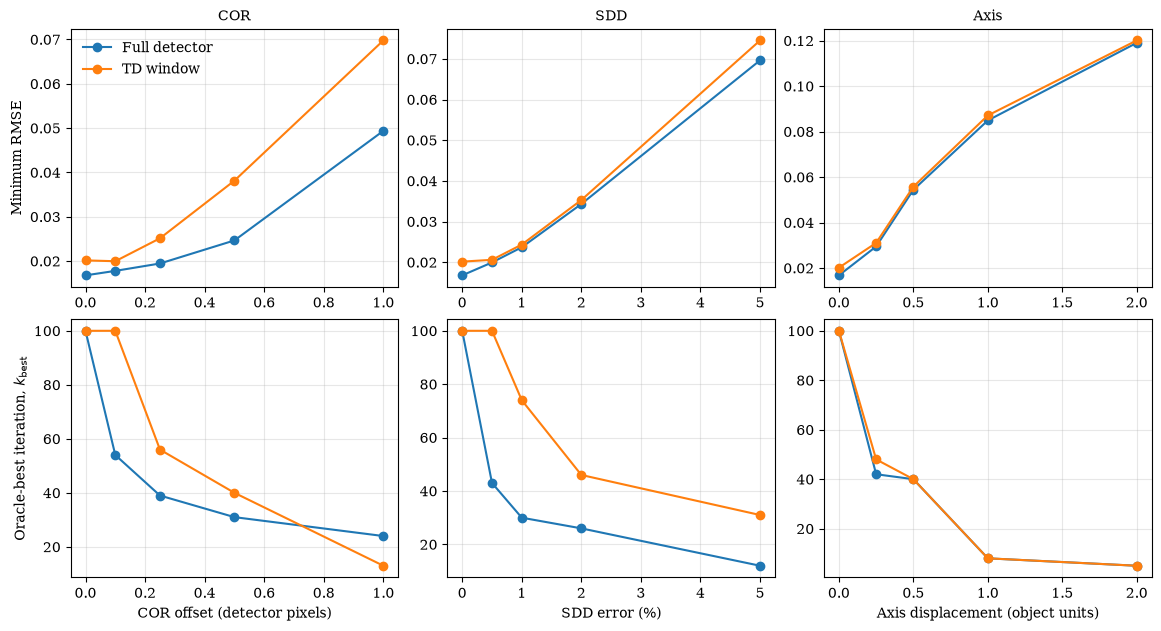

In [ ]:
# ============================================================
# Geometry-error summary figure
# Effect of geometric miscalibration on reconstruction
# accuracy and LSQR iteration behaviour
#
# Top row:
#   minimum RMSE
#
# Bottom row:
#   oracle-best iteration
#
# Columns:
#   COR | SDD | Axis
# ============================================================

# ============================================================
# Unified geometry-error summary for Figure 6.1
# ============================================================

chapter6_geometry_summary = pd.concat(
    [
        cor_geometry_error_summary.assign(
            geometry_error="COR",
            error_value=(
                cor_geometry_error_summary[
                    "COR_error_offset_pixels"
                ]
            ),
        ),

        sdd_geometry_error_summary.assign(
            geometry_error="SDD",
            error_value=(
                sdd_geometry_error_summary[
                    "SDD_error_percent"
                ]
            ),
        ),

        axis_geometry_error_summary.assign(
            geometry_error="Axis",
            error_value=(
                axis_geometry_error_summary[
                    "axis_displacement"
                ]
            ),
        ),
    ],
    ignore_index=True,
    sort=False,
)



DETECTOR_LABELS = {
    "full_detector": "Full detector",
    "td_window": "TD window",
}


GEOMETRY_LABELS = {
    "COR": "COR",
    "SDD": "SDD",
    "Axis": "Axis",
}


geometry_specs = [
    {
        "name": "COR",
        "xlabel": "COR offset (detector pixels)",
    },
    {
        "name": "SDD",
        "xlabel": "SDD error (%)",
    },
    {
        "name": "Axis",
        "xlabel": "Axis displacement (object units)",
    },
]


with plt.rc_context():

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(11.5, 6.2),
        constrained_layout=True,
    )


    for column, spec in enumerate(
        geometry_specs
    ):

        subset_geometry = (
            chapter6_geometry_summary[
                chapter6_geometry_summary[
                    "geometry_error"
                ]
                == spec["name"]
            ]
        )


        for detector_type in [
            "full_detector",
            "td_window",
        ]:

            subset = (
                subset_geometry[
                    subset_geometry[
                        "detector_type"
                    ]
                    == detector_type
                ]
                .sort_values(
                    "error_value"
                )
            )


            # ------------------------------------------------
            # Minimum RMSE
            # ------------------------------------------------

            axes[
                0,
                column
            ].plot(
                subset[
                    "error_value"
                ],
                subset[
                    "minimum_rmse"
                ],
                marker="o",
                label=(
                    DETECTOR_LABELS[
                        detector_type
                    ]
                ),
            )


            # ------------------------------------------------
            # Oracle-best iteration
            # ------------------------------------------------

            axes[
                1,
                column
            ].plot(
                subset[
                    "error_value"
                ],
                subset[
                    "best_iteration"
                ],
                marker="o",
                label=(
                    DETECTOR_LABELS[
                        detector_type
                    ]
                ),
            )


        axes[
            0,
            column
        ].set_title(
            spec["name"]
        )

        axes[
            1,
            column
        ].set_xlabel(
            spec["xlabel"]
        )


        axes[
            0,
            column
        ].grid(
            True,
            alpha=0.3,
        )

        axes[
            1,
            column
        ].grid(
            True,
            alpha=0.3,
        )


    axes[
        0,
        0
    ].set_ylabel(
        "Minimum RMSE"
    )

    axes[
        1,
        0
    ].set_ylabel(
        r"Oracle-best iteration, $k_{\mathrm{best}}$"
    )


    axes[
        0,
        0
    ].legend(
        loc="upper left",
        frameon=False,
    )


    plt.show()

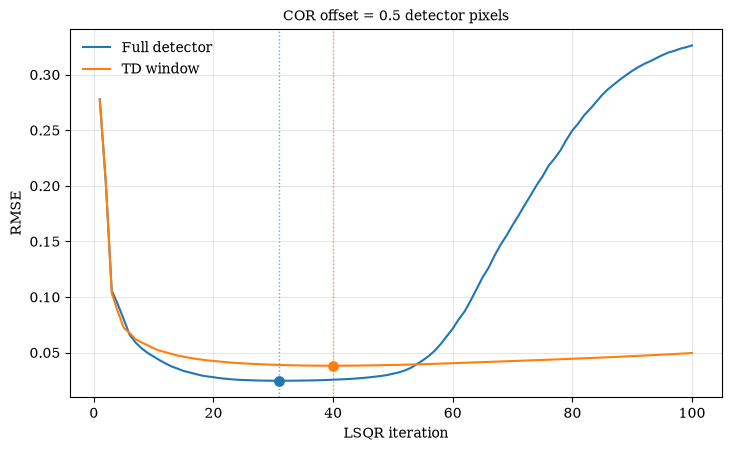

In [ ]:
# ============================================================
# Representative Full-vs-TD RMSE histories
# Representative Full-vs-TD RMSE histories
#
# Fixed:
#   COR error = 0.5 detector pixels
#   alpha = 0
# ============================================================


COR_REPRESENTATIVE_OFFSET = 0.5


with plt.rc_context():

    fig, ax = plt.subplots(
        figsize=(7.2, 4.4),
        constrained_layout=True,
    )


    for detector_type in [
        "full_detector",
        "td_window",
    ]:

        entry = (
            cor_geometry_error_results[
                detector_type
            ][
                COR_REPRESENTATIVE_OFFSET
            ]
        )

        result = entry[
            "result"
        ]

        history = result[
            "history"
        ]


        # ----------------------------------------------------
        # RMSE trajectory
        # ----------------------------------------------------

        line = ax.plot(
            history[
                "iteration"
            ],
            history[
                "rmse"
            ],
            label=(
                DETECTOR_LABELS[
                    detector_type
                ]
            ),
        )[0]


        # ----------------------------------------------------
        # Oracle-best point
        # ----------------------------------------------------

        ax.scatter(
            result[
                "best_iteration"
            ],
            result[
                "minimum_rmse"
            ],
            s=45,
            zorder=4,
            color=line.get_color(),
        )


        ax.axvline(
            result[
                "best_iteration"
            ],
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
            color=line.get_color(),
        )


    ax.set_xlabel(
        "LSQR iteration"
    )

    ax.set_ylabel(
        "RMSE"
    )

    ax.set_title(
        "COR offset = 0.5 detector pixels"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        loc="upper left",
        frameon=False,
    )


    plt.show()

,geometry_error,detector_type,alpha,best_iteration,minimum_rmse,rmse_at_iteration_100,edge_width_best
0,Axis,full_detector,0.0,40,0.054417,0.090469,1.415241
1,Axis,full_detector,2.5,40,0.054379,0.070132,1.417610
2,Axis,full_detector,5.0,40,0.054274,0.057904,1.424666
3,Axis,full_detector,7.5,41,0.054127,0.055066,1.437142
4,Axis,full_detector,9.5,41,0.054000,0.054356,1.449383
5,Axis,full_detector,12.5,41,0.053842,0.053932,1.472542
6,Axis,full_detector,15.0,50,0.053771,0.053805,1.495143
7,Axis,full_detector,18.0,51,0.053811,0.053823,1.527189
8,Axis,full_detector,20.0,51,0.053928,0.053935,1.550836
9,Axis,full_detector,30.0,52,0.055800,0.055800,1.686227


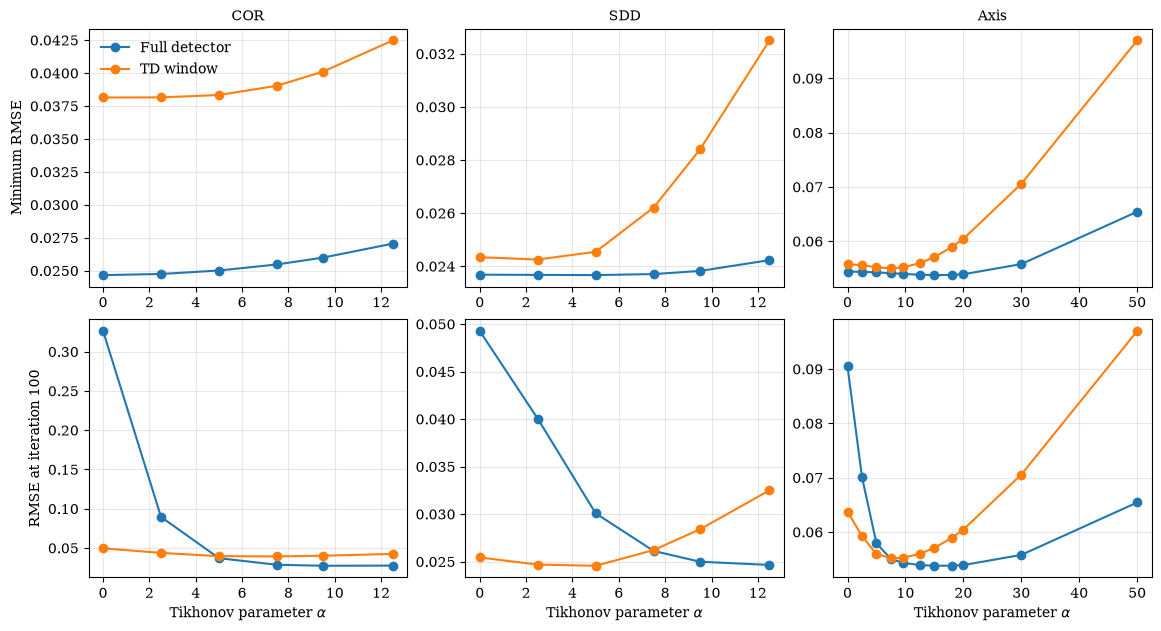

In [ ]:
# ============================================================
# Tikhonov regularisation under geometry mismatch
# Effect of Tikhonov regularisation on reconstruction error
#
# Top row:
#   minimum RMSE
#
# Bottom row:
#   RMSE at iteration 100
#
# Columns:
#   representative COR | SDD | Axis
# ============================================================


# ============================================================
# Build unified Tikhonov summary
#
# Uses existing reconstruction results only.
# Does NOT rerun LSQR.
# ============================================================

tikhonov_rows = []


# ------------------------------------------------------------
# COR and SDD
# ------------------------------------------------------------

for geometry_name in [
    "COR",
    "SDD",
]:

    for detector_type in [
        "full_detector",
        "td_window",
    ]:

        for alpha_value, entry in (
            geometry_tikhonov_results[
                geometry_name
            ][
                detector_type
            ].items()
        ):

            result = entry[
                "result"
            ]


            if (
                "edge_width_best"
                in entry
            ):

                edge_width_best = (
                    entry[
                        "edge_width_best"
                    ]
                )

            else:

                edge_measurement = (
                    measure_outer_edge_width(
                        result[
                            "best_reconstruction"
                        ]
                    )
                )

                edge_width_best = (
                    edge_measurement[
                        "mean_edge_width_10_90"
                    ]
                )


            tikhonov_rows.append(
                {
                    "geometry_error":
                        geometry_name,

                    "detector_type":
                        detector_type,

                    "alpha":
                        float(
                            alpha_value
                        ),

                    "best_iteration":
                        int(
                            result[
                                "best_iteration"
                            ]
                        ),

                    "minimum_rmse":
                        float(
                            result[
                                "minimum_rmse"
                            ]
                        ),

                    "rmse_at_iteration_100":
                        float(
                            result[
                                "final_rmse"
                            ]
                        ),

                    "edge_width_best":
                        float(
                            edge_width_best
                        ),
                }
            )


# ------------------------------------------------------------
# Axis
# ------------------------------------------------------------

for detector_type in [
    "full_detector",
    "td_window",
]:

    for alpha_value, entry in (
        axis_tikhonov_results[
            detector_type
        ].items()
    ):

        result = entry[
            "result"
        ]


        if (
            "edge_width_best"
            in entry
        ):

            edge_width_best = (
                entry[
                    "edge_width_best"
                ]
            )

        else:

            edge_measurement = (
                measure_outer_edge_width(
                    result[
                        "best_reconstruction"
                    ]
                )
            )

            edge_width_best = (
                edge_measurement[
                    "mean_edge_width_10_90"
                ]
            )


        tikhonov_rows.append(
            {
                "geometry_error":
                    "Axis",

                "detector_type":
                    detector_type,

                "alpha":
                    float(
                        alpha_value
                    ),

                "best_iteration":
                    int(
                        result[
                            "best_iteration"
                        ]
                    ),

                "minimum_rmse":
                    float(
                        result[
                            "minimum_rmse"
                        ]
                    ),

                "rmse_at_iteration_100":
                    float(
                        result[
                            "final_rmse"
                        ]
                    ),

                "edge_width_best":
                    float(
                        edge_width_best
                    ),
            }
        )


chapter6_tikhonov_summary = (
    pd.DataFrame(
        tikhonov_rows
    )
    .sort_values(
        [
            "geometry_error",
            "detector_type",
            "alpha",
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    chapter6_tikhonov_summary
)


# ============================================================
# Plot
# ============================================================

tikhonov_geometry_names = [
    "COR",
    "SDD",
    "Axis",
]


with plt.rc_context():

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(11.5, 6.2),
        constrained_layout=True,
    )


    for column, geometry_name in enumerate(
        tikhonov_geometry_names
    ):

        subset_geometry = (
            chapter6_tikhonov_summary[
                chapter6_tikhonov_summary[
                    "geometry_error"
                ]
                == geometry_name
            ]
        )


        for detector_type in [
            "full_detector",
            "td_window",
        ]:

            subset = (
                subset_geometry[
                    subset_geometry[
                        "detector_type"
                    ]
                    == detector_type
                ]
                .sort_values(
                    "alpha"
                )
            )


            axes[
                0,
                column
            ].plot(
                subset[
                    "alpha"
                ],
                subset[
                    "minimum_rmse"
                ],
                marker="o",
                label=(
                    DETECTOR_LABELS[
                        detector_type
                    ]
                ),
            )


            axes[
                1,
                column
            ].plot(
                subset[
                    "alpha"
                ],
                subset[
                    "rmse_at_iteration_100"
                ],
                marker="o",
                label=(
                    DETECTOR_LABELS[
                        detector_type
                    ]
                ),
            )


        axes[
            0,
            column
        ].set_title(
            GEOMETRY_LABELS.get(
                geometry_name,
                geometry_name,
            )
        )

        axes[
            1,
            column
        ].set_xlabel(
            r"Tikhonov parameter $\alpha$"
        )


        axes[
            0,
            column
        ].grid(
            True,
            alpha=0.3,
        )

        axes[
            1,
            column
        ].grid(
            True,
            alpha=0.3,
        )


    axes[
        0,
        0
    ].set_ylabel(
        "Minimum RMSE"
    )

    axes[
        1,
        0
    ].set_ylabel(
        "RMSE at iteration 100"
    )


    axes[
        0,
        0
    ].legend(
        loc="best",
        frameon=False,
    )


    plt.show()

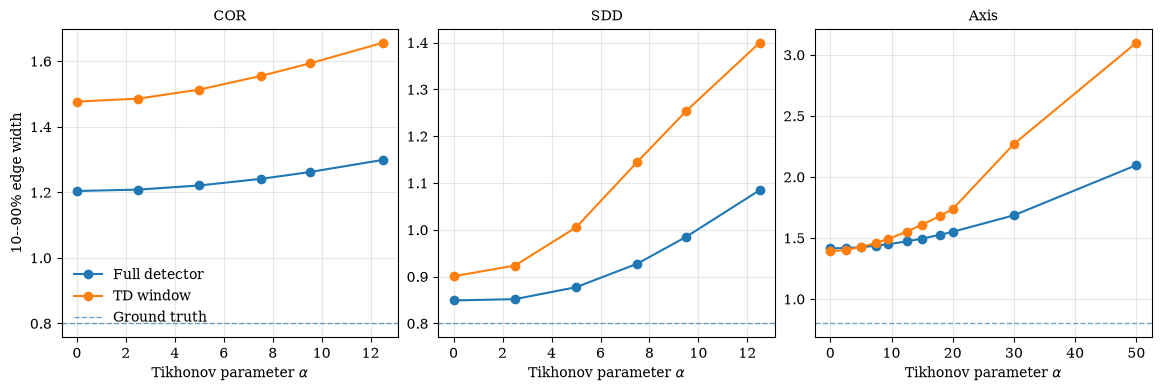

In [ ]:
# ============================================================
# Edge-width trade-off under Tikhonov regularisation
# Sharpness trade-off under Tikhonov regularisation
#
# Panels:
#   COR | SDD | Axis
#
# Quantity:
#   10--90% edge width at oracle-best iteration
# ============================================================


tradeoff_geometry_names = [
    "COR",
    "SDD",
    "Axis",
]


with plt.rc_context():

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(11.5, 3.8),
        constrained_layout=True,
    )


    for column, geometry_name in enumerate(
        tradeoff_geometry_names
    ):

        subset_geometry = (
            chapter6_tikhonov_summary[
                chapter6_tikhonov_summary[
                    "geometry_error"
                ]
                == geometry_name
            ]
        )


        for detector_type in [
            "full_detector",
            "td_window",
        ]:

            subset = (
                subset_geometry[
                    subset_geometry[
                        "detector_type"
                    ]
                    == detector_type
                ]
                .sort_values(
                    "alpha"
                )
            )


            axes[
                column
            ].plot(
                subset[
                    "alpha"
                ],
                subset[
                    "edge_width_best"
                ],
                marker="o",
                label=(
                    DETECTOR_LABELS[
                        detector_type
                    ]
                ),
            )


        # Ground-truth reference
        axes[
            column
        ].axhline(
            truth_edge_width,
            linestyle="--",
            linewidth=1.0,
            alpha=0.65,
            label=(
                "Ground truth"
                if column == 0
                else None
            ),
        )


        axes[
            column
        ].set_title(
            GEOMETRY_LABELS.get(
                geometry_name,
                geometry_name,
            )
        )

        axes[
            column
        ].set_xlabel(
            r"Tikhonov parameter $\alpha$"
        )

        axes[
            column
        ].grid(
            True,
            alpha=0.3,
        )


    axes[
        0
    ].set_ylabel(
        r"10--90% edge width"
    )


    axes[
        0
    ].legend(
        loc="best",
        frameon=False,
    )


    plt.show()

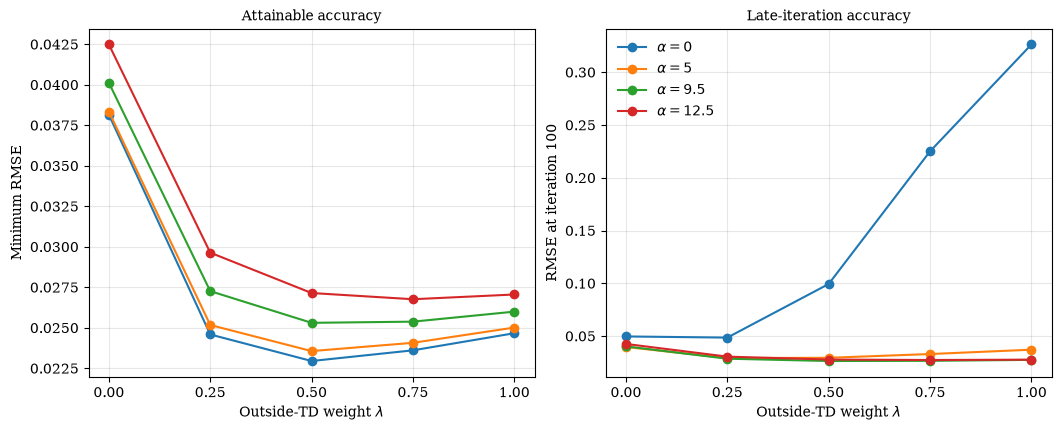

In [ ]:
# ============================================================
# Redundancy weighting and Tikhonov regularisation
# Interaction between outside-TD weighting and
# Tikhonov regularisation
#
# Fixed:
#   COR offset = 0.5 detector pixels
#
# Left:
#   minimum RMSE
#
# Right:
#   RMSE at iteration 100
#
# lambda = 0  -> TD window
# lambda = 1  -> Full detector
# ============================================================


redundancy_summary = (
    regularised_redundancy_summary
    .sort_values(
        [
            "alpha",
            "lambda",
        ]
    )
)


REDUNDANCY_ALPHAS_TO_PLOT = sorted(
    redundancy_summary[
        "alpha"
    ].unique()
)


with plt.rc_context():

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.5, 4.2),
        constrained_layout=True,
    )


    for alpha_value in (
        REDUNDANCY_ALPHAS_TO_PLOT
    ):

        subset = (
            redundancy_summary[
                np.isclose(
                    redundancy_summary[
                        "alpha"
                    ],
                    alpha_value,
                )
            ]
            .sort_values(
                "lambda"
            )
        )


        axes[
            0
        ].plot(
            subset[
                "lambda"
            ],
            subset[
                "minimum_rmse"
            ],
            marker="o",
            label=(
                rf"$\alpha={alpha_value:g}$"
            ),
        )


        axes[
            1
        ].plot(
            subset[
                "lambda"
            ],
            subset[
                "rmse_at_iteration_100"
            ],
            marker="o",
            label=(
                rf"$\alpha={alpha_value:g}$"
            ),
        )


    lambda_ticks = sorted(
        redundancy_summary[
            "lambda"
        ].unique()
    )


    for ax in axes:

        ax.set_xlabel(
            r"Outside-TD weight $\lambda$"
        )

        ax.set_xticks(
            lambda_ticks
        )

        ax.grid(
            True,
            alpha=0.3,
        )


    axes[
        0
    ].set_ylabel(
        "Minimum RMSE"
    )

    axes[
        1
    ].set_ylabel(
        "RMSE at iteration 100"
    )


    axes[
        0
    ].set_title(
        "Attainable accuracy"
    )

    axes[
        1
    ].set_title(
        "Late-iteration accuracy"
    )


    axes[
        1
    ].legend(
        loc="best",
        frameon=False,
    )


    plt.show()

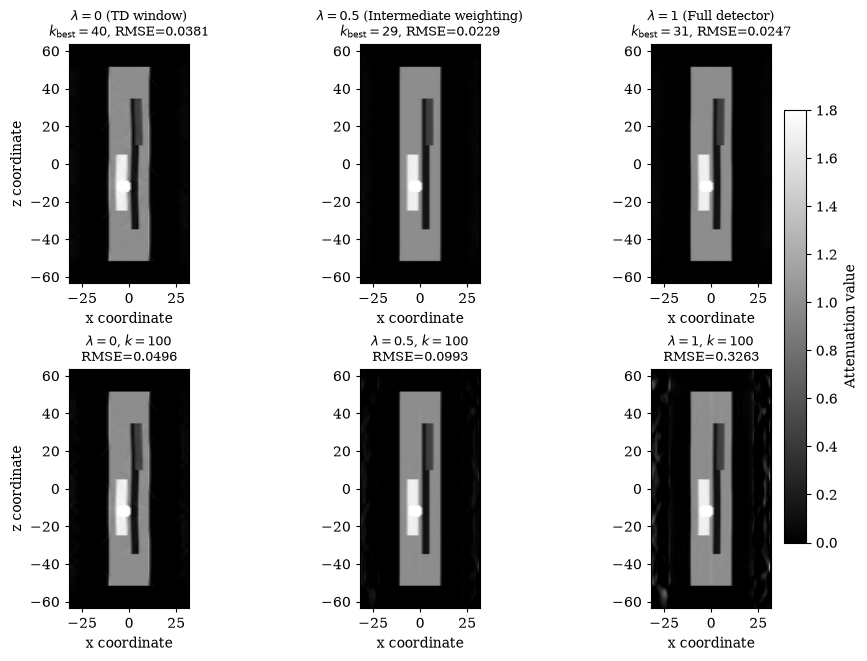


Representative redundancy-weighting cases:
lambda=   0 | k_best= 40 | min RMSE=0.03815 | RMSE@100=0.04962
lambda= 0.5 | k_best= 29 | min RMSE=0.02295 | RMSE@100=0.09933
lambda=   1 | k_best= 31 | min RMSE=0.02466 | RMSE@100=0.32625


In [ ]:
# ============================================================
# Representative redundancy-weighted reconstructions
# Representative reconstruction images for redundancy weighting
#
# Fixed:
#   COR offset = 0.5 detector pixels
#   alpha = 0
#
# Columns:
#   lambda = 0     -> TD window
#   lambda = 0.5   -> intermediate weighting
#   lambda = 1     -> Full detector
#
# Row 1:
#   Oracle-best reconstruction
#
# Row 2:
#   Reconstruction at iteration 100
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

REDUNDANCY_VISUAL_LAMBDAS = [
    0.0,
    0.5,
    1.0,
]

REDUNDANCY_VISUAL_ALPHA = 0.0


# ------------------------------------------------------------
# 2. Collect reconstruction slices
# ------------------------------------------------------------

best_slices = []
late_slices = []

best_iterations = []
minimum_rmse_values = []
late_rmse_values = []


for lambda_value in REDUNDANCY_VISUAL_LAMBDAS:

    entry = (
        regularised_redundancy_results[
            float(lambda_value)
        ][
            float(REDUNDANCY_VISUAL_ALPHA)
        ]
    )

    result = entry[
        "result"
    ]


    # --------------------------------------------------------
    # Oracle-best reconstruction
    # --------------------------------------------------------

    best_volume = np.asarray(
        result[
            "best_reconstruction"
        ].as_array(),
        dtype=np.float64,
    )


    best_slice = (
        extract_oblique_longitudinal_slice(
            volume=best_volume,
            point_1=plane_definition[
                "point_1"
            ],
            point_2=plane_definition[
                "point_2"
            ],
            half_width=half_width,
            half_height=half_height,
        )[
            "slice"
        ]
    )


    # --------------------------------------------------------
    # Iteration-100 reconstruction
    #
    # In these runs the final reconstruction is iteration 100.
    # --------------------------------------------------------

    late_volume = np.asarray(
        result[
            "final_reconstruction"
        ].as_array(),
        dtype=np.float64,
    )


    late_slice = (
        extract_oblique_longitudinal_slice(
            volume=late_volume,
            point_1=plane_definition[
                "point_1"
            ],
            point_2=plane_definition[
                "point_2"
            ],
            half_width=half_width,
            half_height=half_height,
        )[
            "slice"
        ]
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    best_slices.append(
        best_slice
    )

    late_slices.append(
        late_slice
    )

    best_iterations.append(
        int(
            result[
                "best_iteration"
            ]
        )
    )

    minimum_rmse_values.append(
        float(
            result[
                "minimum_rmse"
            ]
        )
    )

    late_rmse_values.append(
        float(
            result[
                "final_rmse"
            ]
        )
    )


# ------------------------------------------------------------
# 3. Common reconstruction scale
#
# Important:
# same colour scale for ALL six images.
# ------------------------------------------------------------

reconstruction_norm = Normalize(
    vmin=0.0,
    vmax=1.8,
)


# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

with plt.rc_context():

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(
            9.6,
            6.5,
        ),
        constrained_layout=True,
    )


    # ========================================================
    # Row 1: oracle-best reconstructions
    # ========================================================

    for column, lambda_value in enumerate(
        REDUNDANCY_VISUAL_LAMBDAS
    ):

        axes[
            0,
            column,
        ].imshow(
            best_slices[
                column
            ],
            cmap="gray",
            origin="lower",
            extent=extent,
            norm=reconstruction_norm,
            aspect="equal",
        )


        if np.isclose(
            lambda_value,
            0.0,
        ):

            endpoint_label = (
                "TD window"
            )

        elif np.isclose(
            lambda_value,
            1.0,
        ):

            endpoint_label = (
                "Full detector"
            )

        else:

            endpoint_label = (
                "Intermediate weighting"
            )


        axes[
            0,
            column,
        ].set_title(
            (
                rf"$\lambda={lambda_value:g}$ "
                f"({endpoint_label})"
                "\n"
                rf"$k_{{\mathrm{{best}}}}="
                f"{best_iterations[column]}$, "
                f"RMSE="
                f"{minimum_rmse_values[column]:.4f}"
            ),
            fontsize=9,
        )


    # ========================================================
    # Row 2: iteration 100
    # ========================================================

    for column, lambda_value in enumerate(
        REDUNDANCY_VISUAL_LAMBDAS
    ):

        axes[
            1,
            column,
        ].imshow(
            late_slices[
                column
            ],
            cmap="gray",
            origin="lower",
            extent=extent,
            norm=reconstruction_norm,
            aspect="equal",
        )

        axes[
            1,
            column,
        ].set_title(
            (
                rf"$\lambda={lambda_value:g}$, "
                r"$k=100$"
                "\n"
                f"RMSE="
                f"{late_rmse_values[column]:.4f}"
            ),
            fontsize=9,
        )


    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    axes[
        0,
        0,
    ].set_ylabel(
        "z coordinate"
    )

    axes[
        1,
        0,
    ].set_ylabel(
        "z coordinate"
    )


    for ax in axes.flat:

        ax.set_xlabel(
            "x coordinate"
        )

        ax.tick_params(
            direction="out",
            length=3,
        )


    # --------------------------------------------------------
    # Shared colourbar
    # --------------------------------------------------------

    reconstruction_mappable = ScalarMappable(
        norm=reconstruction_norm,
        cmap="gray",
    )

    reconstruction_mappable.set_array(
        []
    )

    reconstruction_cbar = (
        fig.colorbar(
            reconstruction_mappable,
            ax=list(
                axes.flat
            ),
            fraction=0.025,
            pad=0.015,
        )
    )

    reconstruction_cbar.set_label(
        "Attenuation value"
    )


    plt.show()


# ------------------------------------------------------------
# 5. Numerical check
# ------------------------------------------------------------

print(
    "\nRepresentative redundancy-weighting cases:"
)

for (
    lambda_value,
    best_iteration,
    minimum_rmse,
    late_rmse,
) in zip(
    REDUNDANCY_VISUAL_LAMBDAS,
    best_iterations,
    minimum_rmse_values,
    late_rmse_values,
):

    print(
        f"lambda={lambda_value:>4g} | "
        f"k_best={best_iteration:>3d} | "
        f"min RMSE={minimum_rmse:.5f} | "
        f"RMSE@100={late_rmse:.5f}"
    )

# Data-driven stopping experiments

This notebook section investigates whether the oracle LSQR stopping iteration can be estimated from quantities available without access to the ground-truth phantom. It reuses the reconstruction geometry and problem-building machinery established in Section 01, and constructs a controlled 90-case dataset spanning acquisition sampling, Gaussian noise level, and independent noise realisations.

The workflow is:

1. generate continuous LSQR histories for all reconstruction cases;
2. correct oracle targets whose RMSE minimum is censored by the initial iteration limit;
3. extract acquisition descriptors and early-iteration LSQR diagnostics;
4. fit a direct random-forest regressor for the corrected oracle stopping iteration;
5. assess generalisation to unseen acquisition configurations and unseen noise levels; and
6. examine sensitivity to the length of the observed early LSQR trajectory.

The main reported observation window is \(K=20\). Reconstruction quality is evaluated in addition to iteration error by testing whether the RMSE at the predicted stopping iteration is within 5% of the oracle minimum.


## 21. Experimental design

The dataset contains \(3\times2\times5\times3=90\) cases: three helical pitches, two projection densities, five relative Gaussian noise levels from 0.25% to 2%, and three independent noise realisations. The six pitch–projection-density combinations define the acquisition groups used for held-out validation.


In [ ]:
# Direct inputs and globals used by the inherited problem builder on this path.
_required_from_01 = ['RESULTS_DIRECTORY', 'phantom_array', 'image_geometry', 'build_helical_problem', 'as_float64', 'rmse_value', 'LSQR', 'AcquisitionGeometry', 'ImageGeometry', 'ImageData', 'ProjectionOperator', 'source_origin_distance', 'origin_detector_distance']
missing = [name for name in _required_from_01 if name not in globals()]
if missing:
    raise RuntimeError(
        "Notebook 02 must be run after 01_sampling_noise_regularisation.ipynb "
        "in the same kernel. Missing objects: " + ", ".join(missing)
    )

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import itertools
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
# ============================================================
# Experimental configuration
# ============================================================
PITCHES = [24.0, 48.0, 96.0,]
PPTS = [180, 360,]
NOISE_LEVELS = [0.0025, 0.005, 0.0075, 0.01, 0.02,]
NOISE_SEEDS = [123, 456, 789,]
WINDOWS = [5, 10, 15, 20,]
HEADLINE_K = 20
# ============================================================
# LSQR stopping-target configuration
# ============================================================
ORIGINAL_MAX = 150
EXTENSION_STEP = 150
SAFETY_MAX = 1200
CONFIRMATION_TAIL = 30
# ============================================================
# Machine-learning configuration
# ============================================================
RANDOM_STATE = 42
# ============================================================
# Output configuration
# ============================================================
PIPELINE_VERSION = (
    "02_data_driven_stopping_final90_v1"
)
# Every complete execution creates a fresh result directory.
# No trajectory, target or prediction cache is loaded from
# previous development runs.
RUN_ID = datetime.now(
    timezone.utc
).strftime(
    "%Y%m%dT%H%M%S_%fZ"
)
RESULTS = (
    Path(RESULTS_DIRECTORY)
    / "02_data_driven_stopping_final"
    / RUN_ID
)
HISTORY_DIR = (
    RESULTS
    / "histories"
)
FIGURE_DIR = (
    RESULTS
    / "figures"
)
for directory in [
    HISTORY_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=False,
    )
# ============================================================
# Dependency audit
# ============================================================
versions = {}
for package in [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "cil",
    "astra-toolbox",
]:
    try:
        versions[
            package
        ] = importlib.metadata.version(
            package
        )
    except importlib.metadata.PackageNotFoundError:
        versions[
            package
        ] = "metadata unavailable"
# ============================================================
# Save run configuration
# ============================================================
run_configuration = {
    "pipeline_version":
        PIPELINE_VERSION,
    "packages":
        versions,
    "pitches":
        PITCHES,
    "ppts":
        PPTS,
    "noise_levels":
        NOISE_LEVELS,
    "seeds":
        NOISE_SEEDS,
    "windows":
        WINDOWS,
    "headline_k":
        HEADLINE_K,
    "original_max":
        ORIGINAL_MAX,
    "extension_step":
        EXTENSION_STEP,
    "safety_max":
        SAFETY_MAX,
    "confirmation_tail":
        CONFIRMATION_TAIL,
    "random_state":
        RANDOM_STATE,
}
(
    RESULTS
    / "run_configuration.json"
).write_text(
    json.dumps(
        run_configuration,
        indent=2,
    ),
    encoding="utf-8",
)
print(
    "Fresh run directory:",
    RESULTS.resolve(),
)

Fresh run directory: /mnt/iusers01/fse-ugpgt01/maths01/z72379jd/lsqr_validation_results_pitch48/02_data_driven_stopping_final/20260906T093142_454762Z


## 22. Noise generation and LSQR histories

Gaussian perturbations are normalised to the prescribed relative noise norm. Each reconstruction is then advanced through a single continuous LSQR recurrence while recording RMSE and a compact set of scalar diagnostics. These histories provide both the oracle targets and the observable early-iteration features used later.


In [ ]:
# ============================================================
# Noise generation and LSQR history runner
# ============================================================
def make_noisy_data(
    clean,
    level,
    seed,
):
    """
    Add normalized Gaussian noise with prescribed relative norm.
    The generated perturbation e satisfies approximately
        ||e||_2 / ||b||_2 = level,
    up to float32 storage in the CIL data container.
    """
    clean_array = as_float64(
        clean
    )
    clean_norm = max(
        float(
            np.linalg.norm(
                clean_array.ravel()
            )
        ),
        1e-30,
    )
    noisy = clean.copy()
    rng = np.random.default_rng(
        int(seed)
    )
    perturbation = rng.standard_normal(
        clean_array.shape
    )
    perturbation *= (
        float(level)
        * clean_norm
        / max(
            np.linalg.norm(
                perturbation.ravel()
            ),
            1e-30,
        )
    )
    noisy.fill(
        (
            clean_array
            + perturbation
        ).astype(
            np.float32
        )
    )
    actual_relative_noise = float(
        np.linalg.norm(
            (
                as_float64(noisy)
                - clean_array
            ).ravel()
        )
        / clean_norm
    )
    return (
        noisy,
        actual_relative_noise,
    )
class HistoryRunner:
    """
    Run one continuous LSQR trajectory and record scalar diagnostics.
    """
    def __init__(
        self,
        problem,
        data,
    ):
        self.problem = problem
        self.data = data
        self.operator = problem[
            "operator"
        ]
        initial = problem[
            "image_geometry"
        ].allocate(
            0.0
        )
        self.algorithm = LSQR(
            initial=initial.copy(),
            operator=self.operator,
            data=data,
            alpha=0.0,
        )
        self.data_norm = max(
            float(
                data.norm()
            ),
            1e-30,
        )
        self.backprojected_data_norm = max(
            float(
                self.operator.adjoint(
                    data
                ).norm()
            ),
            1e-30,
        )
        self.previous_solution = as_float64(
            initial
        ).copy()
        self.records = []
    def advance(
        self,
        maximum_iteration,
    ):
        """
        Continue the existing LSQR recurrence up to maximum_iteration.
        """
        for iteration in range(
            len(self.records) + 1,
            maximum_iteration + 1,
        ):
            next(
                self.algorithm
            )
            solution = (
                self.algorithm.solution.copy()
            )
            forward = (
                self.operator.direct(
                    solution
                )
            )
            residual = (
                forward
                - self.data
            )
            backprojected_residual = (
                self.operator.adjoint(
                    residual
                )
            )
            backprojected_forward = (
                self.operator.adjoint(
                    forward
                )
            )
            solution_array = as_float64(
                solution
            )
            backprojected_forward_array = (
                as_float64(
                    backprojected_forward
                )
            )
            solution_norm = float(
                np.linalg.norm(
                    solution_array.ravel()
                )
            )
            backprojected_forward_norm = float(
                np.linalg.norm(
                    backprojected_forward_array.ravel()
                )
            )
            xTBAx = float(
                np.dot(
                    solution_array.ravel(),
                    backprojected_forward_array.ravel(),
                )
            )
            relative_update = float(
                np.linalg.norm(
                    (
                        solution_array
                        - self.previous_solution
                    ).ravel()
                )
                / max(
                    solution_norm,
                    1e-30,
                )
            )
            self.records.append(
                {
                    "iteration":
                        int(iteration),
                    "relative_residual":
                        float(
                            residual.norm()
                            / self.data_norm
                        ),
                    "relative_backprojected_residual":
                        float(
                            backprojected_residual.norm()
                            / self.backprojected_data_norm
                        ),
                    "relative_update":
                        relative_update,
                    "solution_norm":
                        solution_norm,
                    "xTBAx":
                        xTBAx,
                    "normalised_xTBAx":
                        float(
                            xTBAx
                            / max(
                                solution_norm
                                * backprojected_forward_norm,
                                1e-30,
                            )
                        ),
                    "negative_voxel_fraction":
                        float(
                            np.mean(
                                solution_array
                                < 0.0
                            )
                        ),
                    "rmse":
                        float(
                            rmse_value(
                                solution,
                                self.problem[
                                    "phantom"
                                ],
                            )
                        ),
                }
            )
            self.previous_solution = (
                solution_array.copy()
            )
        return pd.DataFrame(
            self.records
        )

In [ ]:
# ============================================================
# 90-case experimental matrix
# ============================================================
rows = []
for (
    pitch,
    projections_per_turn,
    noise_level,
    noise_seed,
) in itertools.product(
    PITCHES,
    PPTS,
    NOISE_LEVELS,
    NOISE_SEEDS,
):
    rows.append(
        {
            "case_id":
                (
                    f"noise_p{pitch:g}"
                    f"_ppt{projections_per_turn}"
                    f"_n{100 * noise_level:g}pct"
                    f"_s{noise_seed}"
                ),
            "pitch":
                float(pitch),
            "projections_per_turn":
                int(
                    projections_per_turn
                ),
            "noise_level":
                float(
                    noise_level
                ),
            "noise_seed":
                int(
                    noise_seed
                ),
        }
    )
cases = pd.DataFrame(
    rows
)
cases[
    "number_of_turns"
] = np.ceil(
    (
        image_geometry.voxel_num_z
        * image_geometry.voxel_size_z
    )
    / cases["pitch"]
).astype(
    int
)
cases[
    "number_of_projections"
] = (
    cases[
        "number_of_turns"
    ]
    * cases[
        "projections_per_turn"
    ]
)
cases[
    "acquisition_group"
] = cases.apply(
    lambda row: (
        f"p{row.pitch:g}"
        f"_ppt{row.projections_per_turn:g}"
    ),
    axis=1,
)
assert len(cases) == 90
assert cases["case_id"].is_unique
assert set(
    cases[
        "noise_level"
    ]
) == set(
    NOISE_LEVELS
)
assert (
    cases[
        "acquisition_group"
    ].nunique()
    == 6
)
assert (
    cases[
        "noise_level"
    ].nunique()
    == 5
)
assert (
    cases
    .groupby(
        "acquisition_group"
    )
    .size()
    .tolist()
    ==
    [15] * 6
)
assert (
    cases
    .groupby(
        "noise_level"
    )
    .size()
    .tolist()
    ==
    [18] * 5
)
cases.to_csv(
    RESULTS
    / "case_matrix.csv",
    index=False,
)
display(
    cases.groupby(
        [
            "pitch",
            "projections_per_turn",
        ]
    )
    .size()
    .rename(
        "cases"
    )
    .reset_index()
)

,pitch,projections_per_turn,cases
0,24.0,180,15
1,24.0,360,15
2,48.0,180,15
3,48.0,360,15
4,96.0,180,15
5,96.0,360,15


## 23. Oracle stopping targets and censoring correction

For each case, the oracle target \(k_{\mathrm{best}}\) is the iteration at which the reconstruction RMSE is minimal. An initial trajectory of 150 iterations is used. If the minimum occurs at this upper boundary, the trajectory is extended in fixed blocks until an internal minimum is confirmed by a subsequent RMSE tail. This prevents a boundary-limited minimum from being treated as a resolved stopping target.

Only the corrected, resolved oracle targets are used in the subsequent regression experiment.


In [ ]:
# ============================================================
# History generation and censoring correction
# ============================================================
DIAGNOSTICS = ["relative_residual", "relative_backprojected_residual", "relative_update", "solution_norm", "xTBAx", "normalised_xTBAx", "negative_voxel_fraction",]
def new_runner(
    case,
):
    """
    Build one acquisition problem and initialize one LSQR trajectory.
    """
    problem = build_helical_problem(
        pitch_value=case.pitch,
        projections_per_turn_value=int(
            case.projections_per_turn
        ),
        phantom_array_input=phantom_array,
    )
    if (
        int(
            problem[
                "number_of_projections"
            ]
        )
        !=
        int(
            case.number_of_projections
        )
    ):
        raise RuntimeError(
            "Inherited geometry and problem builder "
            "disagree on acquisition size."
        )
    noisy_data, actual_relative_noise = (
        make_noisy_data(
            problem[
                "projection_data"
            ],
            case.noise_level,
            case.noise_seed,
        )
    )
    return (
        HistoryRunner(
            problem,
            noisy_data,
        ),
        actual_relative_noise,
    )
def best_row(
    history,
):
    return history.loc[
        history[
            "rmse"
        ].idxmin()
    ]
def confirmed_internal(
    history,
):
    """
    Confirm that the observed RMSE minimum is internal to the trajectory.
    """
    best = best_row(
        history
    )
    best_iteration = int(
        best[
            "iteration"
        ]
    )
    best_rmse = float(
        best[
            "rmse"
        ]
    )
    guard = (
        32
        * np.finfo(
            np.float32
        ).eps
        * max(
            abs(
                best_rmse
            ),
            1e-30,
        )
    )
    enough_tail = (
        len(history)
        - best_iteration
        >= CONFIRMATION_TAIL
    )
    tail_above_minimum = bool(
        (
            history[
                "rmse"
            ]
            .iloc[
                -CONFIRMATION_TAIL:
            ]
            >
            best_rmse
            + guard
        ).all()
    )
    return (
        enough_tail
        and tail_above_minimum
    )
histories = {}
audit_rows = []
target_rows = []
for _, case in cases.iterrows():
    runner, actual_relative_noise = (
        new_runner(
            case
        )
    )
    history = runner.advance(
        ORIGINAL_MAX
    )
    provisional_best_iteration = int(
        best_row(
            history
        )[
            "iteration"
        ]
    )
    potentially_censored = (
        provisional_best_iteration
        == ORIGINAL_MAX
    )
    if potentially_censored:
        while (
            not confirmed_internal(
                history
            )
            and len(history)
            < SAFETY_MAX
        ):
            history = runner.advance(
                min(
                    len(history)
                    + EXTENSION_STEP,
                    SAFETY_MAX,
                )
            )
        resolved = (
            confirmed_internal(
                history
            )
        )
    else:
        resolved = True
    corrected_best_iteration = (
        int(
            best_row(
                history
            )[
                "iteration"
            ]
        )
        if resolved
        else None
    )
    minimum_oracle_rmse = (
        float(
            best_row(
                history
            )[
                "rmse"
            ]
        )
        if resolved
        else None
    )
    assert np.array_equal(
        history[
            "iteration"
        ].to_numpy(),
        np.arange(
            1,
            len(history)
            + 1,
        ),
    )
    assert np.isfinite(
        history[
            [
                "rmse"
            ]
            + DIAGNOSTICS
        ].to_numpy()
    ).all()
    histories[
        case.case_id
    ] = history
    history.to_csv(
        HISTORY_DIR
        / f"{case.case_id}.csv",
        index=False,
    )
    audit_rows.append(
        {
            "case_id":
                case.case_id,
            "original_maximum_iteration":
                ORIGINAL_MAX,
            "provisional_best_iteration":
                provisional_best_iteration,
            "extended_maximum_iteration":
                len(
                    history
                ),
            "corrected_best_iteration":
                corrected_best_iteration,
            "potentially_censored":
                potentially_censored,
            "resolved":
                resolved,
            "best_observed_iteration":
                int(
                    best_row(
                        history
                    )[
                        "iteration"
                    ]
                ),
            "actual_relative_noise":
                actual_relative_noise,
        }
    )
    target_rows.append(
        {
            "case_id":
                case.case_id,
            "corrected_k_best":
                corrected_best_iteration,
            "minimum_oracle_rmse":
                minimum_oracle_rmse,
        }
    )
    print(
        case.case_id,
        "resolved"
        if resolved
        else "UNRESOLVED",
        corrected_best_iteration,
    )
    del runner
censoring_audit = pd.DataFrame(
    audit_rows
)
censoring_audit.to_csv(
    RESULTS
    / "censoring_audit.csv",
    index=False,
)
display(
    censoring_audit.loc[
        censoring_audit[
            "potentially_censored"
        ],
        [
            "case_id",
            "original_maximum_iteration",
            "provisional_best_iteration",
            "extended_maximum_iteration",
            "corrected_best_iteration",
            "resolved",
        ],
    ]
)

noise_p24_ppt180_n0.25pct_s123 resolved 123
noise_p24_ppt180_n0.25pct_s456 resolved 122
noise_p24_ppt180_n0.25pct_s789 resolved 127
noise_p24_ppt180_n0.5pct_s123 resolved 45
noise_p24_ppt180_n0.5pct_s456 resolved 45
noise_p24_ppt180_n0.5pct_s789 resolved 46
noise_p24_ppt180_n0.75pct_s123 resolved 38
noise_p24_ppt180_n0.75pct_s456 resolved 38
noise_p24_ppt180_n0.75pct_s789 resolved 38
noise_p24_ppt180_n1pct_s123 resolved 32
noise_p24_ppt180_n1pct_s456 resolved 32
noise_p24_ppt180_n1pct_s789 resolved 32
noise_p24_ppt180_n2pct_s123 resolved 23
noise_p24_ppt180_n2pct_s456 resolved 23
noise_p24_ppt180_n2pct_s789 resolved 23
noise_p24_ppt360_n0.25pct_s123 resolved 174
noise_p24_ppt360_n0.25pct_s456 resolved 178
noise_p24_ppt360_n0.25pct_s789 resolved 170
noise_p24_ppt360_n0.5pct_s123 resolved 55
noise_p24_ppt360_n0.5pct_s456 resolved 55
noise_p24_ppt360_n0.5pct_s789 resolved 55
noise_p24_ppt360_n0.75pct_s123 resolved 44
noise_p24_ppt360_n0.75pct_s456 resolved 44
noise_p24_ppt360_n0.75pct_s78

### 23.1 Corrected oracle target table

After the censoring audit, all unresolved cases are rejected before modelling. The resulting table contains one corrected \(k_{\mathrm{best}}\) and one minimum oracle RMSE for every reconstruction case.


In [ ]:
# ============================================================
# Corrected oracle stopping targets
# ============================================================
targets = cases.merge(
    pd.DataFrame(
        target_rows
    ),
    on="case_id",
    validate="one_to_one",
)
targets.to_csv(
    RESULTS
    / "corrected_oracle_targets.csv",
    index=False,
)
unresolved = (
    censoring_audit.loc[
        ~censoring_audit[
            "resolved"
        ],
        "case_id",
    ]
    .tolist()
)
if unresolved:
    display(
        censoring_audit.loc[
            ~censoring_audit[
                "resolved"
            ]
        ]
    )
    raise RuntimeError(
        "Unresolved oracle targets at "
        f"SAFETY_MAX={SAFETY_MAX}: "
        f"{unresolved}. "
        "Evaluation is blocked."
    )
assert len(
    targets
) == 90
assert targets[
    "corrected_k_best"
].notna().all()
targets[
    "corrected_k_best"
] = targets[
    "corrected_k_best"
].astype(
    int
)
display(
    targets[
        [
            "case_id",
            "corrected_k_best",
            "minimum_oracle_rmse",
        ]
    ].head()
)

,case_id,corrected_k_best,minimum_oracle_rmse
0,noise_p24_ppt180_n0.25pct_s123,123,0.017348
1,noise_p24_ppt180_n0.25pct_s456,122,0.017354
2,noise_p24_ppt180_n0.25pct_s789,127,0.017107
3,noise_p24_ppt180_n0.5pct_s123,45,0.019241
4,noise_p24_ppt180_n0.5pct_s456,45,0.019232


## 24. Early observable features

For an observation window of \(K\) iterations, the predictor uses acquisition descriptors together with summary diagnostics from iterations \(1,\ldots,K\). The Gaussian noise level and noise seed are not supplied as predictor features. This makes the held-out-noise experiment a test of whether the early LSQR dynamics themselves contain information that transfers to a noise level absent from training.


In [ ]:
# ============================================================
# Early observable features
# ============================================================
ACQUISITION_FEATURES = ["pitch", "projections_per_turn", "number_of_projections",]
DYNAMICS_FEATURES = ["relative_residual_end", "relative_residual_slope", "relative_backprojected_residual_end", "relative_backprojected_residual_slope", "relative_update_end", "solution_norm_slope", "negative_voxel_fraction_end", "normalised_xTBAx_end",]
FEATURES = ACQUISITION_FEATURES + DYNAMICS_FEATURES
def early_features(
    history,
    K,
):
    early = history.loc[
        history[
            "iteration"
        ].between(
            1,
            K,
        ),
        [
            "iteration"
        ]
        + DIAGNOSTICS,
    ]
    assert np.array_equal(
        early[
            "iteration"
        ].to_numpy(),
        np.arange(
            1,
            K + 1,
        ),
    )
    iteration_axis = np.arange(
        1,
        K + 1,
        dtype=np.float64,
    )
    features = {}
    for name in [
        "relative_residual",
        "relative_backprojected_residual",
    ]:
        values = early[
            name
        ].to_numpy(
            dtype=np.float64
        )
        features[
            f"{name}_end"
        ] = float(
            values[
                -1
            ]
        )
        features[
            f"{name}_slope"
        ] = float(
            np.polyfit(
                iteration_axis,
                values,
                1,
            )[
                0
            ]
        )
    for name in [
        "relative_update",
        "negative_voxel_fraction",
        "normalised_xTBAx",
    ]:
        features[
            f"{name}_end"
        ] = float(
            early[
                name
            ].iloc[
                -1
            ]
        )
    features[
        "solution_norm_slope"
    ] = float(
        np.polyfit(
            iteration_axis,
            early[
                "solution_norm"
            ].to_numpy(
                dtype=np.float64
            ),
            1,
        )[
            0
        ]
    )
    return features
def feature_table(
    K,
):
    dynamic_features = pd.DataFrame(
        [
            {
                "case_id":
                    case_id,
                **early_features(
                    histories[
                        case_id
                    ],
                    K,
                ),
            }
            for case_id
            in targets[
                "case_id"
            ]
        ]
    )
    table = targets.merge(
        dynamic_features,
        on="case_id",
        validate="one_to_one",
    )
    assert len(
        table
    ) == 90
    assert set(
        table[
            "case_id"
        ]
    ) == set(
        cases[
            "case_id"
        ]
    )
    assert np.isfinite(
        table[
            FEATURES
        ].to_numpy(
            dtype=float
        )
    ).all()
    return table

## 25. Random-forest regression and grouped validation

A random-forest regressor directly predicts the corrected oracle stopping iteration. Predictions are rounded to integer iterations and constrained to be no earlier than the observation window \(K\).

Two grouped validation schemes are used. In the unseen-acquisition experiment, one complete pitch–projection-density configuration is withheld at a time. In the unseen-noise experiment, one complete noise level is withheld at a time. Performance is reported using MAE and \(R^2\) for stopping-iteration prediction, together with the percentage of reconstructions whose RMSE at the predicted iteration is within 5% of the oracle minimum.


In [ ]:
# ============================================================
# Direct random-forest regression and evaluation
# ============================================================
def make_model():
    return RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
def rmse_at_evaluation_stop(
    case,
    stop,
):
    history = histories[
        case.case_id
    ]
    if stop <= len(
        history
    ):
        return float(
            history.loc[
                history[
                    "iteration"
                ].eq(
                    stop
                ),
                "rmse",
            ].iloc[
                0
            ]
        )
    runner, _ = new_runner(
        case
    )
    replay = runner.advance(
        int(
            stop
        )
    )
    np.testing.assert_allclose(
        replay.iloc[
            :len(
                history
            )
        ][
            [
                "rmse"
            ]
            + DIAGNOSTICS
        ],
        history[
            [
                "rmse"
            ]
            + DIAGNOSTICS
        ],
        rtol=1e-5,
        atol=1e-7,
    )
    value = float(
        replay.loc[
            replay[
                "iteration"
            ].eq(
                stop
            ),
            "rmse",
        ].iloc[
            0
        ]
    )
    del runner
    return value
def grouped_masks(
    table,
    setting,
):
    if setting == "unseen_acquisition":
        masks = [
            (
                group,
                table[
                    "acquisition_group"
                ].eq(
                    group
                ),
            )
            for group
            in sorted(
                table[
                    "acquisition_group"
                ].unique()
            )
        ]
        expected_folds = 6
        expected_test_size = 15
        expected_train_size = 75
    elif setting == "unseen_noise":
        masks = [
            (
                f"{level:g}",
                table[
                    "noise_level"
                ].eq(
                    level
                ),
            )
            for level
            in NOISE_LEVELS
        ]
        expected_folds = 5
        expected_test_size = 18
        expected_train_size = 72
    else:
        raise ValueError(
            f"Unknown validation setting: {setting}"
        )
    assert len(
        masks
    ) == expected_folds
    for _, mask in masks:
        assert int(
            mask.sum()
        ) == expected_test_size
        assert int(
            (
                ~mask
            ).sum()
        ) == expected_train_size
    return masks
def evaluate_grouped(
    table,
    K,
    setting,
):
    assert len(
        table
    ) == 90
    assert table[
        "case_id"
    ].is_unique
    assert set(
        table[
            "case_id"
        ]
    ) == set(
        cases[
            "case_id"
        ]
    )
    predictions = []
    for (
        held_out_group,
        test_mask,
    ) in grouped_masks(
        table,
        setting,
    ):
        train = table.loc[
            ~test_mask
        ]
        test = table.loc[
            test_mask
        ]
        group_column = (
            "acquisition_group"
            if setting
            == "unseen_acquisition"
            else "noise_level"
        )
        assert set(
            train[
                group_column
            ]
        ).isdisjoint(
            test[
                group_column
            ]
        )
        model = make_model()
        model.fit(
            train[
                FEATURES
            ],
            train[
                "corrected_k_best"
            ],
        )
        raw_predictions = model.predict(
            test[
                FEATURES
            ]
        )
        predicted_iterations = np.maximum(
            K,
            np.floor(
                raw_predictions
                + 0.5
            ),
        ).astype(
            int
        )
        for (
            (_, case),
            raw_prediction,
            predicted_iteration,
        ) in zip(
            test.iterrows(),
            raw_predictions,
            predicted_iterations,
        ):
            rmse_at_prediction = (
                rmse_at_evaluation_stop(
                    case,
                    int(
                        predicted_iteration
                    ),
                )
            )
            predictions.append(
                {
                    "case_id":
                        case.case_id,
                    "setting":
                        setting,
                    "K":
                        int(
                            K
                        ),
                    "held_out_group":
                        held_out_group,
                    "noise_level":
                        float(
                            case.noise_level
                        ),
                    "corrected_k_best":
                        int(
                            case.corrected_k_best
                        ),
                    "raw_prediction":
                        float(
                            raw_prediction
                        ),
                    "predicted_iteration":
                        int(
                            predicted_iteration
                        ),
                    "rmse_at_prediction":
                        float(
                            rmse_at_prediction
                        ),
                    "minimum_oracle_rmse":
                        float(
                            case.minimum_oracle_rmse
                        ),
                    "within_5pct":
                        bool(
                            rmse_at_prediction
                            <=
                            1.05
                            * case.minimum_oracle_rmse
                        ),
                }
            )
    result = pd.DataFrame(
        predictions
    )
    assert len(
        result
    ) == 90
    assert result[
        "case_id"
    ].is_unique
    assert set(
        result[
            "case_id"
        ]
    ) == set(
        cases[
            "case_id"
        ]
    )
    result.to_csv(
        RESULTS
        / (
            f"predictions_"
            f"{setting}_K{K}.csv"
        ),
        index=False,
    )
    return result
def metrics(
    predictions,
):
    return {
        "n_cases":
            len(
                predictions
            ),
        "MAE":
            mean_absolute_error(
                predictions[
                    "corrected_k_best"
                ],
                predictions[
                    "predicted_iteration"
                ],
            ),
        "R2":
            r2_score(
                predictions[
                    "corrected_k_best"
                ],
                predictions[
                    "predicted_iteration"
                ],
            ),
        "within_5pct_percent":
            (
                100
                * predictions[
                    "within_5pct"
                ].mean()
            ),
    }

### 25.1 Unseen acquisition configurations

The main results use the first 20 LSQR iterations. The first grouped experiment tests generalisation to an acquisition configuration absent from the training set.


In [ ]:
# ============================================================
# Headline unseen-acquisition validation
# ============================================================
predictions_by_run = {}
headline_table = feature_table(
    HEADLINE_K
)
predictions_by_run[
    (
        HEADLINE_K,
        "unseen_acquisition",
    )
] = evaluate_grouped(
    headline_table,
    HEADLINE_K,
    "unseen_acquisition",
)
unseen_acquisition_headline = metrics(
    predictions_by_run[
        (
            HEADLINE_K,
            "unseen_acquisition",
        )
    ]
)
display(
    pd.DataFrame(
        [
            unseen_acquisition_headline
        ]
    )
)

,n_cases,MAE,R2,within_5pct_percent
0,90,8.3,0.794769,100.0


### 25.2 Unseen noise levels

The second grouped experiment withholds an entire noise level, providing a stricter test of generalisation across noise conditions.


In [ ]:
# ============================================================
# Headline unseen-noise validation
# ============================================================
predictions_by_run[
    (
        HEADLINE_K,
        "unseen_noise",
    )
] = evaluate_grouped(
    headline_table,
    HEADLINE_K,
    "unseen_noise",
)
unseen_noise_headline = metrics(
    predictions_by_run[
        (
            HEADLINE_K,
            "unseen_noise",
        )
    ]
)
display(
    pd.DataFrame(
        [
            unseen_noise_headline
        ]
    )
)

,n_cases,MAE,R2,within_5pct_percent
0,90,16.022222,0.236062,75.555556


## 26. Observation-window sensitivity

The same regression and validation procedure is repeated for \(K\in\{5,10,15,20\}\). This assesses the trade-off between making an earlier prediction and allowing the model to observe more of the evolving LSQR trajectory.


In [ ]:
# ============================================================
# Observation-window ablation
# ============================================================
summary_rows = []
for K in WINDOWS:
    table = feature_table(
        K
    )
    table[
        [
            "case_id"
        ]
        + FEATURES
    ].to_csv(
        RESULTS
        / f"features_K{K}.csv",
        index=False,
    )
    for setting in [
        "unseen_acquisition",
        "unseen_noise",
    ]:
        key = (
            K,
            setting,
        )
        if key not in predictions_by_run:
            predictions_by_run[
                key
            ] = evaluate_grouped(
                table,
                K,
                setting,
            )
        summary_rows.append(
            {
                "K":
                    int(
                        K
                    ),
                "validation":
                    setting,
                **metrics(
                    predictions_by_run[
                        key
                    ]
                ),
            }
        )
window_results = pd.DataFrame(
    summary_rows
)
window_results.to_csv(
    RESULTS
    / "observation_window_results.csv",
    index=False,
)
display(
    window_results
)

,K,validation,n_cases,MAE,R2,within_5pct_percent
0,5,unseen_acquisition,90,20.266667,0.169266,63.333333
1,5,unseen_noise,90,19.922222,-0.013593,62.222222
2,10,unseen_acquisition,90,10.855556,0.664732,83.333333
3,10,unseen_noise,90,24.111111,-0.394164,60.000000
4,15,unseen_acquisition,90,9.144444,0.779108,100.000000
5,15,unseen_noise,90,20.933333,-0.132753,61.111111
6,20,unseen_acquisition,90,8.300000,0.794769,100.000000
7,20,unseen_noise,90,16.022222,0.236062,75.555556


## 27. Final results and dissertation figures

The \(K=20\) rows are extracted as the principal results reported in the dissertation. The full observation-window table is retained as a sensitivity analysis rather than as an additional model-selection procedure.


In [ ]:
# ============================================================
# Final headline results
# ============================================================
headline_results = (
    window_results
    .loc[
        window_results[
            "K"
        ].eq(
            HEADLINE_K
        )
    ]
    .reset_index(
        drop=True
    )
)
assert len(
    headline_results
) == 2
assert set(
    headline_results[
        "validation"
    ]
) == {
    "unseen_acquisition",
    "unseen_noise",
}
headline_results.to_csv(
    RESULTS
    / "headline_results.csv",
    index=False,
)
display(
    headline_results.round(
        {
            "MAE":
                2,
            "R2":
                3,
            "within_5pct_percent":
                1,
        }
    )
)

,K,validation,n_cases,MAE,R2,within_5pct_percent
0,20,unseen_acquisition,90,8.30,0.795,100.0
1,20,unseen_noise,90,16.02,0.236,75.6


### 27.1 Dissertation figures

The final figures summarise the dependence of the corrected oracle stopping iteration on noise and the sensitivity of prediction performance to the observation window.


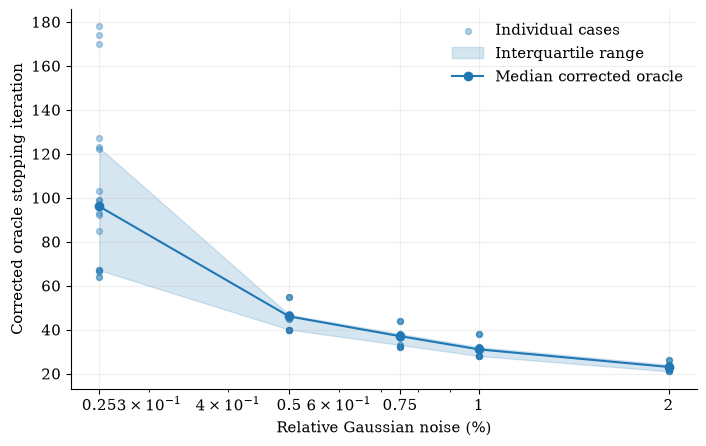

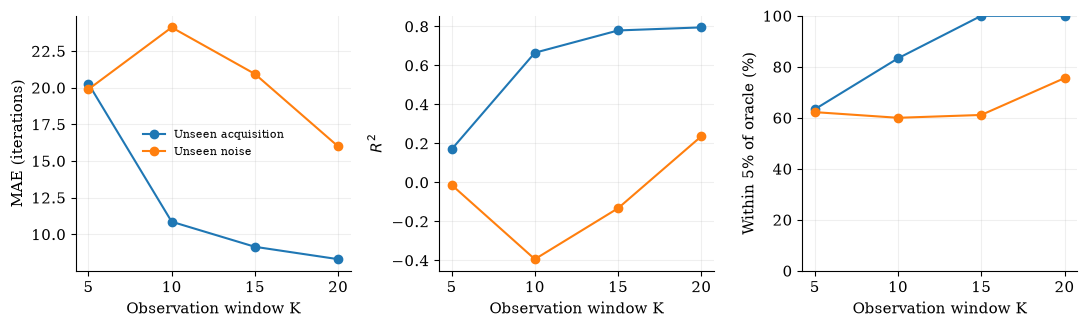

In [ ]:
# ============================================================
# Dissertation figures
# ============================================================
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
    }
)
# ------------------------------------------------------------
# Figure 1
# Corrected oracle stopping iteration versus noise level
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(7.2, 4.6)
)
ax.scatter(
    100 * targets["noise_level"],
    targets["corrected_k_best"],
    s=18,
    alpha=0.35,
    label="Individual cases",
)
quantiles = (
    targets
    .groupby("noise_level")["corrected_k_best"]
    .quantile(
        [0.25, 0.5, 0.75]
    )
    .unstack()
)
noise_percent = (
    100
    * quantiles.index.to_numpy()
)
ax.fill_between(
    noise_percent,
    quantiles[0.25].to_numpy(),
    quantiles[0.75].to_numpy(),
    color="tab:blue",
    alpha=0.18,
    label="Interquartile range",
)
ax.plot(
    noise_percent,
    quantiles[0.5].to_numpy(),
    "o-",
    color="tab:blue",
    label="Median corrected oracle",
)
ax.set_xscale(
    "log"
)
ax.set_xticks(
    100 * np.array(NOISE_LEVELS),
    [
        f"{100 * level:g}"
        for level in NOISE_LEVELS
    ],
)
ax.set_xlabel(
    "Relative Gaussian noise (%)"
)
ax.set_ylabel(
    "Corrected oracle stopping iteration"
)
ax.grid(
    alpha=0.2
)
ax.legend(
    frameon=False
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "ai_noise_vs_oracle_stopping.pdf",
    bbox_inches="tight",
)
plt.show()
# ------------------------------------------------------------
# Figure 2
# Observation-window sensitivity
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(11, 3.4),
)
for setting, subset in window_results.groupby(
    "validation"
):
    labels = {
        "unseen_acquisition":
            "Unseen acquisition",
        "unseen_noise":
            "Unseen noise",
    }
    display_label = labels[
        setting
    ]
    for ax, metric, ylabel in zip(
        axes,
        [
            "MAE",
            "R2",
            "within_5pct_percent",
        ],
        [
            "MAE (iterations)",
            r"$R^2$",
            "Within 5% of oracle (%)",
        ],
    ):
        ax.plot(
            subset["K"],
            subset[metric],
            "o-",
            label=display_label,
        )
        ax.set_xlabel(
            "Observation window K"
        )
        ax.set_ylabel(
            ylabel
        )
        ax.set_xticks(
            WINDOWS
        )
        ax.grid(
            alpha=0.2
        )
axes[-1].set_ylim(
    0,
    100,
)
axes[0].legend(
    frameon=False,
    fontsize=8,
)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR
    / "observation_window_direct_regression.pdf",
    bbox_inches="tight",
)
plt.show()